# Snippet 1 — Global Pipeline Architecture Diagram (Graphviz)

[Snippet 1] REPO_ROOT  = C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals
[Snippet 1] PUBLIC_DIR = C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release
[Snippet 1] FLOW_DIR   = C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\flow
[Snippet 1] dot = C:\Program Files\Graphviz\bin\dot.EXE
[OK] GV : pipeline_clusterizacao.gv 3215
[OK] PNG: pipeline_clusterizacao.png 142323
[OK] SVG: pipeline_clusterizacao.svg 22314

[FLOW_DIR contents]
 - pipeline_clusterizacao.gv 3215
 - pipeline_clusterizacao.png 142323
 - pipeline_clusterizacao.svg 22314


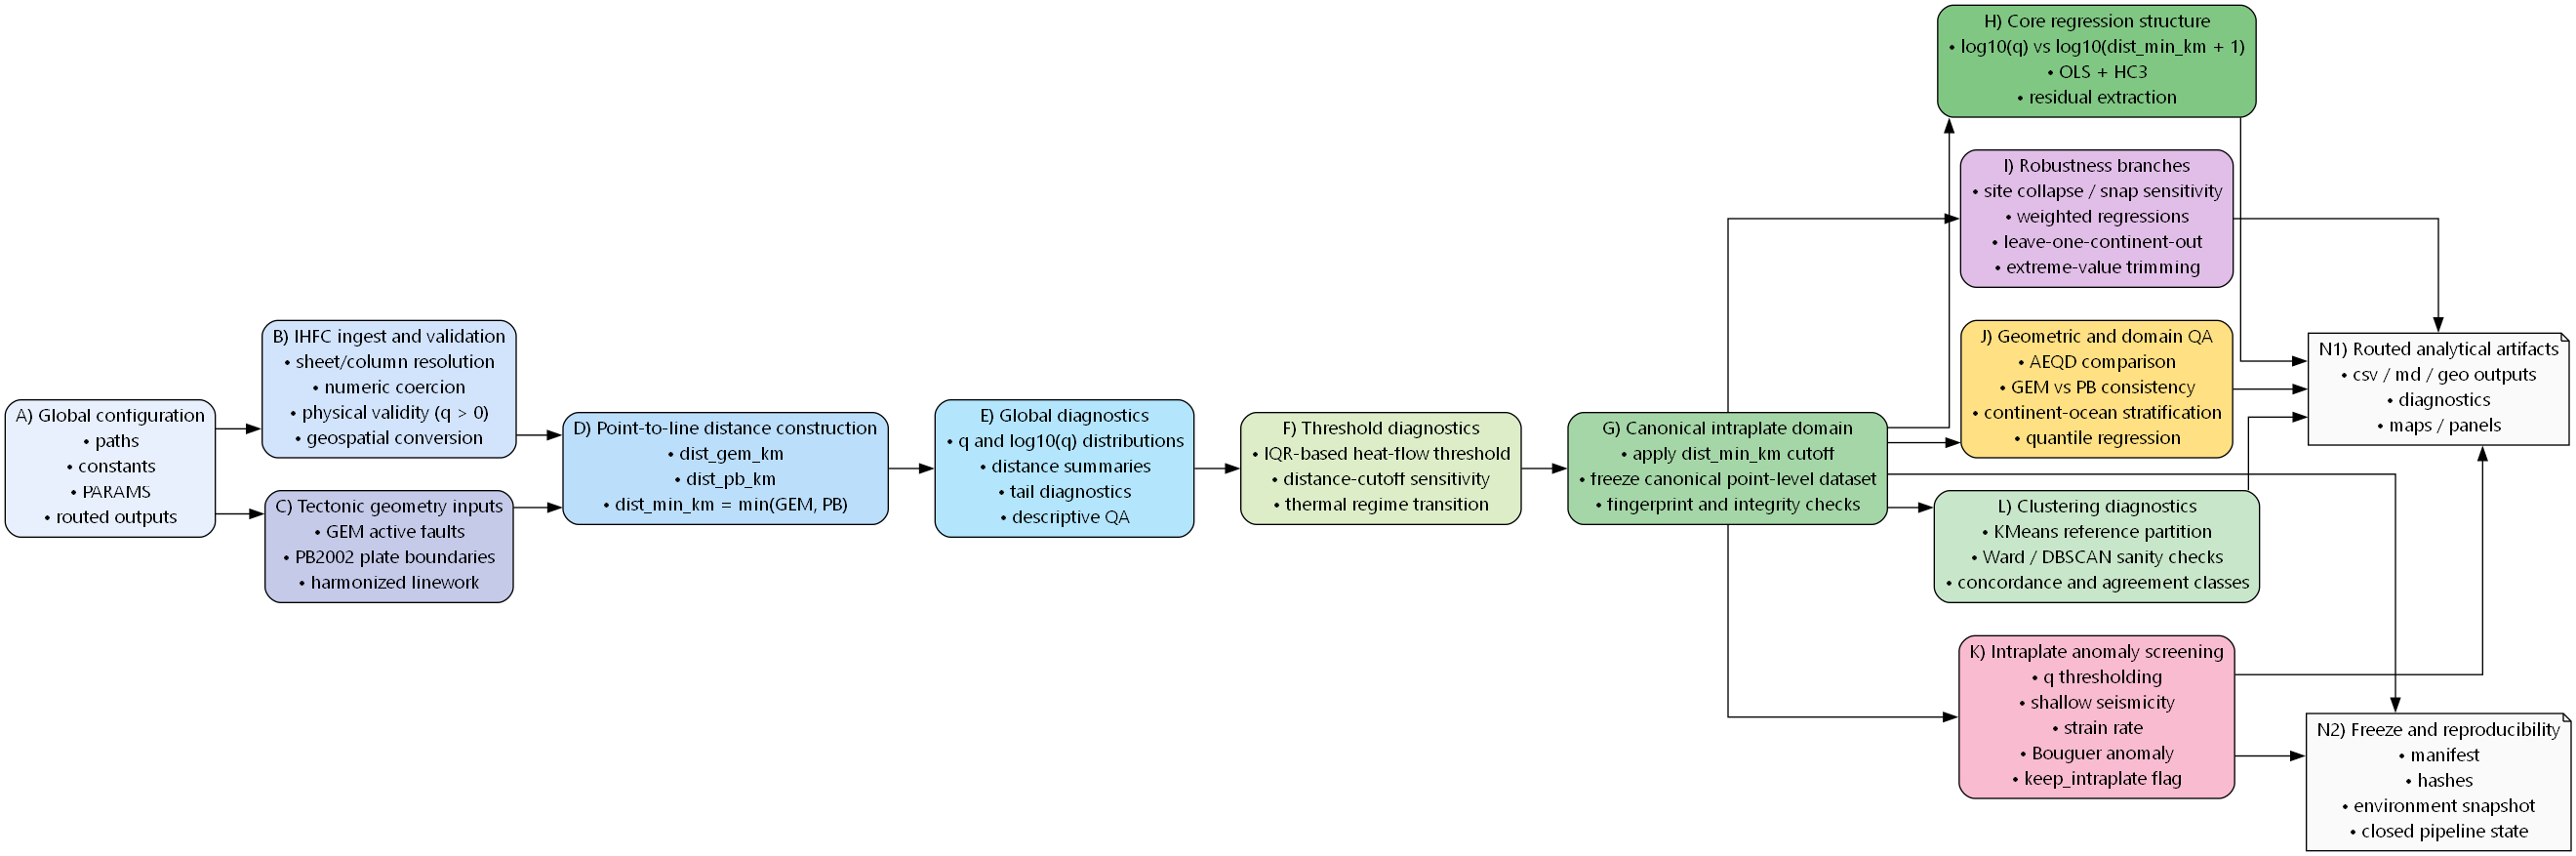

In [1]:
# ==============================================================
# Snippet 1 — Global Pipeline Architecture Diagram (Graphviz)
# Outputs (versioned, repo)
# -------------------------
#   <REPO_ROOT>/public_release/flow/pipeline_clusterizacao.gv
#   <REPO_ROOT>/public_release/flow/pipeline_clusterizacao.png
#   <REPO_ROOT>/public_release/flow/pipeline_clusterizacao.svg
#
# Purpose:
#   Render the operational analytical workflow of the pipeline,
#   focusing on data ingestion, tectonic-distance construction,
#   canonical domain definition, robustness branches, QA filters,
#   clustering diagnostics, and reproducibility artifacts.
# ==============================================================

from graphviz import Digraph
from pathlib import Path
import os
import shutil

# =========================
# FIXED REPO ROOT
# =========================
REPO_ROOT = Path(
    os.environ.get(
        "PROJECT_ROOT",
        r"C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals"
    )
).resolve()

# =========================
# SINGLE VERSIONED OUTPUT ROOT
# =========================
PUBLIC_DIR = Path(os.environ.get("PUBLIC_DIR", REPO_ROOT / "public_release")).resolve()
FLOW_DIR = PUBLIC_DIR / "flow"
FLOW_DIR.mkdir(parents=True, exist_ok=True)

print("[Snippet 1] REPO_ROOT  =", REPO_ROOT)
print("[Snippet 1] PUBLIC_DIR =", PUBLIC_DIR)
print("[Snippet 1] FLOW_DIR   =", FLOW_DIR)

# =========================
# Graphviz sanity check
# =========================
dot_exe = shutil.which("dot")
assert dot_exe is not None, "Graphviz 'dot' not found in PATH"
print("[Snippet 1] dot =", dot_exe)

# =========================
# Build diagram (pipeline only)
# =========================
FONT_PREF = "Segoe UI"

dot = Digraph(comment="IHFC Pipeline — Operational Analytical Workflow")
dot.attr(
    rankdir="LR",
    fontsize="11",
    fontname=FONT_PREF,
    splines="ortho",
    nodesep="0.35",
    ranksep="0.50",
)

box_style  = {"shape": "box",  "style": "rounded,filled", "fontname": FONT_PREF}
note_style = {"shape": "note", "style": "filled",         "fontname": FONT_PREF}

dot.node(
    "A",
    "A) Global configuration\n• paths\n• constants\n• PARAMS\n• routed outputs",
    fillcolor="#e8f0fe",
    **box_style
)

dot.node(
    "B",
    "B) IHFC ingest and validation\n• sheet/column resolution\n• numeric coercion\n• physical validity (q > 0)\n• geospatial conversion",
    fillcolor="#d2e3fc",
    **box_style
)

dot.node(
    "C",
    "C) Tectonic geometry inputs\n• GEM active faults\n• PB2002 plate boundaries\n• harmonized linework",
    fillcolor="#c5cae9",
    **box_style
)

dot.node(
    "D",
    "D) Point-to-line distance construction\n• dist_gem_km\n• dist_pb_km\n• dist_min_km = min(GEM, PB)",
    fillcolor="#bbdefb",
    **box_style
)

dot.node(
    "E",
    "E) Global diagnostics\n• q and log10(q) distributions\n• distance summaries\n• tail diagnostics\n• descriptive QA",
    fillcolor="#b3e5fc",
    **box_style
)

dot.node(
    "F",
    "F) Threshold diagnostics\n• IQR-based heat-flow threshold\n• distance-cutoff sensitivity\n• thermal regime transition",
    fillcolor="#dcedc8",
    **box_style
)

dot.node(
    "G",
    "G) Canonical intraplate domain\n• apply dist_min_km cutoff\n• freeze canonical point-level dataset\n• fingerprint and integrity checks",
    fillcolor="#a5d6a7",
    **box_style
)

dot.node(
    "H",
    "H) Core regression structure\n• log10(q) vs log10(dist_min_km + 1)\n• OLS + HC3\n• residual extraction",
    fillcolor="#81c784",
    **box_style
)

dot.node(
    "I",
    "I) Robustness branches\n• site collapse / snap sensitivity\n• weighted regressions\n• leave-one-continent-out\n• extreme-value trimming",
    fillcolor="#e1bee7",
    **box_style
)

dot.node(
    "J",
    "J) Geometric and domain QA\n• AEQD comparison\n• GEM vs PB consistency\n• continent-ocean stratification\n• quantile regression",
    fillcolor="#ffe082",
    **box_style
)

dot.node(
    "K",
    "K) Intraplate anomaly screening\n• q thresholding\n• shallow seismicity\n• strain rate\n• Bouguer anomaly\n• keep_intraplate flag",
    fillcolor="#f8bbd0",
    **box_style
)

dot.node(
    "L",
    "L) Clustering diagnostics\n• KMeans reference partition\n• Ward / DBSCAN sanity checks\n• concordance and agreement classes",
    fillcolor="#c8e6c9",
    **box_style
)

dot.node(
    "N1",
    "N1) Routed analytical artifacts\n• csv / md / geo outputs\n• diagnostics\n• maps / panels",
    fillcolor="#fafafa",
    **note_style
)

dot.node(
    "N2",
    "N2) Freeze and reproducibility\n• manifest\n• hashes\n• environment snapshot\n• closed pipeline state",
    fillcolor="#fafafa",
    **note_style
)

dot.edge("A", "B")
dot.edge("A", "C")
dot.edge("B", "D")
dot.edge("C", "D")
dot.edge("D", "E")
dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")
dot.edge("G", "I")
dot.edge("G", "J")
dot.edge("G", "K")
dot.edge("G", "L")
dot.edge("H", "N1")
dot.edge("I", "N1")
dot.edge("J", "N1")
dot.edge("K", "N1")
dot.edge("L", "N1")
dot.edge("G", "N2")
dot.edge("K", "N2")

# =========================
# Guard (prevent empty)
# =========================
src = dot.source
if ("->" not in src) and ("--" not in src):
    raise RuntimeError("Diagram has no edges — node/edge section did not run.")

# =========================
# Write outputs
# =========================
gv  = FLOW_DIR / "pipeline_clusterizacao.gv"
png = FLOW_DIR / "pipeline_clusterizacao.png"
svg = FLOW_DIR / "pipeline_clusterizacao.svg"

dot.save(str(gv))
png.write_bytes(dot.pipe(format="png"))
svg.write_bytes(dot.pipe(format="svg"))

print("[OK] GV :", gv.name, gv.stat().st_size)
print("[OK] PNG:", png.name, png.stat().st_size)
print("[OK] SVG:", svg.name, svg.stat().st_size)

print("\n[FLOW_DIR contents]")
for p in sorted(FLOW_DIR.glob("*")):
    print(" -", p.name, p.stat().st_size)

try:
    from IPython.display import Image, display
    display(Image(filename=str(png)))
except Exception as e:
    print("Inline display failed:", e)

try:
    os.startfile(str(FLOW_DIR))
except Exception as e:
    print("os.startfile failed:", e)


# Snippet 2 — Global configuration and utilities

In [2]:
# ==============================================================
# Snippet 2 — Global Config & Utilities
#
# Purpose:
#   Centralize repository layout (PROJECT_ROOT), input data paths, CRS,
#   global registries (PARAMS, AUDIT) and helper utilities used downstream.
#   This version enforces a SINGLE pipeline output root under public_release
#   and keeps legacy aliases so older snippets do not create duplicated roots.
#
# Canonical, versioned outputs (ONLY):
#   <PROJECT_ROOT>/public_release/
#     - figures_main/
#     - flow/
#     - freeze/
#     - env/
#     - qa/                       (global QA; non-pipeline-specific)
#     - pipeline_kmeans/          (ONLY pipeline outputs root)
#         - analysis/
#         - plots/
#         - exports/
#         - models/
#         - index/
#         - diagnostics/
#             - residuals/
#             - outliers/
#             - agreement/
#             - clustering/
#             - maps/
#             - regressions/
#         - snapshots/
#
# Inputs (local-only, not versioned):
#   <PROJECT_ROOT>/data/raw/**
#   <PROJECT_ROOT>/data/processed/**
#
# Reproducibility:
#   - Offline-first (FORCE_OFFLINE=1 by default)
#   - Deterministic path resolution; OneDrive placeholder readability checks
#
# Editorial role:
#   METHOD
# ==============================================================

import time as _time

# --------------------------------------------------------------
# Snippet registry
# --------------------------------------------------------------
if "SNIPPETS_RUN" not in globals():
    SNIPPETS_RUN = {}

SNIPPET_ID = "SNIPPET_2"
SNIPPETS_RUN[SNIPPET_ID] = {
    "activated_at": _time.strftime("%Y-%m-%d %H:%M:%S"),
    "unix_time": float(_time.time()),
}

# --------------------------------------------------------------
# Imports
# --------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import os
import time
from pathlib import Path
from typing import Iterable, Optional, Any, Sequence

import numpy as np
import pandas as pd
import geopandas as gpd

# ==============================================================
# Reproducibility / Offline policy
# ==============================================================
FORCE_OFFLINE = str(os.environ.get("FORCE_OFFLINE", "1")).strip() not in ("0", "false", "False", "no", "NO")

# ==============================================================
# Repository root (GitHub clone / local repo)
# ==============================================================
PROJECT_ROOT = Path(
    os.environ.get(
        "PROJECT_ROOT",
        r"C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals"
    )
).resolve()

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"[PROJECT_ROOT] does not exist: {PROJECT_ROOT}")

# Lock for this kernel session (prevents drift across snippets)
os.environ["PROJECT_ROOT"] = str(PROJECT_ROOT)

# ==============================================================
# Data layout (NOT versioned)
# ==============================================================
DATA_DIR = Path(os.environ.get("DATA_DIR", PROJECT_ROOT / "data")).resolve()
RAW_DIR = Path(os.environ.get("RAW_DIR", DATA_DIR / "raw")).resolve()
PROCESSED_DIR = Path(os.environ.get("PROCESSED_DIR", DATA_DIR / "processed")).resolve()

# Subdirs (explicit, audit-friendly)
RAW_IHFC_DIR = RAW_DIR / "IHFC"
RAW_GEM_DIR = RAW_DIR / "GEM"
RAW_PB2002_DIR = RAW_DIR / "PB2002"
RAW_NE_DIR = RAW_DIR / "NaturalEarth"
RAW_EQ_DIR = RAW_DIR / "earthquakes"
RAW_STRAIN_DIR = RAW_DIR / "strain"
RAW_GRAVITY_DIR = RAW_DIR / "gravity"

# ==============================================================
# Public / versioned outputs (PUBLIC_RELEASE ONLY)
# ==============================================================
PUBLIC_DIR = Path(os.environ.get("PUBLIC_DIR", PROJECT_ROOT / "public_release")).resolve()
PUBLIC_DIR.mkdir(parents=True, exist_ok=True)

FLOW_DIR = Path(os.environ.get("FLOW_DIR", PUBLIC_DIR / "flow")).resolve()

FIG_MAIN_DIR = Path(os.environ.get("FIG_MAIN_DIR", PUBLIC_DIR / "figures_main")).resolve()
FIG_SM_DIR   = Path(os.environ.get("FIG_SM_DIR",   PUBLIC_DIR / "figures_supplementary_methods")).resolve()
FIG_SR_DIR   = Path(os.environ.get("FIG_SR_DIR",   PUBLIC_DIR / "figures_supplementary_results")).resolve()

# 🔁 Backward-compat alias (do NOT remove): older snippets expect FIG_DIR
FIG_DIR = FIG_MAIN_DIR

QA_DIR     = Path(os.environ.get("QA_DIR",     PUBLIC_DIR / "qa")).resolve()
FREEZE_DIR = Path(os.environ.get("FREEZE_DIR", PUBLIC_DIR / "freeze")).resolve()
ENV_DIR    = Path(os.environ.get("ENV_DIR",    PUBLIC_DIR / "env")).resolve()

for _p in [FLOW_DIR, FIG_MAIN_DIR, FIG_SM_DIR, FIG_SR_DIR, QA_DIR, FREEZE_DIR, ENV_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

#  Harden environment so downstream snippets won't drift
os.environ["PUBLIC_DIR"]     = str(PUBLIC_DIR)
os.environ["FLOW_DIR"]       = str(FLOW_DIR)

# Keep legacy key for compatibility
os.environ["FIG_DIR"]        = str(FIG_DIR)

# New explicit keys (optional for updated snippets)
os.environ["FIG_MAIN_DIR"]   = str(FIG_MAIN_DIR)
os.environ["FIG_SM_DIR"]     = str(FIG_SM_DIR)
os.environ["FIG_SR_DIR"]     = str(FIG_SR_DIR)

os.environ["QA_DIR"]         = str(QA_DIR)
os.environ["FREEZE_DIR"]     = str(FREEZE_DIR)
os.environ["ENV_DIR"]        = str(ENV_DIR)

# ==============================================================
# Canonical pipeline outputs root (SINGLE, NG-clean)
# ==============================================================
OUT_DIR = Path(os.environ.get("PIPELINE_OUT_DIR", PUBLIC_DIR / "pipeline_kmeans")).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ["PIPELINE_OUT_DIR"] = str(OUT_DIR)

# Core
OUT_ANALYSIS_DIR   = OUT_DIR / "analysis"
OUT_PLOTS_DIR      = OUT_DIR / "plots"
OUT_EXPORTS_DIR    = OUT_DIR / "exports"
OUT_MODELS_DIR     = OUT_DIR / "models"
OUT_INDEX_DIR      = OUT_DIR / "index"
OUT_SNAPSHOTS_DIR  = OUT_DIR / "snapshots"  # Snippet 3 uses it

# Diagnostics (pipeline-only)
OUT_DIAG_DIR             = OUT_DIR / "diagnostics"
OUT_DIAG_RESIDUALS_DIR   = OUT_DIAG_DIR / "residuals"
OUT_DIAG_OUTLIERS_DIR    = OUT_DIAG_DIR / "outliers"
OUT_DIAG_AGREEMENT_DIR   = OUT_DIAG_DIR / "agreement"
OUT_DIAG_CLUSTERING_DIR  = OUT_DIAG_DIR / "clustering"
OUT_DIAG_MAPS_DIR        = OUT_DIAG_DIR / "maps"
OUT_DIAG_REGRESSIONS_DIR = OUT_DIAG_DIR / "regressions"

PIPE_DIAG_DIR = OUT_DIAG_DIR

for _p in [
    OUT_ANALYSIS_DIR, OUT_PLOTS_DIR, OUT_EXPORTS_DIR, OUT_MODELS_DIR, OUT_INDEX_DIR, OUT_SNAPSHOTS_DIR,
    OUT_DIAG_DIR, OUT_DIAG_RESIDUALS_DIR, OUT_DIAG_OUTLIERS_DIR, OUT_DIAG_AGREEMENT_DIR,
    OUT_DIAG_CLUSTERING_DIR, OUT_DIAG_MAPS_DIR, OUT_DIAG_REGRESSIONS_DIR,
]:
    _p.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------
# Legacy aliases (compat) — DO NOT CREATE NEW ROOTS
# --------------------------------------------------------------
OUT_ROOT    = OUT_DIR       # legacy
OUTPUTS_DIR = OUT_DIR       # legacy
DIAG_DIR    = OUT_DIAG_DIR  # legacy name; pipeline diagnostics root (NOT QA_DIR)

# (optional) legacy-like names some older snippets might check
PLOTS_DIR   = OUT_PLOTS_DIR
ANALYSIS_DIR = OUT_ANALYSIS_DIR

def resolve_out_path(filename: str, *, family: str = "analysis") -> Path:
    """
    Route artifact filenames into standardized OUT_DIR subfolders.

    family:
      analysis | plots | exports | models | snapshots |
      diag_residuals | diag_outliers | diag_agreement | diag_clustering | diag_maps | diag_regressions |
      index | root
    """
    fam = str(family).strip().lower()
    mapping = {
        "figures_main": FIG_MAIN_DIR,
        "analysis": OUT_ANALYSIS_DIR,
        "plots": OUT_PLOTS_DIR,
        "exports": OUT_EXPORTS_DIR,
        "models": OUT_MODELS_DIR,
        "snapshots": OUT_SNAPSHOTS_DIR,
        "index": OUT_INDEX_DIR,
        "diag_residuals": OUT_DIAG_RESIDUALS_DIR,
        "diag_outliers": OUT_DIAG_OUTLIERS_DIR,
        "diag_agreement": OUT_DIAG_AGREEMENT_DIR,
        "diag_clustering": OUT_DIAG_CLUSTERING_DIR,
        "diag_maps": OUT_DIAG_MAPS_DIR,
        "diag_regressions": OUT_DIAG_REGRESSIONS_DIR,
        "root": OUT_DIR,
    }
    if fam not in mapping:
        raise KeyError(f"Unknown family='{family}'. Options: {sorted(mapping.keys())}")
    return mapping[fam] / filename

# ==============================================================
# Global registries
# ==============================================================
PARAMS = globals().get("PARAMS", {})
AUDIT  = globals().get("AUDIT", {})

# ==============================================================
# PARAMS helpers
# ==============================================================
def set_param(key: str, value: Any, *, overwrite: bool = True) -> None:
    """Store a parameter in PARAMS."""
    if (not overwrite) and (key in PARAMS):
        return
    PARAMS[key] = value

def require_param(key: str, *, cast=None, default=None):
    """
    Retrieve a required parameter from PARAMS.
    - If missing and default is None -> raise KeyError with a clear message.
    - If cast is provided, cast(value) is applied.
    """
    if key not in PARAMS:
        if default is not None:
            val = default
            PARAMS[key] = val  # persist default explicitly (audit-friendly)
        else:
            available = sorted(PARAMS.keys())
            raise KeyError(
                f"Missing PARAMS['{key}']. "
                f"Define it earlier (DECISION snippet) or set a default. "
                f"Available keys: {available[:20]}{'...' if len(available) > 20 else ''}"
            )
    else:
        val = PARAMS[key]

    if cast is not None:
        try:
            val = cast(val)
        except Exception as e:
            raise TypeError(f"Failed to cast PARAMS['{key}']={val!r} using {cast}: {e!r}")
    return val

# ==============================================================
# OneDrive-safe file readability utilities
# ==============================================================
def _is_readable_file(p: Path, nbytes: int = 64) -> bool:
    """True only if file exists and can be opened for reading."""
    try:
        p = Path(p)
        if (not p.exists()) or (not p.is_file()):
            return False
        with open(p, "rb") as f:
            _ = f.read(nbytes)
        return True
    except Exception:
        return False

def _first_existing(paths: Sequence[Path]) -> Optional[Path]:
    """Deterministic: first path that is truly readable."""
    for p in paths:
        if p is None:
            continue
        p = Path(p)
        if _is_readable_file(p):
            return p.resolve()
    return None

def _glob_pick(folder: Path, patterns: Sequence[str], prefer_contains: Optional[Sequence[str]] = None) -> Optional[Path]:
    """Deterministic file resolver (readable matches; lexicographically smallest)."""
    folder = Path(folder) if folder is not None else None
    if folder is None or (not folder.exists()):
        return None

    matches = []
    for pat in patterns:
        matches.extend(sorted(folder.glob(pat)))

    if not matches:
        return None

    if prefer_contains:
        toks = [t.lower() for t in prefer_contains]
        preferred = [p for p in matches if any(t in p.name.lower() for t in toks)]
        if preferred:
            matches = preferred

    matches = [p.resolve() for p in matches if _is_readable_file(p)]
    matches = sorted({p for p in matches}, key=lambda x: str(x).lower())
    return matches[0] if matches else None

# ==============================================================
# Helper functions required downstream (Snippet 3, etc.)
# ==============================================================
def pick_sheet(xls: pd.ExcelFile, candidates: Iterable[str]) -> str:
    cand_norm = [str(c).strip().lower() for c in candidates]
    for s in xls.sheet_names:
        if str(s).strip().lower() in cand_norm:
            return s
    return xls.sheet_names[0]

def find_col(df: pd.DataFrame, candidates: Iterable[str]) -> str:
    for cand in candidates:
        for col in df.columns:
            if str(col).strip().lower() == str(cand).strip().lower():
                return col
    raise KeyError(f"Column not found. Tried: {list(candidates)}")

# ==============================================================
# Sheet candidates for IHFC Excel
# ==============================================================
SHEET_CANDIDATES = [
    "data release2024",
    "data release 2024",
    "data_release_2024",
    "data release",
]

# ==============================================================
# CRS
# ==============================================================
CRS_WGS84  = 4326
CRS_METRIC = 3857  # EPSG:3857

def ensure_wgs84(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        return gdf.set_crs(CRS_WGS84, allow_override=True)
    return gdf.to_crs(CRS_WGS84)

# ==============================================================
# Distance helpers (required by Snippet 3)
# ==============================================================
def _prep_lines_for_index(lines_wgs84: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    lm = ensure_wgs84(lines_wgs84).to_crs(CRS_METRIC)
    try:
        lm = lm.explode(index_parts=False, ignore_index=True)
    except TypeError:
        lm = lm.explode().reset_index(drop=True)
    lm = lm[~lm.geometry.is_empty & lm.geometry.notna()].copy()
    _ = lm.sindex
    return lm

def _nearest_distance_series(
    points_m: gpd.GeoDataFrame,
    lines_m: gpd.GeoDataFrame,
    label: str,
    verbose: bool = True,
) -> pd.Series:
    idx = lines_m.sindex
    distances = np.empty(len(points_m), dtype="float64")
    use_nearest = hasattr(idx, "nearest")
    t0 = time.time()

    for i, geom in enumerate(points_m.geometry.values):
        if use_nearest:
            try:
                _, cand_idx = idx.nearest(geom.bounds, 1)
                distances[i] = geom.distance(lines_m.geometry.iloc[cand_idx[0]])
                continue
            except Exception:
                use_nearest = False

        radius_m_list = (5_000, 20_000, 100_000, 500_000, 1_000_000, 5_000_000)
        d_best = np.inf
        for r in radius_m_list:
            env = geom.buffer(r).envelope
            cand = list(idx.intersection(env.bounds))
            if cand:
                d_best = float(lines_m.geometry.iloc[cand].distance(geom).min())
                break

        if not np.isfinite(d_best):
            step = max(1, len(lines_m) // 10_000)
            d_best = float(lines_m.geometry.iloc[::step].distance(geom).min())

        distances[i] = d_best
        if verbose and (i + 1) % 20000 == 0:
            print(f"[{label}] processed {i + 1:,}/{len(points_m):,}")

    if verbose:
        print(f"[{label}] distance computation done in {time.time() - t0:.2f}s")

    return pd.Series(distances, index=points_m.index)

# ==============================================================
# Inputs — expected RAW layout (local-only paths)
# ==============================================================
DATA_XLSX          = Path(os.environ.get("IHFC_XLSX", RAW_IHFC_DIR / "IHFC_2024_GHFDB_.xlsx")).resolve()
GEM_SHP            = Path(os.environ.get("GEM_SHP", RAW_GEM_DIR / "gem_active_faults_harmonized.gpkg")).resolve()
PB2002_SHP         = Path(os.environ.get("PB2002_SHP", RAW_PB2002_DIR / "PB2002_boundaries.shp")).resolve()
PB2002_PLATES_PATH = Path(os.environ.get("PB2002_PLATES_PATH", RAW_PB2002_DIR / "PB2002_plates.shp")).resolve()
WORLD_SHP          = Path(os.environ.get("WORLD_SHP", RAW_NE_DIR / "ne_110m_admin_0_countries.shp")).resolve()

# AUX datasets (required by some QA/snippets)
_EQ_ENV     = os.environ.get("EQ_RAW_CSV", "").strip()
_EQ_DEFAULT = (RAW_EQ_DIR / "earthquakes_master.csv").resolve()

EQ_RAW_CSV = None
if _EQ_ENV:
    EQ_RAW_CSV = _first_existing([Path(_EQ_ENV)])
if EQ_RAW_CSV is None:
    EQ_RAW_CSV = _first_existing([_EQ_DEFAULT])
if EQ_RAW_CSV is None:
    EQ_RAW_CSV = _glob_pick(
        RAW_EQ_DIR,
        patterns=["*.csv", "*.CSV"],
        prefer_contains=["master", "earthquake", "terremoto", "earthquakes"]
    )

EQ_CACHE_PARQUET_PATH = Path(os.environ.get(
    "EQ_CACHE_PARQUET_PATH",
    PROCESSED_DIR / "earthquakes" / "eq_cache_master.parquet"
)).resolve()

_GSRM_ENV     = os.environ.get("GSRM_NC_PATH", "").strip()
_GSRM_DEFAULT = (RAW_STRAIN_DIR / "gsrm.nc").resolve()

GSRM_NC_PATH = None
if _GSRM_ENV:
    GSRM_NC_PATH = _first_existing([Path(_GSRM_ENV)])
if GSRM_NC_PATH is None:
    GSRM_NC_PATH = _first_existing([_GSRM_DEFAULT])
if GSRM_NC_PATH is None:
    GSRM_NC_PATH = _glob_pick(
        RAW_STRAIN_DIR,
        patterns=["*.nc", "*.NC", "*.netcdf", "*.NETCDF"],
        prefer_contains=["gsrm", "strain"]
    )

_BG_ENV = os.environ.get("BOUGUER_GRID_PATH", "").strip()
_BG_CANDIDATES = [
    (RAW_GRAVITY_DIR / "wgm2012_bouguer.tif").resolve(),
    (RAW_GRAVITY_DIR / "wgm2012_bouguer.tiff").resolve(),
    (RAW_GRAVITY_DIR / "WGM2012_Bouguer.tif").resolve(),
    (RAW_GRAVITY_DIR / "WGM2012_Bouguer.tiff").resolve(),
    (RAW_GRAVITY_DIR / "WGM2012_Bouguer_ponc_2min.grd").resolve(),
    (RAW_GRAVITY_DIR / "WGM2012_Bouguer_ponc_2min.tif").resolve(),
    (RAW_GRAVITY_DIR / "WGM2012_Bouguer_ponc_2min.tiff").resolve(),
]

BOUGUER_GRID_PATH = None
if _BG_ENV:
    BOUGUER_GRID_PATH = _first_existing([Path(_BG_ENV)])
if BOUGUER_GRID_PATH is None:
    BOUGUER_GRID_PATH = _first_existing(_BG_CANDIDATES)
if BOUGUER_GRID_PATH is None:
    BOUGUER_GRID_PATH = _glob_pick(
        RAW_GRAVITY_DIR,
        patterns=["*.tif", "*.tiff", "*.grd", "*.nc"],
        prefer_contains=["bouguer", "wgm2012", "wgm"]
    )

# ==============================================================
# Soft sanity checks (GitHub-safe)
# ==============================================================
MISSING = []
for _label, _p in [
    ("IHFC_XLSX", DATA_XLSX),
    ("GEM_SHP", GEM_SHP),
    ("PB2002_SHP", PB2002_SHP),
    ("PB2002_PLATES_PATH", PB2002_PLATES_PATH),
    ("WORLD_SHP", WORLD_SHP),
    ("EQ_RAW_CSV", EQ_RAW_CSV),
    ("GSRM_NC_PATH", GSRM_NC_PATH),
    ("BOUGUER_GRID_PATH", BOUGUER_GRID_PATH),
]:
    if _p is None:
        MISSING.append(f"{_label}: None")
    else:
        pp = Path(_p)
        if not pp.exists():
            MISSING.append(f"{_label}: {str(pp)} (missing)")
        elif pp.is_file() and (not _is_readable_file(pp)):
            MISSING.append(f"{_label}: {str(pp)} (not readable; OneDrive placeholder?)")

if MISSING:
    print("[WARN] Missing/raw/aux data issues (expected on a fresh clone OR OneDrive placeholders):")
    for m in MISSING:
        print("   -", m)

if "PARAMS" not in globals() or not isinstance(PARAMS, dict):
    PARAMS = {}

PARAMS["SHOW_PLOTS"] = 1


# ==============================================================
# Activation report (NG-style, compact but informative)
# ==============================================================
print(f"[OK] {SNIPPET_ID} ACTIVATED")
print(f"     Time         : {SNIPPETS_RUN[SNIPPET_ID]['activated_at']}")
print(f"     FORCE_OFFLINE: {FORCE_OFFLINE}")
print(f"     PROJECT_ROOT : {PROJECT_ROOT}")
print(f"     DATA_DIR     : {DATA_DIR}")
print(f"     RAW_DIR      : {RAW_DIR}")
print(f"     PROCESSED_DIR: {PROCESSED_DIR}")
print(f"     PUBLIC_DIR   : {PUBLIC_DIR}")

print(f"     FLOW_DIR     : {FLOW_DIR}")
print(f"     FIG_DIR      : {FIG_DIR}  (MAIN FIGURES)")
print(f"     QA_DIR       : {QA_DIR}   (GLOBAL QA)")
print(f"     FREEZE_DIR   : {FREEZE_DIR}")
print(f"     ENV_DIR      : {ENV_DIR}")

print(f"     OUT_DIR      : {OUT_DIR}  (PIPELINE ROOT)")
print(f"       - analysis   : {OUT_ANALYSIS_DIR}")
print(f"       - plots      : {OUT_PLOTS_DIR}")
print(f"       - exports    : {OUT_EXPORTS_DIR}")
print(f"       - models     : {OUT_MODELS_DIR}")
print(f"       - index      : {OUT_INDEX_DIR}")
print(f"       - snapshots  : {OUT_SNAPSHOTS_DIR}")
print(f"       - diagnostics: {OUT_DIAG_DIR}")

print(f"     DIAG_DIR     : {DIAG_DIR} (legacy -> pipeline diagnostics)")
print(f"     IHFC_XLSX    : {DATA_XLSX}")
print(f"     GEM_SHP      : {GEM_SHP}")
print(f"     PB2002_SHP   : {PB2002_SHP}")
print(f"     PB2002_PLATE : {PB2002_PLATES_PATH}")
print(f"     WORLD_SHP    : {WORLD_SHP}")
print(f"     EQ_RAW_CSV   : {EQ_RAW_CSV}")
print(f"     GSRM_NC      : {GSRM_NC_PATH}")
print(f"     BOUGUER_GRID : {BOUGUER_GRID_PATH}")
print(f"     Registry     : {list(SNIPPETS_RUN.keys())}")

print(f"     FIG_MAIN_DIR : {FIG_MAIN_DIR}")
print(f"     FIG_SM_DIR   : {FIG_SM_DIR}")
print(f"     FIG_SR_DIR   : {FIG_SR_DIR}")

[WARN] Missing/raw/aux data issues (expected on a fresh clone OR OneDrive placeholders):
   - PB2002_PLATES_PATH: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\PB2002\PB2002_plates.shp (missing)
[OK] SNIPPET_2 ACTIVATED
     Time         : 2026-04-25 16:23:15
     FORCE_OFFLINE: True
     PROJECT_ROOT : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals
     DATA_DIR     : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data
     RAW_DIR      : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw
     PROCESSED_DIR: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\processed
     PUBLIC_DIR   : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release
     FLOW_DIR     : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\flow
     FIG_DIR      : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-i

# Snippet 3 — Load IHFC & Compute Segment Distances

C:\projetos\sismologia\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


[IHFC] sheet='data release2024' | rows read=91,182
[IHFC] after numeric (q,lon,lat notna) = 91,182
[IHFC] after physical (q>0)           = 91,059
[GEM] processed 20,000/91,059
[GEM] processed 40,000/91,059
[GEM] processed 60,000/91,059
[GEM] processed 80,000/91,059
[GEM] distance computation done in 78.61s
[PB2002] processed 20,000/91,059
[PB2002] processed 40,000/91,059
[PB2002] processed 60,000/91,059
[PB2002] processed 80,000/91,059
[PB2002] distance computation done in 59.17s

[STATS] Heat-flow (q, mW m^-2):
count     91059.000000
mean        199.303462
std        3401.630024
min           0.100000
50%          66.000000
90%         188.000000
95%         339.000000
99%        1712.520000
max      489000.000000
Name: q, dtype: float64

[STATS] Minimum distance to faults (dist_min_km):
count    91059.000000
mean       511.221420
std        795.042822
min          0.002796
50%        173.045487
90%       1388.217205
95%       1914.950890
99%       3505.945369
max      18053.110145
Na

C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\1206811516.py:241: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.05, 0, 1, 1])


[PLOTS] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_methods\fig_SM1_distance_concordance_gem_pb2002.png
[PLOTS] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_methods\fig_SM1_distance_concordance_gem_pb2002.pdf


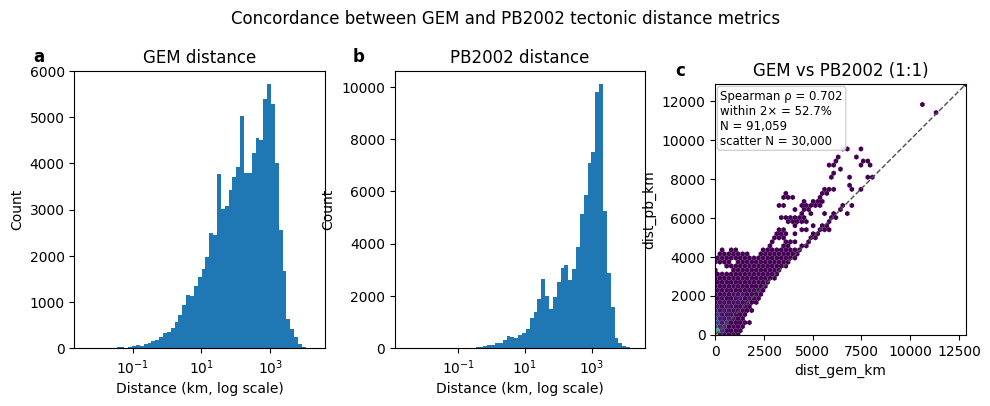

[SNAPSHOT] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\snapshots\df_all_snapshot.csv | shape=(91059, 78)

[OK] gdf_all constructed successfully.


In [3]:
# ==============================================================
# Snippet 3 — Load IHFC & Compute Segment Distances (+ minimal audit hook)
# (NG-clean; PRODUCES gdf_all; NO AEQD loading here)
#
# Purpose:
#   - Load IHFC (xlsx) with robust sheet/column resolution
#   - Enforce numeric + physical validity (q > 0)
#   - Load GEM + PB2002 linework (REUSE if Snippet 4 already ran)
#   - Compute point–line distances (dist_gem_km, dist_pb_km) and
#     conservative distance metric dist_min_km = min(dist_gem_km, dist_pb_km)
#   - Store IHFC row-count funnel into AUDIT via audit_ihfc_postfilter (if available)
#   - Export a diagnostic figure for GEM × PB2002 distance concordance 
#   - Export a global snapshot (pre-intraplate; NOT canonical)
#
# Guarantees:
#   - No distance cutoff is selected here.
#   - No heat-flow threshold is defined here.
#   - No AEQD dataset is loaded here (AEQD is handled in a dedicated QA snippet).
#
# Requires (from Snippet 2):
#   DATA_XLSX, SHEET_CANDIDATES
#   GEM_SHP, PB2002_SHP
#   CRS_WGS84, CRS_METRIC
#   pick_sheet, find_col, ensure_wgs84
#   _prep_lines_for_index, _nearest_distance_series
#   OUT_DIR
#   (optional) audit_ihfc_postfilter
#
# Minimal corrections applied:
#    fIGURE saved to FIG_SM_DIR if available (fallback: OUT_DIR/plots)
#    Optional display on screen via PARAMS["SHOW_PLOTS"]=1 (default 1)
#    Keeps everything else unchanged
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path


def _ensure_pipeline_subdirs(out_dir: Path) -> dict:
    """
    Enforce a stable folder layout under OUT_DIR.
    This is versioned under public_release and safe for GitHub.
    """
    out_dir = Path(out_dir).resolve()
    sub = {
        "root": out_dir,
        "plots": out_dir / "plots",
        "analysis": out_dir / "analysis",
        "snapshots": out_dir / "snapshots",
    }
    for p in sub.values():
        p.mkdir(parents=True, exist_ok=True)
    return sub


def compute_point2line_min_distances(
    points_wgs84: gpd.GeoDataFrame,
    lines_gem_wgs84: gpd.GeoDataFrame,
    lines_pb_wgs84: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    """Compute minimum point–line distances (km) to GEM and PB2002."""
    pm = ensure_wgs84(points_wgs84).to_crs(CRS_METRIC)
    gemm = _prep_lines_for_index(lines_gem_wgs84)
    pbm = _prep_lines_for_index(lines_pb_wgs84)

    d_gem_m = _nearest_distance_series(pm, gemm, label="GEM")
    d_pb_m = _nearest_distance_series(pm, pbm, label="PB2002")

    pts_out = pm.copy()
    pts_out["dist_gem_km"] = d_gem_m.values / 1000.0
    pts_out["dist_pb_km"] = d_pb_m.values / 1000.0
    pts_out["dist_min_km"] = np.minimum(pts_out["dist_gem_km"], pts_out["dist_pb_km"])

    return pts_out.to_crs(CRS_WGS84)


def _load_faults_reuse_if_available() -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Reuse faults if Snippet 4 already loaded them.
    Otherwise, load from GEM_SHP and PB2002_SHP.
    """
    if ("faults_gem" in globals()) and ("faults_pb" in globals()):
        fg = globals()["faults_gem"]
        fp = globals()["faults_pb"]
        if isinstance(fg, gpd.GeoDataFrame) and isinstance(fp, gpd.GeoDataFrame):
            return ensure_wgs84(fg), ensure_wgs84(fp)

    faults_gem_local = ensure_wgs84(gpd.read_file(GEM_SHP))
    faults_pb_local = ensure_wgs84(gpd.read_file(PB2002_SHP))
    return faults_gem_local, faults_pb_local


def _export_gem_pb_concordance_figure(
    gdf_all: gpd.GeoDataFrame,
    plots_dir: Path,
    *,
    max_points_scatter: int = 30_000,
    seed: int = 42,
    show: bool = False,  #  NEW
) -> None:
    """
    Export a deterministic diagnostic figure:
      - hist(dist_gem_km), hist(dist_pb_km) on full data
      - scatter/hexbin on deterministic subsample (<= max_points_scatter)

      Minimal routing correction:
      - Prefer FIG_SM_DIR (Supplementary Methods) if available from Snippet 2
      - Fallback to plots_dir (current behavior)
      Optional on-screen display: show=True
    """
    import matplotlib.pyplot as plt

    d_g = pd.to_numeric(gdf_all["dist_gem_km"], errors="coerce").to_numpy()
    d_p = pd.to_numeric(gdf_all["dist_pb_km"], errors="coerce").to_numpy()

    mask = np.isfinite(d_g) & np.isfinite(d_p)
    d_g = d_g[mask]
    d_p = d_p[mask]

    if len(d_g) == 0:
        print("[PLOTS] WARNING: No finite distances for GEM×PB2002 concordance.")
        return

    # Avoid log bins issues (allow zeros but bin from >0)
    eps = 1e-12
    d_g_pos = d_g[d_g > 0]
    d_p_pos = d_p[d_p > 0]
    if (len(d_g_pos) == 0) or (len(d_p_pos) == 0):
        print("[PLOTS] WARNING: Distances are non-positive; cannot build log histograms.")
        return

    # Stats: Spearman if available, else Pearson on log10
    try:
        from scipy.stats import spearmanr
        spearman = float(spearmanr(d_g, d_p)[0])
        spearman_label = "Spearman ρ"
    except Exception:
        spearman = float(np.corrcoef(np.log10(d_g + eps), np.log10(d_p + eps))[0, 1])
        spearman_label = "Pearson r (log10)"

    ratio = np.maximum((d_g + eps) / (d_p + eps), (d_p + eps) / (d_g + eps))
    within2x = float(np.mean(ratio <= 2.0) * 100.0)

    # Deterministic subsample for scatter/hexbin
    rng = np.random.default_rng(seed)
    n = len(d_g)
    if n > max_points_scatter:
        idx = rng.choice(n, size=max_points_scatter, replace=False)
        dg_sc = d_g[idx]
        dp_sc = d_p[idx]
    else:
        dg_sc = d_g
        dp_sc = d_p

    # Bins for hist
    bins_g = np.logspace(np.log10(d_g_pos.min()), np.log10(d_g_pos.max()), 60)
    bins_p = np.logspace(np.log10(d_p_pos.min()), np.log10(d_p_pos.max()), 60)

    #  Output dir preference: FIG_SM_DIR > plots_dir
    if "FIG_SM_DIR" in globals():
        out_dir = Path(FIG_SM_DIR)
    else:
        out_dir = Path(plots_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    #  Keep legacy filename (so Snippet 87 doesn’t break), but place it in FIG_SM_DIR
    out_png = out_dir / "fig_SM1_distance_concordance_gem_pb2002.png"
    out_pdf = out_dir / "fig_SM1_distance_concordance_gem_pb2002.pdf"

    lim = float(max(dg_sc.max(), dp_sc.max()))

    fig = plt.figure(figsize=(11.5, 3.6))
    gs = fig.add_gridspec(1, 3, wspace=0.28)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.hist(d_g_pos, bins=bins_g)
    ax1.set_xscale("log")
    ax1.set_title("GEM distance")
    ax1.set_xlabel("Distance (km, log scale)")
    ax1.set_ylabel("Count")

    ax2.hist(d_p_pos, bins=bins_p)
    ax2.set_xscale("log")
    ax2.set_title("PB2002 distance")
    ax2.set_xlabel("Distance (km, log scale)")
    ax2.set_ylabel("Count")

    ax3.hexbin(dg_sc, dp_sc, gridsize=55, mincnt=1, linewidths=0)
    ax3.plot([0, lim], [0, lim], ls="--", lw=1, color="0.3")
    ax3.set_xlim(0, lim)
    ax3.set_ylim(0, lim)
    ax3.set_aspect("equal")
    ax3.set_title("GEM vs PB2002 (1:1)")
    ax3.set_xlabel("dist_gem_km")
    ax3.set_ylabel("dist_pb_km")

    ax3.text(
        0.02, 0.98,
        f"{spearman_label} = {spearman:.3f}\nwithin 2× = {within2x:.1f}%\nN = {n:,}\nscatter N = {len(dg_sc):,}",
        transform=ax3.transAxes,
        ha="left", va="top",
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.9),
    )

    # -------------------------------
    # PANEL LABELS (a, b, c) 
    # -------------------------------
    ax1.text(
        -0.12, 1.02, "a",
        transform=ax1.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    ax2.text(
        -0.12, 1.02, "b",
        transform=ax2.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    ax3.text(
        -0.12, 1.02, "c",
        transform=ax3.transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    fig.suptitle("Concordance between GEM and PB2002 tectonic distance metrics", fontsize=12, y=1.05)

 
    fig.tight_layout(rect=[0.05, 0, 1, 1])
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")

    print(f"[PLOTS] Saved → {out_png}")
    print(f"[PLOTS] Saved → {out_pdf}")

    if show:
        plt.show()

    plt.close(fig)


def load_and_prepare_ihfc_gem_pb() -> gpd.GeoDataFrame:
    """Load IHFC heat-flow data and compute distances to GEM and PB2002."""
    # --------------------------------------------------------------
    # Enforce output subfolders (aligned to Snippet 2)
    # --------------------------------------------------------------
    assert "OUT_DIR" in globals(), "OUT_DIR must be defined (Snippet 2)"
    dirs = _ensure_pipeline_subdirs(Path(OUT_DIR))

    # -------------------------------
    # Load IHFC Excel
    # -------------------------------
    xls = pd.ExcelFile(DATA_XLSX)
    sheet = pick_sheet(xls, SHEET_CANDIDATES)

    df_raw = pd.read_excel(
        xls,
        sheet_name=sheet,
        engine="openpyxl",
        skiprows=list(range(5)),
    ).copy()

    n_read_excel = int(len(df_raw))

    col_q = find_col(df_raw, ["q"])
    col_lon = find_col(df_raw, ["long_ew", "longitude", "lon"])
    col_lat = find_col(df_raw, ["lat_ns", "latitude", "lat"])

    df = df_raw.rename(columns={col_q: "q", col_lon: "lon", col_lat: "lat"}).copy()

    # -------------------------------
    # Numeric coercion
    # -------------------------------
    df["q"] = pd.to_numeric(df["q"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")

    df_num = df.dropna(subset=["q", "lon", "lat"]).copy()
    n_after_numeric = int(len(df_num))

    # -------------------------------
    # Physical validity (q > 0)
    # -------------------------------
    df_num.loc[df_num["q"] <= 0, "q"] = np.nan
    df_phys = df_num.dropna(subset=["q"]).copy()
    n_after_physical = int(len(df_phys))

    df_phys["log_q"] = np.log10(df_phys["q"])

    gdf_pts = gpd.GeoDataFrame(
        df_phys,
        geometry=gpd.points_from_xy(df_phys["lon"], df_phys["lat"]),
        crs=CRS_WGS84,
    )

    print(f"[IHFC] sheet='{sheet}' | rows read={n_read_excel:,}")
    print(f"[IHFC] after numeric (q,lon,lat notna) = {n_after_numeric:,}")
    print(f"[IHFC] after physical (q>0)           = {n_after_physical:,}")

    # -------------------------------
    # Load tectonic linework (reuse if Snippet 4 ran)
    # -------------------------------
    faults_gem, faults_pb = _load_faults_reuse_if_available()

    # -------------------------------
    # Compute distances
    # -------------------------------
    gdf_all = compute_point2line_min_distances(gdf_pts, faults_gem, faults_pb)

    # -------------------------------
    # Diagnostic statistics (sanity check)
    # -------------------------------
    print("\n[STATS] Heat-flow (q, mW m^-2):")
    q_desc = gdf_all["q"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print(q_desc)

    print("\n[STATS] Minimum distance to faults (dist_min_km):")
    print(gdf_all["dist_min_km"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    # -------------------------------
    # Audit registry hook (optional)
    # -------------------------------
    if "audit_ihfc_postfilter" in globals():
        try:
            audit_ihfc_postfilter(
                n_read_excel=n_read_excel,
                n_after_numeric=n_after_numeric,
                n_after_physical=n_after_physical,
                q_describe=q_desc,
            )
            print("[AUDIT] IHFC postfilter summary stored in AUDIT['IHFC']['postfilter'].")
        except Exception as e:
            print(f"[AUDIT] WARNING: audit_ihfc_postfilter failed: {repr(e)}")

    # -------------------------------
    # GEM × PB2002 concordance figure (diagnostic; SM1)
    #    Saved to FIG_SM_DIR if present; fallback OUT_DIR/plots
    #    Optional on-screen show via PARAMS["SHOW_PLOTS"]=1
    # -------------------------------
    show_plots = False
    if "PARAMS" in globals() and isinstance(PARAMS, dict):
        try:
            show_plots = bool(int(PARAMS.get("SHOW_PLOTS", 1)))
        except Exception:
            show_plots = False

    _export_gem_pb_concordance_figure(
        gdf_all,
        plots_dir=dirs["plots"],
        max_points_scatter=30_000,
        seed=42,
        show=show_plots,
    )

    # -------------------------------
    # Global snapshot (pre-intraplate) — NOT canonical
    # -------------------------------
    snapshot_path = dirs["snapshots"] / "df_all_snapshot.csv"

    if not snapshot_path.exists():
        df_snap = gdf_all.drop(columns=["geometry"], errors="ignore").copy()

        # Deterministic sort: prefer a stable subset of columns if present
        preferred = [c for c in ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"] if c in df_snap.columns]
        sort_cols = preferred if preferred else df_snap.columns.tolist()

        df_snap = df_snap.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)
        df_snap.to_csv(snapshot_path, index=False, lineterminator="\n")

        print(f"[SNAPSHOT] Saved → {snapshot_path} | shape={df_snap.shape}")
    else:
        print(f"[SNAPSHOT] Exists → {snapshot_path}")

    return gdf_all


# --- EXECUTION ---
gdf_all = load_and_prepare_ihfc_gem_pb()
print("\n[OK] gdf_all constructed successfully.")

# Snippet 4 — Load Fault Datasets Once (Harmonized)

In [4]:
# ==============================================================
# Snippet 4 — Load Fault Datasets Once (Harmonized)
#
# Purpose:
#   Load and harmonize GEM and PB2002 fault datasets only once.
#   This snippet is the sovereign loader of tectonic linework for reuse
#   in downstream distance calculations (Snippet 3) and mapping routines.
#
# Inputs (from Snippet 2):
#   - GEM_SHP
#   - PB2002_SHP
#   - CRS_WGS84
#
# Optional inputs (if defined):
#   - GEM_HARM_PATH (str/pathlike) or GEM_HARM_SHP (str/pathlike)
#
# Outputs (in-memory):
#   - faults_gem : GeoDataFrame (EPSG:4326)
#   - faults_pb  : GeoDataFrame (EPSG:4326)
#
# Editorial role:
#   METHOD
#   Ensures consistent fault geometry and CRS across the pipeline.
# ==============================================================

import geopandas as gpd
from pathlib import Path

# --------------------------------------------------------------
# Preconditions (explicit)
# --------------------------------------------------------------
assert "GEM_SHP" in globals(), "GEM_SHP must be defined (Snippet 2)"
assert "PB2002_SHP" in globals(), "PB2002_SHP must be defined (Snippet 2)"
assert "CRS_WGS84" in globals(), "CRS_WGS84 must be defined (Snippet 2)"

# --------------------------------------------------------------
# Optional harmonized GEM path (robust to None / bad types)
# --------------------------------------------------------------
def _as_pathlike(x):
    if x is None:
        return None
    if isinstance(x, Path):
        return x
    try:
        return Path(x)
    except TypeError:
        return None

GEM_HARM_PATH = None
if "GEM_HARM_PATH" in globals():
    GEM_HARM_PATH = _as_pathlike(globals().get("GEM_HARM_PATH"))
elif "GEM_HARM_SHP" in globals():
    GEM_HARM_PATH = _as_pathlike(globals().get("GEM_HARM_SHP"))

# --------------------------------------------------------------
# Reuse if already loaded
# --------------------------------------------------------------
if "faults_gem" in globals() and "faults_pb" in globals():
    print("[INFO] Reusing existing faults_gem / faults_pb already in memory.")

else:
    # -------------------------------
    # Select GEM source
    # -------------------------------
    if GEM_HARM_PATH is not None and GEM_HARM_PATH.exists():
        GEM_USE = GEM_HARM_PATH
        print(f"[LOAD] GEM (harmonized) → {GEM_USE}")
    else:
        GEM_USE = Path(GEM_SHP)
        print(f"[LOAD] GEM (default)    → {GEM_USE}")

    if not GEM_USE.exists():
        raise FileNotFoundError(f"GEM file not found: {GEM_USE}")

    # -------------------------------
    # Load GEM
    # -------------------------------
    faults_gem = gpd.read_file(GEM_USE)
    if faults_gem.crs is None:
        faults_gem = faults_gem.set_crs(CRS_WGS84, allow_override=True)
    else:
        faults_gem = faults_gem.to_crs(CRS_WGS84)

    # -------------------------------
    # Load PB2002
    # -------------------------------
    PB_USE = Path(PB2002_SHP)
    print(f"[LOAD] PB2002           → {PB_USE}")

    if not PB_USE.exists():
        raise FileNotFoundError(f"PB2002 file not found: {PB_USE}")

    faults_pb = gpd.read_file(PB_USE)
    if faults_pb.crs is None:
        faults_pb = faults_pb.set_crs(CRS_WGS84, allow_override=True)
    else:
        faults_pb = faults_pb.to_crs(CRS_WGS84)

# --------------------------------------------------------------
# Final ensure CRS (defensive)
# --------------------------------------------------------------
faults_gem = faults_gem.to_crs(CRS_WGS84) if faults_gem.crs else faults_gem.set_crs(CRS_WGS84, allow_override=True)
faults_pb = faults_pb.to_crs(CRS_WGS84) if faults_pb.crs else faults_pb.set_crs(CRS_WGS84, allow_override=True)

# --------------------------------------------------------------
# Report
# --------------------------------------------------------------
print(
    f"[INFO] GEM faults: {len(faults_gem):,} features | "
    f"PB2002 faults: {len(faults_pb):,} features"
)
print(f"[INFO] CRS → GEM: {faults_gem.crs} | PB2002: {faults_pb.crs}")
print(f"[INFO] GEM columns (head): {list(faults_gem.columns)[:6]} ...")
print(f"[INFO] PB2002 columns (head): {list(faults_pb.columns)[:6]} ...")
print("[OK] Snippet 4 executed successfully — fault datasets ready.")

[LOAD] GEM (default)    → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\GEM\gem_active_faults_harmonized.gpkg
[LOAD] PB2002           → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\PB2002\PB2002_boundaries.shp
[INFO] GEM faults: 13,696 features | PB2002 faults: 241 features
[INFO] CRS → GEM: EPSG:4326 | PB2002: EPSG:4326
[INFO] GEM columns (head): ['average_dip', 'average_rake', 'catalog_id', 'catalog_name', 'dip_dir', 'lower_seis_depth'] ...
[INFO] PB2002 columns (head): ['LAYER', 'Name', 'Source', 'PlateA', 'PlateB', 'Type'] ...
[OK] Snippet 4 executed successfully — fault datasets ready.


# Snippet 5 — Robust heat-flow thresholds (IQR-based) [GLOBAL, NO FILTERS]

In [5]:
# ==============================================================
# Snippet 5 — Robust heat-flow thresholds (IQR-based) [GLOBAL, NO FILTERS]
#
# Purpose:
#   Derive statistically robust high-heat-flow reference thresholds from the
#   full global dataset using the interquartile range (IQR) method.
#
#   Thresholds are computed independently in:
#     • linear space (q)
#     • logarithmic space (log10(q))
#
#   This snippet DEFINES reference thresholds only; it does NOT apply them.
#   Outputs are persisted to disk (CSV + JSON) to avoid hidden global constants.
#
# Inputs (from Snippet 3):
#   gdf_all with column:
#     - q  (mW m^-2)
#
# Outputs (versioned; Snippet 2-consistent):
#   DIAG_DIR/iqr/iqr_thresholds_heatflow.csv
#   DIAG_DIR/iqr/iqr_thresholds_heatflow.json
#
# Side effects (protocol registry; derived, not assumed):
#   PARAMS["Q_THR_RELEV"]    = Linear IQR upper fence (mW m^-2)
#   PARAMS["THR_LOG_RELEV"]  = Log10(q) IQR upper fence
#
# Editorial role:
#   DECISION
#   Statistical derivation of heat-flow cutoffs (global, pre-intraplate).
# ==============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

# -------------------------------
# Preconditions
# -------------------------------
assert "gdf_all" in globals(), "gdf_all not found. Run Snippet 3 first."
assert "q" in gdf_all.columns, "Column 'q' is missing from gdf_all."
assert "DIAG_DIR" in globals(), "DIAG_DIR must be defined (Snippet 2)."
assert "PARAMS" in globals(), "PARAMS must be defined (Snippet 2)."

# -------------------------------
# Output directory (Snippet 2-consistent)
# -------------------------------
OUT = Path(DIAG_DIR) / "iqr"
OUT.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUT / "iqr_thresholds_heatflow.csv"
JSON_PATH = OUT / "iqr_thresholds_heatflow.json"

# -------------------------------
# Clean series
# -------------------------------
q = pd.to_numeric(gdf_all["q"], errors="coerce").replace([np.inf, -np.inf], np.nan)
q = q.dropna()
q = q[q > 0].copy()
assert len(q) > 100, f"Not enough valid q values to compute IQR thresholds (n={len(q)})."

log_q = np.log10(q)

# -------------------------------
# IQR helper
# -------------------------------
def iqr_summary(x: pd.Series) -> dict:
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    q1 = float(x.quantile(0.25))
    q3 = float(x.quantile(0.75))
    iqr = float(q3 - q1)
    upper = float(q3 + 1.5 * iqr)
    return {"q1": q1, "q3": q3, "iqr": iqr, "upper_fence": upper}

summ_lin = iqr_summary(q)
summ_log = iqr_summary(pd.Series(log_q, index=q.index))

# Convert log-upper fence back to linear scale for interpretability
upper_from_log_as_linear = float(10 ** summ_log["upper_fence"])

# -------------------------------
# Package results (persisted; audit-friendly)
# -------------------------------
res = {
    "n_valid_q": int(len(q)),
    "linear_q": {
        "units": "mW m^-2",
        **summ_lin,
    },
    "log10_q": {
        "units": "log10(mW m^-2)",
        **summ_log,
        "upper_fence_as_linear_mW_m2": upper_from_log_as_linear,
    },
}

# -------------------------------
# Save
# -------------------------------
pd.DataFrame(
    [
        {
            "space": "linear_q",
            "units": res["linear_q"]["units"],
            "n_valid": res["n_valid_q"],
            "q1": res["linear_q"]["q1"],
            "q3": res["linear_q"]["q3"],
            "iqr": res["linear_q"]["iqr"],
            "upper_fence": res["linear_q"]["upper_fence"],
            "upper_fence_as_linear_mW_m2": res["linear_q"]["upper_fence"],
        },
        {
            "space": "log10_q",
            "units": res["log10_q"]["units"],
            "n_valid": res["n_valid_q"],
            "q1": res["log10_q"]["q1"],
            "q3": res["log10_q"]["q3"],
            "iqr": res["log10_q"]["iqr"],
            "upper_fence": res["log10_q"]["upper_fence"],
            "upper_fence_as_linear_mW_m2": res["log10_q"]["upper_fence_as_linear_mW_m2"],
        },
    ]
).to_csv(CSV_PATH, index=False)

JSON_PATH.write_text(json.dumps(res, indent=2), encoding="utf-8")

# ---- DECISION OUTPUTS (derived, not assumed) ----
PARAMS["Q_THR_RELEV"] = float(res["linear_q"]["upper_fence"])     # ~169 mW m^-2 in typical runs
PARAMS["THR_LOG_RELEV"] = float(res["log10_q"]["upper_fence"])    # optional log-space threshold

# -------------------------------
# Report
# -------------------------------
print("[IQR-derived heat-flow thresholds — reference only]")
print(f"  n_valid(q>0)                 : {res['n_valid_q']:,}")
print(f"  Linear IQR upper fence (q)   : {res['linear_q']['upper_fence']:.1f} mW m^-2")
print(
    f"  Log10 IQR upper fence        : {res['log10_q']['upper_fence']:.3f} "
    f"(≈ {res['log10_q']['upper_fence_as_linear_mW_m2']:.0f} mW m^-2)"
)
print(f"[SAVED] {CSV_PATH}")
print(f"[SAVED] {JSON_PATH}")
print("[PARAMS] Q_THR_RELEV =", f"{PARAMS['Q_THR_RELEV']:.3f}")
print("[PARAMS] THR_LOG_RELEV =", f"{PARAMS['THR_LOG_RELEV']:.6f}")

[IQR-derived heat-flow thresholds — reference only]
  n_valid(q>0)                 : 91,059
  Linear IQR upper fence (q)   : 169.0 mW m^-2
  Log10 IQR upper fence        : 2.432 (≈ 270 mW m^-2)
[SAVED] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\iqr\iqr_thresholds_heatflow.csv
[SAVED] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\iqr\iqr_thresholds_heatflow.json
[PARAMS] Q_THR_RELEV = 169.000
[PARAMS] THR_LOG_RELEV = 2.431635


# Snippet 6 — QA-0 Global Diagnostics + Structural characterization (PRE-DECISION)


[OK] Snippet 6 QA-0 starting | N (q>0) = 91,059

[QA-0] Distance quantiles (km) — inspection only
      dist_gem_km  dist_pb_km  dist_min_km
0.01        0.688       2.055        0.612
0.10        9.473      32.199        8.135
0.25       39.502     155.273       34.717
0.50      190.851     725.570      173.045
0.75      728.306    1560.917      715.514
0.90     1394.054    2275.372     1388.217
0.99     3505.945    4212.345     3505.945

[QA-0] Share by dist_min bins (%) — inspection only
distbin_min
[0, 10)          11.49
[10, 25)          8.63
[25, 50)          9.67
[50, 100)        10.14
[100, 150)        7.36
[150, 250)        8.36
[250, 500)       12.35
[500, 1000)      14.44
[1000, 2000)     13.08
[2000, 4000)      3.71
[4000, 20000)     0.78
Name: proportion, dtype: float64

[QA-0] Distance metric agreement (GEM vs PB)
  Spearman: r=0.7019 | p < 1e-19201 (log10 p=-19200.9) | n=91059
  Pearson : r=0.8051 | p < 1e-36432 (log10 p=-36431.5) | n=91059

[QA-0] Heat-flow distribution

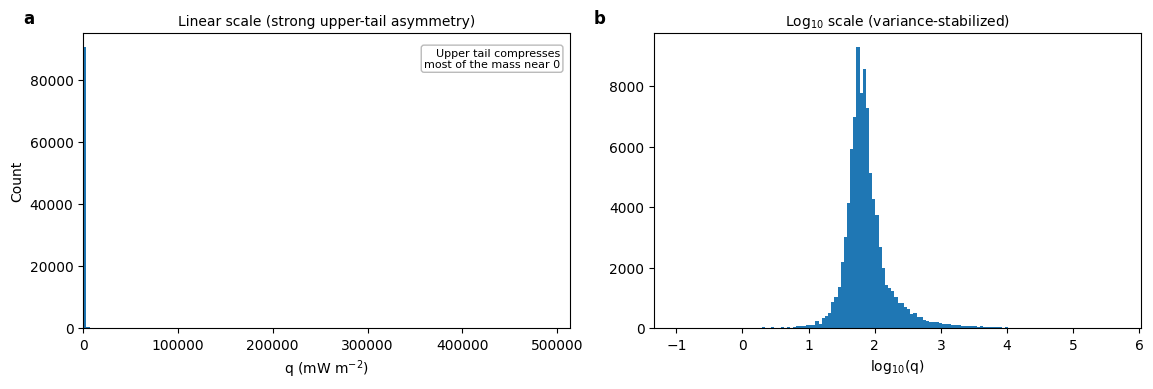

[SAVE] SM3 (canonical) → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_methods\fig_SM3_q_logq_distributions.png
[SAVE] SM3 (canonical) → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_methods\fig_SM3_q_logq_distributions.pdf
[SAVE] SM3 (qa0 copy)  → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\qa0\qa0_q_logq_distributions.png
[SAVE] SM3 (qa0 copy)  → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\qa0\qa0_q_logq_distributions.pdf

[QA-0] Extreme values: top 1% threshold = 1712.5 mW/m² | rows=911
              lon        lat         q     log_q  dist_gem_km  dist_pb_km  \
88126 -127.786400  47.710000  489000.0  5.689309   151.967114  128.226382   
88093 -127.786800  47.709300  425000.0  5.628389   152.075144  128.184459   
88145 -127

In [6]:
# ==============================================================
# Snippet 6 — QA-0 Global Diagnostics + Structural characterization (PRE-DECISION)
#
# Purpose:
#   Single pre-decision global QA + descriptive structural context (NO CUTOFFS).
#   This is ONE canonical QA block (do not duplicate elsewhere).
#
# Guarantees:
#   - No distance cutoff is selected here.
#   - No heat-flow threshold is defined here.
#
# Inputs:
#   gdf_all (GeoDataFrame) with columns (minimum required):
#     q, log_q, dist_gem_km, dist_pb_km, dist_min_km, geometry
#
#   NOTE:
#     - lon/lat are NOT required inputs anymore. If missing, they are derived
#       deterministically from geometry in WGS84.
#
# Outputs (versioned; Snippet 2-consistent):
#   DIAG_DIR/qa0/qa0_distance_quantiles.csv
#   DIAG_DIR/qa0/qa0_share_by_distmin_bins.csv
#   DIAG_DIR/qa0/qa0_distance_metric_agreement.txt
#   DIAG_DIR/qa0/qa0_q_logq_moments.csv
#   FIG_SM_DIR/fig_SM3_q_logq_distributions.(png)     (SM3; preferred)
#     fallback: DIAG_DIR/qa0/qa0_q_logq_distributions.png
#   DIAG_DIR/qa0/qa0_extreme_values_top1pct.csv
#   DIAG_DIR/qa0/qa0_regional_summary.csv
#   DIAG_DIR/qa0/qa0_descriptive_loglog_slopes.txt
#
# Editorial role:
#   QA / METHODS SUPPORT (pre-decision; no protocol parameter selection)
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from scipy.special import log_ndtr  # stable log tail for Normal

# -------------------------------
# Preconditions
# -------------------------------
assert "gdf_all" in globals(), "gdf_all must be loaded before this QA snippet."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."
assert "DIAG_DIR" in globals(), "DIAG_DIR must be defined (Snippet 2)."
assert "CRS_WGS84" in globals(), "CRS_WGS84 must be defined (Snippet 2)."

req = {"q", "log_q", "dist_gem_km", "dist_pb_km", "dist_min_km", "geometry"}
missing = req - set(gdf_all.columns)
assert not missing, f"Missing required columns in gdf_all: {missing}"

# -------------------------------
# Output directory (Snippet 2-consistent)
# -------------------------------
OUT = Path(DIAG_DIR) / "qa0"
OUT.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Ensure lon/lat exist (derived; do NOT hard fail on legacy omission)
# -------------------------------
gdf = gdf_all.copy()

# Ensure geometry is in WGS84 for lon/lat derivation
try:
    if gdf.crs is None:
        gdf = gdf.set_crs(CRS_WGS84, allow_override=True)
    else:
        gdf = gdf.to_crs(CRS_WGS84)
except Exception as e:
    raise RuntimeError(f"Failed to enforce WGS84 for geometry: {repr(e)}")

if ("lon" not in gdf.columns) or ("lat" not in gdf.columns):
    gdf["lon"] = gdf.geometry.x
    gdf["lat"] = gdf.geometry.y

# -------------------------------
# Helpers: p-values that never underflow to 0.0
# -------------------------------
def _log10p_two_sided_from_z(z: float) -> float:
    """
    Two-sided p-value for a Normal tail computed in log-space:
      p = 2 * Phi(-|z|)
    Returns log10(p), stable for extremely small p.
    """
    lp = np.log(2.0) + log_ndtr(-abs(float(z)))  # ln(p)
    return float(lp / np.log(10.0))

def _p_display_from_log10(log10_p: float) -> str:
    """
    Publication-safe display:
      - if p < 1e-4 -> show threshold '< 1eK'
      - else -> show numeric p with 3 sig figs
    """
    if not np.isfinite(log10_p):
        return "NA"
    if log10_p <= -4:
        return f"< 1e{int(np.floor(log10_p))}"
    return f"{10.0**log10_p:.3g}"

def _t_from_r(r: float, n: int) -> float:
    """
    Exact t-statistic for testing correlation (H0: r=0):
      t = |r| * sqrt((n-2)/(1-r^2))
    """
    r = float(np.clip(r, -1.0, 1.0))
    denom = max(1e-300, (1.0 - r*r))
    return abs(r) * np.sqrt(max(1, n - 2) / denom)

# -------------------------------
# Clean frames
# -------------------------------
dfd = (
    gdf[["dist_gem_km", "dist_pb_km", "dist_min_km"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
assert len(dfd) > 100, f"Not enough valid distance rows for QA (n={len(dfd)})."

dfq = gdf[["q", "log_q"]].replace([np.inf, -np.inf], np.nan).dropna()
dfq = dfq[dfq["q"] > 0].copy()
assert len(dfq) > 100, f"Not enough valid q rows for QA (n={len(dfq)})."

N_QA0 = int(len(dfq))  # should be 91,059 after physical validity
print(f"\n[OK] Snippet 6 QA-0 starting | N (q>0) = {N_QA0:,}")

# ==============================================================
# 1) Distance quantiles + coarse bin shares (QA only)
# ==============================================================
print("\n[QA-0] Distance quantiles (km) — inspection only")
qnts = dfd.quantile([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(3)
print(qnts)
qnts.to_csv(OUT / "qa0_distance_quantiles.csv")

DIST_BINS = [0, 10, 25, 50, 100, 150, 250, 500, 1000, 2000, 4000, 20000]
tmp = gdf[["dist_min_km"]].replace([np.inf, -np.inf], np.nan).dropna()
tmp["distbin_min"] = pd.cut(tmp["dist_min_km"], DIST_BINS, right=False)

share_min = (
    tmp["distbin_min"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
share_min.name = "proportion"

print("\n[QA-0] Share by dist_min bins (%) — inspection only")
print(share_min)
share_min.to_csv(OUT / "qa0_share_by_distmin_bins.csv")

# ==============================================================
# 2) Distance metric agreement: GEM vs PB2002 (p-safe)
# ==============================================================
x = dfd["dist_gem_km"].to_numpy(float)
y = dfd["dist_pb_km"].to_numpy(float)
m = np.isfinite(x) & np.isfinite(y)
x = x[m]; y = y[m]
n_pair = int(x.size)

sp_r, _ = spearmanr(x, y)
pe_r, _ = pearsonr(x, y)

sp_log10p = _log10p_two_sided_from_z(_t_from_r(sp_r, n_pair))
pe_log10p = _log10p_two_sided_from_z(_t_from_r(pe_r, n_pair))

print("\n[QA-0] Distance metric agreement (GEM vs PB)")
print(f"  Spearman: r={sp_r:.4f} | p {_p_display_from_log10(sp_log10p)} (log10 p={sp_log10p:.1f}) | n={n_pair}")
print(f"  Pearson : r={pe_r:.4f} | p {_p_display_from_log10(pe_log10p)} (log10 p={pe_log10p:.1f}) | n={n_pair}")

with open(OUT / "qa0_distance_metric_agreement.txt", "w", encoding="utf-8") as f:
    f.write(f"Spearman GEM vs PB: r={sp_r:.6f}, log10_p={sp_log10p:.3f}, n={n_pair}\n")
    f.write(f"Pearson  GEM vs PB: r={pe_r:.6f}, log10_p={pe_log10p:.3f}, n={n_pair}\n")

# ==============================================================
# 3) Heat-flow distribution QA (no thresholds)
#    Save to FIG_SM_DIR if available (Snippet 2)
#    Fallback to DIAG_DIR/qa0
#    Still shows on screen (plt.show())
# ==============================================================
mom = pd.DataFrame(
    {
        "skew": [dfq["q"].skew(), dfq["log_q"].skew()],
        "kurtosis": [dfq["q"].kurt(), dfq["log_q"].kurt()],
    },
    index=["q", "log_q"],
).round(3)

print("\n[QA-0] Heat-flow distribution moments (inspection only)")
print(mom)
mom.to_csv(OUT / "qa0_q_logq_moments.csv")

# Preferred: Supplementary Methods figures folder
if "FIG_SM_DIR" in globals() and FIG_SM_DIR is not None:
    _sm_dir = Path(FIG_SM_DIR)
else:
    _sm_dir = OUT  # fallback

_sm_dir.mkdir(parents=True, exist_ok=True)

# Canonical SM2 naming (keep also the QA filename as a fallback copy if you want)
FIG_SM3_CANON = _sm_dir / "fig_SM3_q_logq_distributions.png"
FIG_SM3_QA    = OUT / "qa0_q_logq_distributions.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dfq["q"].to_numpy(float), bins=140)
axes[0].set_title("Linear scale (strong upper-tail asymmetry)", fontsize=10)
axes[0].set_xlabel("q (mW m$^{-2}$)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(left=0)

axes[0].text(
    0.98, 0.95,
    "Upper tail compresses\nmost of the mass near 0",
    transform=axes[0].transAxes,
    ha="right", va="top",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.9),
)

axes[1].hist(dfq["log_q"].to_numpy(float), bins=140)
axes[1].set_title("Log$_{10}$ scale (variance-stabilized)", fontsize=10)
axes[1].set_xlabel("log$_{10}$(q)")

# Panel labels: lowercase, left side of each panel
axes[0].text(
    -0.10, 1.02, "a",
    transform=axes[0].transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

axes[1].text(
    -0.10, 1.02, "b",
    transform=axes[1].transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

fig.tight_layout(rect=[0.03, 0, 1, 1])

# Canonical paths (Supplementary Methods)
FIG_SM3_CANON_PNG = _sm_dir / "fig_SM3_q_logq_distributions.png"
FIG_SM3_CANON_PDF = _sm_dir / "fig_SM3_q_logq_distributions.pdf"

# QA-local copies (diagnostic archive)
FIG_SM3_QA_PNG = OUT / "qa0_q_logq_distributions.png"
FIG_SM3_QA_PDF = OUT / "qa0_q_logq_distributions.pdf"

# Save canonical
fig.savefig(FIG_SM3_CANON_PNG, dpi=150, bbox_inches="tight")
fig.savefig(FIG_SM3_CANON_PDF, bbox_inches="tight")

# Save QA copies
fig.savefig(FIG_SM3_QA_PNG, dpi=150, bbox_inches="tight")
fig.savefig(FIG_SM3_QA_PDF, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"[SAVE] SM3 (canonical) → {FIG_SM3_CANON_PNG}")
print(f"[SAVE] SM3 (canonical) → {FIG_SM3_CANON_PDF}")
print(f"[SAVE] SM3 (qa0 copy)  → {FIG_SM3_QA_PNG}")
print(f"[SAVE] SM3 (qa0 copy)  → {FIG_SM3_QA_PDF}")

# ==============================================================
# 4) Extreme values table (inspection only)
# ==============================================================
top1_cut = float(dfq["q"].quantile(0.99))
tab_ext = (
    gdf.loc[gdf["q"] >= top1_cut,
            ["lon", "lat", "q", "log_q", "dist_gem_km", "dist_pb_km", "dist_min_km"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["q", "dist_min_km"])
    .sort_values("q", ascending=False)
)

print(f"\n[QA-0] Extreme values: top 1% threshold = {top1_cut:.1f} mW/m² | rows={len(tab_ext):,}")
print(tab_ext.head(10))
tab_ext.to_csv(OUT / "qa0_extreme_values_top1pct.csv", index=False)

# ==============================================================
# 5) Regional descriptive contrasts (descriptive; no decisions)
# ==============================================================
regions = {
    "Americas": (-180, -30),
    "Eurasia":  (-30, 150),
    "Oceania":  (150, 180),
}
rows = []
for name, (lo, hi) in regions.items():
    sub = gdf[(gdf["lon"] >= lo) & (gdf["lon"] < hi)]
    rows.append({
        "Region": name,
        "N": int(len(sub)),
        "q_median": float(sub["q"].median()),
        "q_p90": float(sub["q"].quantile(0.90)),
        "logq_median": float(sub["log_q"].median()),
        "dist_min_median": float(sub["dist_min_km"].median()),
    })

regional = pd.DataFrame(rows)
print("\n[QA-0] Regional summary (descriptive)")
print(regional)
regional.to_csv(OUT / "qa0_regional_summary.csv", index=False)

# ==============================================================
# 6) Descriptive log–log slopes (context only; not a decision)
# ==============================================================
lines = []
for label, dcol in [("GEM", "dist_gem_km"), ("PB2002", "dist_pb_km"), ("MIN", "dist_min_km")]:
    dfp = (
        gdf[[dcol, "q"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    dfp = dfp[(dfp[dcol] > 0) & (dfp["q"] > 0)].copy()
    lx = np.log10(dfp[dcol].to_numpy(float))
    ly = np.log10(dfp["q"].to_numpy(float))
    slope, intercept = np.polyfit(lx, ly, 1)
    msg = f"{label}: log10(q) = {slope:.4f} * log10({dcol}) + {intercept:.4f}"
    lines.append(msg)
    print(f"[QA-0] {msg}")

with open(OUT / "qa0_descriptive_loglog_slopes.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

print("\n[SAVED] QA-0 merged diagnostics completed (single execution, no cutoffs).")

# Snippet 7 — Distance-regime analysis & cutoff sensitivity (DECISION)

[OK] Snippet 7 starting | N(valid q, dist) = 91,059

[Distance-band statistics]
    band_km      N  q_median  q_p90     q_iqr  spearman_q_dist
0      0-50  27126      84.0  459.0  114.0000         0.040213
1    50-100   9231      76.0  222.0   68.7496        -0.087959
2   100-150   6703      76.0  233.0   75.0000         0.081870
3   150-300  10450      70.2  126.0   48.0000        -0.096915
4  300-1000  21554      61.0  100.0   28.0000        -0.116153


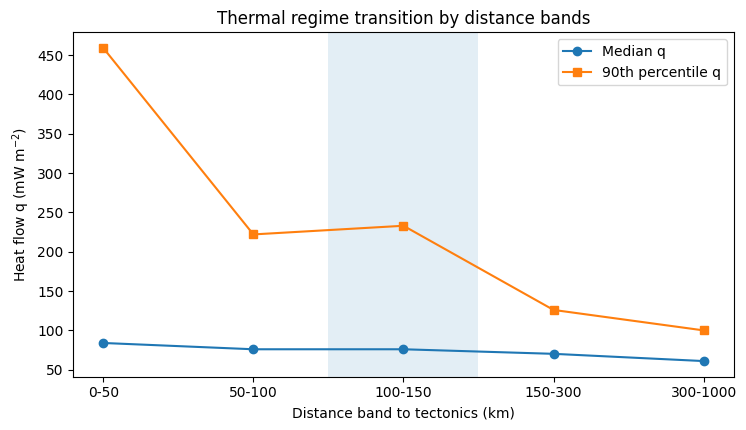


[Cutoff sensitivity]
   cutoff_km      N  q_median       q_p90  spearman_q_dist
0         80  57899      61.0  113.613555        -0.258602
1         90  56098      61.0  112.500000        -0.261463
2        100  54702      61.0  111.000000        -0.262312
3        110  53420      61.0  110.900000        -0.273980
4        125  51516      60.0  109.000000        -0.272232
5        150  47999      59.4  103.000000        -0.242999
6        175  45380      59.0  100.000000        -0.230983


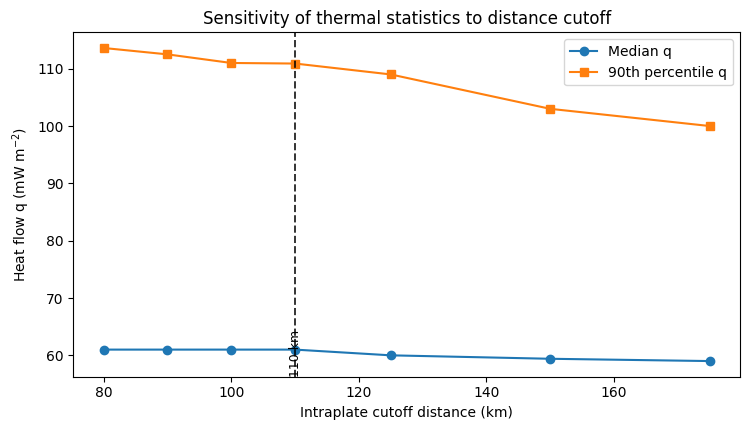


[Bootstrap robustness — key cutoffs]
   cutoff_km      N  median_q  median_q_ci95_lo  median_q_ci95_hi  p90_q  \
0        100  54702      61.0         60.332600           61.0000  111.0   
1        110  53420      61.0         60.316993           61.0000  110.9   
2        125  51516      60.0         60.000000           60.7025  109.0   

   p90_q_ci95_lo  p90_q_ci95_hi  
0     110.197786     112.000000  
1     110.000000     111.838928  
2     108.000000     109.700000  

[SAVED] Distance-regime and cutoff sensitivity diagnostics completed.
[SAVED] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\distance_cutoff\distance_band_stats.csv
[SAVED] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\distance_cutoff\cutoff_sensitivity_table.csv
[SAVED] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics

In [7]:
# ==============================================================
# Snippet 7 — Distance-regime analysis & cutoff sensitivity (DECISION)
#
# Purpose:
#   Provide the empirical basis for selecting the intraplate distance cutoff
#   (e.g., 110 km) BEFORE defining the canonical intraplate dataset (Figure 1).
#
#   This snippet:
#     1) Quantifies thermal statistics across distance bands (regime transition)
#     2) Tests sensitivity of key thermal statistics to candidate cutoffs
#     3) Adds simple bootstrap 95% CIs for robustness (minimal)
#
# Inputs (from Snippet 3):
#   gdf_all with columns:
#     - q (mW m^-2), dist_min_km (km)
#
# Outputs (versioned; Snippet 2-consistent):
#   DIAG_DIR/distance_cutoff/distance_band_stats.csv
#   DIAG_DIR/distance_cutoff/cutoff_sensitivity_table.csv
#   DIAG_DIR/distance_cutoff/cutoff_sensitivity_bootstrap_ci.csv
#   DIAG_DIR/distance_cutoff/fig_distance_band_transition.png
#   DIAG_DIR/distance_cutoff/fig_cutoff_sensitivity.png
#
# Side effects (protocol registry; derived/selected here):
#   PARAMS["DIST_CUTOFF_KM"] = selected cutoff (default set to 110.0 at end)
#
# Editorial role:
#   DECISION
#   Formal justification of the intraplate distance cutoff.
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Preconditions
# -------------------------------
assert "gdf_all" in globals(), "gdf_all not found. Run Snippet 3 first."
assert "DIAG_DIR" in globals(), "DIAG_DIR must be defined (Snippet 2)."
assert "PARAMS" in globals(), "PARAMS must be defined (Snippet 2)."

req = {"q", "dist_min_km"}
missing = req - set(gdf_all.columns)
assert not missing, f"Missing required columns in gdf_all: {missing}"

# -------------------------------
# Output directory (Snippet 2-consistent)
# -------------------------------
OUT = Path(DIAG_DIR) / "distance_cutoff"
OUT.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Clean working frame (validity only)
# -------------------------------
df = gdf_all[["q", "dist_min_km"]].copy()
df["q"] = pd.to_numeric(df["q"], errors="coerce")
df["dist_min_km"] = pd.to_numeric(df["dist_min_km"], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", "dist_min_km"])
df = df[(df["q"] > 0) & (df["dist_min_km"] >= 0)].copy()

assert len(df) > 1000, f"Not enough valid rows for cutoff decision analysis (n={len(df)})."
print(f"[OK] Snippet 7 starting | N(valid q, dist) = {len(df):,}")

# -------------------------------
# Helpers
# -------------------------------
def robust_spearman(x: pd.Series, y: pd.Series) -> float:
    # local import to avoid hard dependency if scipy missing
    try:
        from scipy.stats import spearmanr
        r = spearmanr(x, y).correlation
        return float(r) if np.isfinite(r) else float("nan")
    except Exception:
        # fallback: Pearson on ranks (approx Spearman)
        xr = pd.Series(x).rank(method="average").to_numpy(float)
        yr = pd.Series(y).rank(method="average").to_numpy(float)
        r = np.corrcoef(xr, yr)[0, 1]
        return float(r) if np.isfinite(r) else float("nan")

def bootstrap_ci(arr: np.ndarray, stat_fn, n_boot: int = 200, seed: int = 42) -> tuple:
    rng = np.random.default_rng(seed)
    n = int(len(arr))
    if n < 50:
        return (np.nan, np.nan)
    stats = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = arr[rng.integers(0, n, size=n)]
        stats[i] = float(stat_fn(samp))
    lo, hi = np.quantile(stats, [0.025, 0.975])
    return (float(lo), float(hi))

# ==============================================================
# 1) Distance-band regime analysis (SM3)
# ==============================================================
DIST_BANDS = [(0, 50), (50, 100), (100, 150), (150, 300), (300, 1000)]
rows = []

for lo, hi in DIST_BANDS:
    sub = df[(df["dist_min_km"] >= lo) & (df["dist_min_km"] < hi)]
    if len(sub) < 200:
        continue
    qv = sub["q"].to_numpy(float)
    rows.append({
        "band_km": f"{lo}-{hi}",
        "N": int(len(sub)),
        "q_median": float(np.median(qv)),
        "q_p90": float(np.quantile(qv, 0.90)),
        "q_iqr": float(np.quantile(qv, 0.75) - np.quantile(qv, 0.25)),
        "spearman_q_dist": robust_spearman(sub["q"], sub["dist_min_km"]),
    })

band_df = pd.DataFrame(rows)
BAND_CSV = OUT / "distance_band_stats.csv"
band_df.to_csv(BAND_CSV, index=False)

print("\n[Distance-band statistics]")
print(band_df)

# --- Plot band transition (SAVE + SHOW) ---
labels = band_df["band_km"].tolist()
xpos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7.6, 4.4))

ax.plot(xpos, band_df["q_median"].values, marker="o", label="Median q")
ax.plot(xpos, band_df["q_p90"].values, marker="s", label="90th percentile q")

ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_xlabel("Distance band to tectonics (km)")
ax.set_ylabel("Heat flow q (mW m$^{-2}$)")
ax.set_title("Thermal regime transition by distance bands")

# Highlight the transition band 100–150 km (subtle)
if "100-150" in labels:
    i = labels.index("100-150")
    ax.axvspan(i - 0.5, i + 0.5, alpha=0.12)

# Reference line at 110 km (protocol candidate)
# NOTE: keep as a reference marker; decision is justified by the tables/plots.
ax.axhline(ax.get_ylim()[0], alpha=0.0)  # stabilize ylim access
ax.axvline(xpos[0] if len(xpos) else 0, alpha=0.0)  # no-op for safety
ax.axvline(2 if "100-150" in labels else 0, alpha=0.0)  # no-op

# draw 110 km as a label near the highlighted band
# (We do NOT convert 110 to an x-position; it belongs to the cutoff plot below.)
ax.legend()
fig.tight_layout()

# --- Figure 1 canonical path (Main Text) ---
_main_dir = Path(globals().get("FIG_DIR", OUT)).resolve()
_main_dir.mkdir(parents=True, exist_ok=True)

OUT_F1_PNG = _main_dir / "fig1_thermal_regime_transition.png"
OUT_F1_PDF = _main_dir / "fig1_thermal_regime_transition.pdf"

# Keep QA-local copy too (optional but safe)
OUT_F1_QA_PNG = OUT / "fig_distance_band_transition.png"
OUT_F1_QA_PDF = OUT / "fig_distance_band_transition.pdf"

fig.savefig(OUT_F1_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OUT_F1_PDF, bbox_inches="tight")

fig.savefig(OUT_F1_QA_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OUT_F1_QA_PDF, bbox_inches="tight")

plt.show()
plt.close(fig)

# ==============================================================
# 2) Cutoff sensitivity analysis (point estimates)
# ==============================================================
CUTOFFS = [80, 90, 100, 110, 125, 150, 175]
rows = []

for cut in CUTOFFS:
    sub = df[df["dist_min_km"] >= float(cut)]
    if len(sub) < 1000:
        continue
    qv = sub["q"].to_numpy(float)
    rows.append({
        "cutoff_km": int(cut),
        "N": int(len(sub)),
        "q_median": float(np.median(qv)),
        "q_p90": float(np.quantile(qv, 0.90)),
        "spearman_q_dist": robust_spearman(sub["q"], sub["dist_min_km"]),
    })

sens_df = pd.DataFrame(rows)
SENS_CSV = OUT / "cutoff_sensitivity_table.csv"
sens_df.to_csv(SENS_CSV, index=False)

print("\n[Cutoff sensitivity]")
print(sens_df)

# --- Plot sensitivity (SAVE + SHOW) ---
fig, ax = plt.subplots(figsize=(7.6, 4.4))

ax.plot(sens_df["cutoff_km"].values, sens_df["q_median"].values, marker="o", label="Median q")
ax.plot(sens_df["cutoff_km"].values, sens_df["q_p90"].values, marker="s", label="90th percentile q")

# Protocol cutoff reference (110 km)
ax.axvline(110, ls="--", lw=1.4, color="black", alpha=0.8)
ax.text(110, ax.get_ylim()[0], "110 km", ha="center", va="bottom", fontsize=9, rotation=90)

ax.set_xlabel("Intraplate cutoff distance (km)")
ax.set_ylabel("Heat flow q (mW m$^{-2}$)")
ax.set_title("Sensitivity of thermal statistics to distance cutoff")
ax.legend()

fig.tight_layout()

# --- SM2 canonical path (Supplementary Methods) ---
_main_dir = Path(globals().get("FIG_DIR", OUT)).resolve()
_main_dir.mkdir(parents=True, exist_ok=True)

OUT_F2_PNG = _sm_dir / "fig_SM2_cutoff_sensitivity.png"
OUT_F2_PDF = _sm_dir / "fig_SM2_cutoff_sensitivity.pdf"

# Keep QA-local copy too (optional but safe)
OUT_F2_QA_PNG = OUT / "fig_cutoff_sensitivity.png"
OUT_F2_QA_PDF = OUT / "fig_cutoff_sensitivity.pdf"

fig.savefig(OUT_F2_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OUT_F2_PDF, bbox_inches="tight")

fig.savefig(OUT_F2_QA_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OUT_F2_QA_PDF, bbox_inches="tight")

plt.show()
plt.close(fig)

# ==============================================================
# 3) Bootstrap CIs for key cutoffs (robustness)
# ==============================================================
KEY_CUTOFFS = [100, 110, 125]
N_BOOT = 200  # minimal, fast

rows = []
for cut in KEY_CUTOFFS:
    sub = df[df["dist_min_km"] >= float(cut)]
    if len(sub) < 1000:
        continue
    qv = sub["q"].to_numpy(float)

    med = float(np.median(qv))
    p90 = float(np.quantile(qv, 0.90))

    med_ci = bootstrap_ci(qv, stat_fn=np.median, n_boot=N_BOOT, seed=42 + int(cut))
    p90_ci = bootstrap_ci(qv, stat_fn=lambda a: np.quantile(a, 0.90), n_boot=N_BOOT, seed=4242 + int(cut))

    rows.append({
        "cutoff_km": int(cut),
        "N": int(len(sub)),
        "median_q": med,
        "median_q_ci95_lo": med_ci[0],
        "median_q_ci95_hi": med_ci[1],
        "p90_q": p90,
        "p90_q_ci95_lo": p90_ci[0],
        "p90_q_ci95_hi": p90_ci[1],
    })

ci_df = pd.DataFrame(rows)
CI_CSV = OUT / "cutoff_sensitivity_bootstrap_ci.csv"
ci_df.to_csv(CI_CSV, index=False)

print("\n[Bootstrap robustness — key cutoffs]")
print(ci_df)

print("\n[SAVED] Distance-regime and cutoff sensitivity diagnostics completed.")
print(f"[SAVED] {BAND_CSV}")
print(f"[SAVED] {SENS_CSV}")
print(f"[SAVED] {CI_CSV}")
print(f"[SAVED] {OUT_F1_PNG}")
print(f"[SAVED] {OUT_F1_PDF}")
print(f"[SAVED] {OUT_F2_PNG}")
print(f"[SAVED] {OUT_F2_PDF}")

# ---- DECISION OUTPUT (selected cutoff; change ONLY if Snippet 7 evidence supports it) ----
PARAMS["DIST_CUTOFF_KM"] = 110.0
print("[PARAMS] DIST_CUTOFF_KM =", f"{PARAMS['DIST_CUTOFF_KM']:.1f}")

# Snippet 8 — Scale and model-form diagnostics (DECISION)

In [8]:
# ==============================================================
# Snippet 8 — Scale and model-form diagnostics (DECISION)  - FIXED (+1 km log-distance)
#
# Key fix:
#   - Use log10(dist_min_km + 1.0) to avoid log10(0) and preserve zero-distance cases.
#   - Validity filters now allow dist_min_km >= 0 (instead of > 0).
#
# Purpose:
#   Decide, empirically and explicitly:
#     • q vs log10(q)
#     • distance (km) vs log10(distance)
#
#   This snippet evaluates correlation strength and regression
#   performance under different transformations, both:
#     • globally
#     • in the intraplate regime (dist_min_km ≥ DIST_CUTOFF_KM km)
#
#   NO filtering decisions are made here (beyond validity: q>0, dist>=0).
#   NO maps are produced here (only a small diagnostics figure).
#
# Inputs:
#   gdf_all with columns: q, dist_min_km
#   PARAMS["DIST_CUTOFF_KM"] (from Snippet 7)
#
# Outputs (versioned; Snippet 2-consistent):
#   DIAG_DIR/scale_choice/scale_choice_correlations.csv
#   DIAG_DIR/scale_choice/scale_choice_regressions.csv
#   DIAG_DIR/scale_choice/fig_scale_choice_r2.png
#
# Editorial role:
#   DECISION
#   Defines analytical scale and model form (based on diagnostics).
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------
# Preconditions
# -------------------------------
assert "gdf_all" in globals(), "gdf_all must be loaded (Snippet 3)."
assert "require_param" in globals(), "require_param must be defined (Snippet 2)."
assert "DIAG_DIR" in globals(), "DIAG_DIR must be defined (Snippet 2)."

req = {"q", "dist_min_km"}
missing = req - set(gdf_all.columns)
assert not missing, f"Missing required columns: {missing}"

CUT_KM = float(require_param("DIST_CUTOFF_KM"))

# -------------------------------
# Clean + derived columns (validity only)
# -------------------------------
df = gdf_all.copy()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["q", "dist_min_km"]).copy()

df["q"] = pd.to_numeric(df["q"], errors="coerce")
df["dist_min_km"] = pd.to_numeric(df["dist_min_km"], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", "dist_min_km"]).copy()

# Validity only:
#  - q must be > 0 for log10(q)
#  - dist_min_km can be 0; we use +1.0 for log-distance stability
df = df[(df["q"] > 0) & (df["dist_min_km"] >= 0)].copy()

df["log_q"] = np.log10(df["q"])
df["log_dist"] = np.log10(df["dist_min_km"] + 1.0)

print(f"[OK] Snippet 8 starting | N(valid q>0, dist>=0) = {len(df):,} | CUT_KM={CUT_KM:.1f}")

# -------------------------------
# Output directory (Snippet 2-consistent)
# -------------------------------
OUT = Path(DIAG_DIR) / "scale_choice"
OUT.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Domains
# -------------------------------
domains = {
    "global": df,
    f"intraplate_{int(CUT_KM)}": df[df["dist_min_km"] >= CUT_KM].copy(),
}

# -------------------------------
# Correlation helpers (robust if scipy missing)
# -------------------------------
def _pearson(x, y) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return np.nan
    r = np.corrcoef(x, y)[0, 1]
    return float(r) if np.isfinite(r) else np.nan

def _spearman(x, y) -> float:
    try:
        from scipy.stats import spearmanr
        r = spearmanr(x, y).correlation
        return float(r) if np.isfinite(r) else np.nan
    except Exception:
        xr = pd.Series(x).rank(method="average").to_numpy(float)
        yr = pd.Series(y).rank(method="average").to_numpy(float)
        return _pearson(xr, yr)

# -------------------------------
# 1) Correlation diagnostics
# -------------------------------
corr_rows = []

for name, sub in domains.items():
    if len(sub) < 50:
        print(f"[WARN] Domain '{name}' too small (n={len(sub)}). Skipping.")
        continue

    for x_lab, x in [("dist", sub["dist_min_km"]), ("log_dist", sub["log_dist"])]:
        for y_lab, y in [("q", sub["q"]), ("log_q", sub["log_q"])]:
            corr_rows.append({
                "domain": name,
                "x": x_lab,
                "y": y_lab,
                "spearman_r": _spearman(x, y),
                "pearson_r": _pearson(x, y),
                "n": int(len(sub)),
            })

corr_df = pd.DataFrame(corr_rows)
CORR_CSV = OUT / "scale_choice_correlations.csv"
corr_df.to_csv(CORR_CSV, index=False)

print("\n[Scale-choice correlations]")
print(corr_df)

# -------------------------------
# 2) Regression diagnostics (OLS HC3)
# -------------------------------
import statsmodels.api as sm

def fit_ols_hc3(y: pd.Series, x: pd.Series) -> dict:
    X = sm.add_constant(pd.Series(x, index=y.index))
    m = sm.OLS(y, X).fit(cov_type="HC3")
    return {
        "slope": float(m.params.iloc[1]),
        "p_value": float(m.pvalues.iloc[1]),
        "r2": float(m.rsquared),
        "n": int(m.nobs),
    }

model_order = ["q_vs_dist", "q_vs_log_dist", "log_q_vs_dist", "log_q_vs_log_dist"]
reg_rows = []

for name, sub in domains.items():
    if len(sub) < 50:
        continue

    models = {
        "q_vs_dist": (sub["q"], sub["dist_min_km"]),
        "q_vs_log_dist": (sub["q"], sub["log_dist"]),          # log10(dist+1)
        "log_q_vs_dist": (sub["log_q"], sub["dist_min_km"]),
        "log_q_vs_log_dist": (sub["log_q"], sub["log_dist"]),  # log10(dist+1)
    }

    for label in model_order:
        y, x = models[label]
        res = fit_ols_hc3(y, x)
        reg_rows.append({"domain": name, "model": label, **res})

reg_df = pd.DataFrame(reg_rows)
REG_CSV = OUT / "scale_choice_regressions.csv"
reg_df.to_csv(REG_CSV, index=False)

print("\n[Scale-choice regression comparison]")
print(reg_df)

# -------------------------------
# 3) Summary plot (R² comparison)
# -------------------------------
fig, ax = plt.subplots(figsize=(7.8, 4.4))

xpos = np.arange(len(model_order))
plotted_any = False

for name in domains.keys():
    sub = reg_df[reg_df["domain"] == name].copy()
    if sub.empty:
        continue
    sub = sub.set_index("model").reindex(model_order)
    ax.plot(xpos, sub["r2"].to_numpy(float), marker="o", label=name)
    plotted_any = True

ax.set_ylabel("R² (OLS HC3)")
ax.set_title("Model performance by scale and domain")
ax.set_xticks(xpos)
ax.set_xticklabels(model_order, rotation=25, ha="right")
ax.legend()
fig.tight_layout()

FIG_PATH = OUT / "fig_scale_choice_r2.png"
fig.savefig(FIG_PATH, dpi=200, bbox_inches="tight")
plt.close(fig)

# -------------------------------
# Report (no auto-picking)
# -------------------------------
print("\n[SAVED] Scale and model-form diagnostics completed.")
print(f"[SAVED] {CORR_CSV}")
print(f"[SAVED] {REG_CSV}")
if plotted_any:
    print(f"[SAVED] {FIG_PATH}")
else:
    print("[WARN] No domains plotted (likely insufficient rows).")

print("\n[DECISION NOTE]")
print("Inspect the correlation and regression tables to select the model form.")
print("This snippet does NOT auto-select or write a final model choice into PARAMS.")
print("log10(distance) uses log10(dist_min_km + 1.0) for numerical stability (includes dist=0).")

[OK] Snippet 8 starting | N(valid q>0, dist>=0) = 91,059 | CUT_KM=110.0

[Scale-choice correlations]
           domain         x      y  spearman_r  pearson_r      n
0          global      dist      q   -0.317022  -0.022180  91059
1          global      dist  log_q   -0.317022  -0.216023  91059
2          global  log_dist      q   -0.317022  -0.027533  91059
3          global  log_dist  log_q   -0.317022  -0.295073  91059
4  intraplate_110      dist      q   -0.273980  -0.016896  53420
5  intraplate_110      dist  log_q   -0.273980  -0.168759  53420
6  intraplate_110  log_dist      q   -0.273980  -0.030210  53420
7  intraplate_110  log_dist  log_q   -0.273980  -0.244006  53420

[Scale-choice regression comparison]
           domain              model       slope        p_value        r2  \
0          global          q_vs_dist   -0.094900   2.439206e-41  0.000492   
1          global      q_vs_log_dist -112.781461   3.284729e-73  0.000758   
2          global      log_q_vs_dist   -0.000

# Snippet 9 — Canonical intraplate dataset

Pipeline overview (context for Snippet 9):

(raw IHFC, GEM, PB2002) -> distance computation and global QA
-> protocol-defined intraplate dataset
-> [CANONICAL EXPORT]
-> df_k_canon.csv + df_k_fingerprint_principal.json
-> load_df_k_canon()
-> regressions, robustness analyses, QA screening, clustering diagnostics, maps, and freeze manifest

[FREEZE] df_all_snapshot.csv created → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\df_all_snapshot.csv | shape=(91059, 6)
[INFO] Canonical intraplate N = 53,420 | cutoff = 110.0 km
[FREEZE] df_k_canon saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\df_k_canon.csv
[FREEZE] fingerprint saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\df_k_fingerprint_principal.json
[FREEZE] sha256 = ac586408d3e1d50ab488126369d64bf8ad9549d59df88057be12fc4fcde4dfc7


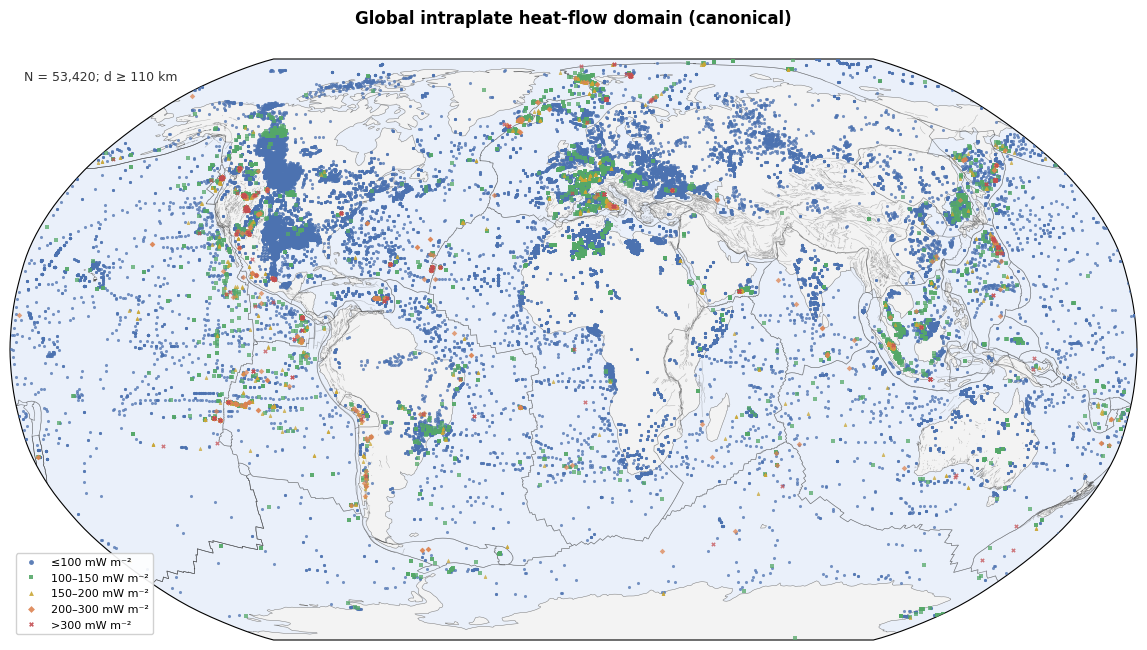

[FIG] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig2_intraplate_domain_q.png
[FIG] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig2_intraplate_domain_q.pdf


In [9]:
# ==============================================================
# Snippet 9 — Canonical intraplate dataset (pre-clustering)
#              + Figure (global intraplate heat-flow map)
# ==============================================================
# Purpose:
#   1) Define and FREEZE the canonical intraplate analysis domain
#      used throughout the clustering and QA pipeline.
#   2) Produce the global intraplate heat-flow map (Figure 2),
#      using robust color scaling and a publication-ready layout.
#
# Scientific role:
#   - Establishes the spatial + physical domain BEFORE any
#     clustering or outlier protocol is applied.
#   - Ensures deterministic reproducibility of the intraplate
#     dataset via sorted CSV + SHA-256 fingerprint.
#
# Inputs (required):
#   - Primary path: OUT_DIR/df_all_snapshot.csv
#   - Fallback: gdf_all in memory (from Snippet 3)
#   - GEM_SHP    : GEM Global Active Faults path.
#   - PB2002_SHP : PB2002 plate boundary path.
#
# Canonical selection criteria:
#   - q > 0
#   - dist_min_km ≥ DIST_CUTOFF_KM (from PARAMS; default=110 km)
#   - Finite values for {lat, lon, q, dist_min_km, dist_gem_km, dist_pb_km}
#
# Outputs (frozen datasets):
#   - OUT_DIR/df_all_snapshot.csv (only if missing; frozen from gdf_all)
#   - OUT_DIR/df_k_canon.csv
#   - OUT_DIR/df_k_fingerprint_principal.json
#
# Outputs (figures; versioned):
#   - FIG_DIR/fig2_intraplate_domain_q.png
#   - FIG_DIR/fig2_intraplate_domain_q.pdf
# ==============================================================

from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# -------------------------------
# Preconditions (Snippet 2)
# -------------------------------
assert "OUT_DIR" in globals(), "OUT_DIR must be defined (Snippet 2)."
assert "FIG_DIR" in globals(), "FIG_DIR must be defined (Snippet 2)."
assert "PARAMS" in globals(), "PARAMS must be defined (Snippet 2)."
assert "require_param" in globals(), "require_param must be defined (Snippet 2)."
assert "GEM_SHP" in globals(), "GEM_SHP must be defined (Snippet 2)."
assert "PB2002_SHP" in globals(), "PB2002_SHP must be defined (Snippet 2)."

BASE = Path(OUT_DIR)
BASE.mkdir(parents=True, exist_ok=True)

ALL_PATH = BASE / "df_all_snapshot.csv"
DIST_MIN_EXPECT = float(require_param("DIST_CUTOFF_KM", default=110.0))

KEEP = ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"]

# -------------------------------
# Load snapshot, or build from gdf_all and freeze it (deterministic)
# -------------------------------
def _freeze_df_all_snapshot_from_gdf_all(snapshot_path: Path) -> pd.DataFrame:
    assert "gdf_all" in globals(), "gdf_all must exist in memory to build df_all_snapshot.csv."
    g = gdf_all

    # Accept GeoDataFrame or DataFrame
    df0 = pd.DataFrame(g).copy()

    # If lat/lon not present, try to derive from geometry (WGS84)
    if ("lat" not in df0.columns) or ("lon" not in df0.columns):
        if "geometry" in df0.columns and isinstance(g, gpd.GeoDataFrame):
            gg = g
            if gg.crs is None:
                gg = gg.set_crs(4326, allow_override=True)
            else:
                gg = gg.to_crs(4326)

            df0 = pd.DataFrame(gg.drop(columns=["geometry"], errors="ignore")).copy()
            df0["lon"] = gg.geometry.x
            df0["lat"] = gg.geometry.y
        else:
            # Create placeholders to keep pipeline running, but mapping will drop NaNs later.
            if "lon" not in df0.columns:
                df0["lon"] = np.nan
            if "lat" not in df0.columns:
                df0["lat"] = np.nan

    missing = [c for c in KEEP if c not in df0.columns]
    if missing:
        raise KeyError(f"Cannot freeze df_all_snapshot; missing columns: {missing}")

    out = df0[KEEP].copy()

    # Numeric coercion + finite cleanup
    for c in KEEP:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)

    # Deterministic sort (stable)
    out = out.sort_values(KEEP, kind="mergesort").reset_index(drop=True)

    snapshot_path.write_text(
        out.to_csv(index=False, lineterminator="\n"),
        encoding="utf-8"
    )
    print(f"[FREEZE] df_all_snapshot.csv created → {snapshot_path} | shape={out.shape}")
    return out

if ALL_PATH.exists():
    df_all = pd.read_csv(ALL_PATH)
    print(f"[INFO] Loaded snapshot → {ALL_PATH} | shape={df_all.shape}")
else:
    df_all = _freeze_df_all_snapshot_from_gdf_all(ALL_PATH)

# -------------------------------
# Validate required columns
# -------------------------------
missing_cols = [c for c in KEEP if c not in df_all.columns]
assert not missing_cols, f"Missing required columns in df_all_snapshot: {missing_cols}"

# -------------------------------
# Canonical filter
# -------------------------------
df = (
    df_all[KEEP]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=KEEP)
    .query("q > 0 and dist_min_km >= @DIST_MIN_EXPECT")
    .copy()
)

N_CANON = int(len(df))
print(f"[INFO] Canonical intraplate N = {N_CANON:,} | cutoff = {DIST_MIN_EXPECT:.1f} km")

# -------------------------------
# FREEZE canonical dataset (sorted CSV + SHA-256 fingerprint)
# -------------------------------
CANON_CSV = BASE / "df_k_canon.csv"
FP_JSON   = BASE / "df_k_fingerprint_principal.json"

df_k_canon = (
    df[KEEP]
    .sort_values(KEEP, kind="mergesort")
    .reset_index(drop=True)
)

df_k_canon.to_csv(CANON_CSV, index=False, lineterminator="\n")

sha_now = hashlib.sha256(CANON_CSV.read_bytes()).hexdigest()

fp_payload = {
    "artifact": CANON_CSV.name,
    "sha256": sha_now,
    "n_rows": int(df_k_canon.shape[0]),
    "n_cols": int(df_k_canon.shape[1]),
    "columns": list(df_k_canon.columns),
    "criteria": {
        "q_gt_0": True,
        "dist_min_km_gte": float(DIST_MIN_EXPECT),
        "finite_required_cols": KEEP,
    },
    "source": str(ALL_PATH),
}

FP_JSON.write_text(json.dumps(fp_payload, indent=2), encoding="utf-8")

print(f"[FREEZE] df_k_canon saved → {CANON_CSV}")
print(f"[FREEZE] fingerprint saved → {FP_JSON}")
print(f"[FREEZE] sha256 = {sha_now}")

# -------------------------------
# Discrete heat-flow classes
# -------------------------------
bins = [0, 100, 150, 200, 300, np.inf]
labels = ["≤100 mW m⁻²", "100–150 mW m⁻²", "150–200 mW m⁻²", "200–300 mW m⁻²", ">300 mW m⁻²"]
df["q_class"] = pd.cut(df["q"], bins=bins, labels=labels, include_lowest=True)

STYLE = {
    "≤100 mW m⁻²": dict(color="#4C72B0", marker="o", s=5),
    "100–150 mW m⁻²": dict(color="#55A868", marker="s", s=6),
    "150–200 mW m⁻²": dict(color="#C9A635", marker="^", s=7),
    "200–300 mW m⁻²": dict(color="#DD8452", marker="D", s=8),
    ">300 mW m⁻²": dict(color="#C44E52", marker="X", s=10),
}

# -------------------------------
# Load tectonics
# -------------------------------
def _ensure_wgs84(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        return gdf.set_crs(4326, allow_override=True)
    return gdf.to_crs(4326)

gem = _ensure_wgs84(gpd.read_file(GEM_SHP))
pb  = _ensure_wgs84(gpd.read_file(PB2002_SHP))

# -------------------------------
# Figure 2
# -------------------------------
fig = plt.figure(figsize=(11.5, 6.8))
fig.suptitle("Global intraplate heat-flow domain (canonical)", fontsize=12, fontweight="semibold", y=0.985)

ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#f3f3f3", edgecolor="none", zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#eaf0fa", edgecolor="none", zorder=0)
ax.coastlines(lw=0.35, color="#777", zorder=1)

pb.plot(ax=ax, transform=ccrs.PlateCarree(), color="#000000", lw=0.45, alpha=0.45, zorder=2)
gem.plot(ax=ax, transform=ccrs.PlateCarree(), color="#555555", lw=0.35, alpha=0.40, zorder=2)

for cls in labels:
    sub = df[df["q_class"] == cls]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["lon"], sub["lat"],
        transform=ccrs.PlateCarree(),
        alpha=0.75, linewidths=0, rasterized=True, zorder=3,
        **STYLE[cls]
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker=STYLE[k]["marker"],
        linestyle="none",
        markersize=max(3.5, float(np.sqrt(STYLE[k]["s"]))),
        markerfacecolor=STYLE[k]["color"],
        markeredgewidth=0,
        alpha=0.9
    )
    for k in labels
]
ax.legend(legend_handles, labels, loc="lower left", fontsize=8, frameon=True, framealpha=0.9)

ax.text(
    0.012, 0.98,
    f"N = {N_CANON:,}; d ≥ {int(round(DIST_MIN_EXPECT))} km",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=9, color="#333"
)

plt.subplots_adjust(left=0.01, right=0.99, bottom=0.04, top=0.93)

FIG_OUT = Path(FIG_DIR)
FIG_OUT.mkdir(parents=True, exist_ok=True)

png_path = FIG_OUT / "fig2_intraplate_domain_q.png"
pdf_path = FIG_OUT / "fig2_intraplate_domain_q.pdf"

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"[FIG] Saved → {png_path}")
print(f"[FIG] Saved → {pdf_path}")

# Snippet 10 — Export Canonical Dataset Snapshot

In [10]:
# ==============================================================
# Snippet 10 — Export Snapshots (SAFE; non-reserved filenames)
#
# Purpose:
#   Export snapshots without overwriting pipeline inputs or canonical artifacts.
#
# Rules:
#   - Never overwrite:
#       * OUT_DIR/df_all_snapshot.csv               (pipeline input)
#       * OUT_DIR/df_k_canon.csv                    (canonical artifact)
#       * OUT_DIR/df_k_fingerprint_principal.json   (canonical fingerprint)
#
# Outputs (examples; versioned, non-reserved):
#   - OUT_DIR/exports/df_all_snapshot_export.csv
#   - OUT_DIR/exports/df_k_canon_export.csv
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# -------------------------------
# Preconditions (Snippet 2)
# -------------------------------
assert "OUT_DIR" in globals(), "OUT_DIR must be defined (Snippet 2)."

BASE = Path(OUT_DIR)
EXPORT_DIR = BASE / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

KEEP_COLS = ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"]

RESERVED = {
    "df_k_canon.csv",
    "df_k_fingerprint_principal.json",
    "df_all_snapshot.csv",
}

def _assert_not_reserved(path: Path) -> None:
    if path.name in RESERVED:
        raise RuntimeError(f"Refusing to write reserved file: {path.name}")

def _export_csv(df: pd.DataFrame, path: Path, label: str) -> None:
    missing = [c for c in KEEP_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for export ({label}): {missing}")

    out = df[KEEP_COLS].copy()

    for c in KEEP_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out.sort_values(KEEP_COLS, kind="mergesort").reset_index(drop=True)

    _assert_not_reserved(path)
    out.to_csv(path, index=False, lineterminator="\n")
    print(f"[OK] Exported {label}: {path} | N={len(out):,}")

# --------------------------------------------------------------
# Export A: gdf_all (if available)
# --------------------------------------------------------------
if "gdf_all" in globals() and hasattr(gdf_all, "columns"):
    df_all = pd.DataFrame(gdf_all).copy()
    out_path = EXPORT_DIR / "df_all_snapshot_export.csv"
    _export_csv(df_all, out_path, "GLOBAL SNAPSHOT EXPORT (gdf_all)")

# --------------------------------------------------------------
# Export B: df_k_canon (if available)
# --------------------------------------------------------------
if "df_k_canon" in globals() and isinstance(df_k_canon, pd.DataFrame):
    out_path = EXPORT_DIR / "df_k_canon_export.csv"
    _export_csv(df_k_canon, out_path, "INTRAPLATE EXPORT (df_k_canon)")
elif (BASE / "df_k_canon.csv").exists():
    df_k = pd.read_csv(BASE / "df_k_canon.csv")
    out_path = EXPORT_DIR / "df_k_canon_export.csv"
    _export_csv(df_k, out_path, "INTRAPLATE EXPORT (df_k_canon.csv)")

print("[DONE] Snapshot exports completed.")

[OK] Exported GLOBAL SNAPSHOT EXPORT (gdf_all): C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\exports\df_all_snapshot_export.csv | N=91,059
[OK] Exported INTRAPLATE EXPORT (df_k_canon): C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\exports\df_k_canon_export.csv | N=53,420
[DONE] Snapshot exports completed.


# Snippet 11 — Safe Canonical Loader (Fingerprint-Guarded)

In [11]:
# ==============================================================
# Snippet 11 — Canonical Dataset Loader (official, pipeline-friendly)
#
# Purpose:
#   Provide the official loader for df_k_canon with fingerprint
#   verification (SHA-256) and schema validation.
#
#   This snippet is safe to run repeatedly:
#     • If df_k_canon already exists in memory → reuse it
#     • Otherwise → load from disk with integrity checks
#
# Inputs (from Snippet 9; versioned outputs):
#   OUT_DIR/df_k_canon.csv
#   OUT_DIR/df_k_fingerprint_principal.json
#
# Outputs:
#   In-memory:
#     • df_k_canon (pandas.DataFrame)
#
# Editorial role:
#   METHOD
#   Official canonical loader for downstream analyses.
# ==============================================================

from pathlib import Path
import hashlib
import json
import pandas as pd

# -------------------------------
# Preconditions (Snippet 2)
# -------------------------------
assert "OUT_DIR" in globals(), "OUT_DIR must be defined (Snippet 2)."

BASE_DIR = Path(OUT_DIR)
CSV_CANON = BASE_DIR / "df_k_canon.csv"
FP_JSON   = BASE_DIR / "df_k_fingerprint_principal.json"

REQUIRED_COLS = ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"]

# -------------------------------
# Loader (single source of truth)
# -------------------------------
def load_df_k_canon(*, strict: bool = True, verbose: bool = True) -> pd.DataFrame:
    """
    Load the canonical df_k dataset with SHA-256 fingerprint verification
    and schema validation.

    Parameters
    ----------
    strict : bool
        True  -> raise RuntimeError on SHA mismatch.
        False -> warn and continue (QA/debug only).
    verbose : bool
        Print a compact integrity summary.

    Returns
    -------
    pandas.DataFrame
        Canonical heat-flow × tectonics dataset.
    """
    if not CSV_CANON.exists():
        raise FileNotFoundError(f"Missing canonical CSV: {CSV_CANON}")
    if not FP_JSON.exists():
        raise FileNotFoundError(f"Missing fingerprint JSON: {FP_JSON}")

    fp = json.loads(FP_JSON.read_text(encoding="utf-8"))
    sha_expected = fp.get("sha256")
    if not sha_expected:
        raise KeyError("'sha256' missing in fingerprint JSON.")

    sha_now = hashlib.sha256(CSV_CANON.read_bytes()).hexdigest()

    if verbose:
        print("[CANON LOAD]")
        print(f"  CSV          : {CSV_CANON}")
        print(f"  Fingerprint  : {FP_JSON}")
        print(f"  SHA current  : {sha_now}")
        print(f"  SHA expected : {sha_expected}")

    if sha_now != sha_expected:
        msg = (
            "[SHA MISMATCH] Canonical dataset differs from fingerprint.\n"
            f"  Expected: {sha_expected}\n"
            f"  Found   : {sha_now}\n"
            "Stop and verify provenance (or rebuild + update fingerprint)."
        )
        if strict:
            raise RuntimeError(msg)
        print("[WARN]", msg)

    df = pd.read_csv(CSV_CANON)

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df_k_canon: {missing}")

    # Minimal type sanity (non-fatal; keeps pipeline permissive)
    for c in REQUIRED_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if verbose:
        print(f"[READY] df_k_canon loaded → shape={df.shape}")

    return df

# -------------------------------
# Idempotent in-memory canonical dataset
# -------------------------------
if "df_k_canon" in globals():
    if isinstance(df_k_canon, pd.DataFrame):
        print("[CANON] Reusing df_k_canon already in memory.")
    else:
        raise TypeError("df_k_canon exists but is not a pandas.DataFrame.")
else:
    df_k_canon = load_df_k_canon(strict=True, verbose=True)

[CANON] Reusing df_k_canon already in memory.


# Snippet 12 — Land–Ocean Domain Comparison

In [12]:
# ==============================================================
# Snippet 12 — Land–Ocean Domain Comparison   [LOCAL-ONLY]
#
# Purpose:
#   Compare heat-flow vs distance behavior between continental
#   and oceanic domains.
#
# Inputs:
#   gdf_all (GeoDataFrame, EPSG:4326) with:
#     q, log_q, lon, lat, dist_gem_km, dist_pb_km, dist_min_km, geometry
#
# Outputs (preferred; Snippet 2-consistent if available):
#   OUTPUTS_DIR/analysis/land_ocean/land_ocean_metrics.csv
#   OUTPUTS_DIR/analysis/land_ocean/land_ocean_metrics.md
#
# Outputs (fallback if OUTPUTS_DIR is missing):
#   OUT_ROOT/analysis/land_ocean/land_ocean_metrics.csv
#   OUT_ROOT/analysis/land_ocean/land_ocean_metrics.md
#
# Editorial role:
#   DECISION
#   Domain-specific robustness analysis.
#
# Reproducibility policy:
#   - LOCAL-ONLY: requires Natural Earth polygons vendored in data/raw/NaturalEarth
#   - NO online downloads, NO URLs.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy import stats

# -------------------------------
# Preconditions
# -------------------------------
assert "gdf_all" in globals(), "gdf_all must be defined (run Snippet 3)."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."

need = {"q","log_q","lon","lat","dist_gem_km","dist_pb_km","dist_min_km","geometry"}
miss = need - set(gdf_all.columns)
assert not miss, f"Missing columns in gdf_all: {miss}"

# CRS check (robust)
if gdf_all.crs is None:
    raise AssertionError("gdf_all.crs is None; expected EPSG:4326.")
g4326 = str(gdf_all.crs).lower()
assert ("4326" in g4326) or ("epsg:4326" in g4326), f"Expected CRS=EPSG:4326, got {gdf_all.crs}"

# -------------------------------
# Output directory (robust fallback)
# -------------------------------
if "OUTPUTS_DIR" in globals():
    _BASE_OUT = Path(OUTPUTS_DIR) / "analysis" / "land_ocean"
elif "OUT_ROOT" in globals():
    _BASE_OUT = Path(OUT_ROOT) / "analysis" / "land_ocean"
else:
    _BASE_OUT = Path.cwd() / "analysis" / "land_ocean"

_BASE_OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = _BASE_OUT / "land_ocean_metrics.csv"
MD_OUT  = _BASE_OUT / "land_ocean_metrics.md"

print(f"[LAND_OCEAN] Output dir → {_BASE_OUT}")

# -------------------------------
# LOCAL-ONLY Natural Earth loader (robust path discovery)
# -------------------------------
def _candidate_ne_dirs():
    cand = []

    if "RAW_NE_DIR" in globals():
        cand.append(Path(RAW_NE_DIR))

    # Snippet-2 layouts
    if "DATA_DIR" in globals():
        cand.append(Path(DATA_DIR) / "raw" / "NaturalEarth")

    if "RAW_DIR" in globals():
        cand.append(Path(RAW_DIR) / "NaturalEarth")

    # Conventional repo layout fallback
    cand.append(Path.cwd() / "data" / "raw" / "NaturalEarth")

    # De-duplicate while preserving order
    out = []
    seen = set()
    for p in cand:
        p = p.resolve()
        if p not in seen:
            out.append(p)
            seen.add(p)
    return out

NE_DIR = None
for p in _candidate_ne_dirs():
    if p.exists():
        NE_DIR = p
        break

if NE_DIR is None:
    raise FileNotFoundError(
        "Natural Earth directory not found (LOCAL-ONLY).\n"
        "Searched:\n  - " + "\n  - ".join(str(x) for x in _candidate_ne_dirs())
    )

print(f"[LAND_OCEAN] Natural Earth dir → {NE_DIR}")

def _find_first_vector_file(root: Path, patterns):
    hits = []
    for pat in patterns:
        hits.extend(sorted(root.rglob(pat)))
    return hits[0] if hits else None

def _find_ne_layer(ne_dir: Path):
    # 1) land polygons
    land = _find_first_vector_file(ne_dir, patterns=[
        "*land*.shp", "*land*.gpkg", "*land*.geojson", "*land*.json"
    ])
    if land is not None:
        return land, "land"

    # 2) admin_0_countries polygons
    adm0 = _find_first_vector_file(ne_dir, patterns=[
        "*admin_0_countries*.shp", "*admin_0_countries*.gpkg",
        "*admin_0_countries*.geojson", "*admin_0_countries*.json"
    ])
    if adm0 is not None:
        return adm0, "admin0"

    raise FileNotFoundError(
        "Could not find a usable local Natural Earth layer.\n"
        "Looked for (recursive):\n"
        "  - *land*.(shp|gpkg|geojson|json)\n"
        "  - *admin_0_countries*.(shp|gpkg|geojson|json)\n"
        f"in: {ne_dir}"
    )

def load_land_polygons_local(target_crs):
    layer_path, mode = _find_ne_layer(NE_DIR)
    print(f"[LAND_OCEAN] Using layer: {layer_path} (mode={mode})")

    g = gpd.read_file(layer_path)
    if g.crs is None:
        g = g.set_crs(4326, allow_override=True)
    g = g.to_crs(target_crs)

    g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
    if g.empty:
        raise RuntimeError(f"Natural Earth layer empty after geometry cleaning: {layer_path}")

    if mode == "land":
        land = g[["geometry"]].explode(index_parts=False, ignore_index=True)
    else:
        land_union = g.unary_union
        land = gpd.GeoDataFrame(geometry=[land_union], crs=target_crs).explode(index_parts=False, ignore_index=True)

    # Fix invalid geometries deterministically
    try:
        land["geometry"] = land["geometry"].buffer(0)
        land = land[land.geometry.notna() & ~land.geometry.is_empty]
    except Exception:
        pass

    if land.empty:
        raise RuntimeError("Land mask became empty after normalization.")

    return land[["geometry"]]

land_poly = load_land_polygons_local(gdf_all.crs)

# -------------------------------
# Classify points: land vs ocean
# -------------------------------
g_pts = gdf_all.copy()
try:
    g_pts = gpd.sjoin(g_pts, land_poly, how="left", predicate="within")
    g_pts["is_land"] = g_pts["index_right"].notna()
    g_pts = g_pts.drop(columns=["index_right"], errors="ignore")
except Exception as e:
    raise RuntimeError(f"Spatial join failed (land/ocean): {e}")

# -------------------------------
# Utilities
# -------------------------------
DIST_CUT = 110.0

def iqr_upper(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 4:
        return np.inf
    q1, q3 = s.quantile([0.25, 0.75])
    return float(q3 + 1.5 * (q3 - q1))

THR_LOG_IQR = iqr_upper(g_pts["log_q"])

def robust_corr_log10p(x: np.ndarray, y: np.ndarray):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = int(x.size)
    if n < 3:
        return np.nan, np.nan, n

    r = np.corrcoef(x, y)[0, 1]
    if not np.isfinite(r):
        return np.nan, np.nan, n
    r = float(np.clip(r, -1.0 + 1e-15, 1.0 - 1.0e-15))

    dof = n - 2
    t_stat = r * np.sqrt(dof / (1.0 - r * r))
    at = float(np.abs(t_stat))

    log_p = stats.t.logsf(at, dof) + np.log(2.0)
    if not np.isfinite(log_p):
        log_p = stats.norm.logsf(at) + np.log(2.0)
    if not np.isfinite(log_p):
        return float(r), -1_000_000.0, n

    log10_p = log_p / np.log(10.0)
    return float(r), float(log10_p), n

def p_value_string_from_log10(log10_p: float, min_exp: int = -300) -> str:
    if (log10_p is None) or (not np.isfinite(log10_p)):
        return "NA"
    exp_floor = int(np.floor(log10_p))
    if exp_floor <= min_exp:
        return f"< 1e{exp_floor}"
    p = 10.0 ** log10_p
    if p == 0.0:
        return f"< 1e{exp_floor}"
    return f"{p:.3e}"

def r_loglog(df: pd.DataFrame):
    if df.empty:
        return np.nan, np.nan, 0

    sub = df.copy()
    sub["q"] = pd.to_numeric(sub["q"], errors="coerce")
    sub["dist_min_km"] = pd.to_numeric(sub["dist_min_km"], errors="coerce")

    m = sub["q"].gt(0) & sub["dist_min_km"].notna()
    n_used = int(m.sum())
    if n_used < 3:
        return np.nan, np.nan, n_used

    x = np.log10(sub.loc[m, "dist_min_km"].to_numpy(dtype=float) + 1.0)
    y = np.log10(sub.loc[m, "q"].to_numpy(dtype=float))

    r, log10_p, _ = robust_corr_log10p(x, y)
    return r, log10_p, n_used

def frac_outliers_far(df: pd.DataFrame, thr_log=THR_LOG_IQR, dist_cut=DIST_CUT):
    if df.empty:
        return 0.0
    lg = pd.to_numeric(df["log_q"], errors="coerce")
    dk = pd.to_numeric(df["dist_min_km"], errors="coerce")
    num = int(((lg >= thr_log) & (dk >= dist_cut)).sum())
    den = max(len(df), 1)
    return 100.0 * num / den

# -------------------------------
# Metrics by domain
# -------------------------------
records = []
for name, subset in [
    ("continental", g_pts[g_pts["is_land"] == True]),
    ("oceanic",     g_pts[g_pts["is_land"] == False]),
]:
    n_tot = int(len(subset))
    r, log10_p, n_used = r_loglog(subset)

    frac = frac_outliers_far(subset)
    med_q    = float(pd.to_numeric(subset["q"], errors="coerce").median()) if n_tot else np.nan
    p90_q    = float(pd.to_numeric(subset["q"], errors="coerce").quantile(0.90)) if n_tot else np.nan
    med_dist = float(pd.to_numeric(subset["dist_min_km"], errors="coerce").median()) if n_tot else np.nan

    records.append({
        "domain": name,
        "N_total": n_tot,
        "N_used_reg": n_used,
        "r_log10q__log10dist1": r,
        "log10_p_value": log10_p,
        "p_value_str": p_value_string_from_log10(log10_p, min_exp=-300),
        "outliers_logIQR_ge110_pct": frac,
        "q_median_mWm2": med_q,
        "q_p90_mWm2": p90_q,
        "dist_min_median_km": med_dist,
    })

df_metrics = pd.DataFrame.from_records(records)
df_metrics.to_csv(CSV_OUT, index=False)

# -------------------------------
# Markdown report
# -------------------------------
with open(MD_OUT, "w", encoding="utf-8") as f:
    f.write("# Continental vs Oceanic comparison (land_ocean)\n\n")
    f.write("**Model:** correlation `log10(q)` vs `log10(dist_min_km + 1)` by domain.\n\n")
    f.write("**Land mask:** Natural Earth polygons loaded from local repository assets (no online downloads).\n\n")
    f.write("**p-values:** two-sided p computed in log-space with robust fallback ")
    f.write("(Student-t logsf; fallback Normal logsf for extreme tails).\n\n")
    f.write(f"- **Physical distance cut:** {DIST_CUT:.0f} km\n")
    f.write(f"- **Outlier threshold (global log-IQR):** log10(q) ≥ {THR_LOG_IQR:.3f}\n\n")
    f.write(df_metrics.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n")

print("[LAND_OCEAN] Saved:")
print(" - CSV:", CSV_OUT)
print(" - MD :", MD_OUT)
print(df_metrics)

[LAND_OCEAN] Output dir → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\land_ocean
[LAND_OCEAN] Natural Earth dir → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\NaturalEarth
[LAND_OCEAN] Using layer: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\NaturalEarth\ne_110m_admin_0_countries.shp (mode=admin0)


C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\876411088.py:156: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  land_union = g.unary_union


[LAND_OCEAN] Saved:
 - CSV: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\land_ocean\land_ocean_metrics.csv
 - MD : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\land_ocean\land_ocean_metrics.md
        domain  N_total  N_used_reg  r_log10q__log10dist1  log10_p_value  \
0  continental    54223       54223             -0.295176   -1125.713661   
1      oceanic    36836       36836             -0.327253    -961.243764   

  p_value_str  outliers_logIQR_ge110_pct  q_median_mWm2  q_p90_mWm2  \
0   < 1e-1126                   0.337495           64.0       127.4   
1    < 1e-962                   1.865023           71.0       295.0   

   dist_min_median_km  
0          205.790924  
1          153.522651  


# Snippet 13 — Collapse to ~1 km Sites

In [13]:
# ==============================================================
# Snippet 13 — Collapse to ~1 km Sites (CANONICAL g_site)
#
# Purpose:
#   Collapse IHFC points into stable ~1 km analytical sites (g_site).
#   This is the single canonical place where the 1 km snapping logic exists.
#
# Inputs:
#   gdf_all (GeoDataFrame, EPSG:4326) with:
#     lon, lat, q, dist_gem_km, dist_pb_km, dist_min_km, geometry
#
# Outputs:
#   In-memory:
#     g_site (GeoDataFrame, EPSG:4326)
#
# Optional artifacts (if EXPORT_SITES=True):
#   OUT_ROOT/analysis/g_site_1km.geojson
#   OUT_ROOT/analysis/g_site_1km.gpkg
#   OUT_ROOT/analysis/g_site_1km.parquet   (tabular; includes lon/lat but no geometry)
#
# Editorial role:
#   DECISION
#   Defines the site-level analytical representation for regressions.
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# ---------------- Config ----------------
SNAP_M = 1000.0
EXPORT_SITES = bool(globals().get("EXPORT_SITES", False))

OUT_DIR = Path(OUT_ROOT) / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Guards ----------------
assert "gdf_all" in globals(), "Missing required variable: gdf_all."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."

required = {"geometry", "lon", "lat", "q", "dist_gem_km", "dist_pb_km", "dist_min_km"}
miss = required - set(gdf_all.columns)
assert not miss, f"Missing columns in gdf_all: {sorted(miss)}"

if gdf_all.crs is None:
    raise AssertionError("gdf_all.crs is None; expected EPSG:4326.")
crs_str = str(gdf_all.crs).lower()
assert ("4326" in crs_str) or ("epsg:4326" in crs_str), f"Expected CRS=EPSG:4326, got {gdf_all.crs}"

# ---------------- Core function ----------------
def build_sites_1km(gdf_all: gpd.GeoDataFrame, snap_m: float = 1000.0) -> gpd.GeoDataFrame:
    """
    Collapse co-located measurements into ~1 km cells (EPSG:3857 grid),
    aggregating by median:
      - q, dist_gem_km, dist_pb_km, dist_min_km
      - n_meas: number of measurements per cell

    Geometry returned is the CENTER of the snapped cell (stable/reproducible).

    Returns
    -------
    g_site : GeoDataFrame (EPSG:4326)
      Columns:
        site_id, n_meas,
        q, dist_gem_km, dist_pb_km, dist_min_km,
        lon, lat,
        geometry
    """
    if snap_m <= 0:
        raise ValueError("snap_m must be > 0.")

    base = gdf_all.copy()

    for c in ["lon", "lat", "q", "dist_gem_km", "dist_pb_km", "dist_min_km"]:
        base[c] = pd.to_numeric(base[c], errors="coerce")

    base = base.replace([np.inf, -np.inf], np.nan)
    base = base.dropna(subset=["q", "dist_min_km", "geometry"])
    base = base[base["q"] > 0].copy()
    if base.empty:
        raise ValueError("No valid rows after cleaning (need q>0, finite dist_min_km, geometry).")

    # Metric CRS for stable snapping
    g_m = base.to_crs(3857).copy()
    x = g_m.geometry.x.to_numpy(dtype=float)
    y = g_m.geometry.y.to_numpy(dtype=float)

    # Stable snapping to grid indices (cell centers at gx*snap_m, gy*snap_m)
    gx = np.floor((x + snap_m / 2.0) / snap_m).astype("int64")
    gy = np.floor((y + snap_m / 2.0) / snap_m).astype("int64")

    g_m["__gx__"] = gx
    g_m["__gy__"] = gy
    g_m["__cell__"] = pd.MultiIndex.from_arrays([gx, gy])

    agg = (
        g_m.groupby("__cell__", sort=False)
           .agg(
               n_meas=("q", "size"),
               q=("q", "median"),
               dist_gem_km=("dist_gem_km", "median"),
               dist_pb_km=("dist_pb_km", "median"),
               dist_min_km=("dist_min_km", "median"),
               gx=("__gx__", "first"),
               gy=("__gy__", "first"),
           )
           .reset_index(drop=True)
    )

    # Cell-center geometry in EPSG:3857
    cx = agg["gx"].to_numpy(dtype=float) * snap_m
    cy = agg["gy"].to_numpy(dtype=float) * snap_m
    geom = gpd.points_from_xy(cx, cy, crs=3857)

    g_site = gpd.GeoDataFrame(
        agg.drop(columns=["gx", "gy"]),
        geometry=geom,
        crs=3857
    ).to_crs(4326)

    g_site["lon"] = g_site.geometry.x
    g_site["lat"] = g_site.geometry.y

    # Stable id: grid-derived (avoids float-string drift)
    # Encode gx/gy from 3857-centered lon/lat is unnecessary; use lon/lat rounded + snap size tag
    g_site["site_id"] = (
        "s1km_" + g_site["lat"].round(6).astype(str) + "_" + g_site["lon"].round(6).astype(str)
    )

    # Column order (canonical)
    cols = [
        "site_id", "n_meas",
        "q", "dist_gem_km", "dist_pb_km", "dist_min_km",
        "lon", "lat",
        "geometry",
    ]
    g_site = g_site[cols].copy()

    return g_site

# ---------------- Build g_site ----------------
g_site = build_sites_1km(gdf_all, snap_m=SNAP_M)

print(
    f"[Sites] Collapse: {len(gdf_all):,} → {len(g_site):,} sites "
    f"(~{100 * len(g_site) / max(len(gdf_all),1):.1f}% of original count); "
    f"median n_meas/site = {int(np.median(g_site['n_meas']))}"
)

# ---------------- Optional persistence ----------------
if EXPORT_SITES:
    geojson_path = OUT_DIR / "g_site_1km.geojson"
    gpkg_path    = OUT_DIR / "g_site_1km.gpkg"
    parquet_path = OUT_DIR / "g_site_1km.parquet"

    # Vector outputs (with geometry)
    g_site.to_file(geojson_path, driver="GeoJSON")
    g_site.to_file(gpkg_path, driver="GPKG")

    # Tabular output (no geometry; keep lon/lat)
    g_site.drop(columns="geometry").to_parquet(parquet_path, index=False)

    print(f"[Sites] Saved: {geojson_path}")
    print(f"[Sites] Saved: {gpkg_path}")
    print(f"[Sites] Saved: {parquet_path}")

[Sites] Collapse: 91,059 → 58,032 sites (~63.7% of original count); median n_meas/site = 1


# Snippet 14 — OLS Regression on Sites (HC3)

In [14]:
# ==============================================================
# Snippet 14 — OLS Regression on Sites (HC3)
#
# Purpose:
#   Perform robust log–log OLS regression on site-level data.
#
# Inputs:
#   g_site with columns:
#     - q
#     - dist_min_km
#
# Outputs:
#   Console table (safe p formatting), 95% CI, R², N
#
# Editorial role:
#   DECISION
#   Produces regression results reported in Supplementary Results.
# ==============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# ------------------------- helpers (robust p formatting) -------------------------
def _p_log10_from_z(z: float) -> float:
    """Two-sided p-value for z-stat, returned as log10(p) using logsf (no underflow)."""
    z = float(z)
    log_p = stats.norm.logsf(abs(z)) + np.log(2.0)
    return float(log_p / np.log(10.0))

def _p_str_from_log10(log10_p: float, min_exp: int = -300) -> str:
    """Format tiny p-values safely (never prints 0.000)."""
    if not np.isfinite(log10_p):
        return "NA"
    exp_floor = int(np.floor(log10_p))
    if exp_floor <= min_exp:
        return f"< 1e{exp_floor}"
    p = 10.0 ** log10_p
    if p == 0.0:
        return f"< 1e{exp_floor}"
    return f"{p:.3e}"

def pretty_summary_with_safe_p(
    res,
    dep_var: str = "log10_q",
    model_name: str = "OLS",
    cov_type: str = "HC3",
    min_exp: int = -300,
    title: str = "Regression Results",
):
    """
    Print a statsmodels-like coefficient table but with p-value strings
    that never underflow to 0.000. Uses Normal tail approximation for
    the reported test statistic.
    """
    params = res.params
    bse = res.bse
    zvals = res.tvalues
    ci = res.conf_int(alpha=0.05)
    ci.columns = ["ci_low", "ci_high"]

    rows = []
    for name in params.index:
        coef = float(params[name])
        se = float(bse[name])
        z = float(zvals[name])

        log10_p = _p_log10_from_z(z)
        p_str = _p_str_from_log10(log10_p, min_exp=min_exp)

        rows.append(
            {
                "term": name,
                "coef": coef,
                "std_err": se,
                "z": z,
                "p_str": p_str,
                "ci_low": float(ci.loc[name, "ci_low"]),
                "ci_high": float(ci.loc[name, "ci_high"]),
                "log10_p": log10_p,
            }
        )

    if any(r["term"] == "const" for r in rows):
        rows = sorted(rows, key=lambda r: (0 if r["term"] == "const" else 1, r["term"]))

    term_w = max(18, max(len(r["term"]) for r in rows))
    coef_w, se_w, z_w = 12, 11, 11
    p_w = max(14, max(len(r["p_str"]) for r in rows))
    ci_w = 11

    line_len = term_w + coef_w + se_w + z_w + p_w + ci_w + ci_w + 3 * 6
    line = "=" * line_len

    print(title.center(line_len))
    print(line)
    print(f"Dep. Variable: {dep_var:<{term_w-14}} │ Model: {model_name}")
    print(f"Covariance Type: {cov_type}")
    print(line)

    print(
        f"{'':<{term_w}} │ "
        f"{'coef':>{coef_w}} │ "
        f"{'std err':>{se_w}} │ "
        f"{'z':>{z_w}} │ "
        f"{'P>|z|':>{p_w}} │ "
        f"{'[0.025':>{ci_w}} │ "
        f"{'0.975]':>{ci_w}}"
    )
    print("-" * line_len)

    for r in rows:
        print(
            f"{r['term']:<{term_w}} │ "
            f"{r['coef']:>{coef_w}.4f} │ "
            f"{r['std_err']:>{se_w}.4f} │ "
            f"{r['z']:>{z_w}.3f} │ "
            f"{r['p_str']:>{p_w}} │ "
            f"{r['ci_low']:>{ci_w}.3f} │ "
            f"{r['ci_high']:>{ci_w}.3f}"
        )

    print(line)
    print("Notes:")
    print("[1] Standard errors are heteroscedasticity-robust (HC3).")
    for r in rows:
        print(f"[p] {r['term']}: p = {r['p_str']}  (log10 p = {r['log10_p']:.1f})")

# ------------------------- Guards -------------------------
assert "g_site" in globals(), "g_site not found — build it first."
need = {"q", "dist_min_km"}
miss = need - set(g_site.columns)
assert not miss, f"Missing columns in g_site: {miss}"

qv = pd.to_numeric(g_site["q"], errors="coerce")
dv = pd.to_numeric(g_site["dist_min_km"], errors="coerce")
m = qv.gt(0) & dv.notna()
n = int(m.sum())
assert n >= 3, f"Not enough valid rows for regression (got {n})."

# ------------------------- Log–log variables -------------------------
x = np.log10(dv.loc[m].to_numpy(dtype=float) + 1.0)
y = np.log10(qv.loc[m].to_numpy(dtype=float))

X = pd.DataFrame({"const": 1.0, "log10_dist_min_km_plus1": x})
y = pd.Series(y, name="log10_q")

# ------------------------- Fit OLS with HC3 -------------------------
ols = sm.OLS(y, X).fit(cov_type="HC3")

pretty_summary_with_safe_p(
    ols,
    dep_var="log10_q",
    model_name="OLS",
    cov_type="HC3",
    min_exp=-300,
    title="OLS Regression Results",
)

beta = float(ols.params["log10_dist_min_km_plus1"])
se = float(ols.bse["log10_dist_min_km_plus1"])
ci_lo = beta - 1.96 * se
ci_hi = beta + 1.96 * se
print(
    f"\n[OLS HC3] beta_logdist = {beta:.4f}  (95% CI {ci_lo:.4f} .. {ci_hi:.4f}), "
    f"N = {n:,}, R^2 = {ols.rsquared:.3f}"
)

                                             OLS Regression Results                                            
Dep. Variable: log10_q   │ Model: OLS
Covariance Type: HC3
                        │         coef │     std err │           z │          P>|z| │      [0.025 │      0.975]
---------------------------------------------------------------------------------------------------------------
const                   │       2.0870 │      0.0045 │     462.229 │     < 1e-46398 │       2.078 │       2.096
log10_dist_min_km_plus1 │      -0.1129 │      0.0017 │     -67.862 │      < 1e-1002 │      -0.116 │      -0.110
Notes:
[1] Standard errors are heteroscedasticity-robust (HC3).
[p] const: p = < 1e-46398  (log10 p = -46397.4)
[p] log10_dist_min_km_plus1: p = < 1e-1002  (log10 p = -1001.9)

[OLS HC3] beta_logdist = -0.1129  (95% CI -0.1161 .. -0.1096), N = 58,032, R^2 = 0.096


# Snippet 15 — WLS Regression on Sites (HC3)

In [15]:
# ==============================================================
# Snippet 15 — WLS Regression on Sites (HC3)
#
# Purpose:
#   Perform weighted regression accounting for measurement density.
#
# Inputs:
#   g_site with columns:
#     - q
#     - dist_min_km
#     - n_meas (optional; used as weights if present)
#
# Outputs:
#   Console table (safe p formatting), R², N
#
# Editorial role:
#   DECISION
#   Robustness to sampling density.
# ==============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# ------------------------- helpers (robust p formatting) -------------------------
def _p_log10_from_z(z: float) -> float:
    z = float(z)
    log_p = stats.norm.logsf(abs(z)) + np.log(2.0)
    return float(log_p / np.log(10.0))

def _p_str_from_log10(log10_p: float, min_exp: int = -300) -> str:
    if not np.isfinite(log10_p):
        return "NA"
    exp_floor = int(np.floor(log10_p))
    if exp_floor <= min_exp:
        return f"< 1e{exp_floor}"
    p = 10.0 ** log10_p
    if p == 0.0:
        return f"< 1e{exp_floor}"
    return f"{p:.3e}"

def pretty_summary_with_safe_p(
    res,
    dep_var: str = "log10_q",
    model_name: str = "WLS",
    cov_type: str = "HC3",
    min_exp: int = -300,
    title: str = "Regression Results",
):
    params = res.params
    bse = res.bse
    zvals = res.tvalues
    ci = res.conf_int(alpha=0.05)
    ci.columns = ["ci_low", "ci_high"]

    rows = []
    for name in params.index:
        coef = float(params[name])
        se = float(bse[name])
        z = float(zvals[name])
        log10_p = _p_log10_from_z(z)
        p_str = _p_str_from_log10(log10_p, min_exp=min_exp)
        rows.append(
            {
                "term": name,
                "coef": coef,
                "std_err": se,
                "z": z,
                "p_str": p_str,
                "ci_low": float(ci.loc[name, "ci_low"]),
                "ci_high": float(ci.loc[name, "ci_high"]),
                "log10_p": log10_p,
            }
        )

    if any(r["term"] == "const" for r in rows):
        rows = sorted(rows, key=lambda r: (0 if r["term"] == "const" else 1, r["term"]))

    term_w = max(18, max(len(r["term"]) for r in rows))
    coef_w, se_w, z_w = 12, 11, 11
    p_w = max(14, max(len(r["p_str"]) for r in rows))
    ci_w = 11

    line_len = term_w + coef_w + se_w + z_w + p_w + ci_w + ci_w + 3 * 6
    line = "=" * line_len

    print(title.center(line_len))
    print(line)
    print(f"Dep. Variable: {dep_var:<{term_w-14}} │ Model: {model_name}")
    print(f"Covariance Type: {cov_type}")
    print(line)

    print(
        f"{'':<{term_w}} │ "
        f"{'coef':>{coef_w}} │ "
        f"{'std err':>{se_w}} │ "
        f"{'z':>{z_w}} │ "
        f"{'P>|z|':>{p_w}} │ "
        f"{'[0.025':>{ci_w}} │ "
        f"{'0.975]':>{ci_w}}"
    )
    print("-" * line_len)

    for r in rows:
        print(
            f"{r['term']:<{term_w}} │ "
            f"{r['coef']:>{coef_w}.4f} │ "
            f"{r['std_err']:>{se_w}.4f} │ "
            f"{r['z']:>{z_w}.3f} │ "
            f"{r['p_str']:>{p_w}} │ "
            f"{r['ci_low']:>{ci_w}.3f} │ "
            f"{r['ci_high']:>{ci_w}.3f}"
        )

    print(line)
    print("Notes:")
    print("[1] Standard errors are heteroscedasticity-robust (HC3).")
    for r in rows:
        print(f"[p] {r['term']}: p = {r['p_str']}  (log10 p = {r['log10_p']:.1f})")

# ------------------------- Guards -------------------------
assert "g_site" in globals(), "g_site not found — build it first."
need = {"q", "dist_min_km"}
miss = need - set(g_site.columns)
assert not miss, f"Missing columns in g_site: {miss}"

qv = pd.to_numeric(g_site["q"], errors="coerce")
dv = pd.to_numeric(g_site["dist_min_km"], errors="coerce")
m = qv.gt(0) & dv.notna()
n = int(m.sum())
assert n >= 3, f"Not enough rows for WLS (got {n})."

x = np.log10(dv.loc[m].to_numpy(dtype=float) + 1.0)
y = np.log10(qv.loc[m].to_numpy(dtype=float))

X = pd.DataFrame({"const": 1.0, "log10_dist_min_km_plus1": x})
y = pd.Series(y, name="log10_q")

# Weights: n_meas if present, else 1.0
if "n_meas" in g_site.columns:
    w = (
        pd.to_numeric(g_site.loc[m, "n_meas"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
        .to_numpy(dtype=float)
    )
else:
    w = np.ones_like(x, dtype=float)

wls = sm.WLS(y, X, weights=w).fit(cov_type="HC3")

pretty_summary_with_safe_p(
    wls,
    dep_var="log10_q",
    model_name="WLS",
    cov_type="HC3",
    min_exp=-300,
    title="WLS Regression Results",
)

print(f"\n[WLS HC3] N = {n:,}, R^2 = {wls.rsquared:.3f}")

                                             WLS Regression Results                                            
Dep. Variable: log10_q   │ Model: WLS
Covariance Type: HC3
                        │         coef │     std err │           z │          P>|z| │      [0.025 │      0.975]
---------------------------------------------------------------------------------------------------------------
const                   │       2.1588 │      0.0145 │     148.543 │      < 1e-4794 │       2.130 │       2.187
log10_dist_min_km_plus1 │      -0.1300 │      0.0047 │     -27.546 │     4.966e-167 │      -0.139 │      -0.121
Notes:
[1] Standard errors are heteroscedasticity-robust (HC3).
[p] const: p = < 1e-4794  (log10 p = -4793.6)
[p] log10_dist_min_km_plus1: p = 4.966e-167  (log10 p = -166.3)

[WLS HC3] N = 58,032, R^2 = 0.094


# Snippet 16 — Sensitivity to Site Size & Residual Mapping

[FIG] Saved Figure 4 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig4_density_and_residuals.png
[FIG] Saved Figure 4 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig4_density_and_residuals.pdf


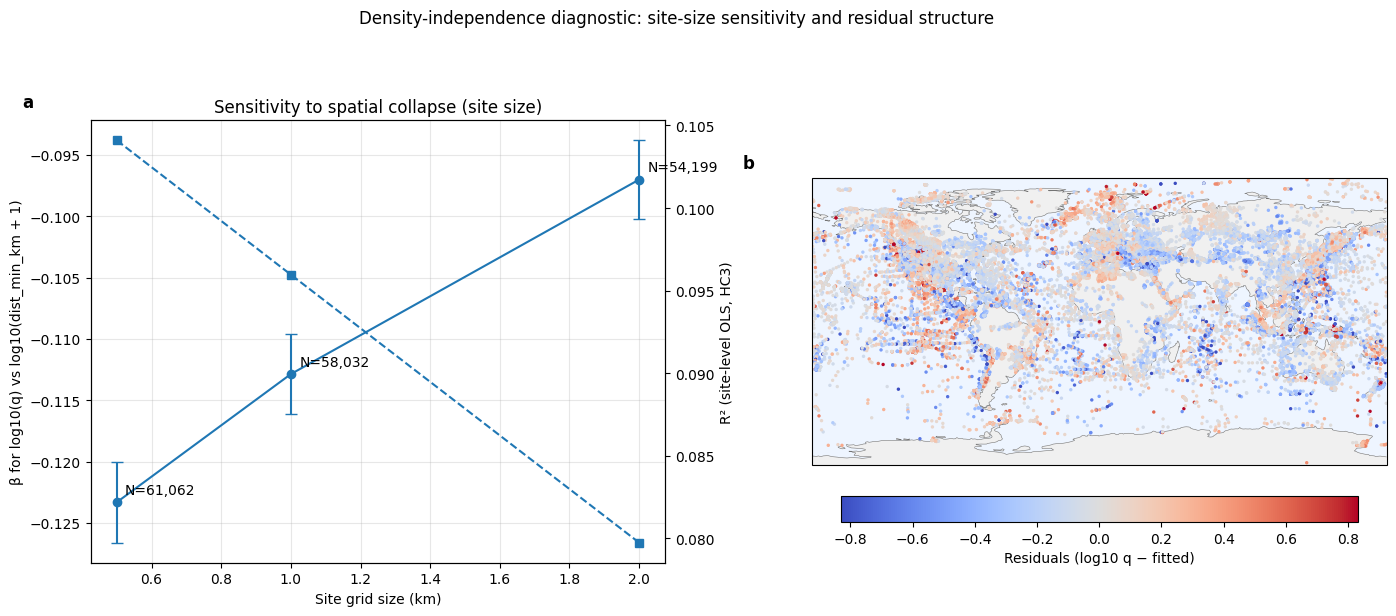

[QA] Saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\qa_regression_sitelevel.md
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\qa_residual_map.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\qa_sensitivity_snap.csv
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig4_density_and_residuals.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig4_density_and_residuals.pdf
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig4_density_and_residuals.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig4_density_and_residuals.pdf
   snap_km  beta_logdist    

In [16]:
# ==============================================================
# Snippet 16 — Sensitivity to Site Size & Residual Mapping
#
# Purpose:
#   Test slope stability across grid sizes and inspect spatial residuals.
#
# Inputs:
#   gdf_all (GeoDataFrame, EPSG:4326) with:
#     lon, lat, q, dist_min_km, dist_gem_km, dist_pb_km, geometry
#   g_site (GeoDataFrame or DataFrame) with:
#     lon, lat, q, dist_min_km (site-level collapse)
#
# Outputs:
#   OUT_ROOT/analysis/qa_sensitivity_snap.csv
#   OUT_ROOT/analysis/qa_residual_map.png
#   OUT_ROOT/analysis/qa_regression_sitelevel.md
#   FIG_DIR/fig4_density_and_residuals.png
#   FIG_DIR/fig4_density_and_residuals.pdf
#
# Editorial role:
#   DECISION
#   Regression robustness analysis.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Routing helpers (from Snippet 2) — same pattern as SR1
# -----------------------------
HAS_ROUTER = ("resolve_out_path" in globals())

def _outpath(name: str, family: str):
    if HAS_ROUTER:
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

# -----------------------------
# Targets
#   - pipeline artifacts: routed (analysis/plots)
#   - Main text figure: figures_main (PNG+PDF)
# -----------------------------
OUT_ANALYSIS_DIR = _outpath("._tmp", family="analysis").parent
OUT_PLOTS_DIR    = _outpath("._tmp", family="plots").parent

QA_MD  = _outpath("qa_regression_sitelevel.md", family="analysis")
QA_PNG = _outpath("qa_residual_map.png", family="plots")

SR2_PNG = _outpath("fig4_density_and_residuals.png", family="plots")
SR2_PDF = _outpath("fig4_density_and_residuals.pdf", family="plots")

# NOTE: keep OUT_DIR only for the existing code below (minimal change)
OUT_DIR = OUT_ANALYSIS_DIR

# Main-text destination (Figure 4)
SR_DIR = Path(FIG_DIR) if ("FIG_DIR" in globals()) else None
if SR_DIR is not None:
    SR_DIR.mkdir(parents=True, exist_ok=True)
    SR2_PNG_SR = SR_DIR / "fig4_density_and_residuals.png"
    SR2_PDF_SR = SR_DIR / "fig4_density_and_residuals.pdf"
else:
    SR2_PNG_SR = None
    SR2_PDF_SR = None

# -------------------------------
# Guards
# -------------------------------
assert "gdf_all" in globals(), "gdf_all not found — run distance pipeline first."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."
assert "g_site" in globals(), "g_site not found — build it first (Snippet 14)."

need_all = {"geometry", "lon", "lat", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"}
miss_all = need_all - set(gdf_all.columns)
assert not miss_all, f"Missing columns in gdf_all: {sorted(miss_all)}"

# CRS check (robust)
if gdf_all.crs is None:
    raise AssertionError("gdf_all.crs is None; expected EPSG:4326.")
if "4326" not in str(gdf_all.crs):
    raise AssertionError(f"Expected CRS=EPSG:4326, got {gdf_all.crs}")

# -------------------------------
# Helper: fit log10(q) ~ log10(dist_min_km+1) with HC3 robust SE
# -------------------------------
def fit_loglog(df: pd.DataFrame):
    qv = pd.to_numeric(df["q"], errors="coerce")
    dv = pd.to_numeric(df["dist_min_km"], errors="coerce")

    mask = qv.gt(0) & dv.notna() & np.isfinite(dv.to_numpy())
    n = int(mask.sum())
    if n < 3:
        raise ValueError(f"Not enough valid rows for regression (got {n}).")

    x = np.log10(dv.loc[mask].to_numpy(dtype=float) + 1.0)
    y = np.log10(qv.loc[mask].to_numpy(dtype=float))

    X = pd.DataFrame({"const": 1.0, "log10_dist_min_km_plus1": x})
    y = pd.Series(y, name="log10_q")

    model = sm.OLS(y, X).fit(cov_type="HC3")

    beta = float(model.params["log10_dist_min_km_plus1"])
    se   = float(model.bse["log10_dist_min_km_plus1"])
    ci   = (beta - 1.96 * se, beta + 1.96 * se)
    r2   = float(model.rsquared)

    return beta, ci, r2, model, mask

# -------------------------------
# Helper: site builder for arbitrary snap size (metric grid, deterministic)
# -------------------------------
def build_sites_snap(gdf_all: gpd.GeoDataFrame, snap_m: float) -> gpd.GeoDataFrame:
    if snap_m <= 0:
        raise ValueError("snap_m must be > 0.")

    base = gdf_all.copy()

    for c in ["q", "dist_gem_km", "dist_pb_km", "dist_min_km", "lon", "lat"]:
        base[c] = pd.to_numeric(base[c], errors="coerce")

    base = (
        base.replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["q", "dist_min_km", "geometry"])
    )
    base = base[base["q"] > 0].copy()
    if base.empty:
        raise ValueError("No valid rows after cleaning (need q>0, finite dist_min_km, geometry).")

    g_m = base.to_crs(3857).copy()
    x = g_m.geometry.x.to_numpy(dtype=float)
    y = g_m.geometry.y.to_numpy(dtype=float)

    # Stable grid indexing (same convention as Snippet 14)
    gx = np.floor((x + snap_m / 2.0) / snap_m).astype("int64")
    gy = np.floor((y + snap_m / 2.0) / snap_m).astype("int64")
    cell = pd.MultiIndex.from_arrays([gx, gy])

    g_m["__cell__"] = cell
    g_m["__gx__"] = gx
    g_m["__gy__"] = gy

    agg = (
        g_m.groupby("__cell__", sort=False)
           .agg(
               n_meas      = ("q", "size"),
               q           = ("q", "median"),
               dist_gem_km = ("dist_gem_km", "median"),
               dist_pb_km  = ("dist_pb_km", "median"),
               dist_min_km = ("dist_min_km", "median"),
               gx          = ("__gx__", "first"),
               gy          = ("__gy__", "first"),
           )
           .reset_index(drop=True)
    )

    # Cell-center geometry in EPSG:3857
    cx = agg["gx"].to_numpy(dtype=float) * snap_m
    cy = agg["gy"].to_numpy(dtype=float) * snap_m
    geom = gpd.points_from_xy(cx, cy, crs=3857)

    g_site_snap = gpd.GeoDataFrame(
        agg.drop(columns=["gx", "gy"]),
        geometry=geom,
        crs=3857
    ).to_crs(4326)

    g_site_snap["lon"] = g_site_snap.geometry.x
    g_site_snap["lat"] = g_site_snap.geometry.y
    return g_site_snap

# ----------------------------------------------------------------------------
# 1) Sensitivity to site grid size (0.5 km, 1 km, 2 km)
# ----------------------------------------------------------------------------
results = []
for snap in (500.0, 1000.0, 2000.0):  # meters
    g_tmp = build_sites_snap(gdf_all, snap_m=snap)
    beta_s, ci_s, r2_s, _, mask_s = fit_loglog(g_tmp)
    results.append(
        {
            "snap_km": snap / 1000.0,
            "beta_logdist": beta_s,
            "ci_low": ci_s[0],
            "ci_high": ci_s[1],
            "R2": r2_s,
            "N": int(mask_s.sum()),
        }
    )

sens = pd.DataFrame(results).sort_values("snap_km").reset_index(drop=True)
sens_path = OUT_DIR / "qa_sensitivity_snap.csv"
sens.to_csv(sens_path, index=False)

# ----------------------------------------------------------------------------
# 2) Global model and residuals on current g_site
# ----------------------------------------------------------------------------
beta, ci, r2, model, mask = fit_loglog(pd.DataFrame(g_site))
resid = pd.Series(model.resid, index=pd.DataFrame(g_site).loc[mask].index, name="resid")

g_res = pd.DataFrame(g_site).loc[mask, ["lon", "lat", "q", "dist_min_km"]].copy()
g_res["lon"] = pd.to_numeric(g_res["lon"], errors="coerce")
g_res["lat"] = pd.to_numeric(g_res["lat"], errors="coerce")
g_res["resid"] = resid.to_numpy(dtype=float)

# Robust symmetric color limits (winsorized)
v = g_res["resid"].to_numpy(dtype=float)
v = v[np.isfinite(v)]
if v.size:
    vlim = float(np.nanpercentile(np.abs(v), 98))  # robust; avoids a few extreme sites dominating
    vlim = max(vlim, 1e-6)
else:
    vlim = 1.0

# ----------------------------------------------------------------------------
# 3) Residual map (LOCAL-ONLY, no cartopy features)
# ----------------------------------------------------------------------------
fig = plt.figure(figsize=(11.5, 5.3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#eef5ff", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="0.94", edgecolor="none", zorder=0)
ax.coastlines(resolution="110m", linewidth=0.4, color="0.45", zorder=1)

sc = ax.scatter(
    g_res["lon"], g_res["lat"],
    transform=ccrs.PlateCarree(),
    c=g_res["resid"], s=6,
    cmap="coolwarm",
    vmin=-vlim, vmax=vlim,
    linewidths=0,
    zorder=2,
    rasterized=True,
)

cb = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.06, shrink=0.9)
cb.set_label("Residuals (log10 q − fitted)")

ax.set_title("Global residual map (site-level) — log10(q) vs log10(dist_min_km+1)")
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="0.6", alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig(QA_PNG, dpi=300, bbox_inches="tight")
plt.close(fig)

# ----------------------------------------------------------------------------
# 3.1) Figure 4 panel: Sensitivity (beta ± CI + R²) + Residual map
# ----------------------------------------------------------------------------
xk = sens["snap_km"].to_numpy(float)
beta_k = sens["beta_logdist"].to_numpy(float)
ci_low = sens["ci_low"].to_numpy(float)
ci_hi  = sens["ci_high"].to_numpy(float)
r2_k   = sens["R2"].to_numpy(float)
yerr = np.vstack([beta_k - ci_low, ci_hi - beta_k])

fig_panel = plt.figure(figsize=(14.5, 6.0))

# Panel A
axA = fig_panel.add_subplot(1, 2, 1)
axA.errorbar(xk, beta_k, yerr=yerr, fmt="o-", capsize=4)
axA.set_xlabel("Site grid size (km)")
axA.set_ylabel("β for log10(q) vs log10(dist_min_km + 1)")
axA.set_title("Sensitivity to spatial collapse (site size)")
axA.grid(True, alpha=0.3)

axA2 = axA.twinx()
axA2.plot(xk, r2_k, marker="s", linestyle="--")
axA2.set_ylabel("R² (site-level OLS, HC3)")

for xi, bi, ni in zip(xk, beta_k, sens["N"].astype(int).tolist()):
    axA.annotate(f"N={ni:,}", (xi, bi), textcoords="offset points", xytext=(6, 6))

# Panel B (with basemap reference; keep points identical)
axB = fig_panel.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
axB.set_global()

# Basemap (light, non-intrusive)
axB.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#eef5ff", zorder=0)
axB.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="0.94", edgecolor="none", zorder=0)
axB.coastlines(resolution="110m", linewidth=0.4, color="0.45", zorder=1)

# Points (same data + styling)
scB = axB.scatter(
    g_res["lon"], g_res["lat"],
    transform=ccrs.PlateCarree(),
    c=g_res["resid"], s=6,
    cmap="coolwarm",
    vmin=-vlim, vmax=vlim,
    linewidths=0,
    zorder=2,
    rasterized=True,
)

cbB = plt.colorbar(scB, ax=axB, orientation="horizontal", pad=0.07, shrink=0.9)
cbB.set_label("Residuals (log10 q − fitted)")

# Panel labels: lowercase, left side of each panel
axA.text(
    -0.10, 1.02, "a",
    transform=axA.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

axB.text(
    -0.10, 1.02, "b",
    transform=axB.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

fig_panel.suptitle(
    "Density-independence diagnostic: site-size sensitivity and residual structure",
    y=1.02
)

fig_panel.tight_layout(rect=[0.03, 0, 1, 0.96])

fig_panel.savefig(SR2_PNG, dpi=300, bbox_inches="tight")
fig_panel.savefig(SR2_PDF, bbox_inches="tight")

# --- Duplicate Figure 4 into figures_main ---
if SR2_PNG_SR is not None and SR2_PDF_SR is not None:
    fig_panel.savefig(SR2_PNG_SR, dpi=300, bbox_inches="tight")
    fig_panel.savefig(SR2_PDF_SR, bbox_inches="tight")
    print(f"[FIG] Saved Figure 4 → {SR2_PNG_SR}")
    print(f"[FIG] Saved Figure 4 → {SR2_PDF_SR}")

plt.show()
plt.close(fig_panel)

# ----------------------------------------------------------------------------
# 4) Markdown QA report (write fresh)
# ----------------------------------------------------------------------------
with open(QA_MD, "w", encoding="utf-8") as f:
    f.write("# Site-level Regression QA Report\n\n")
    f.write("**Model:** `log10(q) ~ log10(dist_min_km + 1)`\n\n")
    f.write(f"- **Global β_logdist:** {beta:.4f}\n")
    f.write(f"- **95% CI:** [{ci[0]:.4f}, {ci[1]:.4f}]\n")
    f.write(f"- **R²:** {r2:.3f}\n")
    f.write(f"- **N (sites used):** {int(pd.DataFrame(g_site).loc[mask].shape[0]):,}\n\n")

    f.write("## Sensitivity by grid size (snap to metric grid)\n\n")
    f.write(sens.to_markdown(index=False, floatfmt=".4f"))
    f.write("\n\n## Residual map\n\n")
    f.write("![Residual map](qa_residual_map.png)\n")
    f.write("\n\n## Figure 4 panel\n\n")
    f.write("![Figure 4 panel](fig4_density_and_residuals.png)\n")

print("[QA] Saved:")
print(" -", QA_MD)
print(" -", QA_PNG)
print(" -", sens_path)
print(" -", SR2_PNG)
print(" -", SR2_PDF)
if SR2_PNG_SR is not None:
    print(" -", SR2_PNG_SR)
if SR2_PDF_SR is not None:
    print(" -", SR2_PDF_SR)
print(sens)

# Snippet 17 — Residual Diagnostics (QA ONLY, no decision)

In [17]:
# ==============================================================
# Snippet 17 — Residual Diagnostics & Normality Tests
#
# Purpose:
#   Evaluate residual distributions and normality for the
#   pre-selected regression model (QA only).
#
# Model (fixed):
#   log10(q) ~ log10(dist_min_km + 1)
#
# Inputs:
#   g_site with columns: q, dist_min_km
#
# Outputs:
#   OUT_ROOT/analysis/qa_residual_hist.png
#   Appends to: OUT_ROOT/analysis/qa_regression_sitelevel.md
#
# Editorial role:
#   QA
#   Residual verification for the main regression model.
# ==============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

OUT_DIR  = OUT_ROOT / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

QA_MD    = OUT_DIR / "qa_regression_sitelevel.md"
HIST_PNG = OUT_DIR / "qa_residual_hist.png"

MODEL_SPEC = "log10(q) ~ log10(dist_min_km + 1)"

# ---------------- Preconditions ----------------
assert "g_site" in globals(), "g_site not found — build it first."
df = pd.DataFrame(g_site).copy()

qv = pd.to_numeric(df["q"], errors="coerce")
dv = pd.to_numeric(df["dist_min_km"], errors="coerce")

mask = qv.gt(0) & dv.notna() & np.isfinite(dv.to_numpy())
N = int(mask.sum())
assert N >= 3, f"Not enough valid rows for residual diagnostics (got {N})."

# ---------------- Model fit (OLS, HC3) ----------------
x = np.log10(dv.loc[mask].to_numpy(dtype=float) + 1.0)
y = np.log10(qv.loc[mask].to_numpy(dtype=float))
X = pd.DataFrame({"const": 1.0, "log10_dist_min_km_plus1": x})

ols = sm.OLS(y, X).fit(cov_type="HC3")
resid = np.asarray(ols.resid, dtype=float)

beta_logdist = float(ols.params["log10_dist_min_km_plus1"])
r2 = float(ols.rsquared)

# ---------------- Histogram (1–99% clipped) ----------------
lo, hi = np.nanpercentile(resid, [1, 99])
resid_vis = np.clip(resid, lo, hi)

plt.figure(figsize=(8, 4.5))
plt.hist(resid_vis, bins=60, edgecolor="none")
plt.xlabel("Residuals (log10 q – fitted)")
plt.ylabel("Count")
plt.title("Residual histogram (clipped at 1st–99th pct)")
plt.tight_layout()
plt.savefig(HIST_PNG, dpi=300, bbox_inches="tight")
plt.close()

# ---------------- Safe p formatting ----------------
def _safe_log10(p: float) -> float:
    if p is None or (not np.isfinite(p)) or p <= 0.0:
        return -np.inf
    return float(np.log10(p))

def _p_display(log10_p: float, min_exp: int = -300) -> str:
    if not np.isfinite(log10_p):
        return "< 1e-300"
    exp_floor = int(np.floor(log10_p))
    if exp_floor <= min_exp:
        return f"< 1e{exp_floor}"
    return f"{10.0**log10_p:.3e}"

# ---------------- Normality tests ----------------
rng = np.random.default_rng(42)
sample = resid if N <= 5000 else resid[rng.choice(N, size=5000, replace=False)]

# Shapiro–Wilk on ≤5,000 points
try:
    shapiro_stat, shapiro_p = stats.shapiro(sample)
except Exception:
    shapiro_stat, shapiro_p = np.nan, np.nan
shapiro_log10p = _safe_log10(shapiro_p)

# Jarque–Bera on full residuals
try:
    jb_stat, jb_p = stats.jarque_bera(resid)
except Exception:
    jb_stat, jb_p = np.nan, np.nan
jb_log10p = _safe_log10(jb_p)

# ---------------- Append to Markdown QA ----------------
with open(QA_MD, "a", encoding="utf-8") as f:
    f.write("\n\n---\n\n")
    f.write("## Residual diagnostics\n\n")
    f.write(f"**Model (fixed):** `{MODEL_SPEC}`\n\n")
    f.write(f"- **N (used in fit):** {N:,}\n")
    f.write(f"- **β_logdist (HC3):** {beta_logdist:.4f}\n")
    f.write(f"- **R²:** {r2:.3f}\n\n")

    f.write("### Normality tests\n")
    f.write(
        f"- **Shapiro–Wilk** (≤5,000 subsample): "
        f"W = {shapiro_stat:.4f}, p {_p_display(shapiro_log10p)} "
        f"(log10 p = {shapiro_log10p:.1f})\n"
    )
    f.write(
        f"- **Jarque–Bera** (full): "
        f"JB = {jb_stat:.2f}, p {_p_display(jb_log10p)} "
        f"(log10 p = {jb_log10p:.1f})\n\n"
    )
    f.write(
        "_Note: For large N, formal normality tests typically reject the null; "
        "robust HC3 inference does not rely on residual normality._\n\n"
    )

    f.write("### Residual histogram\n")
    f.write("Clipped at the 1st–99th percentiles for visualization.\n\n")
    f.write("![Residual histogram](qa_residual_hist.png)\n")

# ---------------- On-screen QA summary ----------------
print("\n[QA] Residual Diagnostics Summary")
print("──────────────────────────────────────────")
print(f"Model (fixed):          {MODEL_SPEC}")
print(f"N (used in fit):        {N:,}")
print(f"β_logdist (HC3):        {beta_logdist:.4f}")
print(f"R²:                     {r2:.3f}")
print(f"Shapiro–Wilk:           p {_p_display(shapiro_log10p)} (log10 p = {shapiro_log10p:.1f})")
print(f"Jarque–Bera:            p {_p_display(jb_log10p)} (log10 p = {jb_log10p:.1f})")
print(f"Histogram saved → {HIST_PNG}")
print(f"Appended to → {QA_MD}")


[QA] Residual Diagnostics Summary
──────────────────────────────────────────
Model (fixed):          log10(q) ~ log10(dist_min_km + 1)
N (used in fit):        58,032
β_logdist (HC3):        -0.1129
R²:                     0.096
Shapiro–Wilk:           p 3.184e-47 (log10 p = -46.5)
Jarque–Bera:            p < 1e-300 (log10 p = -inf)
Histogram saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\qa_residual_hist.png
Appended to → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\qa_regression_sitelevel.md


# Snippet 18 — AEQD tiled distance recomputation

In [18]:
# ==============================================================
# Snippet 18 — AEQD tiled distance recomputation (METHOD, non-blocking)
#
# Purpose:
#   Compute nearest distances to GEM and PB2002 networks using local AEQD tiles.
#   Saves a reusable AEQD artifact for downstream QA comparisons.
#
# Inputs:
#   faults_gem (GeoDataFrame lines, EPSG:4326)
#   faults_pb  (GeoDataFrame lines, EPSG:4326)
#   gdf_all    (GeoDataFrame points, EPSG:4326)
#
# Outputs:
#   OUT_ROOT/analysis/distances_aeqd.parquet
#
# Editorial role:
#   METHOD
#   Produces AEQD-based distances used only for QA/robustness validation.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import nearest_points
from pyproj import CRS, Transformer
from pathlib import Path

OUT_PARQUET = OUT_ROOT / "analysis" / "distances_aeqd.parquet"
OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)

# ---------------- Helper: validate existing file ----------------
def existing_is_valid(path: Path,
                      max_nan_gem: float = 0.05,
                      max_nan_pb: float = 0.40) -> bool:
    """
    Validate AEQD artifact with separate tolerances:
      - GEM coverage expected high
      - PB coverage may be lower (dataset geometry / segmentation)
    """
    if not path.exists():
        return False
    try:
        df = pd.read_parquet(path)
    except Exception:
        return False

    need = {"idx", "lon", "lat", "dist_gem_km_aeqd", "dist_pb_km_aeqd"}
    if (not need.issubset(df.columns)) or df.empty:
        return False

    gem_nan = float(df["dist_gem_km_aeqd"].isna().mean())
    pb_nan  = float(df["dist_pb_km_aeqd"].isna().mean())

    if gem_nan > max_nan_gem:
        print(f"[AEQD] Existing rejected: GEM NaN frac={gem_nan:.3f} > {max_nan_gem:.3f}")
        return False

    if pb_nan > max_nan_pb:
        # PB can be sparse; accept but warn
        print(f"[AEQD] Existing warning: PB NaN frac={pb_nan:.3f} > {max_nan_pb:.3f} (kept; PB tolerance is looser)")

    print(f"[AEQD] Existing AEQD artifact OK | GEM NaN={gem_nan:.3f} | PB NaN={pb_nan:.3f}")
    return True

def aeqd_for(lat0, lon0):
    return CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat0} +lon_0={lon0} "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

def nearest_dist_union_km(points_gdf, lines_gdf):
    """
    Distance (km) from each point to union of lines in that tile.
    Robust: no STRtree.query_nearest dependency.
    Note: O(N_points) distance calls; intended tile-wise (small).
    """
    if points_gdf.empty:
        return pd.Series(dtype=float, index=points_gdf.index)

    lines_gdf = lines_gdf[lines_gdf.geometry.notna() & ~lines_gdf.geometry.is_empty]
    if lines_gdf.empty:
        return pd.Series(np.nan, index=points_gdf.index, dtype=float)

    try:
        union_ln = lines_gdf.geometry.union_all()
    except Exception:
        union_ln = lines_gdf.unary_union

    out = np.empty(points_gdf.shape[0], dtype=float)
    for i, geom in enumerate(points_gdf.geometry.values):
        try:
            p_pt, p_ln = nearest_points(geom, union_ln)
            out[i] = p_pt.distance(p_ln) / 1000.0
        except Exception:
            out[i] = np.nan
    return pd.Series(out, index=points_gdf.index, dtype=float)

# ---------------- Compute if needed (non-blocking) ----------------
if existing_is_valid(OUT_PARQUET):
    pass
else:
    try:
        print("[AEQD] Recomputing AEQD distances from scratch...")

        assert "faults_gem" in globals() and isinstance(faults_gem, gpd.GeoDataFrame), "faults_gem missing."
        assert "faults_pb"  in globals() and isinstance(faults_pb,  gpd.GeoDataFrame), "faults_pb missing."
        assert "gdf_all"    in globals() and isinstance(gdf_all,    gpd.GeoDataFrame), "gdf_all missing."

        GEM = faults_gem.to_crs(4326)
        PB  = faults_pb.to_crs(4326)

        GEM = GEM[GEM.geometry.notna() & ~GEM.geometry.is_empty].copy()
        PB  = PB[PB.geometry.notna() & ~PB.geometry.is_empty].copy()

        if GEM.empty and PB.empty:
            raise RuntimeError("[AEQD] Both GEM and PB linework empty after cleaning.")

        PTS = gdf_all.copy().to_crs(4326)
        if "lon" not in PTS.columns:
            PTS["lon"] = PTS.geometry.x
        if "lat" not in PTS.columns:
            PTS["lat"] = PTS.geometry.y

        # IMPORTANT: keep original index as a stable key
        PTS = PTS[PTS.geometry.notna() & ~PTS.geometry.is_empty].copy()
        if PTS.empty:
            raise RuntimeError("[AEQD] gdf_all has no valid point geometries.")

        PTS["idx"] = PTS.index.astype("int64")


        # 5°×5° tiles with 1° margin.
        # NOTE: margin is used to ensure faults near boundaries are present, but
        # points may fall into multiple tiles. We'll resolve by keeping min distance per idx.
        STEP, MARG = 5.0, 1.0
        LATS = np.arange(-90.0, 90.0, STEP)
        LONS = np.arange(-180.0, 180.0, STEP)

        tiles = [box(lo - MARG, la - MARG, lo + STEP + MARG, la + STEP + MARG)
                 for la in LATS for lo in LONS]

        blocks = []
        used_tiles = 0

        # Prebuild spatial indexes (GeoPandas uses rtree/pygeos backend if present)
        # Best-effort: if not available, intersects will still work but slower.
        try:
            _ = GEM.sindex
            _ = PB.sindex
            _ = PTS.sindex
        except Exception:
            pass

        for tile in tiles:
            # NOTE: for points we should use within(tile) to prevent duplicates;
            # but because tiles have margin, "within" still duplicates on overlaps.
            # Better: use a non-overlapped *core tile* for point membership, and expanded tile for faults.
            # Here: core is 5°×5° (no margin) and expanded has margin.
            # We reconstruct core from expanded: shrink by MARG.
            core = box(tile.bounds[0] + MARG, tile.bounds[1] + MARG,
                       tile.bounds[2] - MARG, tile.bounds[3] - MARG)

            pts_t = PTS[PTS.within(core)]
            if pts_t.empty:
                continue

            # faults: use expanded tile (tile) for coverage
            gem_t = GEM[GEM.intersects(tile)]
            pb_t  = PB[PB.intersects(tile)]
            if gem_t.empty and pb_t.empty:
                # still produce NaNs for these points (so coverage is explicit)
                used_tiles += 1
                blk = pd.DataFrame(
                    {"idx": pts_t["idx"].values,
                     "lon": pts_t["lon"].values,
                     "lat": pts_t["lat"].values,
                     "dist_gem_km_aeqd": np.nan,
                     "dist_pb_km_aeqd":  np.nan},
                    index=pts_t.index,
                )
                blocks.append(blk)
                continue

            used_tiles += 1

            cLon, cLat = core.centroid.x, core.centroid.y
            crs_aeqd   = aeqd_for(cLat, cLon)
            to_aeqd    = Transformer.from_crs("EPSG:4326", crs_aeqd, always_xy=True)

            x, y = to_aeqd.transform(pts_t.geometry.x.values, pts_t.geometry.y.values)
            pts_e = gpd.GeoDataFrame(
                pts_t[["idx", "lon", "lat"]].copy(),
                geometry=gpd.points_from_xy(x, y),
                crs=crs_aeqd
            )

            gem_e = gem_t.to_crs(crs_aeqd) if not gem_t.empty else gem_t
            pb_e  = pb_t.to_crs(crs_aeqd)  if not pb_t.empty  else pb_t

            km_gem = nearest_dist_union_km(pts_e, gem_e)
            km_pb  = nearest_dist_union_km(pts_e, pb_e)

            blk = pd.DataFrame(
                {"idx": pts_t["idx"].values,
                 "lon": pts_t["lon"].values,
                 "lat": pts_t["lat"].values,
                 "dist_gem_km_aeqd": km_gem.values,
                 "dist_pb_km_aeqd":  km_pb.values},
                index=pts_t.index,
            )
            blocks.append(blk)

        if not blocks:
            print("[AEQD] No tiles produced distances. Check inputs/CRS.")
        else:
            D = pd.concat(blocks, ignore_index=True)

            # Coerce numeric
            for c in ["idx", "lon", "lat", "dist_gem_km_aeqd", "dist_pb_km_aeqd"]:
                D[c] = pd.to_numeric(D[c], errors="coerce")

            D = D.dropna(subset=["idx", "lon", "lat"]).copy()
            D["idx"] = D["idx"].astype("int64")

            # If any duplicates slipped in (should not, due to core tiles), keep min per idx
            D = (
                D.groupby("idx", as_index=False, sort=False)
                 .agg(
                     lon=("lon", "first"),
                     lat=("lat", "first"),
                     dist_gem_km_aeqd=("dist_gem_km_aeqd", "min"),
                     dist_pb_km_aeqd=("dist_pb_km_aeqd", "min"),
                 )
            )

            gem_cov = float(D["dist_gem_km_aeqd"].notna().mean()*100)
            pb_cov  = float(D["dist_pb_km_aeqd"].notna().mean()*100)
            print(f"[AEQD][QA] Tiles used: {used_tiles}")
            print(f"[AEQD][QA] Coverage: GEM={gem_cov:.2f}% | PB={pb_cov:.2f}%")

            OUT_PARQUET.unlink(missing_ok=True)
            D.to_parquet(OUT_PARQUET, index=False)
            print(f"[AEQD] Saved {OUT_PARQUET} | N={len(D):,}")

    except Exception as e:
        print(f"[AEQD][WARN] AEQD recomputation failed (pipeline continues): {e}")

# ---------------- Minimal summary (always safe) ----------------
if OUT_PARQUET.exists():
    df = pd.read_parquet(OUT_PARQUET)
    gem_cov = float(df["dist_gem_km_aeqd"].notna().mean()*100)
    pb_cov  = float(df["dist_pb_km_aeqd"].notna().mean()*100)
    print(f"\n[AEQD QA] distances_aeqd.parquet loaded | N={len(df):,} | GEMcov={gem_cov:.2f}% | PBcov={pb_cov:.2f}%")

[AEQD] Recomputing AEQD distances from scratch...
[AEQD][QA] Tiles used: 1678
[AEQD][QA] Coverage: GEM=67.85% | PB=45.04%
[AEQD] Saved C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\distances_aeqd.parquet | N=90,934

[AEQD QA] distances_aeqd.parquet loaded | N=90,934 | GEMcov=67.85% | PBcov=45.04%


# Snippet 19 — AEQD attach + quick compare (non-destructive)

In [19]:
# ==============================================================
# Snippet 19 — AEQD attach + quick compare (QA glue, non-destructive)
#
# Purpose:
#   Attach AEQD distances to gdf_all in memory (if artifact exists).
#   Quick QA: for ULTRA rows (q ≥ Q_ULTRA_COMPARE), compare AEQD min-distance
#   vs operational min-distance (dist_min_km).
#
# Robust to AEQD artifact schema variants:
#   A) 'idx' exists as a column
#   B) 'idx' stored as parquet index (legacy) -> recovered via reset_index()
#   C) duplicates in AEQD artifact due to overlapping tiles -> collapsed by idx
#
# Scientific note (NG-safe):
#   - This snippet is QA-only and non-destructive:
#     it does NOT modify gdf_all nor overwrite AEQD artifacts.
#   - When duplicates exist for the same point index (idx), we take the MIN
#     distance per idx (physically corresponds to the nearest linework found
#     across overlapping tiles; conservative and deterministic).
#
# Inputs:
#   gdf_all (GeoDataFrame)
#   OUT_ROOT/analysis/distances_aeqd.parquet (optional)
#
# Outputs (in-memory only):
#   gdf_aug       (gdf_all + dist_gem_km_aeqd + dist_pb_km_aeqd)
#   df_ultra_cmp  (table for q ≥ Q_ULTRA_COMPARE)
#
# Editorial role:
#   QA / ROBUSTNESS
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

# ------------------------- Guards -------------------------
assert "gdf_all" in globals() and isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be loaded."
assert gdf_all.crs is not None and str(gdf_all.crs).endswith("4326"), "Expected gdf_all CRS=EPSG:4326."

AEQD_PATH = OUT_ROOT / "analysis" / "distances_aeqd.parquet"
Q_ULTRA_COMPARE = float(globals().get("Q_ULTRA_COMPARE", 100_000.0))  # QA threshold for comparison

# -------------------------
# 1) Load + normalize AEQD artifact (in-memory only)
# -------------------------
gdf_aug = gdf_all.copy()

if not AEQD_PATH.exists():
    print(f"[AEQD_GLUE] {AEQD_PATH} not found — skipping attach and compare.")
else:
    aeqd = pd.read_parquet(AEQD_PATH)

    # ---- Recover idx as a column (supports legacy parquet index) ----
    if "idx" not in aeqd.columns:
        aeqd0 = aeqd.copy()
        aeqd = aeqd.reset_index()
        if "idx" in aeqd.columns:
            schema_mode = "legacy_index_named_idx"
        elif "index" in aeqd.columns:
            aeqd = aeqd.rename(columns={"index": "idx"})
            schema_mode = "legacy_index_named_index"
        else:
            # last resort: first column created by reset_index()
            aeqd = aeqd.rename(columns={aeqd.columns[0]: "idx"})
            schema_mode = "legacy_index_firstcol"
        print(f"[AEQD_GLUE] AEQD schema: idx recovered via reset_index() ({schema_mode}).")
        del aeqd0
    else:
        print("[AEQD_GLUE] AEQD schema: idx present as column.")

    # ---- Validate required cols ----
    need_cols = {"idx", "dist_gem_km_aeqd", "dist_pb_km_aeqd"}
    missing = need_cols - set(aeqd.columns)
    assert not missing, f"[AEQD_GLUE] AEQD artifact missing cols: {sorted(missing)}"

    # ---- Coerce types ----
    aeqd["idx"] = pd.to_numeric(aeqd["idx"], errors="coerce")
    aeqd = aeqd.dropna(subset=["idx"]).copy()
    aeqd["idx"] = aeqd["idx"].astype("int64")

    for c in ["dist_gem_km_aeqd", "dist_pb_km_aeqd"]:
        aeqd[c] = pd.to_numeric(aeqd[c], errors="coerce")

    # ---- Deterministic de-duplication by idx (overlapping tiles) ----
    n_before = int(len(aeqd))
    n_unique = int(aeqd["idx"].nunique())

    if n_before != n_unique:
        # MIN distance per idx is physically appropriate (nearest across tile overlaps)
        aeqd = (
            aeqd.groupby("idx", as_index=False, sort=True)
                .agg(
                    dist_gem_km_aeqd=("dist_gem_km_aeqd", "min"),
                    dist_pb_km_aeqd=("dist_pb_km_aeqd", "min"),
                )
        )
        print(f"[AEQD_GLUE] Collapsed duplicates: rows {n_before:,} → {len(aeqd):,} (unique idx).")
    else:
        print(f"[AEQD_GLUE] No duplicates in AEQD artifact (rows={n_before:,}).")

    assert aeqd["idx"].is_unique, "[AEQD_GLUE] AEQD idx still not unique after collapse (unexpected)."

    # -------------------------
    # 2) Attach to gdf_all (non-destructive, by idx)
    # -------------------------
    # Build idx from gdf_all index. Must be stable relative to AEQD generation.
    idx_series = pd.to_numeric(pd.Series(gdf_aug.index), errors="coerce")

    if idx_series.isna().any():
        # NG-safe behavior: do NOT attempt a risky merge.
        raise RuntimeError(
            "[AEQD_GLUE] gdf_all index is not numeric. "
            "Cannot safely attach AEQD by idx. "
            "Fix upstream: ensure gdf_all index is the canonical integer index used when generating AEQD."
        )

    gdf_aug = gdf_aug.copy()
    gdf_aug["idx"] = idx_series.astype("int64").to_numpy()

    # Left merge (one-to-one after AEQD collapse)
    gdf_aug = gdf_aug.merge(
        aeqd[["idx", "dist_gem_km_aeqd", "dist_pb_km_aeqd"]],
        on="idx",
        how="left",
        validate="one_to_one",
    )

    cov_gem = float(gdf_aug["dist_gem_km_aeqd"].notna().mean() * 100.0)
    cov_pb  = float(gdf_aug["dist_pb_km_aeqd"].notna().mean()  * 100.0)
    print(f"[AEQD_GLUE] Attached AEQD by idx | Coverage: GEM={cov_gem:.1f}% | PB={cov_pb:.1f}%")

    # -------------------------
    # 3) Quick ULTRA compare (QA only)
    # -------------------------
    df = gdf_aug.copy()

    for c in ["q", "dist_min_km", "dist_gem_km_aeqd", "dist_pb_km_aeqd", "lon", "lat"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)

    m = (
        df["q"].notna()
        & df["dist_min_km"].notna()
        & df[["dist_gem_km_aeqd", "dist_pb_km_aeqd"]].notna().any(axis=1)
    )
    df = df.loc[m].copy()

    df["dist_min_km_aeqd"] = np.nanmin(
        df[["dist_gem_km_aeqd", "dist_pb_km_aeqd"]].to_numpy(dtype=float),
        axis=1
    )

    ultra = df.loc[df["q"] >= Q_ULTRA_COMPARE].copy()

    if ultra.empty:
        print(f"[AEQD_COMPARE] No rows with q ≥ {Q_ULTRA_COMPARE:,.0f} and AEQD distances.")
        df_ultra_cmp = pd.DataFrame()
    else:
        ultra["abs_delta_min_km"] = (ultra["dist_min_km_aeqd"] - ultra["dist_min_km"]).abs()

        med_abs = float(np.nanmedian(ultra["abs_delta_min_km"]))
        p90_abs = float(np.nanpercentile(ultra["abs_delta_min_km"], 90))
        p99_abs = float(np.nanpercentile(ultra["abs_delta_min_km"], 99))

        df_ultra_cmp = (
            ultra[["lon", "lat", "q", "dist_min_km", "dist_min_km_aeqd", "abs_delta_min_km"]]
            .sort_values("abs_delta_min_km", ascending=False)
            .reset_index(drop=True)
        )

        print(
            f"[AEQD_COMPARE] q ≥ {Q_ULTRA_COMPARE:,.0f} | N={len(df_ultra_cmp)} | "
            f"median |Δ|min={med_abs:.2f} km | P90={p90_abs:.2f} km | P99={p99_abs:.2f} km"
        )

        # Preview worst 15
        try:
            from IPython.display import display
            display(df_ultra_cmp.head(15).round(3))
        except Exception:
            print(df_ultra_cmp.head(15).round(3))

[AEQD_GLUE] AEQD schema: idx present as column.
[AEQD_GLUE] No duplicates in AEQD artifact (rows=90,934).
[AEQD_GLUE] Attached AEQD by idx | Coverage: GEM=67.8% | PB=45.0%
[AEQD_COMPARE] q ≥ 100,000 | N=12 | median |Δ|min=41.80 km | P90=41.80 km | P99=41.81 km


,lon,lat,q,dist_min_km,dist_min_km_aeqd,abs_delta_min_km
0,-127.786,47.710,154000.0,128.271,86.455,41.816
1,-127.786,47.710,180000.0,128.238,86.433,41.805
2,-127.786,47.710,207000.0,128.227,86.425,41.801
3,-127.786,47.710,383000.0,128.227,86.425,41.801
4,-127.786,47.710,489000.0,128.226,86.425,41.801
5,-127.786,47.710,190000.0,128.226,86.425,41.801
6,-127.786,47.710,410000.0,128.226,86.425,41.801
7,-127.787,47.709,425000.0,128.184,86.397,41.787
8,140.644,28.572,120744.0,238.561,209.011,29.550
9,140.645,28.571,105436.0,238.509,208.967,29.543


# Snippet 20 — Land–ocean figures + regressions

[PLOTS] Saved SR3 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig6_land_ocean_panel.png
[PLOTS] Saved SR3 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig6_land_ocean_panel.pdf
[FIG] Saved Figure 6 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig6_land_ocean_panel.png
[FIG] Saved Figure 6 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_main\fig6_land_ocean_panel.pdf


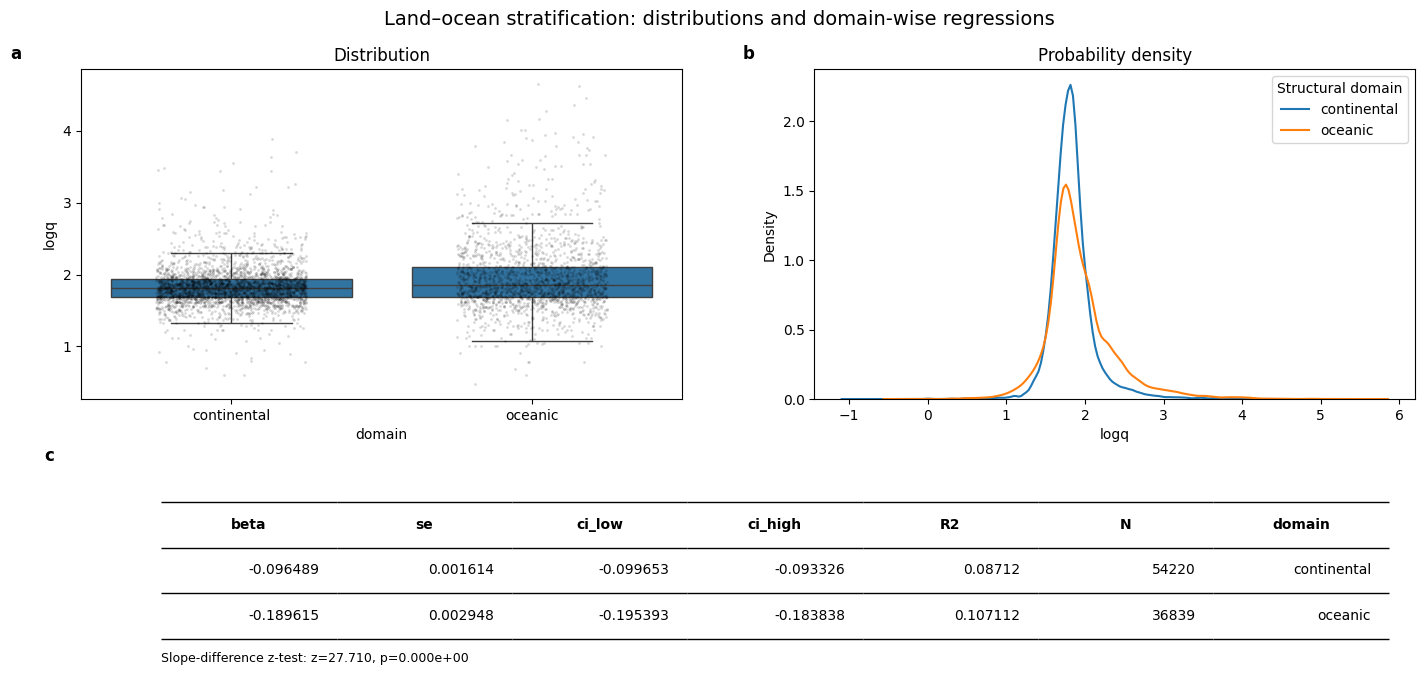

[S31] Saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\figs\FigS7a_box_logq_land_ocean.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\figs\FigS7b_kde_logq_land_ocean.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\figs\fig6_land_ocean_panel.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\figs\fig6_land_ocean_panel.pdf
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\TableS3_land_ocean_regressions.csv
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\TableS3_land_ocean_regressions.md


In [20]:
# ==============================================================
# Snippet 20 — Land–ocean stratification: distributions + regressions
# (NG-style; ROUTED; produces panel + companion 
#
# Purpose:
#   Quantify and visualize first-order land–ocean contrasts in IHFC heat flow
#   under the canonical distance metric (dist_min_km), and provide domain-wise
#   regressions used in the main-text land–ocean synthesis and companion tables.
#
# What this snippet does:
#   1) Derives a land/ocean flag (is_land) using Natural Earth land polygons
#      (deterministic; if land polygons are unavailable, falls back to is_land=False).
#   2) Builds domain-labeled data:
#        - domain ∈ {continental, oceanic}
#        - logq = log10(q)  (q>0)
#        - logdist1 = log10(dist_min_km + 1)
#   3) Produces companion figures:
#        - Fig S7a: box/strip of logq by domain
#        - Fig S7b: KDE of logq by domain
#   4) Fits OLS with HC3 robust SE per domain:
#        log10(q) ~ log10(dist_min_km + 1)
#      Exports Table S3 (CSV + MD), including a slope-difference z-test.
#   5) Builds Figure 6 multi-panel figure:
#        (A) Distribution, (B) Density, (C) Regression summary table + z-test.
#
# Inputs:
#   gdf_all (GeoDataFrame, EPSG:4326) with columns:
#     q, log_q, lon, lat, geometry, dist_min_km
#
# Outputs (via Snippet-2 router if available; otherwise OUT_ROOT fallback):
#   Figures (pipeline):
#     - FigS7a_box_logq_land_ocean.png
#     - FigS7b_kde_logq_land_ocean.png
#     - fig6_land_ocean_panel.png
#     - fig6_land_ocean_panel.pdf
#   Tables:
#     - TableS3_land_ocean_regressions.csv
#     - TableS3_land_ocean_regressions.md
#     - (optional) TableS4_tectonic_summary.csv (only if tectonic attrs exist; not used below)
#
# Main-text figure routing:
#   If FIG_DIR exists (Snippet 2), Figure 6 PNG+PDF are ALSO duplicated into:
#     figures_supplementary_results/
#
# Editorial role:
#   SUPPLEMENTARY RESULTS (SR3) + SUPPORTING TABLES (S3)
# ==============================================================

import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm

# ---------------- Preconditions ----------------
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."
DIST_FEATURE = "dist_min_km"
need = {"q", "log_q", "lon", "lat", "geometry", DIST_FEATURE}
missing = need - set(gdf_all.columns)
assert not missing, f"Missing columns in gdf_all: {missing}"
assert gdf_all.crs is not None and str(gdf_all.crs).endswith("4326"), "Expected CRS=EPSG:4326."

# ---------------- Output paths (organized) ----------------
# Requires PATH GLUE above (DIR/outpath). If not present, fallback to old style.
if "outpath" in globals():
    FIG_BOX        = outpath("FIGS",     "FigS7a_box_logq_land_ocean.png")
    FIG_KDE        = outpath("FIGS",     "FigS7b_kde_logq_land_ocean.png")
    FIG_TECTO      = outpath("FIGS",     "FigS7c_box_logq_by_tectonics.png")
    FIG_PANEL_PNG  = outpath("FIGS",     "fig6_land_ocean_panel.png")
    FIG_PANEL_PDF  = outpath("FIGS",     "fig6_land_ocean_panel.pdf")
    TAB_REG_CSV    = outpath("ANALYSIS", "TableS3_land_ocean_regressions.csv")
    TAB_REG_MD     = outpath("ANALYSIS", "TableS3_land_ocean_regressions.md")
    TAB_TECTO_CSV  = outpath("ANALYSIS", "TableS4_tectonic_summary.csv")
    TECTO_SKIPPED  = outpath("ANALYSIS", "tectonic_summary.SKIPPED.txt")
else:
    PLOT_DIR = OUT_ROOT / "figs";     PLOT_DIR.mkdir(parents=True, exist_ok=True)
    OUT_DIR  = OUT_ROOT / "analysis"; OUT_DIR.mkdir(parents=True, exist_ok=True)
    FIG_BOX        = PLOT_DIR / "FigS7a_box_logq_land_ocean.png"
    FIG_KDE        = PLOT_DIR / "FigS7b_kde_logq_land_ocean.png"
    FIG_TECTO      = PLOT_DIR / "FigS7c_box_logq_by_tectonics.png"
    FIG_PANEL_PNG  = PLOT_DIR / "fig6_land_ocean_panel.png"
    FIG_PANEL_PDF  = PLOT_DIR / "fig6_land_ocean_panel.pdf"
    TAB_REG_CSV    = OUT_DIR  / "TableS3_land_ocean_regressions.csv"
    TAB_REG_MD     = OUT_DIR  / "TableS3_land_ocean_regressions.md"
    TAB_TECTO_CSV  = OUT_DIR  / "TableS4_tectonic_summary.csv"
    TECTO_SKIPPED  = OUT_DIR  / "tectonic_summary.SKIPPED.txt"

# ---------------- SR destination (Supplementary Results) ----------------
SR_DIR = Path(FIG_DIR) if ("FIG_DIR" in globals()) else None
if SR_DIR is not None:
    SR_DIR.mkdir(parents=True, exist_ok=True)
    FIG_PANEL_PNG_SR = SR_DIR / Path(FIG_PANEL_PNG).name
    FIG_PANEL_PDF_SR = SR_DIR / Path(FIG_PANEL_PDF).name
else:
    FIG_PANEL_PNG_SR = None
    FIG_PANEL_PDF_SR = None

DOMAIN_ORDER  = ["continental", "oceanic"]
DOMAIN_LABEL  = "Structural domain"
DENSITY_LABEL = "Probability density"

df = gdf_all.copy()
for c in ["q", "log_q", DIST_FEATURE]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)

# ---------------- Land / ocean flag ----------------
if "is_land" not in df.columns:
    def _load_land_polygons(target_crs):
        try:
            import geodatasets as gds
            p = gds.get_path("naturalearth.land")
            land = gpd.read_file(p).to_crs(target_crs)[["geometry"]]
            return land.explode(index_parts=False, ignore_index=True)
        except Exception:
            pass
        try:
            import cartopy.io.shapereader as shpreader
            reader = shpreader.natural_earth(
                resolution="110m", category="physical", name="land"
            )
            land = gpd.read_file(reader).to_crs(target_crs)[["geometry"]]
            return land.explode(index_parts=False, ignore_index=True)
        except Exception:
            pass
        return None

    land_poly = _load_land_polygons(df.crs)

    if land_poly is not None and not land_poly.empty:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            # Keep predicate="within" to preserve your existing results
            df = gpd.sjoin(df, land_poly, how="left", predicate="within")
        df["is_land"] = df["index_right"].notna()
        df = df.drop(columns=["index_right"], errors="ignore")
    else:
        df["is_land"] = False

# ---------------- Helpers ----------------
def fit_ols_hc3(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    mask = np.isfinite(y) & np.isfinite(x)
    if mask.sum() < 10:
        return dict(beta=np.nan,se=np.nan,ci_low=np.nan,ci_high=np.nan,R2=np.nan,N=int(mask.sum()))
    X = sm.add_constant(x[mask])
    model = sm.OLS(y[mask], X).fit(cov_type="HC3")
    beta = float(model.params[1])
    se   = float(model.bse[1])
    z    = 1.959963984540054
    return dict(
        beta=beta,se=se,
        ci_low=beta-z*se,ci_high=beta+z*se,
        R2=float(model.rsquared),N=int(model.nobs)
    )

def ztest_diff_slopes(b1, se1, b2, se2):
    z = (b1 - b2) / np.sqrt(se1**2 + se2**2)
    p = 2 * (1.0 - norm.cdf(abs(z)))
    return float(z), float(p)

def build_domain_df(df0):
    d = df0.copy()
    d["domain"] = np.where(d["is_land"], "continental", "oceanic")
    d = d[d["q"].gt(0)]
    d["logq"] = np.log10(d["q"])
    d["logdist1"] = np.log10(d[DIST_FEATURE] + 1.0)
    d["domain"] = pd.Categorical(d["domain"], categories=DOMAIN_ORDER, ordered=True)
    return d.dropna(subset=["logq","logdist1"])

dfa = build_domain_df(df)

# ---------------- Fig 1 ----------------
plt.figure(figsize=(7,5))
sns.boxplot(data=dfa, x="domain", y="logq", order=DOMAIN_ORDER, showfliers=False)
sns.stripplot(
    data=dfa.sample(min(5000,len(dfa)), random_state=42),
    x="domain", y="logq", order=DOMAIN_ORDER,
    alpha=0.15, size=2, jitter=0.25, color="black"
)
plt.xlabel(DOMAIN_LABEL); plt.ylabel("log10(q)")
plt.title("Heat-flow distribution by structural domain")
plt.tight_layout(); plt.savefig(FIG_BOX, dpi=300); plt.close()

# ---------------- Fig 2 ----------------
plt.figure(figsize=(7,5))
for dom in DOMAIN_ORDER:
    sns.kdeplot(dfa[dfa["domain"]==dom]["logq"], label=dom, linewidth=2)
plt.xlabel("log10(q)"); plt.ylabel(DENSITY_LABEL)
plt.legend(title=DOMAIN_LABEL); plt.title("Probability density")
plt.tight_layout(); plt.savefig(FIG_KDE, dpi=300); plt.close()

# ---------------- Table ----------------
records=[]
for dom in DOMAIN_ORDER:
    sub = dfa[dfa["domain"]==dom]
    res = fit_ols_hc3(sub["logq"], sub["logdist1"])
    res["domain"] = dom
    records.append(res)
reg = pd.DataFrame(records)

b1,se1 = reg.iloc[0][["beta","se"]]
b2,se2 = reg.iloc[1][["beta","se"]]
z,p = ztest_diff_slopes(b1,se1,b2,se2)

reg.to_csv(TAB_REG_CSV, index=False)
with open(TAB_REG_MD, "w", encoding="utf-8") as f:
    f.write("# Land–ocean regressions (HC3)\n\n")
    f.write("Model: `log10(q) ~ log10(dist_min_km + 1)` by domain.\n\n")
    try:
        f.write(reg.to_markdown(index=False, floatfmt=".6f"))
    except Exception:
        f.write(reg.to_string(index=False))
    f.write(f"\n\nSlope-difference z-test: z={z:.3f}, p={p:.3e}\n")

# ---------------- Figure 6 panel ----------------
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(14.5,7.4))
gs = GridSpec(2,2, height_ratios=[2.15,1.35], hspace=0.26, wspace=0.22)
fig.subplots_adjust(left=0.06,right=0.98,top=0.90,bottom=0.08)
fig.suptitle("Land–ocean stratification: distributions and domain-wise regressions", fontsize=14)

axA = fig.add_subplot(gs[0,0])
sns.boxplot(data=dfa, x="domain", y="logq", order=DOMAIN_ORDER, showfliers=False, ax=axA)
sns.stripplot(
    data=dfa.sample(min(5000,len(dfa)), random_state=42),
    x="domain", y="logq", order=DOMAIN_ORDER,
    alpha=0.15, size=2, jitter=0.25, color="black", ax=axA
)
axA.set_title("Distribution")
axA.text(-0.10,1.02,"a", transform=axA.transAxes, va="bottom", ha="right", fontweight="bold", fontsize=12, clip_on=False)

axB = fig.add_subplot(gs[0,1])
for dom in DOMAIN_ORDER:
    sns.kdeplot(dfa[dfa["domain"]==dom]["logq"], label=dom, ax=axB)
axB.set_title("Probability density")
axB.legend(title=DOMAIN_LABEL)
axB.text(-0.10,1.02,"b", transform=axB.transAxes, va="bottom", ha="right", fontweight="bold", fontsize=12, clip_on=False)

axC = fig.add_subplot(gs[1,:]); axC.axis("off")
axC.text(-0.02,1.02,"c", transform=axC.transAxes, va="bottom", ha="right", fontweight="bold", fontsize=12, clip_on=False)

tbl = axC.table(
    cellText=reg.round(6).astype(str).values.tolist(),
    colLabels=reg.columns,
    loc="upper left",
    bbox=[0.06,0.18,0.92,0.66]
)
for (r,c), cell in tbl.get_celld().items():
    if r==0:
        cell.visible_edges="TB"
        cell.set_text_props(weight="bold")
    else:
        cell.visible_edges="B"

axC.text(0.06,0.07, f"Slope-difference z-test: z={z:.3f}, p={p:.3e}",
         transform=axC.transAxes, fontsize=9)

fig.savefig(FIG_PANEL_PNG, dpi=350, bbox_inches="tight")
fig.savefig(FIG_PANEL_PDF, dpi=350, bbox_inches="tight")

# Duplicate Figure 6 panel into pipeline_kmeans/plots
if "resolve_out_path" in globals():
    _sr3_png_plots = resolve_out_path("fig6_land_ocean_panel.png", family="plots")
    _sr3_pdf_plots = resolve_out_path("fig6_land_ocean_panel.pdf", family="plots")
    fig.savefig(_sr3_png_plots, dpi=350, bbox_inches="tight")
    fig.savefig(_sr3_pdf_plots, bbox_inches="tight")
    print(f"[PLOTS] Saved SR3 → {_sr3_png_plots}")
    print(f"[PLOTS] Saved SR3 → {_sr3_pdf_plots}")

# Duplicate Figure 6 panel into figures_main (if available)
if FIG_PANEL_PNG_SR is not None and FIG_PANEL_PDF_SR is not None:
    fig.savefig(FIG_PANEL_PNG_SR, dpi=350, bbox_inches="tight")
    fig.savefig(FIG_PANEL_PDF_SR, bbox_inches="tight")
    print(f"[FIG] Saved Figure 6 → {FIG_PANEL_PNG_SR}")
    print(f"[FIG] Saved Figure 6 → {FIG_PANEL_PDF_SR}")

plt.show(); plt.close(fig)

print("[S31] Saved:")
print(" -", FIG_BOX)
print(" -", FIG_KDE)
print(" -", FIG_PANEL_PNG)
print(" -", FIG_PANEL_PDF)
print(" -", TAB_REG_CSV)
print(" -", TAB_REG_MD)

# Snippet 21 — Quantile regression (τ = 0.5, 0.9)

[S-QUANTILE-REG] is_land built from land polygons.
        domain  tau      beta    ci_low   ci_high      N    method note
0  continental  0.5 -0.064209 -0.066330 -0.062088  54223  QuantReg     
1  continental  0.9 -0.218249 -0.222524 -0.213974  54223  QuantReg     
2       global  0.5 -0.087619 -0.089540 -0.085698  91059  QuantReg     
3       global  0.9 -0.322379 -0.326954 -0.317804  91059  QuantReg     
4      oceanic  0.5 -0.147151 -0.151278 -0.143024  36836  QuantReg     
5      oceanic  0.9 -0.413213 -0.423715 -0.402711  36836  QuantReg     
[S-QUANTILE-REG] Saved: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\quantreg_results.csv | C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\quantreg_results.md
[SR] Saved SR2 → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\SR2_panel_quantile_slop

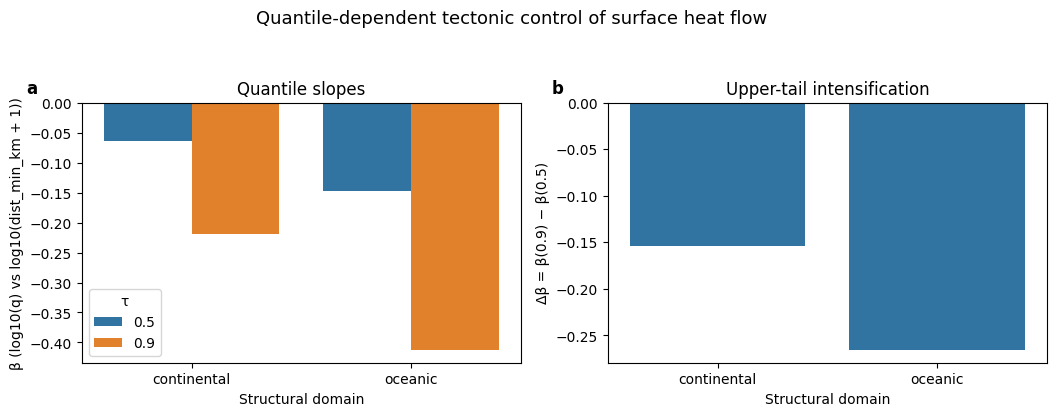

In [21]:
# ==============================================================
# Snippet 21 — Quantile regression (tau = 0.5, 0.9)  (ROUTED)
#
# Purpose:
#   Quantile regression: log10(q) ~ log10(dist_min_km + 1), with tau in {0.5, 0.9},
#   fitted globally and by domain (continental/oceanic).
#   Tests for quantile-dependent amplification of tectonic control,
#   contrasting median and upper-tail conditional trends.
#
# Inputs:
#   gdf_all (read-only analysis; protocol intraplate domain)
#
# Outputs (routed via Snippet 2):
#   - OUT_DIR/analysis/quantreg_results.csv
#   - OUT_DIR/analysis/quantreg_results.md
#   - OUT_DIR/plots/SR2_panel_quantile_slopes.png
#   - OUT_DIR/plots/SR2_panel_quantile_slopes.pdf
#
# + SR duplication (if FIG_SR_DIR is available from Snippet 2):
#   - FIG_SR_DIR/SR2_panel_quantile_slopes.png
#   - FIG_SR_DIR/SR2_panel_quantile_slopes.pdf
#
# Editorial role:
#   DECISION
#   Quantifies asymmetric strengthening of tectonic control in the upper tail.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path  # NEW (minimal)

# Optional (fallback to pure matplotlib if missing)
try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    sns = None
    _HAS_SNS = False

# ---------------- Preconditions ----------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."
need = {"q", "dist_min_km"}
miss = need - set(gdf_all.columns)
assert not miss, f"Missing columns in gdf_all: {miss}"

CSV_OUT = resolve_out_path("quantreg_results.csv", family="analysis")
MD_OUT  = resolve_out_path("quantreg_results.md",  family="analysis")

FIG_PANEL_PNG = resolve_out_path("SR2_panel_quantile_slopes.png", family="plots")
FIG_PANEL_PDF = resolve_out_path("SR2_panel_quantile_slopes.pdf", family="plots")

# NEW: Duplicate SR2 into figures_supplementary_results if FIG_SR_DIR exists
SR_DIR = Path(FIG_SR_DIR) if ("FIG_SR_DIR" in globals() and FIG_SR_DIR is not None) else None
if SR_DIR is not None:
    SR_DIR.mkdir(parents=True, exist_ok=True)
    FIG_PANEL_PNG_SR = SR_DIR / "SR2_panel_quantile_slopes.png"
    FIG_PANEL_PDF_SR = SR_DIR / "SR2_panel_quantile_slopes.pdf"
else:
    FIG_PANEL_PNG_SR = None
    FIG_PANEL_PDF_SR = None

df = gdf_all.copy()

# ---------------- Ensure is_land (if missing) ----------------
if "is_land" not in df.columns:
    def _load_land_polygons(target_crs):
        # Prefer Snippet 2 WORLD_SHP if available
        try:
            if "WORLD_SHP" in globals() and WORLD_SHP is not None:
                land = gpd.read_file(WORLD_SHP).to_crs(target_crs)[["geometry"]]
                return land.explode(index_parts=False, ignore_index=True)
        except Exception:
            pass

        # Fallbacks (best-effort, may fail offline)
        try:
            import geodatasets as gds
            land = gpd.read_file(gds.get_path("naturalearth.land")).to_crs(target_crs)[["geometry"]]
            return land.explode(index_parts=False, ignore_index=True)
        except Exception:
            pass
        try:
            import cartopy.io.shapereader as shpreader
            reader = shpreader.natural_earth(resolution="110m", category="physical", name="land")
            land = gpd.read_file(reader).to_crs(target_crs)[["geometry"]]
            return land.explode(index_parts=False, ignore_index=True)
        except Exception:
            pass
        return None

    land_poly = _load_land_polygons(df.crs or "EPSG:4326")
    if land_poly is not None and not land_poly.empty:
        try:
            df = gpd.sjoin(df, land_poly, how="left", predicate="within")
            df["is_land"] = df["index_right"].notna()
            df = df.drop(columns=["index_right"], errors="ignore")
            print("[S-QUANTILE-REG] is_land built from land polygons.")
        except Exception:
            df["is_land"] = False
            print("[S-QUANTILE-REG] Failed to build is_land; defaulting to is_land=False.")
    else:
        df["is_land"] = False
        print("[S-QUANTILE-REG] No land polygons available; is_land=False for all.")

# ---------------- Cleaning ----------------
df["q"] = pd.to_numeric(df["q"], errors="coerce")
df["dist_min_km"] = pd.to_numeric(df["dist_min_km"], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan)

mask = df["q"].gt(0) & df["dist_min_km"].notna()
df = df.loc[mask, ["q", "dist_min_km", "is_land"]].dropna(subset=["q", "dist_min_km"])

df["logq"] = np.log10(df["q"])
df["logdist1"] = np.log10(df["dist_min_km"] + 1.0)
df = df[np.isfinite(df["logq"]) & np.isfinite(df["logdist1"])]

MIN_N = 100

def fit_quantreg(d: pd.DataFrame, tau: float):
    if len(d) < MIN_N:
        return {
            "tau": tau, "beta": np.nan, "ci_low": np.nan, "ci_high": np.nan,
            "N": int(len(d)), "method": "QuantReg", "note": f"N<{MIN_N}, skipped"
        }
    try:
        X = sm.add_constant(d[["logdist1"]])
        y = d["logq"]
        res = sm.QuantReg(y, X).fit(q=tau)
        beta = float(res.params["logdist1"])
        ci = res.conf_int()
        lo = float(ci.loc["logdist1", 0])
        hi = float(ci.loc["logdist1", 1])
        return {
            "tau": tau, "beta": beta, "ci_low": lo, "ci_high": hi,
            "N": int(len(d)), "method": "QuantReg", "note": ""
        }
    except Exception as e:
        return {
            "tau": tau, "beta": np.nan, "ci_low": np.nan, "ci_high": np.nan,
            "N": int(len(d)), "method": "QuantReg", "note": f"fit_failed: {e.__class__.__name__}"
        }

rows = []

# Global
for tau in (0.5, 0.9):
    r = fit_quantreg(df, tau)
    r["domain"] = "global"
    rows.append(r)

# Domains
for dom, sub in [("continental", df[df["is_land"]]),
                 ("oceanic", df[~df["is_land"]])]:
    for tau in (0.5, 0.9):
        r = fit_quantreg(sub, tau)
        r["domain"] = dom
        rows.append(r)

out = (
    pd.DataFrame(rows)[["domain", "tau", "beta", "ci_low", "ci_high", "N", "method", "note"]]
    .sort_values(["domain", "tau"])
    .reset_index(drop=True)
)

# ---------------- Save tables ----------------
out.to_csv(CSV_OUT, index=False)
with open(MD_OUT, "w", encoding="utf-8") as f:
    f.write("# Quantile regression results\n\n")
    f.write("Model: `log10(q) ~ log10(dist_min_km + 1)`.\n\n")
    try:
        f.write(out.to_markdown(index=False, floatfmt=".4f"))
    except Exception:
        f.write(out.to_string(index=False))
    f.write("\n")

print(out)
print("[S-QUANTILE-REG] Saved:", CSV_OUT, "|", MD_OUT)

# ================= SR2 PANEL =================
try:
    # Only domains (not global)
    plot_df = out[out["domain"] != "global"].copy()

    # enforce stable ordering
    plot_df["domain"] = pd.Categorical(plot_df["domain"], ["continental", "oceanic"], ordered=True)
    plot_df["tau"] = pd.Categorical(plot_df["tau"], [0.5, 0.9], ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    fig.suptitle("Quantile-dependent tectonic control of surface heat flow", fontsize=13)

    # A — slopes by quantile
    if _HAS_SNS:
        sns.barplot(data=plot_df, x="domain", y="beta", hue="tau", ax=axes[0])
    else:
        # simple matplotlib fallback
        domains = ["continental", "oceanic"]
        taus = [0.5, 0.9]
        width = 0.35
        x = np.arange(len(domains))
        for j, tau in enumerate(taus):
            vals = [float(plot_df[(plot_df["domain"] == d) & (plot_df["tau"] == tau)]["beta"].iloc[0]) for d in domains]
            axes[0].bar(x + (j - 0.5) * width, vals, width=width, label=str(tau))
        axes[0].set_xticks(x, domains)

    axes[0].set_title("Quantile slopes")
    axes[0].set_ylabel("β (log10(q) vs log10(dist_min_km + 1))")
    axes[0].set_xlabel("Structural domain")
    axes[0].legend(title="τ", frameon=True, loc="lower left")

    # B — Δβ intensification
    wide = plot_df.pivot(index="domain", columns="tau", values="beta")
    wide["delta"] = wide[0.9] - wide[0.5]
    if _HAS_SNS:
        sns.barplot(x=wide.index, y=wide["delta"], ax=axes[1])
    else:
        axes[1].bar(wide.index.tolist(), wide["delta"].values)

    axes[1].set_title("Upper-tail intensification")
    axes[1].set_ylabel("Δβ = β(0.9) − β(0.5)")
    axes[1].set_xlabel("Structural domain")

    # Panel labels: lowercase, left side of each panel
    axes[0].text(
        -0.10, 1.02, "a",
        transform=axes[0].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    axes[1].text(
        -0.10, 1.02, "b",
        transform=axes[1].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    fig.tight_layout(rect=[0.03, 0, 1, 0.93])

    fig.savefig(FIG_PANEL_PNG, dpi=300, bbox_inches="tight")
    fig.savefig(FIG_PANEL_PDF, dpi=300, bbox_inches="tight")

    # Duplicate SR2 panel into figures_supplementary_results (if available)
    if FIG_PANEL_PNG_SR is not None and FIG_PANEL_PDF_SR is not None:
        fig.savefig(FIG_PANEL_PNG_SR, dpi=300, bbox_inches="tight")
        fig.savefig(FIG_PANEL_PDF_SR, bbox_inches="tight")
        print("[SR] Saved SR2 →", FIG_PANEL_PNG_SR)
        print("[SR] Saved SR2 →", FIG_PANEL_PDF_SR)

    print("[S-QUANTILE-REG] SR2 panel saved:")
    print(" -", FIG_PANEL_PNG)
    print(" -", FIG_PANEL_PDF)

    plt.show()
    plt.close(fig)

except Exception as e:
    print("[S-QUANTILE-REG] SR2 panel failed:", e)

# Snippet 22 — Protocol-aligned cofactor modeling (integrated)

In [22]:
# ==============================================================
# Snippet 22 — Protocol-aligned cofactor modeling (FINAL)  (ROUTED)
#
# Purpose:
#   Test whether spatial cofactors explain variance in log10(q) beyond log10(dist_min_km + 1),
#   strictly under protocol:
#     - canonical intraplate domain
#     - dist_min_km = min(GEM, PB2002)
#     - physical cut: dist_min_km ≥ DIST_CUTOFF_KM km
#
# Strategy:
#   - Try GAM (pygam) if available
#   - Else fallback OLS with spline bases (patsy) + HC3 SE
#   - Uses only cofactors that are actually available and successfully sampled
#
# Inputs:
#   gdf_all (GeoDataFrame EPSG:4326) with q, lon, lat, dist_min_km (+ optional is_land)
#   Optional rasters (paths may be None)
#
# Outputs (routed via Snippet 2):
#   - OUT_DIR/analysis/cofactors_protocol_summary.md
#   - OUT_DIR/analysis/cofactors_protocol_coeffs.csv   (fallback OLS+splines)
#   - OUT_DIR/diagnostics/regressions/cofactors_protocol.SKIPPED.txt  (availability/logs)
#
# Editorial role:
#   DECISION (protocol-aligned)
#   Cofactor assessment under the final protocol; replaces exploratory drafts.
# ==============================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd

# ---------------- Preconditions ----------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_all" in globals(), "gdf_all must be in memory."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."

need = {"q", "lon", "lat", "dist_min_km", "geometry"}
miss = need - set(gdf_all.columns)
assert not miss, f"Missing columns in gdf_all: {miss}"
assert gdf_all.crs is not None and str(gdf_all.crs).endswith("4326"), "Expected CRS=EPSG:4326."

# -------------------------------
# Safe param getter (publication-ready)
# -------------------------------
def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

CUT_KM = _get_param("DIST_CUTOFF_KM", 110.0)

MD_OUT   = resolve_out_path("cofactors_protocol_summary.md", family="analysis")
COEF_OUT = resolve_out_path("cofactors_protocol_coeffs.csv", family="analysis")
SKIP_OUT = resolve_out_path("cofactors_protocol.SKIPPED.txt", family="diag_regressions")

# -------- Set raster paths (may be None) --------
# NOTE: these should exist as strings or Paths in globals, otherwise None is OK.
OCEAN_AGE_RASTER   = globals().get("OCEAN_AGE_RASTER", None)
ELEVATION_RASTER   = globals().get("ELEVATION_RASTER", None)
LITHO_PROXY_RASTER = globals().get("LITHO_PROXY_RASTER", None)  # optional/future

# normalize to string paths (or None)
OCEAN_AGE_RASTER = str(OCEAN_AGE_RASTER) if OCEAN_AGE_RASTER not in (None, "") else None
ELEVATION_RASTER = str(ELEVATION_RASTER) if ELEVATION_RASTER not in (None, "") else None
LITHO_PROXY_RASTER = str(LITHO_PROXY_RASTER) if LITHO_PROXY_RASTER not in (None, "") else None

def log_skip(msg: str):
    with open(SKIP_OUT, "a", encoding="utf-8") as f:
        f.write(msg.strip() + "\n")

def sample_raster_to_points(raster_path: str, xs: pd.Series, ys: pd.Series):
    """
    Sample a single-band raster at lon/lat points.
    Returns np.ndarray or None on failure.
    """
    try:
        import rasterio
        if (raster_path is None) or (not os.path.exists(raster_path)):
            log_skip(f"[COFACTOR] Missing raster: {raster_path}")
            return None
        with rasterio.open(raster_path) as src:
            coords = list(zip(xs.astype(float), ys.astype(float)))
            vals = np.array([v for v in src.sample(coords)])
            if vals.ndim == 2 and vals.shape[1] >= 1:
                vals = vals[:, 0]
            vals = vals.astype(float)
            vals[~np.isfinite(vals)] = np.nan
            return vals
    except Exception as e:
        log_skip(f"[COFACTOR] Raster sampling failed ({raster_path}): {e}")
        return None

# -------- Base cleaning + protocol cut --------
df0 = gdf_all.copy()

for c in ["q", "dist_min_km", "lon", "lat"]:
    df0[c] = pd.to_numeric(df0[c], errors="coerce")
df0 = df0.replace([np.inf, -np.inf], np.nan)

# Capture is_land BEFORE filtering reset (alignment-safe)
if "is_land" in df0.columns:
    df0["is_land"] = pd.to_numeric(df0["is_land"], errors="coerce")

mask = (df0["q"] > 0) & df0["dist_min_km"].notna() & (df0["dist_min_km"] >= CUT_KM)

cols_keep = ["q", "dist_min_km", "lon", "lat"]
if "is_land" in df0.columns:
    cols_keep.append("is_land")

df = df0.loc[mask, cols_keep].copy()
df = df.dropna(subset=["q", "dist_min_km", "lon", "lat"])  # keep index until end

N0 = len(df)
if N0 < 500:
    log_skip(f"[BASE] Too few rows after protocol cut (≥ DIST_CUTOFF_KM km): N={N0}")
    with open(MD_OUT, "w", encoding="utf-8") as f:
        f.write("# Cofactors (protocol) — skipped\n\n")
        f.write(f"Too few rows after protocol filter (N={N0}).\n")
    print("[COFACTORS] Skipped (N too small).")
else:
    df["logq"] = np.log10(df["q"].clip(lower=1e-12))
    df["logdist1"] = np.log10(df["dist_min_km"] + 1.0)

    covariates = []
    availability = []

    # --- Ocean age ---
    vals = sample_raster_to_points(OCEAN_AGE_RASTER, df["lon"], df["lat"])
    if vals is not None:
        df["ocean_age"] = vals
        covariates.append("ocean_age")
        availability.append("ocean_age: OK")
    else:
        availability.append("ocean_age: MISSING/FAIL")

    # --- Elevation ---
    vals = sample_raster_to_points(ELEVATION_RASTER, df["lon"], df["lat"])
    if vals is not None:
        df["elevation"] = vals
        covariates.append("elevation")
        availability.append("elevation: OK")
    else:
        availability.append("elevation: MISSING/FAIL")

    # --- Lithosphere proxy (optional) ---
    vals = sample_raster_to_points(LITHO_PROXY_RASTER, df["lon"], df["lat"])
    if vals is not None:
        df["litho_proxy"] = vals
        covariates.append("litho_proxy")
        availability.append("litho_proxy: OK")
    else:
        availability.append("litho_proxy: OFF/MISSING/FAIL")

    # --- is_land (already aligned) ---
    if "is_land" in df.columns:
        covariates.append("is_land")
        availability.append("is_land: OK")
    else:
        availability.append("is_land: not present")

    # Keep rows with needed predictors
    use_cols = ["logq", "logdist1"] + covariates
    df_use = df.dropna(subset=use_cols).copy()
    N1 = len(df_use)

    # -------- Write availability header now (always) --------
    with open(MD_OUT, "w", encoding="utf-8") as f:
        f.write("# Cofactors (protocol-aligned)\n\n")
        f.write("## Availability\n\n")
        for line in availability:
            f.write(f"- {line}\n")
        f.write("\n")
        f.write("## Base protocol\n\n")
        f.write(f"- Cut: dist_min_km ≥ DIST_CUTOFF_KM km\n")
        f.write(f"- Rows after cut: {N0}\n")
        f.write(f"- Rows after cofactor NA filtering: {N1}\n\n")

    if N1 < 500:
        log_skip(f"[COFACTORS] Too few rows after adding cofactors: N={N1}")
        with open(MD_OUT, "a", encoding="utf-8") as f:
            f.write("## Result\n\nSkipped: too few rows after cofactor filtering.\n")
        print("[COFACTORS] Skipped after covariate filtering.")
    else:
        X_cols = ["logdist1"] + covariates

        # -------- Try GAM (pygam) --------
        used_gam = False
        try:
            from pygam import LinearGAM, s

            X = df_use[X_cols].to_numpy()
            y = df_use["logq"].to_numpy()

            terms = sum(s(i, n_splines=10) for i in range(X.shape[1]))
            gam = LinearGAM(terms).fit(X, y)

            dev_exp = float(gam.statistics_.get("pseudo_r2", np.nan))
            edofs = gam.statistics_.get("edof_per_term", [np.nan] * X.shape[1])

            with open(MD_OUT, "a", encoding="utf-8") as f:
                f.write("## Model\n\n")
                f.write("### GAM (pygam)\n\n")
                f.write(f"- Predictors: {', '.join(X_cols)}\n")
                f.write(f"- N: {N1}\n")
                f.write(f"- Deviance explained (pseudo-R²): {dev_exp:.3f}\n\n")
                f.write("#### Effective degrees of freedom per term\n\n")
                for i, name in enumerate(X_cols):
                    ed = float(edofs[i]) if i < len(edofs) else float("nan")
                    f.write(f"- {name}: edof ≈ {ed:.2f}\n")

            print(f"[COFACTORS][GAM] OK | pseudo-R²={dev_exp:.3f} | predictors={X_cols}")
            used_gam = True

        except Exception as e:
            log_skip(f"[COFACTORS] GAM failed → OLS+splines fallback: {e}")

        # -------- Fallback: OLS + splines + HC3 --------
        if not used_gam:
            try:
                import statsmodels.api as sm
                from patsy import dmatrix

                design_parts = []

                Xd = dmatrix(
                    "bs(x, df=6, degree=3, include_intercept=False)",
                    {"x": df_use["logdist1"]},
                    return_type="dataframe",
                )
                Xd.columns = [f"s_logdist1_{i}" for i in range(1, len(Xd.columns) + 1)]
                design_parts.append(Xd)

                for c in covariates:
                    if c == "is_land":
                        design_parts.append(df_use[[c]].astype(float))
                    else:
                        xcov = pd.to_numeric(df_use[c], errors="coerce")
                        Xc = dmatrix(
                            "bs(x, df=6, degree=3, include_intercept=False)",
                            {"x": xcov},
                            return_type="dataframe",
                        )
                        Xc.columns = [f"s_{c}_{i}" for i in range(1, len(Xc.columns) + 1)]
                        design_parts.append(Xc)

                Xmat = pd.concat(design_parts, axis=1)
                Xmat = sm.add_constant(Xmat, has_constant="add")

                model = sm.OLS(df_use["logq"], Xmat).fit(cov_type="HC3")

                coef = model.params.rename("coef").to_frame()
                coef["se_HC3"] = model.bse
                coef["pval"] = model.pvalues
                coef.to_csv(COEF_OUT)

                with open(MD_OUT, "a", encoding="utf-8") as f:
                    f.write("## Model\n\n")
                    f.write("### OLS with spline bases (fallback)\n\n")
                    f.write(f"- Predictors: logdist1 + {', '.join(covariates) if covariates else '(no extra cofactors)'}\n")
                    f.write(f"- N: {int(model.nobs)}\n")
                    f.write(f"- R²: {model.rsquared:.3f}\n\n")

                    t_abs = (coef["coef"] / coef["se_HC3"]).abs().sort_values(ascending=False)
                    top = coef.loc[t_abs.index].head(15).copy()
                    f.write("#### Top terms by |t|\n\n")
                    try:
                        f.write(top.to_markdown())
                    except Exception:
                        f.write(top.to_string())
                    f.write("\n")

                print(f"[COFACTORS][OLS-splines] OK | R²={model.rsquared:.3f} | N={int(model.nobs)} | predictors={X_cols}")

            except Exception as e:
                log_skip(f"[COFACTORS] OLS+splines failed: {e}")
                with open(MD_OUT, "a", encoding="utf-8") as f:
                    f.write("## Result\n\nAll strategies failed.\n")
                print("[COFACTORS] All strategies failed (see SKIPPED).")

[COFACTORS][OLS-splines] OK | R²=0.068 | N=53420 | predictors=['logdist1']


# Snippet 23 — Placebo: random line segments

In [23]:
# ==============================================================
# Snippet 23 — Placebo: random line segments  (ROUTED)
#
# Purpose:
#   Placebo experiment using random line segments matched to the empirical length
#   distribution of real faults. Compares:
#     (a) real distances:    dist_min_km
#     (b) placebo distances: dist_random_km
#   Stores Pearson p-values in log-space (finite log10(p)) to avoid underflow.
#
# Inputs:
#   - gdf_all : GeoDataFrame (EPSG:4326) with q, lon, lat, dist_min_km, geometry
#   - faults_full OR faults_gem/faults_pb in memory (optional)
#   - GEM_SHP / PB2002_SHP paths from Snippet 2 (fallback)
#
# Outputs (routed via Snippet 2):
#   - OUT_DIR/analysis/placebo_random_lines.csv
#   - OUT_DIR/analysis/placebo_random_lines.md
#   - OUT_DIR/diagnostics/outliers/placebo_random_lines.SKIPPED.txt
#
# Editorial role:
#   DECISION
#   Negative control supporting interpretation of distance-to-fault effects.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from shapely.geometry import LineString, Point
from shapely.ops import unary_union
from scipy import stats

# ---------------- Preconditions ----------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame."
assert gdf_all.crs is not None and str(gdf_all.crs).endswith("4326"), "Expected gdf_all CRS=EPSG:4326."

need = {"q", "lon", "lat", "dist_min_km", "geometry"}
miss = need - set(gdf_all.columns)
assert not miss, f"Missing columns in gdf_all: {miss}"

CSV_OUT  = resolve_out_path("placebo_random_lines.csv", family="analysis")
MD_OUT   = resolve_out_path("placebo_random_lines.md", family="analysis")
SKIP_OUT = resolve_out_path("placebo_random_lines.SKIPPED.txt", family="diag_outliers")

RNG = np.random.default_rng(42)

# ---------------- Pearson r with log-space p (finite log10(p)) ----------------
def pearsonr_log10p(x, y):
    """
    Pearson correlation and two-sided p-value computed in log-space.
    Returns: r, log10_p (finite), p_value_str, n
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = int(x.size)
    if n < 3:
        return np.nan, np.nan, "NA", n

    r = float(np.corrcoef(x, y)[0, 1])
    r = float(np.clip(r, -1.0, 1.0))

    df = n - 2
    denom = (1.0 - r * r)

    # Guard: r extremely close to ±1 (numerical)
    if denom <= 0:
        log10_p = -1e6  # finite placeholder
    else:
        t = abs(r) * np.sqrt(df / denom)

        # Primary: Student-t tail in log-space
        log_p = np.log(2.0) + stats.t.logsf(t, df)  # two-sided
        log10_p = float(log_p / np.log(10.0))

        # Fallback: if -inf (rare), use Normal approx (also log-space)
        if not np.isfinite(log10_p):
            log_p2 = np.log(2.0) + stats.norm.logsf(t)
            log10_p = float(log_p2 / np.log(10.0))

    exp_floor = int(np.floor(log10_p)) if np.isfinite(log10_p) else -999999
    p_value_str = f"< 1e{exp_floor}"
    return r, log10_p, p_value_str, n

# ---------------- Faults loader ----------------
def _append_skip(msg: str) -> None:
    with open(SKIP_OUT, "a", encoding="utf-8") as f:
        f.write(msg.rstrip() + "\n")

def _try_load_faults():
    # Prefer already-loaded in-memory layers (fast + reproducible)
    if "faults_full" in globals() and isinstance(faults_full, gpd.GeoDataFrame) and not faults_full.empty:
        return faults_full[["geometry"]]

    parts = []
    if "faults_gem" in globals() and isinstance(faults_gem, gpd.GeoDataFrame) and not faults_gem.empty:
        parts.append(faults_gem[["geometry"]])
    if "faults_pb" in globals() and isinstance(faults_pb, gpd.GeoDataFrame) and not faults_pb.empty:
        parts.append(faults_pb[["geometry"]])

    if parts:
        return gpd.GeoDataFrame(
            pd.concat(parts, ignore_index=True),
            geometry="geometry",
            crs=parts[0].crs or gdf_all.crs
        )

    # Fallback: read from paths defined in Snippet 2
    # NOTE: Snippet 2 uses GEM_SHP and PB2002_SHP
    for varname in ("GEM_SHP", "PB2002_SHP"):
        if varname in globals() and globals()[varname] is not None:
            try:
                layer = gpd.read_file(globals()[varname])
                return gpd.GeoDataFrame(layer[["geometry"]], geometry="geometry", crs=layer.crs)
            except Exception as e:
                _append_skip(f"Failed to read {varname}: {e}")
    return None

faults_raw = _try_load_faults()

if faults_raw is None or faults_raw.empty:
    with open(MD_OUT, "w", encoding="utf-8") as f:
        f.write("**SKIPPED**: No faults layer available.\n")
    print("[PLACEBO] SKIPPED: no faults available.")
else:
    # ---------------- Real fault length distribution ----------------
    faults = faults_raw.to_crs(3857).copy()
    faults["len_m"] = pd.to_numeric(faults.geometry.length, errors="coerce")
    lens = faults["len_m"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    lens = lens[(lens > 0) & np.isfinite(lens)]

    if lens.size == 0:
        with open(MD_OUT, "w", encoding="utf-8") as f:
            f.write("**SKIPPED**: Faults without valid lengths.\n")
        print("[PLACEBO] SKIPPED: no valid fault lengths.")
    else:
        import pyproj
        from shapely.ops import transform

        # ---------------- Random line generator ----------------
        def random_segment(length_m, lon, lat):
            aeqd = pyproj.CRS.from_proj4(
                f"+proj=aeqd +lat_0={lat} +lon_0={lon} "
                "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
            )
            wgs84 = pyproj.CRS.from_epsg(4326)
            fwd = pyproj.Transformer.from_crs(wgs84, aeqd, always_xy=True).transform
            inv = pyproj.Transformer.from_crs(aeqd, wgs84, always_xy=True).transform

            theta = RNG.uniform(0, 2 * np.pi)
            dx = (length_m / 2) * np.cos(theta)
            dy = (length_m / 2) * np.sin(theta)

            c_xy = transform(fwd, Point(lon, lat))
            p1 = Point(c_xy.x - dx, c_xy.y - dy)
            p2 = Point(c_xy.x + dx, c_xy.y + dy)
            return transform(inv, LineString([p1, p2]))

        # ---------------- Build placebo network ----------------
        N_SEGS = min(2000, int(lens.size))
        centers = gdf_all.sample(N_SEGS, random_state=42)[["lon", "lat"]].to_numpy()
        lengths = RNG.choice(lens, size=N_SEGS, replace=True)

        rand_lines = [random_segment(L, lon, lat) for (lon, lat), L in zip(centers, lengths)]
        g_rand = gpd.GeoDataFrame(geometry=rand_lines, crs="EPSG:4326").to_crs(3857)

        # ---------------- Distances to placebo network ----------------
        pts = gdf_all.to_crs(3857)[["geometry"]]
        rand_union = unary_union(g_rand.geometry)

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            d_m = pts.geometry.apply(lambda p: p.distance(rand_union))

        gdf_tmp = gdf_all.copy()
        gdf_tmp["dist_random_km"] = d_m.to_numpy(dtype=float) / 1000.0

        # ---------------- Safe log transform ----------------
        def log10p1(s):
            s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
            s = s.clip(lower=0.0)
            return np.log10(s + 1.0)

        # ---------------- REAL model ----------------
        m_real = gdf_tmp["q"].gt(0) & gdf_tmp["dist_min_km"].notna()
        x_real = log10p1(gdf_tmp.loc[m_real, "dist_min_km"]).to_numpy(dtype=float)
        y_real = np.log10(pd.to_numeric(gdf_tmp.loc[m_real, "q"], errors="coerce").to_numpy(dtype=float))

        r_real, log10p_real, pstr_real, n_real = pearsonr_log10p(x_real, y_real)
        a_real, b_real = np.polyfit(
            x_real[np.isfinite(x_real) & np.isfinite(y_real)],
            y_real[np.isfinite(x_real) & np.isfinite(y_real)],
            1
        )

        # ---------------- PLACEBO model ----------------
        m_pl = gdf_tmp["q"].gt(0) & gdf_tmp["dist_random_km"].notna()
        x_pl = log10p1(gdf_tmp.loc[m_pl, "dist_random_km"]).to_numpy(dtype=float)
        y_pl = np.log10(pd.to_numeric(gdf_tmp.loc[m_pl, "q"], errors="coerce").to_numpy(dtype=float))

        r_pl, log10p_pl, pstr_pl, n_pl = pearsonr_log10p(x_pl, y_pl)
        a_pl, b_pl = np.polyfit(
            x_pl[np.isfinite(x_pl) & np.isfinite(y_pl)],
            y_pl[np.isfinite(x_pl) & np.isfinite(y_pl)],
            1
        )

        # ---------------- Output table ----------------
        df_out = pd.DataFrame([
            {
                "config": "REAL_min(GEM,PB2002)",
                "r": float(r_real),
                "p_value_str": pstr_real,
                "log10_p": float(log10p_real),
                "slope": float(a_real),
                "intercept": float(b_real),
                "N": int(n_real),
            },
            {
                "config": "PLACEBO_random_lines",
                "r": float(r_pl),
                "p_value_str": pstr_pl,
                "log10_p": float(log10p_pl),
                "slope": float(a_pl),
                "intercept": float(b_pl),
                "N": int(n_pl),
            },
        ])

        df_out.to_csv(CSV_OUT, index=False)

        with open(MD_OUT, "w", encoding="utf-8") as f:
            f.write("# Random-lines placebo vs. real distance model\n\n")
            f.write("Pearson correlation between `log10(q)` and `log10(distance + 1)`.\n\n")
            f.write("p-values computed in log-space (two-sided) to avoid underflow.\n\n")
            try:
                f.write(df_out.to_markdown(index=False, floatfmt=".6f"))
            except Exception:
                f.write(df_out.to_string(index=False))
            f.write("\n")

        print(df_out)
        print("[PLACEBO] Saved:", CSV_OUT, "|", MD_OUT)

                 config         r p_value_str      log10_p     slope  \
0  REAL_min(GEM,PB2002) -0.295073   < 1e-1888 -1887.838424 -0.129227   
1  PLACEBO_random_lines -0.299199   < 1e-1947 -1946.165944 -0.129248   

   intercept      N  
0   2.156366  91059  
1   2.067463  91059  
[PLACEBO] Saved: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\placebo_random_lines.csv | C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\placebo_random_lines.md


# Snippet 24 — Outlier summary (official protocol flags)

In [24]:
# ==============================================================
# Snippet 24 — Outlier summary (official protocol flags)  (ROUTED)
#
# Purpose:
#   Compute protocol outlier flags:
#     - IQR-based (linear q, log10 q)
#     - Extreme (q ≥ 1,000)
#     - Ultra-rare (q ≥ 100,000)
#     - Relevant (q ≥ THR_Q_RELEV)
#   and corresponding versions restricted to dist_min_km ≥ DIST_CUTOFF_KM.
#
# Inputs (required):
#   - gdf_all : GeoDataFrame with at least {'q','dist_min_km'} (produced in Snippet 3)
#
# Inputs (optional, parameters):
#   - require_param / PARAMS with:
#       * Q_THR_RELEV / THR_LOG_RELEV / DIST_CUTOFF_KM
#
# Outputs (globals for downstream):
#   - gdf_out : GeoDataFrame = gdf_all + protocol outlier flags
#   - summary : DataFrame with protocol outlier counts/stats
#
# Outputs (files, routed via Snippet 2):
#   - OUT_DIR/analysis/outliers_summary.csv
#   - OUT_DIR/analysis/outliers_summary.md
#
# Editorial role:
#   METHOD
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd

assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_all" in globals(), "Missing required variable: gdf_all (produced in Snippet 3)."

# -------------------------------
# Helpers: safe parameter getter
# -------------------------------
def _get_param(name: str, default: float) -> float:
    """
    Prefer require_param(name) if available; otherwise fall back to:
    - PARAMS[name] if present
    - default
    """
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# -------------------------------
# Config / defaults (safe)
# -------------------------------
THR_Q_RELEV     = _get_param("Q_THR_RELEV", 169.0)
THR_LOG_RELEV   = _get_param("THR_LOG_RELEV", np.log10(THR_Q_RELEV))
DIST_CUTOFF_KM  = _get_param("DIST_CUTOFF_KM", 110.0)

CSV_OUT = resolve_out_path("outliers_summary.csv", family="analysis")
MD_OUT  = resolve_out_path("outliers_summary.md",  family="analysis")

# -------------------------------
# Core function
# -------------------------------
def compute_outliers_and_summary(gdf_all: gpd.GeoDataFrame):
    assert isinstance(gdf_all, gpd.GeoDataFrame), "gdf_all must be a GeoDataFrame"
    df = gdf_all.copy()

    required = {"q", "dist_min_km"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns in gdf_all: {missing}")

    # log_q is optional: compute if missing
    if "log_q" not in df.columns:
        df["log_q"] = np.log10(pd.to_numeric(df["q"], errors="coerce").where(lambda s: s > 0))

    q_lin = pd.to_numeric(df["q"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    q_log = pd.to_numeric(df["log_q"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    d_min = pd.to_numeric(df["dist_min_km"], errors="coerce").replace([np.inf, -np.inf], np.nan)

    # Validity masks for threshold computation
    m_q_valid   = q_lin.notna() & (q_lin > 0)
    m_log_valid = q_log.notna() & np.isfinite(q_log.values)
    m_d_valid   = d_min.notna() & (d_min >= 0)

    # -------------------------------
    # IQR thresholds (dataset-wide, valid only)
    # -------------------------------
    qv = q_lin[m_q_valid]
    if len(qv) < 10:
        raise ValueError(f"Not enough valid q values to compute IQR (n={len(qv)}).")

    q1_lin, q3_lin = qv.quantile([0.25, 0.75])
    thr_lin_iqr = float(q3_lin + 1.5 * (q3_lin - q1_lin))

    lv = q_log[m_q_valid & m_log_valid]  # tie log to valid q
    if len(lv) < 10:
        raise ValueError(f"Not enough valid log_q values to compute IQR (n={len(lv)}).")

    q1_log, q3_log = lv.quantile([0.25, 0.75])
    thr_log_iqr = float(q3_log + 1.5 * (q3_log - q1_log))

    # -------------------------------
    # Flags (boolean, NaN-safe)
    # -------------------------------
    df["outlier_linear"]        = m_q_valid & (q_lin >= thr_lin_iqr)
    df["outlier_log"]           = (m_q_valid & m_log_valid) & (q_log >= thr_log_iqr)
    df["outlier_extreme"]       = m_q_valid & (q_lin >= 1_000.0)
    df["outlier_ultrarare"]     = m_q_valid & (q_lin >= 100_000.0)
    df["outlier_relevant_lin"]  = m_q_valid & (q_lin >= THR_Q_RELEV)
    df["outlier_relevant_log"]  = (m_q_valid & m_log_valid) & (q_log >= THR_LOG_RELEV)

    df["outlier_any"] = df[
        [
            "outlier_linear",
            "outlier_log",
            "outlier_extreme",
            "outlier_ultrarare",
            "outlier_relevant_lin",
            "outlier_relevant_log",
        ]
    ].any(axis=1)

    # Distance-constrained versions (dist_min_km ≥ DIST_CUTOFF_KM)
    m_dist = m_d_valid & (d_min >= DIST_CUTOFF_KM)
    for c in [
        "outlier_linear",
        "outlier_log",
        "outlier_extreme",
        "outlier_ultrarare",
        "outlier_relevant_lin",
        "outlier_relevant_log",
        "outlier_any",
    ]:
        df[f"{c}_dist"] = df[c] & m_dist

    # -------------------------------
    # Summary table
    # -------------------------------
    def _pct_over_all(mask: pd.Series) -> float:
        return 100.0 * float(mask.mean())

    def _pct_within_dist_domain(mask_dist: pd.Series) -> float:
        denom = float(m_dist.sum())
        return (100.0 * float(mask_dist.sum()) / denom) if denom > 0 else np.nan

    categories = [
        ("outlier_linear",       "IQR (linear q)"),
        ("outlier_log",          "IQR (log10 q)"),
        ("outlier_extreme",      "Extreme (q ≥ 1,000)"),
        ("outlier_ultrarare",    "Ultra-rare (q ≥ 100,000)"),
        ("outlier_relevant_lin", f"Relevant (q ≥ {THR_Q_RELEV:.0f})"),
        ("outlier_relevant_log", f"Relevant (log10 q ≥ {THR_LOG_RELEV:.3f})"),
        ("outlier_any",          "Any (protocol/value-based)"),
    ]

    rows = []
    for col, label in categories:
        cutoff_txt = (
            f"q ≥ {thr_lin_iqr:.1f}" if col == "outlier_linear" else
            f"log10(q) ≥ {thr_log_iqr:.3f} (~{10**thr_log_iqr:.0f})" if col == "outlier_log" else
            "q ≥ 1,000" if col == "outlier_extreme" else
            "q ≥ 100,000" if col == "outlier_ultrarare" else
            f"q ≥ {THR_Q_RELEV:.0f}" if col == "outlier_relevant_lin" else
            f"log10(q) ≥ {THR_LOG_RELEV:.3f}" if col == "outlier_relevant_log" else
            "-"
        )

        rows.append(
            {
                "Category": label,
                "Flag": col,
                "Cutoff": cutoff_txt,
                "N_all": int(df[col].sum()),
                "pct_all": _pct_over_all(df[col]),
                "N_dist_ge_cut": int(df[f"{col}_dist"].sum()),
                "pct_within_dist_domain": _pct_within_dist_domain(df[f"{col}_dist"]),
            }
        )

    summary = pd.DataFrame(rows)

    print(
        "[OUTLIERS] thresholds (computed / protocol):\n"
        f"  IQR linear : q ≥ {thr_lin_iqr:.1f}\n"
        f"  IQR log10  : log10(q) ≥ {thr_log_iqr:.3f} (~{10**thr_log_iqr:.0f})\n"
        f"  Relevant   : q ≥ {THR_Q_RELEV:.0f} | log10(q) ≥ {THR_LOG_RELEV:.3f}\n"
        f"  Dist domain: dist_min_km ≥ {DIST_CUTOFF_KM:.0f} km (N={int(m_dist.sum()):,})"
    )

    return df, summary

# -------------------------------
# Run + save
# -------------------------------
gdf_out, summary = compute_outliers_and_summary(gdf_all)

summary.to_csv(CSV_OUT, index=False)

with open(MD_OUT, "w", encoding="utf-8") as f:
    f.write("# Outlier categories summary\n\n")
    f.write(
        "Protocol thresholds:\n"
        f"- THR_Q_RELEV = {THR_Q_RELEV:.1f} mW m^-2\n"
        f"- THR_LOG_RELEV = {THR_LOG_RELEV:.3f}\n"
        f"- DIST_CUTOFF_KM = {DIST_CUTOFF_KM:.1f} km\n\n"
    )
    f.write("IQR thresholds computed on valid q>0 rows:\n")
    f.write(f"- IQR (linear) upper fence: {summary.loc[summary['Flag']=='outlier_linear','Cutoff'].values[0]}\n")
    f.write(f"- IQR (log10) upper fence : {summary.loc[summary['Flag']=='outlier_log','Cutoff'].values[0]}\n\n")
    try:
        f.write(summary.to_markdown(index=False, floatfmt=".3f"))
    except Exception:
        f.write(summary.to_string(index=False))
    f.write("\n")

print("[S-OUTLIERS-SUMMARY] Saved:")
print(" -", CSV_OUT)
print(" -", MD_OUT)
# gdf_out now carries all official outlier flags in memory.
# ==============================================================

[OUTLIERS] thresholds (computed / protocol):
  IQR linear : q ≥ 169.0
  IQR log10  : log10(q) ≥ 2.432 (~270)
  Relevant   : q ≥ 169 | log10(q) ≥ 2.432
  Dist domain: dist_min_km ≥ 110 km (N=53,420)
[S-OUTLIERS-SUMMARY] Saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\outliers_summary.csv
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\outliers_summary.md


# Snippet 25 — Protocol harmonizer (canonical)

In [25]:
# ==============================================================
# Snippet 25 — Protocol harmonizer (canonical)  (PIPELINE-COMPAT)
#
# Purpose:
#   Harmonize outlier flags according to the finalized protocol:
#     - remove deprecated outlier_relevant_log
#     - rebuild outlier_any from protocol-sanctioned flags
#     - build outlier_any_dist from corresponding _dist flags when available
#   Non-destructive: operates on gdf_out/summary produced upstream.
#
# Inputs:
#   - gdf_out + summary (from Snippet 35)
#
# Outputs (in-memory):
#   - gdf_out (harmonized flags)
#   - summary (harmonized; deprecated row removed; "Any" row updated)
#   - summary_harmonized (alias)
#
# Editorial role:
#   METHOD
#   Canonical consistency layer ensuring outlier flags match the final protocol.
# ==============================================================

import numpy as np
import pandas as pd

# ---------- Preconditions ----------
assert "gdf_out" in globals(), "'gdf_out' not found. Run Snippet 35 first."
assert isinstance(gdf_out, (pd.DataFrame,)), "'gdf_out' must be a DataFrame/GeoDataFrame."
assert "summary" in globals(), "'summary' not found. Run Snippet 35 first."

gdf_out = gdf_out.copy()

# Core protocol flags (log-based 'relevant_log' is deprecated)
base_flags = [
    "outlier_linear",
    "outlier_log",
    "outlier_extreme",
    "outlier_ultrarare",
    "outlier_relevant_lin",
]

# Drop deprecated column if present
if "outlier_relevant_log" in gdf_out.columns:
    gdf_out = gdf_out.drop(columns=["outlier_relevant_log"])

# Ensure required flags exist
missing_base = [c for c in base_flags if c not in gdf_out.columns]
if missing_base:
    raise KeyError(f"[PROTOCOL] Missing required outlier flags: {missing_base}")

# ---------- Rebuild 'outlier_any' ----------
gdf_out["outlier_any"] = gdf_out[base_flags].any(axis=1)

# ---------- Rebuild 'outlier_any_dist' when distance-based flags exist ----------
dist_flags = [f"{c}_dist" for c in base_flags]
if all(c in gdf_out.columns for c in dist_flags):
    gdf_out["outlier_any_dist"] = gdf_out[dist_flags].any(axis=1)

# ---------- Harmonize `summary` table, if available ----------
if isinstance(summary, pd.DataFrame):
    summary = summary.copy()

    # Defensive: ensure key columns exist (Snippet 35 outputs)
    # Expected: Category, Flag, Cutoff, N_all, pct_all, N_dist_ge_cut, pct_within_dist_domain
    colmap_candidates = {
        "category": "Category",
        "flag": "Flag",
        "cutoff": "Cutoff",
        "n_all": "N_all",
        "pct_all": "pct_all",
        "n_dist_ge_cut": "N_dist_ge_cut",
        "pct_within_dist_domain": "pct_within_dist_domain",
    }
    # If user modified headings elsewhere, try a light normalization (no-op if already correct)
    for _k, _v in colmap_candidates.items():
        if _v not in summary.columns:
            # try case-insensitive match
            matches = [c for c in summary.columns if str(c).strip().lower() == _v.strip().lower()]
            if matches:
                summary = summary.rename(columns={matches[0]: _v})

    if "Category" in summary.columns:
        # Remove deprecated log-based "Relevant (log10 …)" row(s), if any
        mask_keep = ~summary["Category"].astype(str).str.contains(r"Relevant\s*\(log10", regex=True)
        summary = summary.loc[mask_keep].copy()

    def _pct(s: pd.Series) -> float:
        return 100.0 * float(s.mean()) if len(s) else 0.0

    any_all = int(gdf_out["outlier_any"].sum())
    any_all_pct = _pct(gdf_out["outlier_any"])

    if "outlier_any_dist" in gdf_out.columns:
        any_d = int(gdf_out["outlier_any_dist"].sum())
        any_d_pct = _pct(gdf_out["outlier_any_dist"])
    else:
        any_d, any_d_pct = (np.nan, np.nan)

    # Locate the "Any" row (Snippet 35 uses: "Any (protocol/value-based)")
    row_any = None
    if "Flag" in summary.columns:
        row_any = summary["Flag"].astype(str).str.strip().eq("outlier_any")
    if (row_any is None or not row_any.any()) and "Category" in summary.columns:
        row_any = summary["Category"].astype(str).str.contains(r"\bAny\b", regex=True)

    if row_any is not None and row_any.any():
        idx = summary.index[row_any][0]

        # Update using Snippet 35 column names
        if "N_all" in summary.columns:
            summary.at[idx, "N_all"] = any_all
        if "pct_all" in summary.columns:
            summary.at[idx, "pct_all"] = any_all_pct

        if "N_dist_ge_cut" in summary.columns:
            summary.at[idx, "N_dist_ge_cut"] = any_d
        if "pct_within_dist_domain" in summary.columns:
            summary.at[idx, "pct_within_dist_domain"] = any_d_pct

        # Optional: standardize label (non-invasive)
        if "Category" in summary.columns:
            summary.at[idx, "Category"] = "Any (protocol/value-based)"
        if "Flag" in summary.columns:
            summary.at[idx, "Flag"] = "outlier_any"

    else:
        # Append (defensive)
        new_row = {
            "Category": "Any (protocol/value-based)",
            "Flag": "outlier_any",
            "Cutoff": "-",
            "N_all": any_all,
            "pct_all": any_all_pct,
        }
        if "N_dist_ge_cut" in summary.columns:
            new_row["N_dist_ge_cut"] = any_d
        if "pct_within_dist_domain" in summary.columns:
            new_row["pct_within_dist_domain"] = any_d_pct

        summary = pd.concat([summary, pd.DataFrame([new_row])], ignore_index=True)

    # Expose harmonized summary for later snippets
    summary_harmonized = summary

# ---------- Sanity print ----------
expected_cols = base_flags + ["outlier_any"]
print("=== [PROTOCOL-HARMONIZER] Column check ===")
missing_expected = [c for c in expected_cols if c not in gdf_out.columns]
if missing_expected:
    print("[WARN] Missing expected columns:", missing_expected)
else:
    print("[OK] All expected protocol flags present.")
# ==============================================================

=== [PROTOCOL-HARMONIZER] Column check ===
[OK] All expected protocol flags present.


# Snippet 26 — Comparative stats (outliers vs normals; dist ≥110)

[S-COMPARATIVE-STATS] dist ≥ 110 km | THR_Q_RELEV=169
[S-COMPARATIVE-STATS] Normals: 51,457 | Outliers: 1,963
                             test          stat p_value_str      log10_p  \
0                  Mann–Whitney U  0.000000e+00   < 1e-1234 -1233.741327   
1                          KS (q)  1.000000e+00    < 1e-413  -412.333074   
2        Mann–Whitney U (log10 q)  0.000000e+00   < 1e-1234 -1233.741327   
3                    KS (log10 q)  1.000000e+00    < 1e-413  -412.333074   
4        Mann–Whitney U (dist_km)  8.273858e+07    < 1e-504  -503.515347   
5                    KS (dist_km)  4.998474e-01    < 1e-105  -104.022603   
6  Mann–Whitney U [log10(dist+1)]  8.273858e+07    < 1e-504  -503.515347   
7              KS [log10(dist+1)]  4.998474e-01    < 1e-105  -104.022603   

                                note  
0  normal approx (no tie correction)  
1                 asymptotic mapping  
2  normal approx (no tie correction)  
3                 asymptotic mapping  
4  normal 

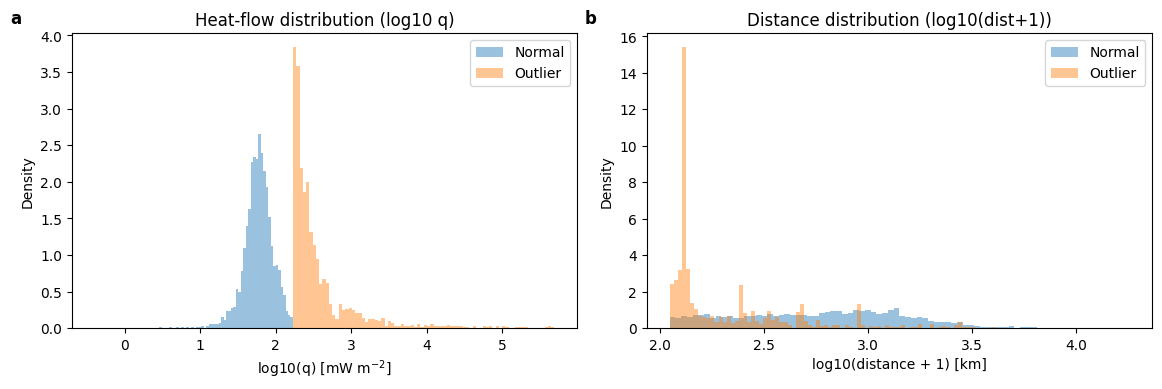

C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\706775501.py:260: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([logq_norm, logq_out], showfliers=False, labels=["Normal", "Outlier"])
C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\706775501.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([logd_norm, logd_out], showfliers=False, labels=["Normal", "Outlier"])


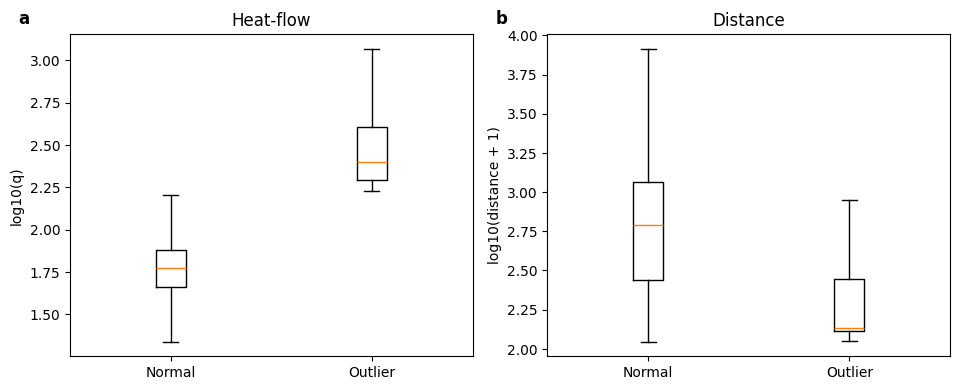

[S-COMPARATIVE-STATS] Figures saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\FigS_outliers_normals_hist.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\FigS_outliers_normals_box.png


In [26]:
# ==============================================================
# Snippet 26 — Comparative stats (outliers vs normals; dist ≥ cutoff)  (ROUTED)
#
# Purpose:
#   Compare relevant outliers (q ≥ THR_Q_RELEV) vs normals within the intraplate domain
#   (dist_min_km ≥ DIST_CUTOFF_KM) using:
#     - Mann–Whitney U (two-sided; normal approximation; log10(p) reported)
#     - KS two-sample (two-sided; asymptotic; log10(p) reported)
#     - Effect size: Cohen's d in log10(q)
#
# Inputs:
#   gdf_out (from Snippet 35/36; contains outlier flags)
#
# Outputs (routed via Snippet 2):
#   - OUT_DIR/analysis/outliers_vs_normals_stats.md
#   - OUT_DIR/plots/FigS_outliers_normals_hist.png
#   - OUT_DIR/plots/FigS_outliers_normals_box.png
#
# Editorial role:
#   DECISION
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# -------------------------------
# Safe param getter (NG-clean)
# -------------------------------
def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# -------------------------------
# Preconditions
# -------------------------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_out" in globals(), "'gdf_out' not found (run Snippet 35/36 first)."

DIST_CUTOFF_KM = _get_param("DIST_CUTOFF_KM", 110.0)
THR_Q_RELEV    = _get_param("Q_THR_RELEV", 169.0)

OUTLIER_COL = "outlier_relevant_lin"
DIST_COL    = "dist_min_km"

if OUTLIER_COL not in gdf_out.columns:
    raise KeyError(f"Missing column '{OUTLIER_COL}' in gdf_out. Run Snippet 35 first.")
for c in ["q", DIST_COL]:
    if c not in gdf_out.columns:
        raise KeyError(f"Missing column '{c}' in gdf_out.")

MD_OUT   = resolve_out_path("outliers_vs_normals_stats.md", family="analysis")
FIG_HIST = resolve_out_path("FigS_outliers_normals_hist.png", family="plots")
FIG_BOX  = resolve_out_path("FigS_outliers_normals_box.png", family="plots")

# -------------------------------
# Clean + intraplate subset
# -------------------------------
df = gdf_out.copy()

df["q"]      = pd.to_numeric(df["q"], errors="coerce")
df[DIST_COL] = pd.to_numeric(df[DIST_COL], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["q", DIST_COL, OUTLIER_COL])
df = df[(df["q"] > 0) & (df[DIST_COL] >= 0)].copy()

# intraplate cut
df = df[df[DIST_COL] >= DIST_CUTOFF_KM].copy()

normals  = df.loc[~df[OUTLIER_COL], ["q", DIST_COL]].copy()
outliers = df.loc[ df[OUTLIER_COL], ["q", DIST_COL]].copy()

print(f"[S-COMPARATIVE-STATS] dist ≥ {DIST_CUTOFF_KM:.0f} km | THR_Q_RELEV={THR_Q_RELEV:.0f}")
print(f"[S-COMPARATIVE-STATS] Normals: {len(normals):,} | Outliers: {len(outliers):,}")

# -------------------------------
# Helpers
# -------------------------------
def _log10_safe(x):
    s = pd.to_numeric(pd.Series(x), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s > 0]
    return np.log10(s.to_numpy(dtype=float))

def _log10_plus1_safe(x):
    s = pd.to_numeric(pd.Series(x), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s >= 0]
    return np.log10((s + 1.0).to_numpy(dtype=float))

def log10_p_from_z(z):
    """Two-sided p-value in log10-space using Normal tail (no underflow)."""
    log_p = stats.norm.logsf(abs(float(z))) + np.log(2.0)
    return float(log_p / np.log(10.0))

def p_str_from_log10(log10_p):
    if not np.isfinite(log10_p):
        return "NA"
    exp_floor = int(np.floor(log10_p))
    return f"< 1e{exp_floor}"

def safe_test_logp(a, b, test: str):
    """
    Returns dict with stat and log10(p). p computed in log-space via z-approx.
    Notes:
      - MWU: normal approximation without tie correction (conservative note in MD).
      - KS: asymptotic z ~ D*sqrt(n_eff) mapped to Normal tail for log10(p) reporting.
    """
    a = pd.to_numeric(pd.Series(a), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    b = pd.to_numeric(pd.Series(b), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)

    if len(a) < 2 or len(b) < 2:
        return {"test": test, "stat": np.nan, "log10_p": np.nan, "p_value_str": "NA", "note": "insufficient data"}

    try:
        if test == "MWU":
            stat, _p = stats.mannwhitneyu(a, b, alternative="two-sided")
            n1, n2 = len(a), len(b)
            mu = n1 * n2 / 2.0
            sigma = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
            z = (stat - mu) / sigma
            log10_p = log10_p_from_z(z)
            return {"test": "Mann–Whitney U", "stat": float(stat), "log10_p": float(log10_p), "p_value_str": p_str_from_log10(log10_p), "note": "normal approx (no tie correction)"}

        if test == "KS":
            stat, _p = stats.ks_2samp(a, b, alternative="two-sided", mode="asymp")
            n1, n2 = len(a), len(b)
            n_eff = n1 * n2 / (n1 + n2)
            z = float(stat) * np.sqrt(n_eff)
            log10_p = log10_p_from_z(z)
            return {"test": "KS (two-sample)", "stat": float(stat), "log10_p": float(log10_p), "p_value_str": p_str_from_log10(log10_p), "note": "asymptotic mapping"}

        return {"test": test, "stat": np.nan, "log10_p": np.nan, "p_value_str": "NA", "note": "unsupported"}

    except Exception as e:
        return {"test": test, "stat": np.nan, "log10_p": np.nan, "p_value_str": "NA", "note": f"ERROR: {repr(e)}"}

def cohens_d_log10q(q_a, q_b):
    xa = _log10_safe(q_a)
    xb = _log10_safe(q_b)
    if len(xa) < 2 or len(xb) < 2:
        return np.nan
    sd_pooled = np.sqrt((xa.var(ddof=1) + xb.var(ddof=1)) / 2.0)
    if not np.isfinite(sd_pooled) or sd_pooled <= 0:
        return np.nan
    return float(abs(xa.mean() - xb.mean()) / sd_pooled)

# -------------------------------
# Tests (q and dist)
# -------------------------------
tests = []

# q (linear)
tests.append(safe_test_logp(normals["q"], outliers["q"], "MWU"))
tests.append({**safe_test_logp(normals["q"], outliers["q"], "KS"), "test": "KS (q)"})

# q (log10)
tests.append({**safe_test_logp(_log10_safe(normals["q"]), _log10_safe(outliers["q"]), "MWU"), "test": "Mann–Whitney U (log10 q)"})
tests.append({**safe_test_logp(_log10_safe(normals["q"]), _log10_safe(outliers["q"]), "KS"),  "test": "KS (log10 q)"})

# dist (linear)
tests.append({**safe_test_logp(normals[DIST_COL], outliers[DIST_COL], "MWU"), "test": "Mann–Whitney U (dist_km)"})
tests.append({**safe_test_logp(normals[DIST_COL], outliers[DIST_COL], "KS"),  "test": "KS (dist_km)"})

# dist (log10(dist+1))
tests.append({**safe_test_logp(_log10_plus1_safe(normals[DIST_COL]), _log10_plus1_safe(outliers[DIST_COL]), "MWU"), "test": "Mann–Whitney U [log10(dist+1)]"})
tests.append({**safe_test_logp(_log10_plus1_safe(normals[DIST_COL]), _log10_plus1_safe(outliers[DIST_COL]), "KS"),  "test": "KS [log10(dist+1)]"})

df_tests = pd.DataFrame(tests)

# effect size
d_eff = cohens_d_log10q(normals["q"], outliers["q"])

print(df_tests[["test", "stat", "p_value_str", "log10_p", "note"]])
print(f"[S-COMPARATIVE-STATS] Cohen's d (log10 q): {d_eff:.3f}")

# -------------------------------
# Markdown report
# -------------------------------
with open(MD_OUT, "w", encoding="utf-8") as f:
    f.write("# Outliers vs normals (intraplate domain)\n\n")
    f.write(f"- Distance domain: dist_min_km ≥ {DIST_CUTOFF_KM:.0f} km\n")
    f.write(f"- Outlier flag: q ≥ {THR_Q_RELEV:.0f} mW m⁻² (column: `{OUTLIER_COL}`)\n")
    f.write(f"- Normals: {len(normals):,}\n")
    f.write(f"- Outliers: {len(outliers):,}\n\n")
    f.write("## Non-parametric tests (log10 p-values)\n\n")
    f.write("_p-values are reported as log10(p) via Normal-tail mapping to avoid underflow._\n\n")
    try:
        f.write(df_tests.to_markdown(index=False, floatfmt=".6g"))
    except Exception:
        f.write(df_tests.to_string(index=False))
    f.write("\n\n## Effect size\n\n")
    f.write(f"- Cohen's d in log10(q): {d_eff:.3f}\n\n")
    f.write("## Notes\n\n")
    f.write("- Mann–Whitney U uses normal approximation (tie correction not applied here).\n")
    f.write("- KS uses asymptotic mapping for log10(p) reporting.\n")

print(f"[S-COMPARATIVE-STATS] Saved → {MD_OUT}")

# -------------------------------
# Figures (Matplotlib only)
# -------------------------------
if len(normals) > 5 and len(outliers) > 5:
    logq_norm = _log10_safe(normals["q"])
    logq_out  = _log10_safe(outliers["q"])
    logd_norm = _log10_plus1_safe(normals[DIST_COL])
    logd_out  = _log10_plus1_safe(outliers[DIST_COL])

    # Figure 1: hist overlays (density)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].hist(logq_norm, bins=80, density=True, alpha=0.45, label="Normal")
    ax[0].hist(logq_out,  bins=80, density=True, alpha=0.45, label="Outlier")
    ax[0].set_xlabel("log10(q) [mW m$^{-2}$]")
    ax[0].set_ylabel("Density")
    ax[0].set_title("Heat-flow distribution (log10 q)")
    ax[0].legend()

    ax[1].hist(logd_norm, bins=80, density=True, alpha=0.45, label="Normal")
    ax[1].hist(logd_out,  bins=80, density=True, alpha=0.45, label="Outlier")
    ax[1].set_xlabel("log10(distance + 1) [km]")
    ax[1].set_ylabel("Density")
    ax[1].set_title("Distance distribution (log10(dist+1))")
    ax[1].legend()

    # Panel labels: lowercase, left side of each panel
    ax[0].text(
        -0.10, 1.02, "a",
        transform=ax[0].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    ax[1].text(
        -0.10, 1.02, "b",
        transform=ax[1].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    plt.tight_layout(rect=[0.03, 0, 1, 1])
    plt.savefig(FIG_HIST, dpi=300)
    plt.show()
    plt.close(fig)

    # Figure 2: boxplots
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].boxplot([logq_norm, logq_out], showfliers=False, labels=["Normal", "Outlier"])
    ax[0].set_ylabel("log10(q)")
    ax[0].set_title("Heat-flow")

    ax[1].boxplot([logd_norm, logd_out], showfliers=False, labels=["Normal", "Outlier"])
    ax[1].set_ylabel("log10(distance + 1)")
    ax[1].set_title("Distance")

    # Panel labels: lowercase, left side of each panel
    ax[0].text(
        -0.10, 1.02, "a",
        transform=ax[0].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    ax[1].text(
        -0.10, 1.02, "b",
        transform=ax[1].transAxes,
        ha="right", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False
    )

    plt.tight_layout(rect=[0.03, 0, 1, 1])
    plt.savefig(FIG_BOX, dpi=300)
    plt.show()
    plt.close(fig)

    print(f"[S-COMPARATIVE-STATS] Figures saved:\n - {FIG_HIST}\n - {FIG_BOX}")
else:
    print("[S-COMPARATIVE-STATS] Not enough data for plots; skipped figure generation.")
# ==============================================================

# Snippet 27 - heat flow vs distance

[INFO] Figure 3 input: df_k_canon | intraplate N = 53,420 (cutoff = 110 km)
[saved] publicaveis\pipeline_kmeans\correlations_heatflow_vs_distance_intraplate_protocol.csv


C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\4190399690.py:251: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axB.boxplot(
C:\Users\cgauj\AppData\Local\Temp\ipykernel_3612\4190399690.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])


[saved] publicaveis\pipeline_kmeans\figures_main\fig3_heatflow_vs_distance_panel.png
[saved] publicaveis\pipeline_kmeans\figures_main\fig3_heatflow_vs_distance_panel.pdf
[saved] publicaveis\pipeline_kmeans\plots\fig3_heatflow_vs_distance_panel.png
[saved] publicaveis\pipeline_kmeans\plots\fig3_heatflow_vs_distance_panel.pdf


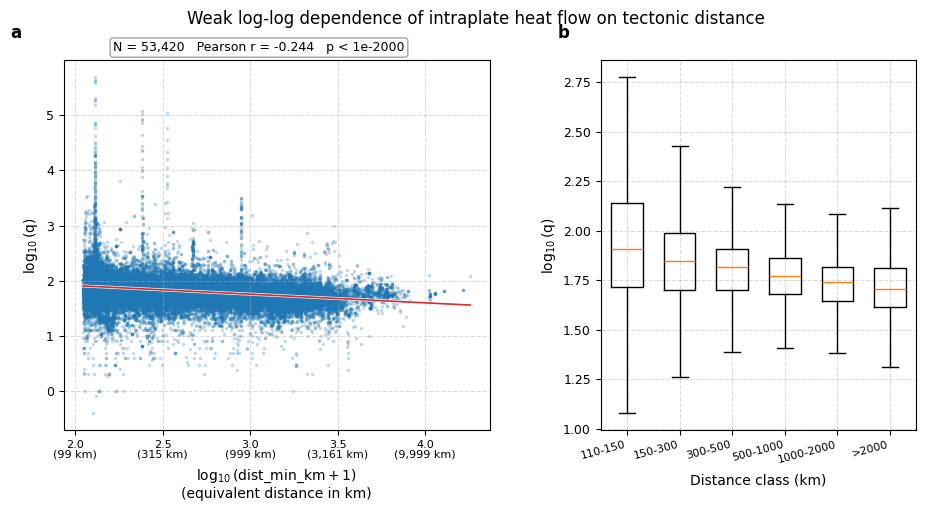

In [27]:
# ==============================================================
# Snippet 27 - heat flow vs distance
# ==============================================================
# Purpose:
#   Build a SINGLE, publication-ready 2-panel figure:
#     (A) Scatter: log10(q) vs log10(dist_min_km + 1) for ALL intraplate points
#     (B) Boxplots: log10(q) by distance classes
#
# Outputs:
#   publicaveis/pipeline_kmeans/figures_main/
#     - fig3_heatflow_vs_distance_panel.png
#     - fig3_heatflow_vs_distance_panel.pdf
#   publicaveis/pipeline_kmeans/correlations_heatflow_vs_distance_intraplate_protocol.csv
#
# Editorial role:
#   DECISION
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# -------------------------------
# Paths / constants
# -------------------------------
BASE = Path("publicaveis/pipeline_kmeans")
FIG_DIR = BASE / "figures_main"
PLOT_DIR = BASE / "plots"

FIG_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG_MAIN = FIG_DIR / "fig3_heatflow_vs_distance_panel.png"
OUT_PDF_MAIN = FIG_DIR / "fig3_heatflow_vs_distance_panel.pdf"
OUT_PNG_PLOT = PLOT_DIR / "fig3_heatflow_vs_distance_panel.png"
OUT_PDF_PLOT = PLOT_DIR / "fig3_heatflow_vs_distance_panel.pdf"

DIST_COL = "dist_min_km"
LOG10_P_FLOOR = -2000  # floor for extremely tiny p-values

# -------------------------------
# Global plotting style
# -------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "mathtext.default": "regular",
})

# -------------------------------
# Input selection (robust)
# -------------------------------
if "df_k_canon" in globals():
    df0 = df_k_canon.copy()
    SOURCE = "df_k_canon"
elif "gdf_all" in globals():
    df0 = gdf_all.copy()
    SOURCE = "gdf_all"
elif "gdf_out" in globals():
    df0 = gdf_out.copy()
    SOURCE = "gdf_out (fallback)"
else:
    raise AssertionError("No suitable input found. Expected one of: df_k_canon, gdf_all, gdf_out.")

# -------------------------------
# Data prep
# -------------------------------
df = df0.copy()
df["q"] = pd.to_numeric(df.get("q"), errors="coerce")
df[DIST_COL] = pd.to_numeric(df.get(DIST_COL), errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", DIST_COL])

# Intraplate cutoff
if "require_param" in globals():
    CUT_KM = float(require_param("DIST_CUTOFF_KM"))
else:
    CUT_KM = 110.0

df = df[(df["q"] > 0) & (df[DIST_COL] >= CUT_KM)].copy()

# Log variables (protocol space)
df["log_q"] = np.log10(df["q"].clip(lower=1e-6))
df["log_dist"] = np.log10(df[DIST_COL] + 1.0)

mask_log = df["log_dist"].notna() & df["log_q"].notna()

N = int(mask_log.sum())
print(f"[INFO] Figure 3 input: {SOURCE} | intraplate N = {N:,} (cutoff = {CUT_KM:.0f} km)")

# -------------------------------
# Pearson r with p computed in log-space (anti-underflow)
# -------------------------------
def pearson_logp(x, y, log10_floor=LOG10_P_FLOOR):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    n = int(x.size)

    if n < 3:
        return np.nan, np.nan, "NA", n

    r = float(np.corrcoef(x, y)[0, 1])
    r = float(np.clip(r, -1.0, 1.0))

    denom = 1.0 - r * r
    if denom <= 0:
        log10_p = float(log10_floor)
    else:
        t = abs(r) * np.sqrt((n - 2) / denom)
        try:
            log_p = stats.t.logsf(t, df=n - 2) + np.log(2.0)
            log10_p = float(log_p / np.log(10.0))
        except Exception:
            log10_p = -np.inf

        if (not np.isfinite(log10_p)) or (log10_p < log10_floor):
            log10_p = float(log10_floor)

    p_str = f"< 1e{int(np.floor(log10_p))}"
    return r, log10_p, p_str, n

r_log, log10_p_log, p_str_log, n_log = pearson_logp(
    df.loc[mask_log, "log_dist"],
    df.loc[mask_log, "log_q"],
)

# -------------------------------
# Save correlation CSV (protocol)
# -------------------------------
out_csv = BASE / "correlations_heatflow_vs_distance_intraplate_protocol.csv"
pd.DataFrame({
    "Correlation Type": ["Log-Log (protocol)"],
    "x": ["log10(dist_min_km+1)"],
    "y": ["log10(q)"],
    "r": [r_log],
    "p_value_str": [p_str_log],
    "log10_p": [log10_p_log],
    "n": [n_log],
    "cutoff_km": [CUT_KM],
    "source": [SOURCE],
}).to_csv(out_csv, index=False)
print(f"[saved] {out_csv}")

# -------------------------------
# Distance bins for boxplots
# -------------------------------
bins = [CUT_KM, 150, 300, 500, 1000, 2000, np.inf]
labels = [
    f"{int(CUT_KM)}-150",
    "150-300",
    "300-500",
    "500-1000",
    "1000-2000",
    ">2000",
]
df["dist_bin_km"] = pd.cut(df[DIST_COL], bins=bins, labels=labels, include_lowest=True)

box_data = []
for lab in labels:
    s = df.loc[(df["dist_bin_km"] == lab) & np.isfinite(df["log_q"]), "log_q"].dropna()
    box_data.append(s.values if len(s) else [np.nan])

# -------------------------------
# Linear trend in log-log space
# -------------------------------
x_fit = df.loc[mask_log, "log_dist"].to_numpy()
y_fit = df.loc[mask_log, "log_q"].to_numpy()

slope, intercept = np.polyfit(x_fit, y_fit, 1)
x_line = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 300)
y_line = intercept + slope * x_line

# -------------------------------
# PANEL FIGURE (A + B)
# -------------------------------
fig = plt.figure(figsize=(11.0, 4.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.30)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])

# ---- (A) Scatter ----
axA.scatter(
    df.loc[mask_log, "log_dist"],
    df.loc[mask_log, "log_q"],
    s=6,
    alpha=0.28,
    linewidths=0,
    rasterized=True,
)

# Regression line with thinner styling
axA.plot(
    x_line,
    y_line,
    color="white",
    linewidth=2.2,
    alpha=0.95,
    zorder=4,
)
axA.plot(
    x_line,
    y_line,
    color="#d62728",
    linewidth=1.2,
    alpha=0.98,
    zorder=5,
)

axA.set_ylabel(r"$\log_{10}(q)$")
axA.set_xlabel(
    r"$\log_{10}(dist\_min\_km + 1)$"
    "\n"
    r"(equivalent distance in km)",
    labelpad=6,
)

axA.grid(True, ls="--", alpha=0.45)

# Controlled x-ticks (stable labeling)
xticks = np.array([2.0, 2.5, 3.0, 3.5, 4.0])
xmin, xmax = np.nanmin(df.loc[mask_log, "log_dist"]), np.nanmax(df.loc[mask_log, "log_dist"])
xticks = xticks[(xticks >= np.floor(xmin * 2) / 2) & (xticks <= np.ceil(xmax * 2) / 2)]
axA.set_xticks(xticks)

def _fmt_logdist(x):
    km = int(round(10**x - 1))
    return f"{x:.1f}\n({km:,} km)"

axA.set_xticklabels([_fmt_logdist(x) for x in xticks], linespacing=0.95)

# Panel label
axA.text(
    -0.10, 1.05, "a",
    transform=axA.transAxes,
    fontweight="bold",
    fontsize=12,
    va="bottom",
    ha="right",
    clip_on=False,
)

# ---- (B) Boxplots ----
axB.boxplot(
    box_data,
    labels=labels,
    showfliers=False,
    widths=0.6,
)

axB.set_xlabel("Distance class (km)", labelpad=6)
axB.set_ylabel(r"$\log_{10}(q)$")
axB.grid(True, ls="--", alpha=0.45)
axB.margins(x=0.02)

for tick in axB.get_xticklabels():
    tick.set_rotation(15)
    tick.set_ha("right")

axB.text(
    -0.10, 1.05, "b",
    transform=axB.transAxes,
    fontweight="bold",
    fontsize=12,
    va="bottom",
    ha="right",
    clip_on=False,
)

fig.suptitle("Weak log-log dependence of intraplate heat flow on tectonic distance", y=0.985)

stats_text = f"N = {n_log:,}   Pearson r = {r_log:.3f}   p {p_str_log}"
fig.text(
    0.17, 0.92,
    stats_text,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="#999999",
        alpha=0.90,
    ),
)

fig.tight_layout(rect=[0, 0, 1, 0.90])

# -------------------------------
# Save
# -------------------------------
fig.savefig(OUT_PNG_MAIN, dpi=600, bbox_inches="tight")
fig.savefig(OUT_PDF_MAIN, bbox_inches="tight")
print(f"[saved] {OUT_PNG_MAIN}")
print(f"[saved] {OUT_PDF_MAIN}")

fig.savefig(OUT_PNG_PLOT, dpi=600, bbox_inches="tight")
fig.savefig(OUT_PDF_PLOT, bbox_inches="tight")
print(f"[saved] {OUT_PNG_PLOT}")
print(f"[saved] {OUT_PDF_PLOT}")

plt.show()
plt.close(fig)

# Snippet 28 — GEM–PB sets map

[INFO] Counts — GEM-only=273 | PB-only=2,475 | BOTH=1,963


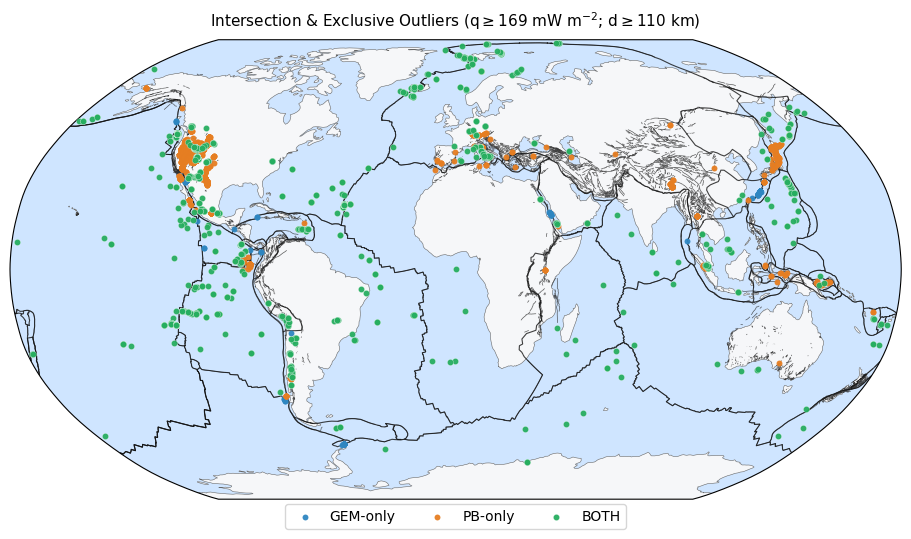

[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\map_outliers_gem_pb_sets.png
[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\outliers_gem_only.csv
[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\outliers_pb_only.csv
[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\outliers_both.csv


In [28]:
# ==============================================================
# Snippet 28 — GEM–PB sets map (ROUTED) [FIXED]
#
# Purpose:
#   Render the intersection and exclusive sets of protocol outliers relative to
#   GEM and PB2002 fault representations in a single global map, and persist the
#   corresponding membership tables.
#
# Inputs:
#   - gdf_out : GeoDataFrame/DataFrame with columns:
#       q, lon, lat, dist_gem_km, dist_pb_km
#   - GEM_SHP : path to GEM faults (readable by geopandas)
#   - PB2002_SHP : path to PB2002 plate boundaries/faults (readable by geopandas)
#   - Protocol params (optional): Q_THR_RELEV, DIST_CUTOFF_KM via require_param/PARAMS
#   - resolve_out_path(filename, family=...) from Snippet 2
#
# Outputs (routed via Snippet 2):
#   - OUT_PLOTS_DIR/map_outliers_gem_pb_sets.png                (family="plots")
#   - OUT_ANALYSIS_DIR/outliers_gem_only.csv                    (family="analysis")
#   - OUT_ANALYSIS_DIR/outliers_pb_only.csv                     (family="analysis")
#   - OUT_ANALYSIS_DIR/outliers_both.csv                        (family="analysis")
#
# Editorial role:
#   METHOD
#   Main set-comparison map + membership tables used in manuscript.
# ==============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------------
# Safe param getter
# -------------------------------
def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# --- Preconditions ---
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_out" in globals(), "gdf_out not found. Run outlier protocol first."
assert "GEM_SHP" in globals(), "GEM_SHP not defined."
assert "PB2002_SHP" in globals(), "PB2002_SHP not defined."

THRESH_Q = _get_param("Q_THR_RELEV", 169.0)
CUT_KM   = _get_param("DIST_CUTOFF_KM", 110.0)

# -------------------------------
# ROUTING (FIX)
# Snippet 2 does NOT define family="fig_main".
# Use family="plots" for main figures; fallback to "diag_maps" if desired.
# -------------------------------
try:
    OUT_PNG = resolve_out_path("map_outliers_gem_pb_sets.png", family="plots")
except KeyError:
    OUT_PNG = resolve_out_path("map_outliers_gem_pb_sets.png", family="diag_maps")

CSV_A = resolve_out_path("outliers_gem_only.csv", family="analysis")
CSV_B = resolve_out_path("outliers_pb_only.csv",  family="analysis")
CSV_C = resolve_out_path("outliers_both.csv",     family="analysis")

def ensure_wgs84(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    return gdf.set_crs(4326, allow_override=True) if gdf.crs is None else gdf.to_crs(4326)

# -------------------------------
# Data preparation
# -------------------------------
df = gdf_out.copy()

need_cols = ["q", "dist_gem_km", "dist_pb_km", "lon", "lat"]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"[S-SETS] Missing required columns in gdf_out: {missing}")

for c in need_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=need_cols)

is_hi_q = df["q"] >= THRESH_Q
far_gem = df["dist_gem_km"] >= CUT_KM
far_pb  = df["dist_pb_km"]  >= CUT_KM

A = df.loc[is_hi_q &  far_gem & ~far_pb, ["lon", "lat", "q"]].copy()  # GEM-only
B = df.loc[is_hi_q &  far_pb  & ~far_gem, ["lon", "lat", "q"]].copy()  # PB-only
C = df.loc[is_hi_q &  far_gem &  far_pb , ["lon", "lat", "q"]].copy()  # BOTH

print(f"[INFO] Counts — GEM-only={len(A):,} | PB-only={len(B):,} | BOTH={len(C):,}")

A.to_csv(CSV_A, index=False)
B.to_csv(CSV_B, index=False)
C.to_csv(CSV_C, index=False)

# -------------------------------
# Faults
# -------------------------------
gem = ensure_wgs84(gpd.read_file(GEM_SHP))[["geometry"]]
pb  = ensure_wgs84(gpd.read_file(PB2002_SHP))[["geometry"]]

# -------------------------------
# Plot (Cartopy-safe)
# -------------------------------
fig = plt.figure(figsize=(11.5, 6.2))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()

ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="#f6f7f9", edgecolor="none", zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#cfe5ff", edgecolor="none", zorder=0)
ax.coastlines(lw=0.4, color="#666", zorder=1)

gpd.GeoSeries(gem.geometry).plot(
    ax=ax, transform=ccrs.PlateCarree(), lw=0.5, color="#333", alpha=0.8, zorder=2
)
gpd.GeoSeries(pb.geometry).plot(
    ax=ax, transform=ccrs.PlateCarree(), lw=0.8, color="#111", alpha=0.8, zorder=2
)

if not A.empty:
    ax.scatter(A["lon"], A["lat"], transform=ccrs.PlateCarree(),
               s=18, c="#2E86C1", alpha=0.95, lw=0, label="GEM-only", zorder=3)

if not B.empty:
    ax.scatter(B["lon"], B["lat"], transform=ccrs.PlateCarree(),
               s=18, c="#E67E22", alpha=0.95, lw=0, label="PB-only", zorder=3)

if not C.empty:
    ax.scatter(C["lon"], C["lat"], transform=ccrs.PlateCarree(),
               s=20, c="#27AE60", alpha=0.95, lw=0.2, edgecolors="white",
               label="BOTH", zorder=4)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=True)

ax.set_title(
    rf"Intersection & Exclusive Outliers "
    rf"($q \geq {THRESH_Q:.0f}\ \mathrm{{mW\ m^{{-2}}}}$; "
    rf"$d \geq {CUT_KM:.0f}\ \mathrm{{km}}$)",
    pad=10
)

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("[saved]", OUT_PNG)
print("[saved]", CSV_A)
print("[saved]", CSV_B)
print("[saved]", CSV_C)
# =====================================================================

# Snippet 29 — Profile by log-distance

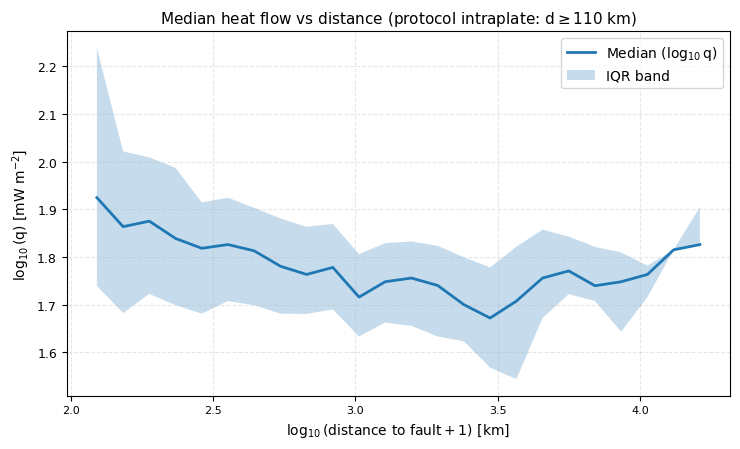

[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\profile_q_vs_logdist_main.csv
[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\profile_logq_vs_logdist_main.png


In [29]:
# ==============================================================
# Snippet 29 — Profile of heat flow vs log-distance to faults (ROUTED) [FIXED]
#
# Purpose:
#   Construct the main binned profile of surface heat flow (q) as a function of
#   log10(distance to nearest fault + 1), strictly under the intraplate protocol:
#     - distance metric: dist_min_km (protocol distance)
#     - physical cutoff: dist_min_km ≥ DIST_CUTOFF_KM
#   Robust per-bin summary: median + IQR.
#
# Inputs:
#   - gdf_out : DataFrame/GeoDataFrame with columns {q, dist_min_km}
#   - resolve_out_path(filename, family=...) from Snippet 2
#   - Optional params via require_param/PARAMS: DIST_CUTOFF_KM
#
# Outputs (routed via Snippet 2):
#   - OUT_ANALYSIS_DIR/profile_q_vs_logdist_main.csv     (family="analysis")
#   - OUT_PLOTS_DIR/profile_logq_vs_logdist_main.png     (family="plots")
#
# Editorial role:
#   RESULT
#   Core descriptive profile used in the manuscript.
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# --- Preconditions ---
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_out" in globals(), "gdf_out not found. Run outlier pipeline first."

CUT_KM = _get_param("DIST_CUTOFF_KM", 110.0)

# --- ROUTING FIX: fig_main does not exist in Snippet 2 ---
CSV_OUT = resolve_out_path("profile_q_vs_logdist_main.csv", family="analysis")
try:
    PNG_OUT = resolve_out_path("profile_logq_vs_logdist_main.png", family="plots")
except KeyError:
    PNG_OUT = resolve_out_path("profile_logq_vs_logdist_main.png", family="diag_maps")

df = gdf_out.copy()

for c in ["q", "dist_min_km"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", "dist_min_km"])
df = df[(df["q"] > 0) & (df["dist_min_km"] >= CUT_KM)].copy()

if df.empty:
    raise ValueError("[S-PROFILE] No rows after protocol filtering (q>0 and dist≥CUT_KM).")

df["log_dist"] = np.log10(df["dist_min_km"].to_numpy(dtype=float) + 1.0)

N_BINS = 24
edges = np.linspace(float(df["log_dist"].min()), float(df["log_dist"].max()), N_BINS + 1)
df["logdist_bin"] = pd.cut(df["log_dist"], bins=edges, include_lowest=True)

mids = 0.5 * (edges[:-1] + edges[1:])
bin_to_mid = {cat: float(mids[i]) for i, cat in enumerate(df["logdist_bin"].cat.categories)}

g = (
    df.groupby("logdist_bin", observed=True)["q"]
      .agg(
          N="size",
          median="median",
          q1=lambda s: s.quantile(0.25),
          q3=lambda s: s.quantile(0.75),
      )
      .reset_index()
)

g["logdist_mid"] = g["logdist_bin"].map(bin_to_mid)

prof = (
    g.dropna(subset=["median", "q1", "q3", "logdist_mid"])
     .sort_values("logdist_mid")
     .reset_index(drop=True)
)

prof[["logdist_mid", "N", "median", "q1", "q3"]].to_csv(CSV_OUT, index=False)

fig = plt.figure(figsize=(7.5, 4.6))
ax = plt.gca()

ax.plot(
    prof["logdist_mid"],
    np.log10(np.clip(prof["median"].to_numpy(float), 1e-12, None)),
    lw=2,
    label=r"Median ($\log_{10} q$)",
)

ax.fill_between(
    prof["logdist_mid"].to_numpy(float),
    np.log10(np.clip(prof["q1"].to_numpy(float), 1e-12, None)),
    np.log10(np.clip(prof["q3"].to_numpy(float), 1e-12, None)),
    alpha=0.25,
    label="IQR band",
)

ax.set_xlabel(r"$\log_{10}(\mathrm{distance\ to\ fault}+1)\ \mathrm{[km]}$")
ax.set_ylabel(r"$\log_{10}(q)\ \mathrm{[mW\ m^{-2}]}$")
ax.set_title(rf"Median heat flow vs distance (protocol intraplate: $d \geq {CUT_KM:.0f}$ km)")
ax.grid(alpha=0.3, ls="--")
ax.legend()

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("[saved]", CSV_OUT)
print("[saved]", PNG_OUT)
# =====================================================================

# Snippet 30 — Statistical & physical synthesis

In [30]:
# ==============================================================
# Snippet 30 — Statistical & physical synthesis (ROUTED) [FIXED]
#
# Purpose:
#   Assemble a compact statistical synthesis for the main text (Step 18),
#   comparing protocol intraplate "relevant outliers" vs "normals":
#     - Domain: dist_min_km ≥ DIST_CUTOFF_KM
#     - Outlier definition: outlier_relevant_lin (q ≥ Q_THR_RELEV)
#   Produces a single-row CSV with core medians, nonparametric test p-values
#   (reported in log10-space to avoid underflow), and effect size in log10(q).
#
# Inputs (required):
#   - gdf_out: DataFrame/GeoDataFrame with columns:
#       {q, dist_min_km, outlier_relevant_lin}
#   - resolve_out_path(filename, family=...) from Snippet 2
#
# Inputs (optional):
#   - require_param / PARAMS for:
#       * DIST_CUTOFF_KM
#       * Q_THR_RELEV
#
# Outputs (routed via Snippet 2):
#   - OUT_ANALYSIS_DIR/synthesis_stats_main.csv
#
# Editorial role:
#   DECISION
#   Main-text synthesis scaffold (numbers for the narrative).
# ==============================================================

import numpy as np
import pandas as pd
from scipy import stats

# -------------------------------
# Safe param getter (NG-clean)
# -------------------------------
def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# -------------------------------
# Preconditions
# -------------------------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_out" in globals(), "gdf_out not found. Run outlier pipeline first."

need_cols = {"q", "dist_min_km", "outlier_relevant_lin"}
miss = need_cols - set(getattr(gdf_out, "columns", []))
if miss:
    raise KeyError(f"[S-SYNTHESIS] Missing columns in gdf_out: {sorted(miss)}")

CUT_KM   = _get_param("DIST_CUTOFF_KM", 110.0)
Q_THR    = _get_param("Q_THR_RELEV", 169.0)

CSV_OUT = resolve_out_path("synthesis_stats_main.csv", family="analysis")

# -------------------------------
# Helpers
# -------------------------------
def _to_clean_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)

def _as_clean_pos(x) -> np.ndarray:
    s = _to_clean_numeric(pd.Series(x)).dropna()
    s = s[s > 0]
    return s.to_numpy(dtype=float)

def _as_clean_nonneg(x) -> np.ndarray:
    s = _to_clean_numeric(pd.Series(x)).dropna()
    s = s[s >= 0]
    return s.to_numpy(dtype=float)

def log10_p_from_z(z: float) -> float:
    # two-sided normal tail in log-space (stable)
    log_p = stats.norm.logsf(abs(float(z))) + np.log(2.0)
    return float(log_p / np.log(10.0))

def p_str_from_log10(log10_p: float) -> str:
    if not np.isfinite(log10_p):
        return "NA"
    return f"< 1e{int(np.floor(log10_p))}"

def mwu_log10p(a, b) -> tuple[float, float, str, str]:
    xa = _to_clean_numeric(pd.Series(a)).dropna().to_numpy(dtype=float)
    xb = _to_clean_numeric(pd.Series(b)).dropna().to_numpy(dtype=float)
    if len(xa) < 2 or len(xb) < 2:
        return (np.nan, np.nan, "NA", "insufficient data")

    # MWU z-approx (no tie correction, consistent with your Snippet 39 notes)
    stat, _p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
    n1, n2 = len(xa), len(xb)
    mu = n1 * n2 / 2.0
    sigma = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
    z = (stat - mu) / sigma
    log10_p = log10_p_from_z(z)
    return (float(stat), float(log10_p), p_str_from_log10(log10_p), "normal approx (no tie correction)")

def ks_log10p(a, b) -> tuple[float, float, str, str]:
    xa = _to_clean_numeric(pd.Series(a)).dropna().to_numpy(dtype=float)
    xb = _to_clean_numeric(pd.Series(b)).dropna().to_numpy(dtype=float)
    if len(xa) < 2 or len(xb) < 2:
        return (np.nan, np.nan, "NA", "insufficient data")

    d, _p = stats.ks_2samp(xa, xb, alternative="two-sided", mode="asymp")
    n1, n2 = len(xa), len(xb)
    n_eff = n1 * n2 / (n1 + n2)
    z = float(d) * np.sqrt(n_eff)
    log10_p = log10_p_from_z(z)
    return (float(d), float(log10_p), p_str_from_log10(log10_p), "asymptotic mapping")

def cohens_d_logq(a, b) -> float:
    xa = np.log10(_as_clean_pos(a))
    xb = np.log10(_as_clean_pos(b))
    if len(xa) < 2 or len(xb) < 2:
        return np.nan
    sd = np.sqrt((xa.var(ddof=1) + xb.var(ddof=1)) / 2.0)
    return float(abs(xa.mean() - xb.mean()) / sd) if np.isfinite(sd) and sd > 0 else np.nan

# -------------------------------
# Clean & protocol intraplate subset
# -------------------------------
df = gdf_out.copy()
df["q"] = _to_clean_numeric(df["q"])
df["dist_min_km"] = _to_clean_numeric(df["dist_min_km"])

df = df.dropna(subset=["q", "dist_min_km"])
df = df[(df["q"] > 0) & (df["dist_min_km"] >= CUT_KM)].copy()

# robust boolean conversion for outlier flag
flag = df["outlier_relevant_lin"]
if flag.dtype != bool:
    flag = pd.to_numeric(flag, errors="coerce").fillna(0).astype(int).astype(bool)
df["outlier_relevant_lin"] = flag

normals  = df.loc[~df["outlier_relevant_lin"], ["q", "dist_min_km"]].copy()
outliers = df.loc[ df["outlier_relevant_lin"], ["q", "dist_min_km"]].copy()

# -------------------------------
# Stats
# -------------------------------
mwu_q_stat,   mwu_q_log10p,   mwu_q_pstr,   mwu_q_note   = mwu_log10p(normals["q"], outliers["q"])
mwu_d_stat,   mwu_d_log10p,   mwu_d_pstr,   mwu_d_note   = mwu_log10p(normals["dist_min_km"], outliers["dist_min_km"])
ks_q_stat,    ks_q_log10p,    ks_q_pstr,    ks_q_note    = ks_log10p(normals["q"], outliers["q"])
ks_d_stat,    ks_d_log10p,    ks_d_pstr,    ks_d_note    = ks_log10p(normals["dist_min_km"], outliers["dist_min_km"])
d_eff = cohens_d_logq(normals["q"], outliers["q"])

row = {
    "DIST_CUTOFF_KM": float(CUT_KM),
    "Q_THR_RELEV": float(Q_THR),
    "N_total": int(len(df)),
    "N_normals": int(len(normals)),
    "N_outliers": int(len(outliers)),
    "q_median_norm": float(np.nanmedian(normals["q"])) if len(normals) else np.nan,
    "q_median_out":  float(np.nanmedian(outliers["q"])) if len(outliers) else np.nan,
    "dist_median_norm": float(np.nanmedian(normals["dist_min_km"])) if len(normals) else np.nan,
    "dist_median_out":  float(np.nanmedian(outliers["dist_min_km"])) if len(outliers) else np.nan,

    "MWU_q_stat": mwu_q_stat, "MWU_q_log10_p": mwu_q_log10p, "MWU_q_p_str": mwu_q_pstr, "MWU_q_note": mwu_q_note,
    "MWU_dist_stat": mwu_d_stat, "MWU_dist_log10_p": mwu_d_log10p, "MWU_dist_p_str": mwu_d_pstr, "MWU_dist_note": mwu_d_note,

    "KS_q_stat": ks_q_stat, "KS_q_log10_p": ks_q_log10p, "KS_q_p_str": ks_q_pstr, "KS_q_note": ks_q_note,
    "KS_dist_stat": ks_d_stat, "KS_dist_log10_p": ks_d_log10p, "KS_dist_p_str": ks_d_pstr, "KS_dist_note": ks_d_note,

    "Cohen_d_log10q": float(d_eff),
}

syn = pd.DataFrame([row])
syn.to_csv(CSV_OUT, index=False)

print(syn.round(6))
print("[saved]", CSV_OUT)
# =========================================================================== 

   DIST_CUTOFF_KM  Q_THR_RELEV  N_total  N_normals  N_outliers  q_median_norm  \
0           110.0        169.0    53420      51457        1963           59.5   

   q_median_out  dist_median_norm  dist_median_out  MWU_q_stat  ...  \
0         252.0        613.079164       135.593722         0.0  ...   

                       MWU_dist_note KS_q_stat KS_q_log10_p  KS_q_p_str  \
0  normal approx (no tie correction)       1.0  -412.333074    < 1e-413   

            KS_q_note KS_dist_stat KS_dist_log10_p  KS_dist_p_str  \
0  asymptotic mapping     0.499847     -104.022603       < 1e-105   

         KS_dist_note Cohen_d_log10q  
0  asymptotic mapping       2.224556  

[1 rows x 26 columns]
[saved] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\synthesis_stats_main.csv


# Snippet 31 - K=4 clusters + per-cluster regressions + bar(|r|)

[S31] Intraplate points used for clustering (finite log_q/log_dist): N=53,420
[S31] Cluster sizes:
 - Cluster 0: n=9,341
 - Cluster 1: n=16,925
 - Cluster 2: n=1,484
 - Cluster 3: n=25,670


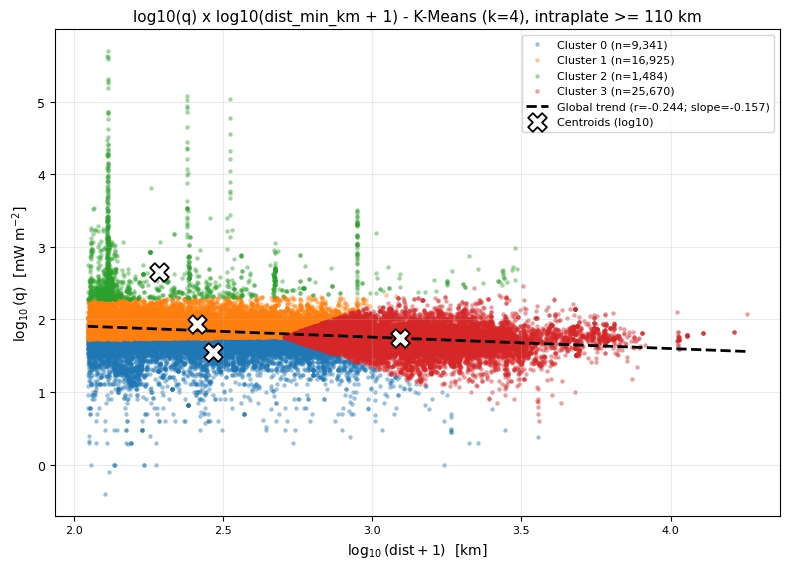

[S31] Scatter saved: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\scatter_clusters_k4_loglog.png
[S31] Summary saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\summary_loglog_by_cluster_k4.csv
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\summary_loglog_by_cluster_k4.md
[S31] Clusters exported: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\clusters_k4_intraplate.csv


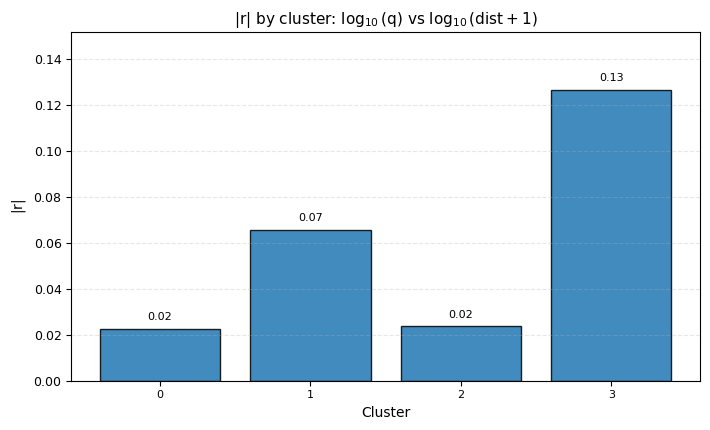

[S31] Barplots saved:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\corr_strength_by_cluster_k4.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\corr_strength_by_cluster_k4.pdf
[S31] df_used: (53420, 94) | df_Xz: (53420, 94) | Xz: (53420, 2)
[S31] Globals set: df_used, df_Xz, Xz, scaler, labels, FINAL_K, RANDOM_STATE, N_INIT


,Cluster,N,slope,intercept,r,p
0,0,9341,0.019651,1.510021,0.022455,2.998645e-02
1,1,16925,-0.037489,2.025540,-0.065845,9.922445e-18
2,2,1484,0.040421,2.562996,0.023619,3.632215e-01
3,3,25670,-0.083987,2.000331,-0.126437,5.892957e-92
4,Global,53420,-0.156844,2.226326,-0.244006,0.000000e+00


In [31]:
# ==============================================================
# Snippet 31 - K=4 clusters + per-cluster regressions + bar(|r|) (ROUTED) [FULL + FIXED]
#
# Purpose:
#   Apply K-Means (k=4) to the protocol intraplate subset (dist_min_km >= DIST_CUTOFF_KM)
#   in log10(q) x log10(dist_min_km + 1) space (standardized), then:
#     - scatter (colored by cluster) + global trend + centroids
#     - per-cluster log-log regressions (+ global)
#     - barplot of |r| by cluster
#
# Audit-proof FIX (downstream clustering diagnostics):
#   - df_used and Xz ALWAYS aligned
#   - expose df_Xz (exact rows used for Xz), Xz, scaler, labels
#
# Inputs (required):
#   - gdf_out with columns: q, dist_min_km, lon, lat
#   - resolve_out_path() from Snippet 2
#
# Inputs (optional params via require_param/PARAMS):
#   - DIST_CUTOFF_KM (default 110)
#   - K_FINAL        (default 4)
#   - RANDOM_STATE   (default 42)
#   - N_INIT         (default 50)
#   - W_DIST         (default 1.0)
#   - W_Q            (default 1.0)
#   - SHOW_PLOTS     (0/1; default 0)
#
# Outputs (routed via Snippet 2):
#   family="analysis":
#     clusters_k4_intraplate.csv
#     summary_loglog_by_cluster_k4.csv
#     summary_loglog_by_cluster_k4.md
#   family="plots":
#     scatter_clusters_k4_loglog.png
#     corr_strength_by_cluster_k4.png
#     corr_strength_by_cluster_k4.pdf
#
# Globals (downstream):
#   df_used, df_Xz, Xz, scaler, labels, FINAL_K, RANDOM_STATE, N_INIT
# ==============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import linregress

# -------------------------------
# Safe param getter (pipeline-style)
# -------------------------------
def _get_param(name: str, default: float) -> float:
    if "require_param" in globals():
        try:
            return float(require_param(name))
        except Exception:
            pass
    if "PARAMS" in globals() and isinstance(PARAMS, dict) and name in PARAMS:
        try:
            return float(PARAMS[name])
        except Exception:
            pass
    return float(default)

# -------------------------------
# Preconditions
# -------------------------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."
assert "gdf_out" in globals(), "gdf_out not found. Run upstream snippets first."

# -------------------------------
# Matplotlib typography (reduce glyph warnings)
# -------------------------------
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.unicode_minus"] = False

# -------------------------------
# Params
# -------------------------------
CUT_KM  = _get_param("DIST_CUTOFF_KM", 110.0)
K       = int(_get_param("K_FINAL", 4))
RSEED   = int(_get_param("RANDOM_STATE", 42))
N_INIT  = int(_get_param("N_INIT", 50))
W_DIST  = float(_get_param("W_DIST", 1.0))
W_Q     = float(_get_param("W_Q", 1.0))
SHOW    = bool(int(_get_param("SHOW_PLOTS", 0)))

# Expose canonical clustering params for downstream snippets
FINAL_K = int(K)
RANDOM_STATE = int(RSEED)

# -------------------------------
# Routed outputs
# -------------------------------
CSV_CLUSTERS = resolve_out_path("clusters_k4_intraplate.csv", family="analysis")
CSV_SUMMARY  = resolve_out_path("summary_loglog_by_cluster_k4.csv", family="analysis")
MD_SUMMARY   = resolve_out_path("summary_loglog_by_cluster_k4.md",  family="analysis")
PNG_SCATTER  = resolve_out_path("scatter_clusters_k4_loglog.png",   family="plots")
PNG_BARCHART = resolve_out_path("corr_strength_by_cluster_k4.png",  family="plots")
PDF_BARCHART = resolve_out_path("corr_strength_by_cluster_k4.pdf",  family="plots")

# -------------------------------
# Helpers: dedupe columns early
# -------------------------------
def _drop_late_duplicates(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.columns = [str(c).strip() for c in frame.columns]
    if frame.columns.duplicated().any():
        dup = frame.columns[frame.columns.duplicated()].tolist()
        print(f"[WARN] Duplicate columns detected (dropping later duplicates): {sorted(set(dup))}")
        frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    return frame

# -------------------------------
# 1) Build protocol intraplate df0
# -------------------------------
df0 = _drop_late_duplicates(gdf_out.copy())

req_cols = ["q", "dist_min_km", "lon", "lat"]
missing = [c for c in req_cols if c not in df0.columns]
if missing:
    raise KeyError(f"[S31] Missing required columns in gdf_out: {missing}")

for c in req_cols:
    df0[c] = pd.to_numeric(df0[c], errors="coerce")

df0 = df0.replace([np.inf, -np.inf], np.nan)
df0 = df0[(df0["dist_min_km"] >= CUT_KM) & (df0["q"] > 0)].copy()

if len(df0) < 100:
    raise ValueError(f"[S31] Too few intraplate points after filtering: N={len(df0)}. Check the data.")

# Physical logs
df0["log_q"]    = np.log10(df0["q"].clip(lower=1e-12))
df0["log_dist"] = np.log10(df0["dist_min_km"] + 1.0)

# CRITICAL: single mask for X/Xz and df_used
mask = np.isfinite(df0["log_q"].to_numpy()) & np.isfinite(df0["log_dist"].to_numpy())
df = df0.loc[mask].copy().reset_index(drop=True)

print(f"[S31] Intraplate points used for clustering (finite log_q/log_dist): N={len(df):,}")

# -------------------------------
# 2) Feature space + KMeans
# -------------------------------
X = np.column_stack([
    W_DIST * df["log_dist"].to_numpy(float),
    W_Q    * df["log_q"].to_numpy(float),
])

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

km = KMeans(n_clusters=K, random_state=RSEED, n_init=N_INIT)
labels = km.fit_predict(Xz).astype(int)

df["cluster_k"] = labels

# FIX: df_Xz is EXACT table used to build X/Xz
df_Xz = df.copy().reset_index(drop=True)
assert len(df_Xz) == Xz.shape[0], (
    f"[S31] Xz misalignment: len(df_Xz)={len(df_Xz)} vs Xz.shape[0]={Xz.shape[0]}."
)

# Canonical downstream table
df_used = df_Xz.copy()

# Centroids in physical space (log10)
centers_unscaled = scaler.inverse_transform(km.cluster_centers_)
cent_log_dist = centers_unscaled[:, 0] / W_DIST
cent_log_q    = centers_unscaled[:, 1] / W_Q

cluster_sizes = df_used["cluster_k"].value_counts().sort_index()
print("[S31] Cluster sizes:")
for c, n in cluster_sizes.items():
    print(f" - Cluster {int(c)}: n={int(n):,}")

# -------------------------------
# 3) Scatter + global trend + centroids (Matplotlib only)
# -------------------------------
log_d = df_used["log_dist"].to_numpy(float)
log_q = df_used["log_q"].to_numpy(float)
clusters = df_used["cluster_k"].to_numpy(int)

ok = np.isfinite(log_d) & np.isfinite(log_q)
slope_g, intercept_g, r_g, p_g, se_g = linregress(log_d[ok], log_q[ok])

x_line = np.linspace(float(np.nanmin(log_d)), float(np.nanmax(log_d)), 200)
y_line = intercept_g + slope_g * x_line

fig = plt.figure(figsize=(8.0, 5.8))
ax = plt.gca()

# deterministic colors via tab10
cmap = plt.get_cmap("tab10")
for c in sorted(cluster_sizes.index):
    sel = (clusters == int(c))
    ax.scatter(
        log_d[sel], log_q[sel],
        s=10, alpha=0.45,
        color=cmap(int(c) % 10),
        label=f"Cluster {int(c)} (n={int(sel.sum()):,})",
        linewidths=0
    )

ax.plot(
    x_line, y_line,
    color="black", lw=2, ls="--",
    label=f"Global trend (r={r_g:.3f}; slope={slope_g:.3f})"
)

ax.scatter(
    cent_log_dist, cent_log_q,
    s=180, c="white", edgecolors="k",
    marker="X", linewidths=1.3, zorder=5,
    label="Centroids (log10)"
)

ax.set_xlabel(r"$\log_{10}(\mathrm{dist}+1)$  [km]")
ax.set_ylabel(r"$\log_{10}(q)$  [mW m$^{-2}$]")
ax.set_title(f"log10(q) x log10(dist_min_km + 1) - K-Means (k={K}), intraplate >= {int(CUT_KM)} km")
ax.legend(frameon=True, fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PNG_SCATTER, dpi=300, bbox_inches="tight")
if SHOW:
    plt.show()
plt.close(fig)
print(f"[S31] Scatter saved: {PNG_SCATTER}")

# -------------------------------
# 4) Regressions per cluster + global
# -------------------------------
rows = []
for c in sorted(cluster_sizes.index):
    c = int(c)
    sub = df_used[df_used["cluster_k"] == c]
    if len(sub) < 10:
        slope = intercept = r = p = np.nan
    else:
        xd = sub["log_dist"].to_numpy(float)
        yq = sub["log_q"].to_numpy(float)
        okc = np.isfinite(xd) & np.isfinite(yq)
        if okc.sum() < 3:
            slope = intercept = r = p = np.nan
        else:
            slope, intercept, r, p, _ = linregress(xd[okc], yq[okc])

    rows.append({
        "Cluster": c,
        "N": int(len(sub)),
        "slope": float(slope) if np.isfinite(slope) else np.nan,
        "intercept": float(intercept) if np.isfinite(intercept) else np.nan,
        "r": float(r) if np.isfinite(r) else np.nan,
        "p": float(p) if np.isfinite(p) else np.nan,
    })

rows.append({
    "Cluster": "Global",
    "N": int(len(df_used)),
    "slope": float(slope_g),
    "intercept": float(intercept_g),
    "r": float(r_g),
    "p": float(p_g),
})

summary_df = pd.DataFrame(rows)
summary_df.to_csv(CSV_SUMMARY, index=False)

with open(MD_SUMMARY, "w", encoding="utf-8") as f:
    f.write("# Regressions log10(q) x log10(dist_min_km + 1) by cluster (k=4)\n\n")
    f.write(f"- Intraplate subset: dist_min_km >= {CUT_KM:.0f} km, q > 0.\n")
    f.write(f"- Features: log10(q), log10(dist_min_km + 1), scaled (StandardScaler), weights W_DIST={W_DIST}, W_Q={W_Q}.\n")
    f.write(f"- K-Means: k={K}, random_state={RSEED}, n_init={N_INIT}.\n\n")
    try:
        f.write(summary_df.to_markdown(index=False, floatfmt=".4f"))
    except Exception:
        f.write(summary_df.to_string(index=False))
    f.write("\n")

print(f"[S31] Summary saved:\n - {CSV_SUMMARY}\n - {MD_SUMMARY}")

# -------------------------------
# 5) Export clusters table
# -------------------------------
out_cols = ["lon", "lat", "q", "dist_min_km", "log_q", "log_dist", "cluster_k"]
out_cols = [c for c in out_cols if c in df_used.columns]
df_used[out_cols].to_csv(CSV_CLUSTERS, index=False)
print(f"[S31] Clusters exported: {CSV_CLUSTERS}")

# -------------------------------
# 6) Barplot of |r| by cluster (Matplotlib only)
# -------------------------------
plot_df = summary_df[summary_df["Cluster"] != "Global"].copy()
plot_df = plot_df.dropna(subset=["r"])
plot_df["abs_r"] = plot_df["r"].abs()

# Ensure cluster order numeric
plot_df["Cluster"] = plot_df["Cluster"].astype(int)
plot_df = plot_df.sort_values("Cluster").reset_index(drop=True)

fig = plt.figure(figsize=(7.2, 4.4))
ax = plt.gca()

ax.bar(plot_df["Cluster"].astype(str), plot_df["abs_r"].to_numpy(float), alpha=0.85, edgecolor="black")
ax.set_title(r"$|r|$ by cluster: $\log_{10}(q)$ vs $\log_{10}(\mathrm{dist}+1)$")
ax.set_xlabel("Cluster")
ax.set_ylabel(r"$|r|$")
ax.grid(axis="y", alpha=0.3, ls="--")

ymax = float(np.nanmax(plot_df["abs_r"])) if len(plot_df) else 0.0
ymax = max(0.1, min(1.05, ymax * 1.20))
ax.set_ylim(0, ymax)

for i, v in enumerate(plot_df["abs_r"].to_numpy(float)):
    if np.isfinite(v):
        ax.text(i, v + ymax * 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig(PNG_BARCHART, dpi=300, bbox_inches="tight")
fig.savefig(PDF_BARCHART, bbox_inches="tight")
if SHOW:
    plt.show()
plt.close(fig)

print(f"[S31] Barplots saved:\n - {PNG_BARCHART}\n - {PDF_BARCHART}")

# -------------------------------
# 7) Globals for downstream audit-proof usage
# -------------------------------
globals()["df_used"] = df_used
globals()["df_Xz"]   = df_Xz
globals()["Xz"]      = Xz
globals()["scaler"]  = scaler
globals()["labels"]  = labels
globals()["N_INIT"]  = int(N_INIT)
globals()["FINAL_K"] = int(FINAL_K)
globals()["RANDOM_STATE"] = int(RANDOM_STATE)

print(f"[S31] df_used: {df_used.shape} | df_Xz: {df_Xz.shape} | Xz: {Xz.shape}")
print("[S31] Globals set: df_used, df_Xz, Xz, scaler, labels, FINAL_K, RANDOM_STATE, N_INIT")

try:
    from IPython.display import display
    display(summary_df)
except Exception:
    print(summary_df)
# ======================================================================


# Snippet 32 - Alternative clustering sanity checks (DBSCAN + Ward)

[S-ALT-CLUSTERING] Xz-space used: canonical: df_Xz + Xz (from Snippet 31 fix)
[S-ALT-CLUSTERING] N=53,420 | Xz_used=(53420, 2)

[S-ALT-CLUSTERING] DBSCAN sweep (top by silhouette_nonnoise, then n_clusters, then low noise):


,eps,min_samples,n_clusters,n_noise,n_nonnoise,noise_frac,silhouette_nonnoise
22,0.833333,10,2,19,53401,0.000356,0.859834
25,0.916667,10,2,18,53402,0.000337,0.859819
18,0.750000,5,2,11,53409,0.000206,0.766012
21,0.833333,5,2,6,53414,0.000112,0.765841
24,0.916667,5,2,6,53414,0.000112,0.765841
27,1.000000,5,2,6,53414,0.000112,0.765841
15,0.666667,5,3,13,53407,0.000243,0.763433
12,0.583333,5,4,19,53401,0.000356,0.763176
9,0.500000,5,4,36,53384,0.000674,0.755492
6,0.416667,5,3,56,53364,0.001048,0.705968


[S-ALT-CLUSTERING] Saved diagnostics CSV: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\dbscan_grid_diagnostics.csv


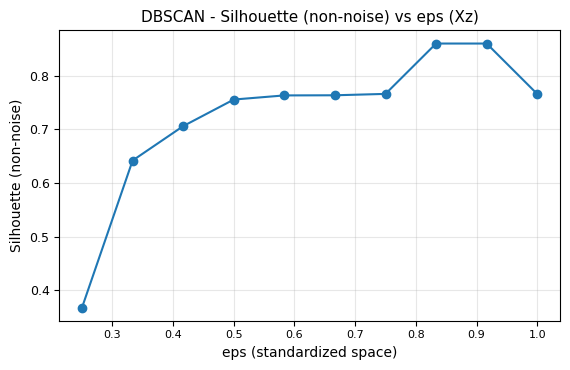

[S-ALT-CLUSTERING] Saved plot: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\clustering\dbscan_silhouette_vs_eps.png

[S-ALT-CLUSTERING] DBSCAN parameter selection:
  mode           : strict
  eps            : 0.833
  min_samples    : 10
  n_clusters     : 2
  noise_frac     : 0.000
  n_nonnoise     : 53401
  silhouette(nn) : 0.860

[S-ALT-CLUSTERING] Hierarchical (Ward) silhouettes:


,k,silhouette
0,2,0.344972
1,3,0.318838
2,4,0.325476
3,5,0.284717
4,6,0.309453


[S-ALT-CLUSTERING] Saved diagnostics CSV: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\ward_grid_diagnostics.csv


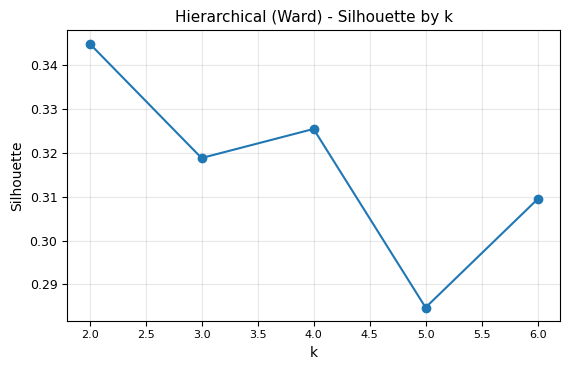

[S-ALT-CLUSTERING] Saved plot: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\clustering\ward_silhouette_vs_k.png

[S-ALT-CLUSTERING] Selected Ward k (best silhouette): K_HIER_BEST=2
[K-MEANS] metrics_df not available in this session (skip).


In [32]:
# ==============================================================
# Snippet 32 - Alternative clustering sanity checks (DBSCAN + Ward) [ROUTED, AUDIT-PROOF v3]
#
# Purpose:
#   Exploratory alternative clustering (DBSCAN and hierarchical Ward) as sanity checks.
#
#   CRITICAL FIX (post-S31 alignment bug):
#   - NEVER assume globals()["Xz"] matches df_used.
#   - Prefer df_Xz + Xz if present (single source of truth for Xz-space).
#   - Otherwise, rebuild a LOCAL Xz_alt from df_used (or gdf_out fallback) and keep it local.
#   - Export ONLY parameter choices for downstream (DBSCAN_EPS_BEST / DBSCAN_MIN_S_BEST / K_HIER_BEST),
#     plus a clear tag of which Xz-space was used (XZ_SPACE_TAG_32).
#
# --------------------------------------------------------------
# Inputs (preferred, exact alignment source of truth):
#   - df_Xz : exact rows used to build Xz (produced in Snippet 31)
#   - Xz    : standardized feature matrix aligned with df_Xz (produced in Snippet 31)
#
# Inputs (fallbacks):
#   - df_used : clustering table aligned with Xz (produced in Snippet 31)
#   - gdf_out : protocol table used to rebuild a LOCAL Xz_alt if needed (produced in Snippet 35; optionally harmonized in Snippet 36)
#
# Outputs (globals for downstream concordance analysis):
#   - DBSCAN_EPS_BEST
#   - DBSCAN_MIN_S_BEST
#   - K_HIER_BEST
#   - XZ_SPACE_TAG_32 : string documenting which Xz-space was used (df_Xz/Xz vs local rebuild)
#   - DBSCAN_SELECT_MODE : ("strict" | "weak_fallback" | "none") for provenance
#
# Outputs (diagnostics, globals):
#   - db_df : DBSCAN grid diagnostics table
#   - hi_df : Ward grid diagnostics table
#
# Outputs (files; routed via Snippet 2):
#   family="analysis":
#     - dbscan_grid_diagnostics.csv
#     - ward_grid_diagnostics.csv
#   family="diag_clustering":
#     - dbscan_silhouette_vs_eps.png
#     - ward_silhouette_vs_k.png
#
# Note:
#   - This snippet does NOT export global label arrays by design (labels are local 'lab').
#
# Editorial role:
#   EXPLORE
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

# -------------------------
# Output routing (Snippet 2 canonical)
# -------------------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."

CSV_DBSCAN_GRID = resolve_out_path("dbscan_grid_diagnostics.csv", family="analysis")
CSV_WARD_GRID   = resolve_out_path("ward_grid_diagnostics.csv", family="analysis")
PNG_DBSCAN_EPS  = resolve_out_path("dbscan_silhouette_vs_eps.png", family="diag_clustering")
PNG_WARD_K      = resolve_out_path("ward_silhouette_vs_k.png", family="diag_clustering")

# --- Config (use existing globals if present) ---
MIN_DIST_KM_PROTO = float(globals().get("MIN_DIST_KM_PROTO", 110.0))
W_DIST = float(globals().get("W_DIST", 2.0))
W_Q    = float(globals().get("W_Q", 1.0))

# DBSCAN selection criteria
DBSCAN_MIN_NONNOISE = int(globals().get("DBSCAN_MIN_NONNOISE", 200))
DBSCAN_MIN_CLUSTERS = int(globals().get("DBSCAN_MIN_CLUSTERS", 2))
ALLOW_FALLBACK_WEAK_DBSCAN = bool(globals().get("ALLOW_FALLBACK_WEAK_DBSCAN", True))

# Parameter grids
EPS_GRID = np.linspace(0.25, 1.00, 10)   # standardized space
MS_GRID  = [5, 10, 20]
HIER_K_GRID = [2, 3, 4, 5, 6]

# ----------------------------------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------------------------------
def _ensure_dist_min_km(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "dist_min_km" not in df.columns:
        if {"dist_gem_km", "dist_pb_km"}.issubset(df.columns):
            a = pd.to_numeric(df["dist_gem_km"], errors="coerce")
            b = pd.to_numeric(df["dist_pb_km"],  errors="coerce")
            df["dist_min_km"] = pd.concat([a, b], axis=1).min(axis=1)
        else:
            raise KeyError("Missing 'dist_min_km' or {'dist_gem_km','dist_pb_km'} to derive it.")
    return df


def _protocol_filter(df: pd.DataFrame) -> pd.DataFrame:
    """
    Protocol intraplate filter:
      - dist_min_km >= MIN_DIST_KM_PROTO
      - q finite and > 0
    """
    df = _ensure_dist_min_km(df)
    df["q"] = pd.to_numeric(df["q"], errors="coerce")
    df["dist_min_km"] = pd.to_numeric(df["dist_min_km"], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["q", "dist_min_km"])
    df = df[(df["q"] > 0) & (df["dist_min_km"] >= MIN_DIST_KM_PROTO)].copy()
    return df


def _build_Xz_alt_linear(df_points: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Build LOCAL alternative feature space:
      X = [W_DIST*dist_min_km, W_Q*q] -> RobustScaler -> Xz_alt
    Returns (df_alt_aligned, Xz_alt) with guaranteed alignment.
    """
    df_alt = _protocol_filter(df_points)
    if len(df_alt) < 50:
        raise RuntimeError("Too few points after protocol filter for meaningful clustering checks.")

    X = np.column_stack([
        df_alt["dist_min_km"].to_numpy(float) * W_DIST,
        df_alt["q"].to_numpy(float)            * W_Q,
    ])
    m = np.isfinite(X).all(axis=1)
    df_alt = df_alt.iloc[m].reset_index(drop=True)
    X = X[m]

    scaler_alt = RobustScaler()
    Xz_alt = scaler_alt.fit_transform(X)
    assert len(df_alt) == Xz_alt.shape[0], "Internal alignment failed building Xz_alt."
    return df_alt, Xz_alt


def _save_show_close(fig: plt.Figure, out_png, *, dpi: int = 300) -> None:
    """Save + show a single figure object (avoid duplicate plotting)."""
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# ----------------------------------------------------------------------------------------------
# STEP 1 - Choose the Xz-space safely (NO silent mismatch)
# ----------------------------------------------------------------------------------------------
Xz_used = None
df_base = None
XZ_SPACE_TAG_32 = None

# Priority: use df_Xz + Xz from Snippet 31 fix (canonical Xz-space)
if ("df_Xz" in globals()) and ("Xz" in globals()):
    try:
        df_try = pd.DataFrame(globals()["df_Xz"]).copy()
        Xz_try = np.asarray(globals()["Xz"], dtype=float)

        if len(df_try) == Xz_try.shape[0]:
            df_base = df_try.reset_index(drop=True)
            Xz_used = Xz_try
            XZ_SPACE_TAG_32 = "canonical: df_Xz + Xz (from Snippet 31 fix)"
        else:
            XZ_SPACE_TAG_32 = f"REJECTED globals Xz mismatch: len(df_Xz)={len(df_try)} vs Xz={Xz_try.shape}"
    except Exception as e:
        XZ_SPACE_TAG_32 = f"REJECTED df_Xz+Xz due to error: {e}"

# Fallback: rebuild local alternative space from df_used (or gdf_out)
if Xz_used is None:
    if "df_used" in globals():
        df_base, Xz_used = _build_Xz_alt_linear(pd.DataFrame(globals()["df_used"]).copy())
        XZ_SPACE_TAG_32 = "fallback: built LOCAL Xz_alt from df_used (linear features + RobustScaler)"
    elif "gdf_out" in globals():
        df_base, Xz_used = _build_Xz_alt_linear(pd.DataFrame(globals()["gdf_out"]).copy())
        XZ_SPACE_TAG_32 = "fallback: built LOCAL Xz_alt from gdf_out (linear features + RobustScaler)"
    else:
        raise NameError("Need either (df_Xz + Xz) or df_used or gdf_out to run Snippet 32.")

print(f"[S-ALT-CLUSTERING] Xz-space used: {XZ_SPACE_TAG_32}")
print(f"[S-ALT-CLUSTERING] N={len(df_base):,} | Xz_used={Xz_used.shape}")

# Export tag for audit
globals()["XZ_SPACE_TAG_32"] = XZ_SPACE_TAG_32

# ----------------------------------------------------------------------------------------------
# STEP 2 - DBSCAN sweep (silhouette on NON-NOISE)
# ----------------------------------------------------------------------------------------------
db_rows = []
for eps in EPS_GRID:
    for ms in MS_GRID:
        db = DBSCAN(eps=float(eps), min_samples=int(ms))
        lab = db.fit_predict(Xz_used)

        n_noise = int((lab == -1).sum())
        clusters = sorted(set(lab) - {-1})
        n_clusters = int(len(clusters))

        valid = (lab != -1)
        n_nonnoise = int(valid.sum())

        sil = np.nan
        if n_clusters >= 2 and n_nonnoise >= 20:
            try:
                sil = float(silhouette_score(Xz_used[valid], lab[valid]))
            except Exception:
                sil = np.nan

        db_rows.append({
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "n_noise": int(n_noise),
            "n_nonnoise": int(n_nonnoise),
            "noise_frac": float(n_noise / max(1, len(lab))),
            "silhouette_nonnoise": sil,
        })

db_df = pd.DataFrame(db_rows)

print("\n[S-ALT-CLUSTERING] DBSCAN sweep (top by silhouette_nonnoise, then n_clusters, then low noise):")
display(
    db_df.sort_values(
        ["silhouette_nonnoise", "n_clusters", "noise_frac"],
        ascending=[False, False, True]
    ).head(12)
)

# Save diagnostics table
db_df.to_csv(CSV_DBSCAN_GRID, index=False)
print(f"[S-ALT-CLUSTERING] Saved diagnostics CSV: {CSV_DBSCAN_GRID}")

# Plot (single figure: SAVE + SHOW)
db_eps_best = db_df.groupby("eps", as_index=False)["silhouette_nonnoise"].max()

fig = plt.figure(figsize=(5.8, 3.8))
plt.plot(db_eps_best["eps"], db_eps_best["silhouette_nonnoise"], "o-")
plt.title("DBSCAN - Silhouette (non-noise) vs eps (Xz)")
plt.xlabel("eps (standardized space)")
plt.ylabel("Silhouette (non-noise)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
_save_show_close(fig, PNG_DBSCAN_EPS)
print(f"[S-ALT-CLUSTERING] Saved plot: {PNG_DBSCAN_EPS}")

# --- Select DBSCAN best (strict then fallback) ---
strict = db_df[
    (db_df["n_clusters"] >= DBSCAN_MIN_CLUSTERS) &
    (db_df["n_nonnoise"] >= DBSCAN_MIN_NONNOISE) &
    (db_df["silhouette_nonnoise"].notna())
].copy()

db_best = None
db_best_mode = None

if not strict.empty:
    db_best = strict.sort_values(
        ["silhouette_nonnoise", "n_clusters", "noise_frac"],
        ascending=[False, False, True]
    ).iloc[0]
    db_best_mode = "strict"
else:
    if ALLOW_FALLBACK_WEAK_DBSCAN:
        cand = db_df.copy()
        cand["silhouette_nonnoise"] = cand["silhouette_nonnoise"].fillna(-np.inf)
        db_best = cand.sort_values(
            ["noise_frac", "n_clusters", "silhouette_nonnoise"],
            ascending=[True, False, False]
        ).iloc[0]
        db_best_mode = "weak_fallback"
    else:
        db_best_mode = "none"

globals()["DBSCAN_SELECT_MODE"] = db_best_mode

if db_best_mode in ("strict", "weak_fallback"):
    DBSCAN_EPS_BEST = float(db_best["eps"])
    DBSCAN_MIN_S_BEST = int(db_best["min_samples"])
    globals()["DBSCAN_EPS_BEST"] = DBSCAN_EPS_BEST
    globals()["DBSCAN_MIN_S_BEST"] = DBSCAN_MIN_S_BEST

    print("\n[S-ALT-CLUSTERING] DBSCAN parameter selection:")
    print(f"  mode           : {db_best_mode}")
    print(f"  eps            : {DBSCAN_EPS_BEST:.3f}")
    print(f"  min_samples    : {DBSCAN_MIN_S_BEST}")
    print(f"  n_clusters     : {int(db_best['n_clusters'])}")
    print(f"  noise_frac     : {float(db_best['noise_frac']):.3f}")
    print(f"  n_nonnoise     : {int(db_best['n_nonnoise'])}")
    print(f"  silhouette(nn) : {float(db_best['silhouette_nonnoise']):.3f}")
    if db_best_mode == "weak_fallback":
        print("  WARNING: No strict-valid DBSCAN config met the minimum criteria; using fallback.")
else:
    print("\n[S-ALT-CLUSTERING] DBSCAN selection failed (no strict config; fallback disabled).")
    print("  Fix: relax DBSCAN_MIN_NONNOISE / grids, or allow fallback, or treat DBSCAN as purely exploratory.")

# ----------------------------------------------------------------------------------------------
# STEP 3 - Hierarchical (Ward) sweep in k
# ----------------------------------------------------------------------------------------------
hi_rows = []
for k in HIER_K_GRID:
    try:
        hc = AgglomerativeClustering(n_clusters=int(k), linkage="ward")
        lab = hc.fit_predict(Xz_used)
        sil = float(silhouette_score(Xz_used, lab)) if len(np.unique(lab)) > 1 else np.nan
    except Exception:
        sil = np.nan
    hi_rows.append({"k": int(k), "silhouette": sil})

hi_df = pd.DataFrame(hi_rows)

print("\n[S-ALT-CLUSTERING] Hierarchical (Ward) silhouettes:")
display(hi_df)

# Save diagnostics table
hi_df.to_csv(CSV_WARD_GRID, index=False)
print(f"[S-ALT-CLUSTERING] Saved diagnostics CSV: {CSV_WARD_GRID}")

# Plot (single figure: SAVE + SHOW)
fig = plt.figure(figsize=(5.8, 3.8))
plt.plot(hi_df["k"], hi_df["silhouette"], "o-")
plt.title("Hierarchical (Ward) - Silhouette by k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(True, alpha=0.3)
plt.tight_layout()
_save_show_close(fig, PNG_WARD_K)
print(f"[S-ALT-CLUSTERING] Saved plot: {PNG_WARD_K}")

# Pick best Ward k (max silhouette)
if hi_df["silhouette"].notna().any():
    hi_best = hi_df.sort_values("silhouette", ascending=False).iloc[0]
    K_HIER_BEST = int(hi_best["k"])
    globals()["K_HIER_BEST"] = K_HIER_BEST
    print(f"\n[S-ALT-CLUSTERING] Selected Ward k (best silhouette): K_HIER_BEST={K_HIER_BEST}")
else:
    print("\n[S-ALT-CLUSTERING] No valid Ward silhouettes (unexpected).")

# ----------------------------------------------------------------------------------------------
# STEP 4 - Informative comparison vs K-Means choice (if available)
# ----------------------------------------------------------------------------------------------
if "metrics_df" in globals() and not pd.DataFrame(globals()["metrics_df"]).empty:
    km_best = pd.DataFrame(globals()["metrics_df"]).sort_values("Silhouette", ascending=False).iloc[0]
    print(f"[K-MEANS] best k = {int(km_best['k'])} | silhouette = {float(km_best['Silhouette']):.3f}")
else:
    print("[K-MEANS] metrics_df not available in this session (skip).")

# Expose diagnostics
globals()["db_df"] = db_df
globals()["hi_df"] = hi_df

# NOTE:
# This snippet is exploratory. It exports ONLY parameter choices for downstream consistency
# (DBSCAN_EPS_BEST / DBSCAN_MIN_S_BEST / K_HIER_BEST), without changing FINAL_K or canonical labels.
# ==============================================================

# Snippet 33 - Clustering method concordance (protocol); Agreement metrics (ARI, NMI) + feature & geographic maps; + 2-PANEL export with FOOTER STATS

[AGREEMENT] Rebuilt labels from df_Xz + Xz | KMeans N=53,420, Ward k=2, DBSCAN eps=0.833, min_samples=10
[AGREEMENT] Base rows: 53,420 | after finite(q, dist_min_km): 53,420

[AGREEMENT] Method agreement (ARI / NMI) [A: -1 kept as class]:


,Pairs,ARI,NMI
0,KMeans-Ward,0.379768,0.46886
1,KMeans-DBSCAN,0.001008,0.00253
2,Ward-DBSCAN,-0.000424,0.00081



[AGREEMENT] DBSCAN noise fraction: 0.000

[AGREEMENT] Sensitivity (B1: DBSCAN non-noise only):


,Pairs,ARI,NMI,N_nonnoise
0,KMeans-Ward,0.380012,0.468958,53401
1,KMeans-DBSCAN,0.000434,0.001319,53401
2,Ward-DBSCAN,-0.000156,0.000298,53401



[AGREEMENT] Sensitivity (B2: ward!=-1 AND dbscan!=-1):


,Pairs,ARI,NMI,N_valid_b2
0,KMeans-Ward,0.380012,0.468958,53401
1,KMeans-DBSCAN,0.000434,0.001319,53401
2,Ward-DBSCAN,-0.000156,0.000298,53401


[AGREEMENT] labels_all columns: ['kmeans', 'ward', 'dbscan', 'agreement']
[AGREEMENT] agreement counts: {'Partial': 22190, 'Full': 20444, 'Divergent': 10786}
[SR] Saved SR3 -> C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\SR3_panel_scatter_map.png
[SR] Saved SR3 -> C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\SR3_panel_scatter_map.pdf


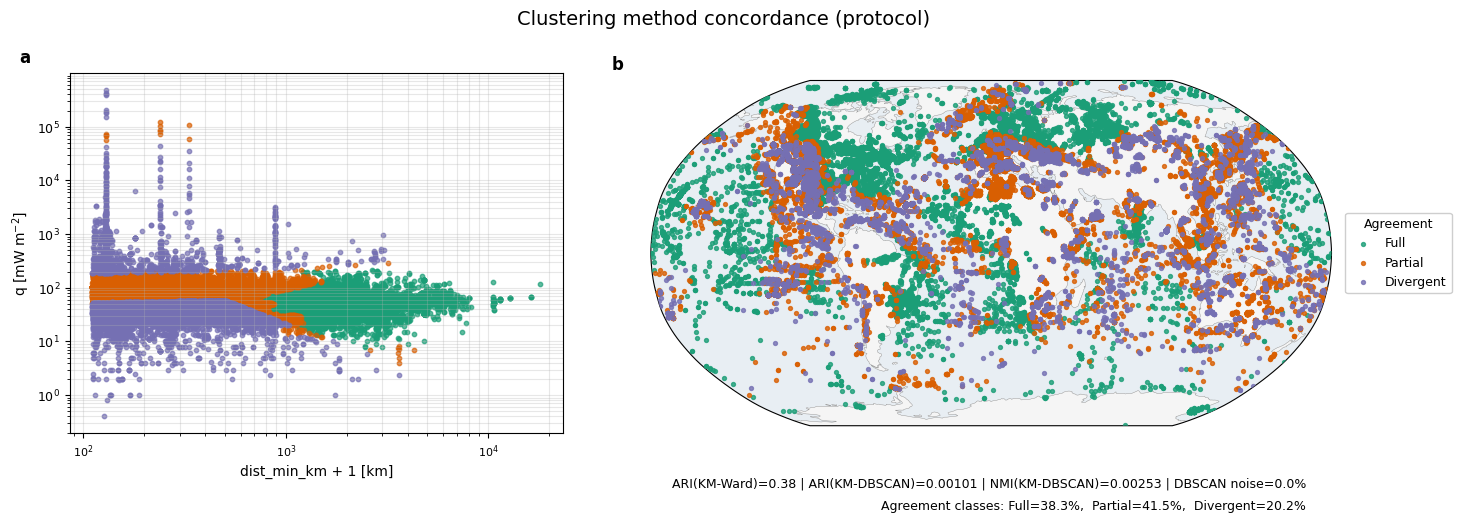


[SR3] Saved panel:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\SR3_panel_scatter_map.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\SR3_panel_scatter_map.pdf
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\SR3_panel_scatter_map.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\SR3_panel_scatter_map.pdf
[SR3] Saved individual plots:
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\agreement\agreement_scatter_q_vs_distmin.png
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\agreement\agreement_scatter_q_vs_distmin.pdf
 - C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplat

In [33]:
# ==============================================================
# Snippet 33 - Clustering Method Concordance 
#
# Objective:
#   Quantify agreement across clustering methods (KMeans, Ward, DBSCAN)
#   applied to the protocol intraplate dataset.
#
# Scope:
#   - Hungarian alignment of labels to a common reference (KMeans)
#   - Agreement metrics (Adjusted Rand Index, Normalized Mutual Information)
#   - Sensitivity analyses:
#       B1: DBSCAN non-noise subset
#       B2: Points with valid labels in both Ward and DBSCAN
#   - Pointwise agreement classification (Full / Partial / Divergent)
#   - Feature-space and geographic visualization
#
# Protocol safeguards:
#   1) Single masking step based on finite(q, dist_min_km) prior to label use
#   2) No index resetting before label alignment
#   3) Hungarian assignment for label-space comparability
#   4) Explicit preservation of DBSCAN noise label (-1)
#   5) Deterministic export via resolve_out_path()
#
# Inputs required from upstream:
#   - Snippet 31:
#       df_used, df_Xz, Xz
#       preferably df_Xz["cluster_k"] already present
#   - Snippet 32:
#       K_HIER_BEST, DBSCAN_EPS_BEST, DBSCAN_MIN_S_BEST
#
# Outputs:
#   analysis/
#     - agreement_metrics_ARI_NMI.csv
#     - agreement_metrics_ARI_NMI_nonnoise.csv
#     - agreement_metrics_ARI_NMI_valid_b2.csv
#     - agreement_counts.csv
#
#   plots/
#     - SR3_panel_scatter_map.(png|pdf)
#
#   diag_agreement/
#     - agreement_scatter_q_vs_distmin.(png|pdf)
#     - agreement_map_global.(png|pdf)
#
# Editorial role:
#   DECISION - Multi-method concordance assessment
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ----------------------------
# Display control
# ----------------------------
SHOW_INDIVIDUAL_FIGS = False
SHOW_PANEL_FIG = True
SHOW_TABLES = True
EXPORT_PANEL = True

# ----------------------------
# 0) Guards & routing (Snippet 2)
# ----------------------------
assert "resolve_out_path" in globals(), "Snippet 2 must be executed first (resolve_out_path missing)."

req_vars = ["df_used", "df_Xz", "Xz", "K_HIER_BEST", "DBSCAN_EPS_BEST", "DBSCAN_MIN_S_BEST"]
missing = [v for v in req_vars if v not in globals()]
if missing:
    raise NameError(f"[AGREEMENT] Missing required variables: {missing} - run Snippets 31 + 32 first.")

# ----------------------------
# Helpers
# ----------------------------
def _ensure_dist_min_km(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "dist_min_km" not in df.columns:
        if {"dist_gem_km", "dist_pb_km"}.issubset(df.columns):
            a = pd.to_numeric(df["dist_gem_km"], errors="coerce").to_numpy(float)
            b = pd.to_numeric(df["dist_pb_km"], errors="coerce").to_numpy(float)
            df["dist_min_km"] = np.nanmin(np.vstack([a, b]), axis=0)
        else:
            raise KeyError("[AGREEMENT] Provide 'dist_min_km' or both 'dist_gem_km' and 'dist_pb_km'.")
    return df

def _coerce_int_labels(arr_like, name):
    s = pd.Series(arr_like)
    vals = pd.to_numeric(s, errors="coerce")
    if vals.isna().any():
        bad = s[vals.isna()].astype(str).unique()[:5]
        raise ValueError(
            f"[AGREEMENT] Could not coerce {name} to integer labels. "
            f"Examples of invalid values: {list(bad)}"
        )
    return vals.astype(int).to_numpy()

def _resolve_kmeans_labels(df_xz: pd.DataFrame) -> np.ndarray:
    # Preferred source: canonical cluster assignment stored in df_Xz
    if "cluster_k" in df_xz.columns:
        return _coerce_int_labels(df_xz["cluster_k"], "df_Xz['cluster_k']")

    # Fallback: df_used cluster assignment
    if "df_used" in globals():
        dfu = pd.DataFrame(globals()["df_used"]).copy()
        if "cluster_k" in dfu.columns and len(dfu) == len(df_xz):
            return _coerce_int_labels(dfu["cluster_k"], "df_used['cluster_k']")

    # Last fallback: globals()["labels"], only if numeric
    if "labels" in globals():
        return _coerce_int_labels(globals()["labels"], "globals()['labels']")

    raise NameError(
        "[AGREEMENT] Could not resolve KMeans labels. "
        "Expected df_Xz['cluster_k'] or compatible df_used['cluster_k'] or numeric globals()['labels']."
    )

# ----------------------------
# 1) Canonical clustering space
# ----------------------------
df_labels_src = _ensure_dist_min_km(pd.DataFrame(globals()["df_Xz"]).copy()).reset_index(drop=True)
Xz_agree = np.asarray(globals()["Xz"], dtype=float)

if len(df_labels_src) != Xz_agree.shape[0]:
    raise ValueError(
        f"[AGREEMENT] Misaligned df_Xz/Xz: len(df_Xz)={len(df_labels_src)} vs Xz={Xz_agree.shape}"
    )

labels_km = _resolve_kmeans_labels(df_labels_src)

if labels_km.shape[0] != len(df_labels_src):
    raise ValueError(
        f"[AGREEMENT] KMeans label length mismatch: labels_km={labels_km.shape[0]} vs df_Xz={len(df_labels_src)}"
    )

labels_hc = AgglomerativeClustering(
    n_clusters=int(globals()["K_HIER_BEST"]),
    linkage="ward"
).fit_predict(Xz_agree).astype(int)

labels_db = DBSCAN(
    eps=float(globals()["DBSCAN_EPS_BEST"]),
    min_samples=int(globals()["DBSCAN_MIN_S_BEST"])
).fit_predict(Xz_agree).astype(int)

globals()["labels_km"] = labels_km
globals()["labels_hc"] = labels_hc
globals()["labels_db"] = labels_db

print(
    f"[AGREEMENT] Rebuilt labels from df_Xz + Xz | "
    f"KMeans N={labels_km.shape[0]:,}, "
    f"Ward k={int(globals()['K_HIER_BEST'])}, "
    f"DBSCAN eps={float(globals()['DBSCAN_EPS_BEST']):.3f}, "
    f"min_samples={int(globals()['DBSCAN_MIN_S_BEST'])}"
)

# ----------------------------
# 2) Output paths
# ----------------------------
CSV_SUMMARY_A  = resolve_out_path("agreement_metrics_ARI_NMI.csv", family="analysis")
CSV_SUMMARY_B1 = resolve_out_path("agreement_metrics_ARI_NMI_nonnoise.csv", family="analysis")
CSV_SUMMARY_B2 = resolve_out_path("agreement_metrics_ARI_NMI_valid_b2.csv", family="analysis")
CSV_COUNTS     = resolve_out_path("agreement_counts.csv", family="analysis")

scatter_png = resolve_out_path("agreement_scatter_q_vs_distmin.png", family="diag_agreement")
scatter_pdf = resolve_out_path("agreement_scatter_q_vs_distmin.pdf", family="diag_agreement")
map_png     = resolve_out_path("agreement_map_global.png", family="diag_agreement")
map_pdf     = resolve_out_path("agreement_map_global.pdf", family="diag_agreement")

panel_png   = resolve_out_path("SR3_panel_scatter_map.png", family="plots")
panel_pdf   = resolve_out_path("SR3_panel_scatter_map.pdf", family="plots")

SR_DIR = Path(FIG_SR_DIR) if ("FIG_SR_DIR" in globals() and FIG_SR_DIR is not None) else None
if SR_DIR is not None:
    SR_DIR.mkdir(parents=True, exist_ok=True)
    panel_png_sr = SR_DIR / "SR3_panel_scatter_map.png"
    panel_pdf_sr = SR_DIR / "SR3_panel_scatter_map.pdf"
else:
    panel_png_sr = None
    panel_pdf_sr = None

# ----------------------------
# 3) HARD alignment
# ----------------------------
dfu0 = df_labels_src.copy()

labels_km0 = np.asarray(globals()["labels_km"])
labels_hc0 = np.asarray(globals()["labels_hc"])
labels_db0 = np.asarray(globals()["labels_db"])

n0 = int(len(dfu0))
assert labels_km0.shape[0] == n0, "[AGREEMENT] labels_km length mismatch"
assert labels_hc0.shape[0] == n0, "[AGREEMENT] labels_hc length mismatch"
assert labels_db0.shape[0] == n0, "[AGREEMENT] labels_db length mismatch"

q0 = pd.to_numeric(dfu0["q"], errors="coerce")
d0 = pd.to_numeric(dfu0["dist_min_km"], errors="coerce")

mask_df = np.isfinite(q0.to_numpy()) & np.isfinite(d0.to_numpy())
dfu = dfu0.loc[mask_df].copy()
dfu["q"] = q0.loc[mask_df].to_numpy()
dfu["dist_min_km"] = d0.loc[mask_df].to_numpy()

labels_km_m = labels_km0[mask_df]
labels_hc_m = labels_hc0[mask_df]
labels_db_m = labels_db0[mask_df]

dfu = dfu.reset_index(drop=True)

print(f"[AGREEMENT] Base rows: {n0:,} | after finite(q, dist_min_km): {len(dfu):,}")

# ----------------------------
# 4) Hungarian alignment
# ----------------------------
def _hungarian_map_to_ref(ref, oth, ignore_label=None):
    ref = np.asarray(ref).astype(int)
    oth = np.asarray(oth).astype(int)

    m = (oth != ignore_label) if ignore_label is not None else np.ones(len(ref), bool)
    ref_m, oth_m = ref[m], oth[m]

    ru, ou = np.unique(ref_m), np.unique(oth_m)
    if len(ru) == 0 or len(ou) == 0:
        return {}

    ru_i = {v: j for j, v in enumerate(ru)}
    ou_i = {v: i for i, v in enumerate(ou)}

    C = np.zeros((len(ou), len(ru)), int)
    for r, o in zip(ref_m, oth_m):
        C[ou_i[o], ru_i[r]] += 1

    r_i, c_i = linear_sum_assignment(-C)
    return {ou[i]: ru[j] for i, j in zip(r_i, c_i)}

def _apply_mapping(labels, mapping, unmapped=-1, preserve=None):
    labels = np.asarray(labels).astype(int)
    mapped = pd.Series(labels).map(mapping).fillna(unmapped).to_numpy(int)
    if preserve is not None:
        mapped[labels == preserve] = preserve
    return mapped

km_ref = labels_km_m.astype(int)

hi_aligned = _apply_mapping(
    labels_hc_m,
    _hungarian_map_to_ref(km_ref, labels_hc_m, ignore_label=None),
    unmapped=-1
)

db_aligned = _apply_mapping(
    labels_db_m,
    _hungarian_map_to_ref(km_ref, labels_db_m, ignore_label=-1),
    unmapped=-1,
    preserve=-1
)

labels_all = pd.DataFrame({"kmeans": km_ref, "ward": hi_aligned, "dbscan": db_aligned})
assert len(labels_all) == len(dfu), "[AGREEMENT] labels_all and dfu misaligned after masking."

# ----------------------------
# 5) Agreement metrics
# ----------------------------
km = labels_all["kmeans"].to_numpy(int)
wd = labels_all["ward"].to_numpy(int)
db = labels_all["dbscan"].to_numpy(int)

summary_A = pd.DataFrame({
    "Pairs": ["KMeans-Ward", "KMeans-DBSCAN", "Ward-DBSCAN"],
    "ARI": [adjusted_rand_score(km, wd),
            adjusted_rand_score(km, db),
            adjusted_rand_score(wd, db)],
    "NMI": [normalized_mutual_info_score(km, wd),
            normalized_mutual_info_score(km, db),
            normalized_mutual_info_score(wd, db)]
})

nonnoise = (db != -1)
noise_frac = float(1.0 - nonnoise.mean())

summary_B1 = None
if int(nonnoise.sum()) >= 3:
    summary_B1 = pd.DataFrame({
        "Pairs": ["KMeans-Ward", "KMeans-DBSCAN", "Ward-DBSCAN"],
        "ARI": [adjusted_rand_score(km[nonnoise], wd[nonnoise]),
                adjusted_rand_score(km[nonnoise], db[nonnoise]),
                adjusted_rand_score(wd[nonnoise], db[nonnoise])],
        "NMI": [normalized_mutual_info_score(km[nonnoise], wd[nonnoise]),
                normalized_mutual_info_score(km[nonnoise], db[nonnoise]),
                normalized_mutual_info_score(wd[nonnoise], db[nonnoise])],
        "N_nonnoise": [int(nonnoise.sum())] * 3
    })

valid_b2 = (wd != -1) & (db != -1)
summary_B2 = None
if int(valid_b2.sum()) >= 3:
    summary_B2 = pd.DataFrame({
        "Pairs": ["KMeans-Ward", "KMeans-DBSCAN", "Ward-DBSCAN"],
        "ARI": [adjusted_rand_score(km[valid_b2], wd[valid_b2]),
                adjusted_rand_score(km[valid_b2], db[valid_b2]),
                adjusted_rand_score(wd[valid_b2], db[valid_b2])],
        "NMI": [normalized_mutual_info_score(km[valid_b2], wd[valid_b2]),
                normalized_mutual_info_score(km[valid_b2], db[valid_b2]),
                normalized_mutual_info_score(wd[valid_b2], db[valid_b2])],
        "N_valid_b2": [int(valid_b2.sum())] * 3
    })

if SHOW_TABLES:
    print("\n[AGREEMENT] Method agreement (ARI / NMI) [A: -1 kept as class]:")
    try:
        from IPython.display import display
        display(summary_A)
    except Exception:
        print(summary_A.to_string(index=False))

    print(f"\n[AGREEMENT] DBSCAN noise fraction: {noise_frac:.3f}")

    if summary_B1 is not None:
        print("\n[AGREEMENT] Sensitivity (B1: DBSCAN non-noise only):")
        try:
            display(summary_B1)
        except Exception:
            print(summary_B1.to_string(index=False))

    if summary_B2 is not None:
        print("\n[AGREEMENT] Sensitivity (B2: ward!=-1 AND dbscan!=-1):")
        try:
            display(summary_B2)
        except Exception:
            print(summary_B2.to_string(index=False))

# ----------------------------
# 6) Pointwise agreement class
# ----------------------------
full = (db != -1) & (km == wd) & (km == db)
pair_km_wd = (km == wd)
pair_km_db = (db != -1) & (km == db)
pair_wd_db = (db != -1) & (wd == db)
partial = (~full) & (pair_km_wd | pair_km_db | pair_wd_db)

agreement = np.full(len(km), "Divergent", dtype=object)
agreement[partial] = "Partial"
agreement[full] = "Full"

counts = pd.Series(agreement).value_counts().reindex(["Full", "Partial", "Divergent"], fill_value=0)
colors = {"Full": "#1b9e77", "Partial": "#d95f02", "Divergent": "#7570b3"}

n_tot = int(counts.sum())
p_full = 100.0 * float(counts["Full"]) / n_tot if n_tot else np.nan
p_part = 100.0 * float(counts["Partial"]) / n_tot if n_tot else np.nan
p_div  = 100.0 * float(counts["Divergent"]) / n_tot if n_tot else np.nan

labels_all = labels_all.copy()
labels_all["agreement"] = pd.Series(agreement, index=labels_all.index)
globals()["labels_all"] = labels_all

try:
    gplot_agree = gpd.GeoDataFrame(
        dfu[["lon", "lat", "q", "dist_min_km"]].copy(),
        geometry=gpd.points_from_xy(dfu["lon"], dfu["lat"]),
        crs="EPSG:4326",
    )
    gplot_agree["agreement"] = labels_all["agreement"].values
    globals()["gplot_agree"] = gplot_agree
except Exception as e:
    print("[AGREEMENT] Note: could not create gplot_agree:", e)

print("[AGREEMENT] labels_all columns:", list(labels_all.columns))
print("[AGREEMENT] agreement counts:", labels_all["agreement"].value_counts().to_dict())

# ----------------------------
# 7) Individual plots
# ----------------------------
x_lin = dfu["dist_min_km"].to_numpy(float)
y_lin = dfu["q"].to_numpy(float)

fig1, ax1 = plt.subplots(figsize=(7.2, 5.0))
for cat in ["Full", "Partial", "Divergent"]:
    sel = (agreement == cat)
    if sel.any():
        ax1.scatter(
            x_lin[sel] + 1.0, y_lin[sel],
            s=10, color=colors[cat], alpha=0.7, label=cat
        )
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("dist_min_km + 1 [km]")
ax1.set_ylabel("q [mW m$^{-2}$]")
ax1.set_title("Method agreement - q vs (dist_min_km + 1) - log-log")
ax1.grid(True, which="both", alpha=0.3)
fig1.tight_layout()
fig1.savefig(scatter_png, dpi=300, bbox_inches="tight")
fig1.savefig(scatter_pdf, bbox_inches="tight")
if SHOW_INDIVIDUAL_FIGS:
    plt.show()
plt.close(fig1)

# ----------------------------
# 8) Panel export
# ----------------------------
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

figP = plt.figure(figsize=(15.2, 5.8))
gs = gridspec.GridSpec(
    nrows=2, ncols=2,
    height_ratios=[1.0, 0.14],
    width_ratios=[1.05, 1.45],
    hspace=0.18, wspace=0.15
)

axL = figP.add_subplot(gs[0, 0])
for cat in ["Full", "Partial", "Divergent"]:
    sel = (agreement == cat)
    if sel.any():
        axL.scatter(
            x_lin[sel] + 1.0, y_lin[sel],
            s=10, color=colors[cat], alpha=0.7, label=cat
        )
axL.set_xscale("log")
axL.set_yscale("log")
axL.set_xlabel("dist_min_km + 1 [km]")
axL.set_ylabel("q [mW m$^{-2}$]")
axL.grid(True, which="both", alpha=0.3)

axR = figP.add_subplot(gs[0, 1], projection=ccrs.Robinson())
axR.set_global()
axR.add_feature(cfeature.OCEAN, facecolor="#e8eef3", edgecolor="none", zorder=0)
axR.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
axR.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor="#888888", zorder=1)

handles = []
labels_ = []
for cat in ["Full", "Partial", "Divergent"]:
    sel = (agreement == cat)
    if sel.any():
        h = axR.scatter(
            dfu.loc[sel, "lon"], dfu.loc[sel, "lat"],
            color=colors[cat], s=8, alpha=0.8,
            transform=ccrs.PlateCarree(),
            label=cat, zorder=3
        )
        handles.append(h)
        labels_.append(cat)

axR.legend(
    handles, labels_,
    title="Agreement",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    framealpha=0.95,
    fontsize=9,
    title_fontsize=9,
    borderaxespad=0.0
)

# Panel labels: lowercase, left side of each panel
axL.text(
    -0.08, 1.02, "a",
    transform=axL.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

axR.text(
    -0.04, 1.02, "b",
    transform=axR.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

axF = figP.add_subplot(gs[1, :])
axF.axis("off")

footer_line1 = (
    f"ARI(KM-Ward)={summary_A.iloc[0,1]:.3g} | "
    f"ARI(KM-DBSCAN)={summary_A.iloc[1,1]:.3g} | "
    f"NMI(KM-DBSCAN)={summary_A.iloc[1,2]:.3g} | "
    f"DBSCAN noise={noise_frac*100:.1f}%"
)
footer_line2 = (
    f"Agreement classes: Full={p_full:.1f}%,  Partial={p_part:.1f}%,  Divergent={p_div:.1f}%"
)

axF.text(0.98, 0.72, footer_line1, ha="right", va="center", fontsize=9)
axF.text(0.98, 0.28, footer_line2, ha="right", va="center", fontsize=9)

figP.suptitle("Clustering method concordance (protocol)", y=0.99, fontsize=14)
figP.subplots_adjust(right=0.90, left=0.07)

if EXPORT_PANEL:
    figP.savefig(panel_png, dpi=300, bbox_inches="tight")
    figP.savefig(panel_pdf, bbox_inches="tight")

    if panel_png_sr is not None and panel_pdf_sr is not None:
        figP.savefig(panel_png_sr, dpi=300, bbox_inches="tight")
        figP.savefig(panel_pdf_sr, bbox_inches="tight")
        print("[SR] Saved SR3 ->", panel_png_sr)
        print("[SR] Saved SR3 ->", panel_pdf_sr)

if SHOW_PANEL_FIG:
    plt.show()
plt.close(figP)

# ----------------------------
# 9) Individual map
# ----------------------------
fig2 = plt.figure(figsize=(10.5, 5.2))
ax2 = plt.subplot(1, 1, 1, projection=ccrs.Robinson())
ax2.set_global()
ax2.add_feature(cfeature.OCEAN, facecolor="#e8eef3", edgecolor="none", zorder=0)
ax2.add_feature(cfeature.LAND, facecolor="#f5f5f5", edgecolor="none", zorder=0)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.3, edgecolor="#888888", zorder=1)
for cat in ["Full", "Partial", "Divergent"]:
    sel = (agreement == cat)
    if sel.any():
        ax2.scatter(
            dfu.loc[sel, "lon"], dfu.loc[sel, "lat"],
            color=colors[cat], s=8, alpha=0.8,
            transform=ccrs.PlateCarree(), label=cat, zorder=3
        )
ax2.set_title("Global map - clustering method agreement (protocol)")
ax2.legend(title="Agreement", loc="lower left", frameon=True, framealpha=0.95, fontsize=9, title_fontsize=9)
fig2.tight_layout()
fig2.savefig(map_png, dpi=300, bbox_inches="tight")
fig2.savefig(map_pdf, bbox_inches="tight")
if SHOW_INDIVIDUAL_FIGS:
    plt.show()
plt.close(fig2)

# ----------------------------
# 10) Save summaries
# ----------------------------
summary_A.to_csv(CSV_SUMMARY_A, index=False)
if summary_B1 is not None:
    summary_B1.to_csv(CSV_SUMMARY_B1, index=False)
if summary_B2 is not None:
    summary_B2.to_csv(CSV_SUMMARY_B2, index=False)
counts.rename("count").to_csv(CSV_COUNTS)

print("\n[SR3] Saved panel:")
print(" -", panel_png)
print(" -", panel_pdf)
if panel_png_sr is not None:
    print(" -", panel_png_sr)
    print(" -", panel_pdf_sr)
print("[SR3] Saved individual plots:")
print(" -", scatter_png)
print(" -", scatter_pdf)
print(" -", map_png)
print(" -", map_pdf)
print("[SR3] Saved CSVs:")
print(" -", CSV_SUMMARY_A)
if summary_B1 is not None:
    print(" -", CSV_SUMMARY_B1)
if summary_B2 is not None:
    print(" -", CSV_SUMMARY_B2)
print(" -", CSV_COUNTS)
# ==============================================================


# Snippet 34 — Leave-one-continent-out robustness (protocol-aligned)

[L1CO] Base=df_k_canon. After physical cutoff: n = 53,420 valid points.
[L1CO] Missing 'continent'. Attaching via Natural Earth...
[L1CO] WORLD (local): 177 polygons.
[L1CO] Saved: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\continental_sensitivity.csv
[L1CO] Saved SR1 panel figure:
 - Canonical: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\fig_SR1_panel_table_plus_bar.png
 - Canonical: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\figures_supplementary_results\fig_SR1_panel_table_plus_bar.pdf
 - Pipeline : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\SR1_panel_table_plus_bar.png
 - Pipeline : C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\SR1_panel_table_plus_bar.pdf


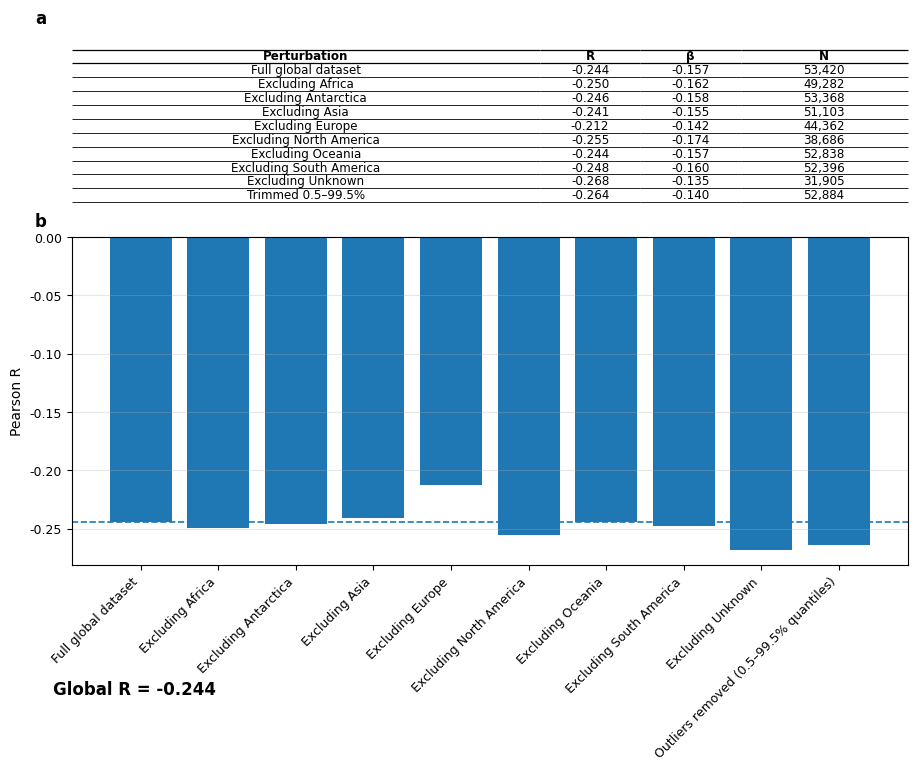

In [34]:
# ==============================================================
# Snippet 34 — Leave-one-continent-out robustness (protocol-aligned) (ROUTED)
#
# Purpose:
#   Quantify robustness of the global log–log heat-flow vs distance signal to:
#     (i) leave-one-continent-out perturbations, and
#     (ii) tail trimming (0.5–99.5% quantiles in q).
#
# Protocol alignment:
#   - Uses canonical distance metric: dist_min_km
#   - Applies physical cutoff: dist_min_km ≥ 110 km
#   - Works on df_k_canon (preferred) or df_k (fallback)
#
# Inputs:
#   Required columns:
#     - lon, lat, q
#     - dist_min_km OR (dist_gem_km and dist_pb_km) to derive dist_min_km
#   Optional:
#     - continent (if missing, attached via Natural Earth polygons)
#     - WORLD_SHP (local Natural Earth shapefile path) from Snippet 2
#
# Outputs (ROUTED via resolve_out_path):
#   - OUT_DIR/analysis/continental_sensitivity.csv
#       Table of perturbations with Pearson R, slope β, N, and p-value string.
#   - OUT_DIR/plots/SR1_panel_table_plus_bar.png
#   - OUT_DIR/plots/SR1_panel_table_plus_bar.pdf
#       Two-panel robustness figure: (A) open table, (B) bar plot of R by test.
#
# Notes:
#   - If Snippet 2 was not executed, a local fallback folder ./_out_fallback/*
#     is used (for developer convenience only; not for release).
#
# Editorial role:
#   DECISION — robustness panel for Supplementary Results (SR1).
# ============================================================== 

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import geopandas as gpd
import matplotlib.pyplot as plt

# -----------------------------
# Routing helpers (from Snippet 2)
# -----------------------------
HAS_ROUTER = ("resolve_out_path" in globals())
def _outpath(name: str, family: str):
    if HAS_ROUTER:
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

PHYS_CUTOFF = 110.0

# ---------------- 1) Load base ----------------
if "df_k_canon" in globals():
    df = df_k_canon.copy()
    base_name = "df_k_canon"
elif "df_k" in globals():
    df = df_k.copy()
    base_name = "df_k"
else:
    raise RuntimeError("[L1CO] No base dataset found. Define 'df_k_canon' or 'df_k' first.")

# ---------------- 2) Ensure required columns ----------------
needed_xyq = {"lon", "lat", "q"}
missing_xyq = needed_xyq - set(df.columns)
if missing_xyq:
    raise KeyError(f"[L1CO] Missing required columns: {missing_xyq}")

# dist_min_km per protocol
if "dist_min_km" not in df.columns:
    if {"dist_gem_km", "dist_pb_km"}.issubset(df.columns):
        df["dist_min_km"] = pd.concat(
            [
                pd.to_numeric(df["dist_gem_km"], errors="coerce"),
                pd.to_numeric(df["dist_pb_km"], errors="coerce"),
            ],
            axis=1
        ).min(axis=1)
        print("[L1CO] 'dist_min_km' derived as min(dist_gem_km, dist_pb_km).")
    else:
        raise KeyError("[L1CO] Need 'dist_min_km' or both 'dist_gem_km' and 'dist_pb_km'.")

for c in ["lon", "lat", "q", "dist_min_km"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["lon", "lat", "q", "dist_min_km"]).reset_index(drop=True)

# physical cutoff
df = df[df["dist_min_km"] >= PHYS_CUTOFF].reset_index(drop=True)
if df.empty:
    raise RuntimeError(f"[L1CO] No points after dist_min_km ≥ {PHYS_CUTOFF} km.")

print(f"[L1CO] Base={base_name}. After physical cutoff: n = {len(df):,} valid points.")

# ---------------- 3) Attach continent if missing ----------------
WORLD_LOCAL = None
if "WORLD_SHP" in globals():
    WORLD_LOCAL = Path(WORLD_SHP)
elif "WORLD_SHP" in locals():
    WORLD_LOCAL = Path(locals()["WORLD_SHP"])

def _attach_continent(df_in: pd.DataFrame) -> pd.DataFrame:
    if "continent" in df_in.columns:
        out = df_in.copy()
        out["continent"] = out["continent"].astype(str)
        print("[L1CO] Using existing 'continent' column.")
        return out

    print("[L1CO] Missing 'continent'. Attaching via Natural Earth...")
    gpts = gpd.GeoDataFrame(
        df_in.copy(),
        geometry=gpd.points_from_xy(df_in["lon"], df_in["lat"]),
        crs="EPSG:4326"
    )

    if (WORLD_LOCAL is not None) and WORLD_LOCAL.exists():
        world = gpd.read_file(WORLD_LOCAL)
        cont_col = "CONTINENT" if "CONTINENT" in world.columns else ("continent" if "continent" in world.columns else None)
        if cont_col is None:
            raise KeyError("[L1CO] Local shapefile lacks a continent column.")
        world = world[[cont_col, "geometry"]].rename(columns={cont_col: "continent"})
        world = world.to_crs(4326) if world.crs else world.set_crs(4326)
        print(f"[L1CO] WORLD (local): {len(world):,} polygons.")
    else:
        # built-in fallback (works offline)
        from geopandas import datasets
        world = gpd.read_file(datasets.get_path("naturalearth_lowres"))
        world = world[["continent", "geometry"]]
        world = world.to_crs(4326) if world.crs else world.set_crs(4326)
        print(f"[L1CO] WORLD (builtin fallback): {len(world):,} polygons.")

    joined = gpd.sjoin(
        gpts.to_crs(4326),
        world.to_crs(4326),
        how="left",
        predicate="intersects"
    )

    out = pd.DataFrame(joined.drop(columns=["geometry", "index_right"]))
    out["continent"] = out["continent"].fillna("Unknown").astype(str)
    return out

df = _attach_continent(df)

# ---------------- 4) Log variables ----------------
df["x"] = np.log10(df["dist_min_km"].clip(lower=1e-3) + 1.0)
df["y"] = np.log10(df["q"].clip(lower=1e-6))

# ---------------- 5) p-safe helpers ----------------
def pearson_p_logspace(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = int(x.size)
    if n < 3:
        return np.nan, np.nan, "NA"

    r = float(np.corrcoef(x, y)[0, 1])
    r = float(np.clip(r, -1.0, 1.0))

    denom = 1.0 - r*r
    if denom <= 0:
        return r, -np.inf, "< 1e-9999"

    t = abs(r) * np.sqrt((n - 2) / denom)
    dfree = n - 2

    ln_p = stats.t.logsf(t, df=dfree) + np.log(2.0)
    if not np.isfinite(ln_p):
        ln_p = stats.norm.logsf(t) + np.log(2.0)

    log10_p = float(ln_p / np.log(10.0))
    exp_floor = int(np.floor(log10_p)) if np.isfinite(log10_p) else -9999

    if not np.isfinite(log10_p):
        return r, -np.inf, "< 1e-9999"

    if log10_p >= -300:
        p_num = 10.0 ** log10_p
        p_str = f"{p_num:.3e}"
    else:
        p_str = f"< 1e{exp_floor}"

    return r, log10_p, p_str

def corr_xy(sub: pd.DataFrame):
    if len(sub) < 10:
        return np.nan, np.nan, "NA", np.nan
    r, log10_p, p_str = pearson_p_logspace(sub["x"], sub["y"])
    slope, intercept, _, _, _ = stats.linregress(sub["x"], sub["y"])
    return float(r), float(log10_p), str(p_str), float(slope)

# ---------------- 6) Robustness table ----------------
rows = []
r0, log10_p0, p_str0, slope0 = corr_xy(df)
rows.append({"Test": "Full global dataset", "R": r0, "p_str": p_str0, "log10_p": log10_p0, "Slope": slope0, "n": int(len(df))})

continents = sorted(df["continent"].dropna().unique())
for cont in continents:
    sub = df[df["continent"] != cont]
    r, log10_p, p_str, slope = corr_xy(sub)
    rows.append({"Test": f"Excluding {cont}", "R": r, "p_str": p_str, "log10_p": log10_p, "Slope": slope, "n": int(len(sub))})

q_lo, q_hi = df["q"].quantile([0.005, 0.995])
sub_trim = df[(df["q"] >= q_lo) & (df["q"] <= q_hi)]
r, log10_p, p_str, slope = corr_xy(sub_trim)
rows.append({"Test": "Outliers removed (0.5–99.5% quantiles)", "R": r, "p_str": p_str, "log10_p": log10_p, "Slope": slope, "n": int(len(sub_trim))})

robust_df = pd.DataFrame(rows)

# Save CSV (ROUTED) — this is a main analysis robustness artifact
out_csv = _outpath("continental_sensitivity.csv", family="analysis")
robust_df.to_csv(out_csv, index=False)
print(f"[L1CO] Saved: {out_csv}")

# ---------------- 7) Panel A table ----------------
tab_sr1 = robust_df[["Test", "R", "Slope", "n"]].copy()
tab_sr1.columns = ["Perturbation", "R", "β", "N"]
tab_sr1["Perturbation"] = tab_sr1["Perturbation"].replace({
    "Outliers removed (0.5–99.5% quantiles)": "Trimmed 0.5–99.5%"
})

tab_sr1_fmt = tab_sr1.copy()
tab_sr1_fmt["R"] = tab_sr1_fmt["R"].map(lambda v: f"{v:.3f}")
tab_sr1_fmt["β"] = tab_sr1_fmt["β"].map(lambda v: f"{v:.3f}")
tab_sr1_fmt["N"] = tab_sr1_fmt["N"].map(lambda v: f"{int(v):,}")

# ---------------- 8) Panel figure (aligned margins) ----------------
labels_plot = robust_df["Test"].tolist()
R_vals = robust_df["R"].astype(float).tolist()
x = np.arange(len(labels_plot))

fig = plt.figure(figsize=(9.5, 7.2))
gs = fig.add_gridspec(
    2, 1,
    height_ratios=[1.55, 3.0],
    hspace=0.14,
    left=0.10, right=0.98,
    top=0.96, bottom=0.22
)

ax_t = fig.add_subplot(gs[0, 0])
ax_t.axis("off")

col_widths = [0.56, 0.12, 0.12, 0.20]
table = ax_t.table(
    cellText=tab_sr1_fmt.values,
    colLabels=tab_sr1_fmt.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=col_widths,
    bbox=[0.0, 0.0, 1.0, 0.90]
)
table.auto_set_font_size(False)
table.set_fontsize(8.6)
table.scale(1.0, 1.02)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.visible_edges = "TB"
        cell.set_linewidth(0.9)
    else:
        cell.visible_edges = "B"
        cell.set_linewidth(0.6)

ax = fig.add_subplot(gs[1, 0])
ax.bar(x, R_vals)
ax.axhline(r0, linestyle="--", linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=45, ha="right")
ax.set_ylabel("Pearson R")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", labelsize=9)

# Panel labels: lowercase, left side of each panel
ax_t.text(
    -0.03, 1.03, "a",
    transform=ax_t.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

ax.text(
    -0.03, 1.02, "b",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=12, fontweight="bold",
    clip_on=False
)

fig.text(0.08, 0.035, f"Global R = {r0:.3f}",
         ha="left", va="bottom",
         fontsize=12, fontweight="bold")

# ---------------- 9) Save figures (ROUTED) ----------------
# --- Canonical Supplementary Results folder ---
if "FIG_SR_DIR" in globals():
    sr_dir = Path(FIG_SR_DIR).resolve()
else:
    sr_dir = Path(_outpath("_sr_router_probe.txt", family="plots")).parent.resolve()

sr_dir.mkdir(parents=True, exist_ok=True)

out_png = sr_dir / "fig_SR1_panel_table_plus_bar.png"
out_pdf = sr_dir / "fig_SR1_panel_table_plus_bar.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

# --- Pipeline / plots copy (keeps router behavior intact) ---
out_png_pipe = _outpath("SR1_panel_table_plus_bar.png", family="plots")
out_pdf_pipe = _outpath("SR1_panel_table_plus_bar.pdf", family="plots")

fig.savefig(out_png_pipe, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf_pipe, bbox_inches="tight")

print("[L1CO] Saved SR1 panel figure:")
print(f" - Canonical: {out_png}")
print(f" - Canonical: {out_pdf}")
print(f" - Pipeline : {out_png_pipe}")
print(f" - Pipeline : {out_pdf_pipe}")

plt.show()

# Snippet 35 — Fragmentation QA tests (EQ + strain + Bouguer) (intraplate thermal outliers)

[INFO] EQ RAW → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\earthquakes\terremotos_combined_1898_2025.csv
[INFO] GSRM   → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\strain\gsrm.nc
[INFO] BG     → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\gravity\WGM2012_Bouguer_ponc_2min.grd
[INFO] Using df_k_canon already in memory.
[INFO] df_used: (53420, 7) | df_outliers (point-level): (1963, 7)
[EQ] Loaded cache → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\processed\earthquakes\eq_cache_master.parquet | N=112,055
[INFO] EQ prepared for Test A: (112055, 5)
QA tests complete.
Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\qa_fragmentation\qa_fragmentation_tests.csv
Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\

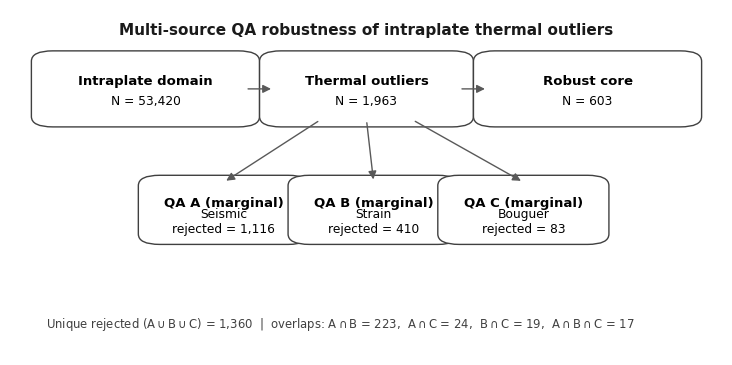

[QA-FLOW] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\qa_fragmentation\fig4_QA_robustness_flow.png
[QA-FLOW] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\diagnostics\qa_fragmentation\fig4_QA_robustness_flow.pdf


In [35]:
# ==============================================================
# Snippet 35 — Fragmentation QA tests (EQ + strain + Bouguer) (ROUTED)
#
# Purpose:
#   Apply exclusion-style QA tests on protocol intraplate outliers (point-level):
#     A) Shallow seismicity proximity / rate test
#     B) Strain-rate screening (GSRM)
#     C) Bouguer anomaly screening (WGM2012; true annulus MAD-z)
#
#   Produce a final keep_intraplate flag combining A/B/C.
#
# IMPORTANT (point-level definition; no spatial collapse):
#   Outliers are defined strictly at the canonical POINT level (each measurement row).
#   Therefore we do NOT perform spatial aggregation or lat/lon-based collapsing here.
#
# Inputs (from Snippet 2 + PARAMS):
#   - OUT_DIR (pipeline root; used to locate canonical artifacts)
#   - FREEZE_DIR (optional frozen canonical artifacts location)
#   - EQ_RAW_CSV, EQ_CACHE_PARQUET_PATH
#   - GSRM_NC_PATH (GSRM strain-rate grid)
#   - BOUGUER_GRID_PATH (WGM2012 Bouguer anomaly grid)
#   - require_param("DIST_CUTOFF_KM")
#   - require_param("Q_THR_RELEV")
#
# Outputs (ROUTED via pipeline diagnostics):
#   - public_release/pipeline_kmeans/diagnostics/qa_fragmentation/qa_fragmentation_tests.csv
#   - public_release/pipeline_kmeans/diagnostics/qa_fragmentation/qa_fragmentation_tests.gpkg
#   - public_release/pipeline_kmeans/diagnostics/qa_fragmentation/fig4_QA_robustness_flow.(png|pdf)  (optional)
#
# Description:
#   The CSV and GeoPackage contain point-level QA diagnostics for each
#   intraplate thermal outlier, including:
#       • test indicators for A (seismicity), B (strain), and C (Bouguer anomaly)
#       • inconclusive flags for each screening test
#       • the final keep_intraplate classification.
#
# Editorial role:
#   DECISION — multi-source QA screening on intraplate outliers (point-level).
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import hashlib, json
from pyproj import Geod
import rasterio
from rasterio.warp import transform

# -----------------------------
# Routing helpers (from Snippet 2)
# -----------------------------
HAS_ROUTER = ("resolve_out_path" in globals())
def _outpath(name: str, family: str):
    if HAS_ROUTER:
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

# QA folder (global, not pipeline-diagnostics)
QA_FRAG_DIR = (DIAG_DIR / "qa_fragmentation") if ("DIAG_DIR" in globals()) else Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV  = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
OUT_GPKG = QA_FRAG_DIR / "qa_fragmentation_tests.gpkg"

# Canonical artifacts location:
# Prefer FREEZE_DIR if you have it frozen there; otherwise fall back to OUT_DIR.
CSV_CANON = None
FP_JSON = None
if "FREEZE_DIR" in globals():
    # If you later freeze canonical CSV+fingerprint, point here.
    # For now, keep fallback to OUT_DIR.
    pass

if "OUT_DIR" in globals():
    CSV_CANON = Path(OUT_DIR) / "df_k_canon.csv"
    FP_JSON   = Path(OUT_DIR) / "df_k_fingerprint_principal.json"
else:
    # last-resort fallback
    CSV_CANON = Path("./public_release/data/pipeline_kmeans/df_k_canon.csv")
    FP_JSON   = Path("./public_release/data/pipeline_kmeans/df_k_fingerprint_principal.json")

EQ_RAW_FILE = EQ_RAW_CSV if "EQ_RAW_CSV" in globals() else None
EQ_CACHE_PARQUET = EQ_CACHE_PARQUET_PATH if "EQ_CACHE_PARQUET_PATH" in globals() else None
USE_EQ_CACHE = True

GSRM_NC     = GSRM_NC_PATH if "GSRM_NC_PATH" in globals() else None
BOUGUER_GRD = BOUGUER_GRID_PATH if "BOUGUER_GRID_PATH" in globals() else None

def _probe_readable(p: Path, nbytes: int = 64) -> None:
    """Raise clear error if exists but not readable (OneDrive placeholders, permissions)."""
    p = Path(p)
    if not p.exists():
        raise FileNotFoundError(f"[ERROR] Missing file: {p}")
    try:
        with open(p, "rb") as f:
            _ = f.read(nbytes)
    except Exception as e:
        raise RuntimeError(
            "[ERROR] File exists but is not readable (likely OneDrive placeholder / permission issue).\n"
            "Fix: mark 'Always keep on this device' OR move raw data outside OneDrive OR set env vars to local paths.\n"
            f"Path: {p}"
        ) from e

# Hard assertions (reproducibility > convenience)
assert EQ_RAW_FILE is not None, "[ERROR] EQ_RAW_CSV is None (Snippet 2 resolution failed)."
assert BOUGUER_GRD is not None, "[ERROR] BOUGUER_GRID_PATH is None (Snippet 2 resolution failed)."
assert GSRM_NC is not None, "[ERROR] GSRM_NC_PATH is None (Snippet 2 resolution failed)."

_probe_readable(Path(EQ_RAW_FILE))
_probe_readable(Path(GSRM_NC))
_probe_readable(Path(BOUGUER_GRD))

print(f"[INFO] EQ RAW → {EQ_RAW_FILE}")
print(f"[INFO] GSRM   → {GSRM_NC}")
print(f"[INFO] BG     → {BOUGUER_GRD}")

# --------------------------------------------------------------
# 1) PARAMETERS (protocol-locked)
# --------------------------------------------------------------
DIST_MIN_KM_PHYS = float(require_param("DIST_CUTOFF_KM"))
Q_THRESH = float(require_param("Q_THR_RELEV"))

MAG_MIN            = 3.5
DEPTH_MAXKM        = 35.0
YEAR_MIN           = 1898
YEAR_MAX_FIXED     = 2025
YEARS_WINDOW_FIXED = float(YEAR_MAX_FIXED - YEAR_MIN + 1)

R_EQ_KM     = 100.0
EQ_RATE_MIN = 2.0
D_MIN_EQ_KM = 50.0

STRAIN_MAX = 1e-9

ANNULUS_INNER_KM   = 300.0
ANNULUS_OUTER_KM   = 500.0
ANNULUS_N_SAMPLES  = 2000
Z_ABS_MIN          = 2.0

geod = Geod(ellps="WGS84")

# --------------------------------------------------------------
# 2) Canonical loader (reuse memory if available)
# --------------------------------------------------------------
def _load_df_k_canon_disk(csv_path: Path, fp_json: Path) -> pd.DataFrame:
    csv_path = Path(csv_path)
    fp_json = Path(fp_json)

    assert csv_path.exists(), f"Missing canonical CSV: {csv_path}"
    assert fp_json.exists(),  f"Missing fingerprint JSON: {fp_json}"

    fp = json.loads(fp_json.read_text(encoding="utf-8"))
    expected_sha = fp.get("sha256")
    if not expected_sha:
        raise KeyError("Missing 'sha256' in fingerprint JSON.")

    sha_now = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    print(f"[CHECK] SHA current : {sha_now}")
    print(f"[CHECK] SHA expected: {expected_sha}")
    if sha_now != expected_sha:
        raise RuntimeError("❌ SHA mismatch for canonical dataset.")

    df = pd.read_csv(csv_path)
    required = ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    print(f"[READY] Canonical dataset loaded → shape={df.shape}")
    return df

if "df_k_canon" in globals() and isinstance(df_k_canon, pd.DataFrame):
    print("[INFO] Using df_k_canon already in memory.")
    df_k = df_k_canon.copy()
else:
    df_k = _load_df_k_canon_disk(CSV_CANON, FP_JSON)

# --------------------------------------------------------------
# 3) PROTOCOL: SELECT OUTLIERS  (POINT-LEVEL; NO SPATIAL COLLAPSE)
# --------------------------------------------------------------
for c in ["lat", "lon", "q", "dist_min_km", "dist_gem_km", "dist_pb_km"]:
    df_k[c] = pd.to_numeric(df_k[c], errors="coerce")

df_k = df_k.replace([np.inf, -np.inf], np.nan)
df_k = df_k.dropna(subset=["lat", "lon", "q", "dist_min_km"]).copy()

def _row_hash(lat, lon, q, dmin, dgem, dpb) -> str:
    s = f"{lat:.6f}|{lon:.6f}|{q:.6f}|{dmin:.6f}|{dgem:.6f}|{dpb:.6f}"
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

df_k["canon_row_hash"] = [
    _row_hash(la, lo, qq, dm, dg, dp)
    for la, lo, qq, dm, dg, dp in zip(
        df_k["lat"].values, df_k["lon"].values, df_k["q"].values,
        df_k["dist_min_km"].values, df_k["dist_gem_km"].values, df_k["dist_pb_km"].values
    )
]

df_used = df_k[df_k["dist_min_km"] >= DIST_MIN_KM_PHYS].copy()
df_outliers = df_used[df_used["q"] >= Q_THRESH].copy()

# IMPORTANT: keep point-level; do NOT deduplicate here
# df_outliers = df_outliers.drop_duplicates().reset_index(drop=True)  # ❌ remove

df_outliers = df_outliers.reset_index(drop=True)
print(f"[INFO] df_used: {df_used.shape} | df_outliers (point-level): {df_outliers.shape}")

# --------------------------------------------------------------
# 4) HELPERS
# --------------------------------------------------------------
def _dist_km(lat1, lon1, lat2, lon2):
    lat2 = np.atleast_1d(lat2).astype(float)
    lon2 = np.atleast_1d(lon2).astype(float)
    lats1 = np.full_like(lat2, float(lat1))
    lons1 = np.full_like(lon2, float(lon1))
    _, _, dist_m = geod.inv(lons1, lats1, lon2, lat2)
    return dist_m / 1000.0

def _wrap_lon180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def _lon_between_wrap(series_lon, lo, hi):
    if lo <= hi:
        return series_lon.between(lo, hi)
    return (series_lon >= lo) | (series_lon <= hi)

# --------------------------------------------------------------
# 5) EQ LOADER
# --------------------------------------------------------------
def _pick_col(raw: pd.DataFrame, candidates_lower):
    for c in raw.columns:
        if c.lower() in candidates_lower:
            return c
    raise KeyError(f"Could not find any of columns: {sorted(candidates_lower)}")

def _fuse_depth_km(raw: pd.DataFrame) -> pd.Series:
    d1 = pd.to_numeric(raw["depth"], errors="coerce") if "depth" in raw.columns else pd.Series(np.nan, index=raw.index)
    d2 = pd.to_numeric(raw["Depth"], errors="coerce") if "Depth" in raw.columns else pd.Series(np.nan, index=raw.index)
    d = d1.combine_first(d2)
    d = d.mask(d == 0, np.nan)
    return d

def _robust_parse_time_utc(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    return pd.to_datetime(s, errors="coerce", utc=True)

def _read_eq_master(raw_csv: Path, cache_parquet: Path = None, use_cache: bool = True) -> pd.DataFrame:
    raw_csv = Path(raw_csv)
    if use_cache and cache_parquet is not None:
        cache_parquet = Path(cache_parquet)
        if cache_parquet.exists():
            try:
                eqc = pd.read_parquet(cache_parquet)
                need = {"lat", "lon", "depth_km", "mag", "time"}
                if need.issubset(eqc.columns):
                    print(f"[EQ] Loaded cache → {cache_parquet} | N={len(eqc):,}")
                    return eqc
                print("[EQ] Cache missing required columns; rebuilding.")
            except Exception as e:
                print(f"[EQ] Cache read failed, rebuilding: {e}")

    raw = pd.read_csv(raw_csv, low_memory=False)
    print(f"[EQ] RAW loaded: shape={raw.shape}")

    lat_c  = _pick_col(raw, {"lat", "latitude"})
    lon_c  = _pick_col(raw, {"lon", "longitude"})
    mag_c  = _pick_col(raw, {"mag", "magnitude"})

    if "time_parsed" in raw.columns:
        time_src = raw["time_parsed"]
    else:
        time_c = _pick_col(raw, {"time", "origin_time", "datetime", "date"})
        time_src = raw[time_c]

    depth_km = _fuse_depth_km(raw)

    eq = pd.DataFrame({
        "lat": pd.to_numeric(raw[lat_c], errors="coerce"),
        "lon": pd.to_numeric(raw[lon_c], errors="coerce"),
        "depth_km": depth_km,
        "mag": pd.to_numeric(raw[mag_c], errors="coerce"),
        "time": time_src,
    })

    eq["lon"] = _wrap_lon180(eq["lon"].values)
    eq["time"] = _robust_parse_time_utc(eq["time"])

    mask = (
        eq["mag"].ge(MAG_MIN) &
        eq["depth_km"].notna() & eq["depth_km"].le(DEPTH_MAXKM) &
        eq["time"].notna() & (eq["time"].dt.year >= YEAR_MIN) &
        eq["lat"].notna() & eq["lon"].notna()
    )
    eq = eq.loc[mask, ["lat", "lon", "depth_km", "mag", "time"]].reset_index(drop=True)

    if use_cache and cache_parquet is not None:
        try:
            cache_parquet.parent.mkdir(parents=True, exist_ok=True)
            eq.to_parquet(cache_parquet, index=False)
            print(f"[EQ] Cache saved → {cache_parquet} | N={len(eq):,}")
        except Exception as e:
            print(f"[EQ] Cache write failed (non-fatal): {e}")

    return eq

eq = _read_eq_master(EQ_RAW_FILE, cache_parquet=EQ_CACHE_PARQUET, use_cache=USE_EQ_CACHE)
print(f"[INFO] EQ prepared for Test A: {eq.shape}")

# --------------------------------------------------------------
# 6) TEST A — Shallow seismicity
# --------------------------------------------------------------
def _seismic_metrics(lat, lon):
    lon = float(_wrap_lon180(lon))
    lat = float(lat)

    deg_lat = R_EQ_KM / 111.0
    deg_lon = R_EQ_KM / max(1e-6, (111.0 * np.cos(np.radians(lat))))

    lo_lat = lat - 3 * deg_lat
    hi_lat = lat + 3 * deg_lat
    lo_lon = float(_wrap_lon180(lon - 3 * deg_lon))
    hi_lon = float(_wrap_lon180(lon + 3 * deg_lon))

    sub = eq[
        (eq["lat"].between(lo_lat, hi_lat)) &
        (_lon_between_wrap(eq["lon"], lo_lon, hi_lon))
    ]
    if sub.empty:
        return np.inf, 0.0, 0, True

    d_km = _dist_km(lat, lon, sub["lat"].values, sub["lon"].values)
    dmin = float(np.min(d_km)) if d_km.size else np.inf

    inside_mask = d_km <= R_EQ_KM
    n_inside = int(np.sum(inside_mask))
    if n_inside == 0:
        return dmin, 0.0, int(len(sub)), False

    rate = float(n_inside / YEARS_WINDOW_FIXED)
    return dmin, rate, int(len(sub)), False

A_dmin, A_rate, A_subN, A_inconcl = [], [], [], []
for lat, lon in zip(df_outliers["lat"].values, df_outliers["lon"].values):
    dmin, rate, subN, inconcl = _seismic_metrics(lat, lon)
    A_dmin.append(dmin)
    A_rate.append(rate)
    A_subN.append(subN)
    A_inconcl.append(bool(inconcl))

df_outliers["A_dmin_eq_km"] = A_dmin
df_outliers["A_rate_per_year_R100"] = A_rate
df_outliers["A_eq_prefilter_N"] = A_subN
df_outliers["A_inconclusive"] = A_inconcl

df_outliers["label_A"] = (
    (df_outliers["A_dmin_eq_km"] < D_MIN_EQ_KM) |
    (df_outliers["A_rate_per_year_R100"] >= EQ_RATE_MIN)
)

# --------------------------------------------------------------
# 7) TEST B — Strain rate (GSRM)
# --------------------------------------------------------------
def _open_xr_dataset_robust(path: Path) -> xr.Dataset:
    path = Path(path)
    _probe_readable(path)

    last_err = None
    for engine in ["netcdf4", "h5netcdf", "scipy", None]:
        try:
            if engine is None:
                return xr.open_dataset(path)
            return xr.open_dataset(path, engine=engine)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"[ERROR] Failed to open GSRM netCDF: {path}\nLast error: {last_err}") from last_err

ds = _open_xr_dataset_robust(GSRM_NC)
try:
    assert "sisr" in ds.variables, "[ERROR] 'sisr' not found in GSRM dataset."

    lon_coord_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
    lat_coord_name = "lat" if "lat" in ds.coords else ("latitude" if "latitude" in ds.coords else None)
    if lon_coord_name is None or lat_coord_name is None:
        raise KeyError("[ERROR] Could not find lat/lon coords in GSRM netCDF.")

    lon_vals = ds[lon_coord_name].values
    lon_is_0360 = (np.nanmin(lon_vals) >= 0.0) and (np.nanmax(lon_vals) > 180.0)

    latsB = df_outliers["lat"].values.astype(float)
    lonsB = df_outliers["lon"].values.astype(float)
    if lon_is_0360:
        lonsB = np.mod(lonsB, 360.0)

    vals = ds["sisr"].interp(
        {lat_coord_name: ("p", latsB), lon_coord_name: ("p", lonsB)},
        kwargs={"fill_value": np.nan}
    )

    df_outliers["B_strain_1peryr"] = np.asarray(vals.values, dtype=float)
    df_outliers["B_inconclusive"] = ~np.isfinite(df_outliers["B_strain_1peryr"].values)
    df_outliers["label_B"] = df_outliers["B_strain_1peryr"] > STRAIN_MAX
finally:
    try:
        ds.close()
    except Exception:
        pass

# --------------------------------------------------------------
# 8) TEST C — Bouguer anomaly (true annulus MAD-z)
# --------------------------------------------------------------
def _sample_points(src, lons, lats):
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    if src.crs is None or str(src.crs).upper() in ("EPSG:4326", "WGS84"):
        xs, ys = lons, lats
    else:
        xs, ys = transform("EPSG:4326", src.crs, lons.tolist(), lats.tolist())
        xs, ys = np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)

    out = []
    for v in src.sample(list(zip(xs, ys))):
        vv = float(v[0]) if v is not None and np.isfinite(v[0]) else np.nan
        out.append(vv)
    return np.asarray(out, dtype=float)

def _annulus_reference_values(lon, lat, n=ANNULUS_N_SAMPLES):
    rng = np.random.default_rng(42)
    u = rng.random(n)
    r1 = ANNULUS_INNER_KM
    r2 = ANNULUS_OUTER_KM
    r = np.sqrt(u * (r2**2 - r1**2) + r1**2)
    az = rng.random(n) * 360.0
    lons, lats, _ = geod.fwd(np.full(n, float(lon)), np.full(n, float(lat)), az, r * 1000.0)
    return np.asarray(lons, dtype=float), np.asarray(lats, dtype=float)

def _robust_med_mad(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    return med, 1.4826 * mad

with rasterio.open(BOUGUER_GRD) as src:
    C_val, C_med, C_mad, C_z, C_inconcl = [], [], [], [], []
    for lat, lon in zip(df_outliers["lat"].values, df_outliers["lon"].values):
        lon = float(_wrap_lon180(lon))
        lat = float(lat)

        v_point = _sample_points(src, [lon], [lat])[0]
        ref_lons, ref_lats = _annulus_reference_values(lon, lat, n=ANNULUS_N_SAMPLES)
        v_ref = _sample_points(src, ref_lons, ref_lats)

        med, mad = _robust_med_mad(v_ref)

        inconcl = (not np.isfinite(v_point)) or (not np.isfinite(med)) or (not np.isfinite(mad)) or (mad <= 0)
        z = np.nan if inconcl else (v_point - med) / mad

        C_val.append(v_point)
        C_med.append(med)
        C_mad.append(mad)
        C_z.append(float(z) if np.isfinite(z) else np.nan)
        C_inconcl.append(bool(inconcl))

df_outliers["C_bouguer_mgal"] = C_val
df_outliers["C_bg_median"] = C_med
df_outliers["C_bg_MAD"] = C_mad
df_outliers["C_bg_z"] = C_z
df_outliers["C_inconclusive"] = C_inconcl
df_outliers["label_C"] = df_outliers["C_bg_z"].abs() >= Z_ABS_MIN

# --------------------------------------------------------------
# 9) FINAL FLAG + EXPORTS + SUMMARY
# --------------------------------------------------------------
df_outliers["keep_intraplate"] = ~(
    df_outliers["label_A"] |
    df_outliers["label_B"] |
    df_outliers["label_C"]
)

QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)
df_outliers.to_csv(OUT_CSV, index=False)

try:
    gdf = gpd.GeoDataFrame(
        df_outliers,
        geometry=gpd.points_from_xy(df_outliers["lon"], df_outliers["lat"]),
        crs="EPSG:4326",
    )
    gdf.to_file(OUT_GPKG, layer="qa_tests", driver="GPKG")
except Exception as e:
    print(f"[WARN] Could not save GeoPackage: {e}")

n_total = len(df_outliers)
n_keep = int(df_outliers["keep_intraplate"].sum())
nA = int(df_outliers["label_A"].sum())
nB = int(df_outliers["label_B"].sum())
nC = int(df_outliers["label_C"].sum())
nA_inc = int(df_outliers["A_inconclusive"].sum())
nB_inc = int(df_outliers["B_inconclusive"].sum())
nC_inc = int(df_outliers["C_inconclusive"].sum())

print("QA tests complete.")
print(f"Saved → {OUT_CSV}")
print(f"Saved → {OUT_GPKG}")
print(f"[SUMMARY] Kept as intraplate: {n_keep} / {n_total}")
print(f"[SUMMARY] Rejected by A (EQ):     {nA}  | inconclusive_A: {nA_inc}")
print(f"[SUMMARY] Rejected by B (strain): {nB}  | inconclusive_B: {nB_inc}")
print(f"[SUMMARY] Rejected by C (Bouguer):{nC}  | inconclusive_C: {nC_inc}")

AB = int((df_outliers["label_A"] & df_outliers["label_B"]).sum())
AC = int((df_outliers["label_A"] & df_outliers["label_C"]).sum())
BC = int((df_outliers["label_B"] & df_outliers["label_C"]).sum())
ABC = int((df_outliers["label_A"] & df_outliers["label_B"] & df_outliers["label_C"]).sum())
print(f"[SUMMARY] Overlaps: A∩B={AB}, A∩C={AC}, B∩C={BC}, A∩B∩C={ABC}")

# --------------------------------------------------------------
# 10) FIGURE 4 — QA ROBUSTNESS FLOW (optional)
# --------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

FIG4_PNG = QA_FRAG_DIR / "fig4_QA_robustness_flow.png"
FIG4_PDF = QA_FRAG_DIR / "fig4_QA_robustness_flow.pdf"

n_domain = int(len(df_used))
n_out = int(n_total)
n_core = int(n_keep)
n_rej_unique = int(n_out - n_core)

def _box(ax, x, y, w, h, title, body, fs_t=9.5, fs_b=8.8):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.0, edgecolor="0.25", facecolor="1.0"
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h*0.63, title, ha="center", va="center",
            fontsize=fs_t, weight="semibold")
    ax.text(x + w/2, y + h*0.30, body, ha="center", va="center",
            fontsize=fs_b)
    return (x, y, w, h)

def _arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="-|>",
            mutation_scale=12,
            linewidth=1.0,
            color="0.35"
        )
    )

fig = plt.figure(figsize=(9.2, 4.8))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.94,
    "Multi-source QA robustness of intraplate thermal outliers",
    ha="center", va="center",
    fontsize=11.0, color="0.10", weight="semibold",
    transform=ax.transAxes
)

b1 = _box(ax, 0.05, 0.68, 0.28, 0.18, "Intraplate domain", f"N = {n_domain:,}")
b2 = _box(ax, 0.37, 0.68, 0.26, 0.18, "Thermal outliers", f"N = {n_out:,}")
b3 = _box(ax, 0.67, 0.68, 0.28, 0.18, "Robust core", f"N = {n_core:,}")

_arrow(ax, b1[0] + b1[2], b1[1] + b1[3]/2, b2[0], b2[1] + b2[3]/2)
_arrow(ax, b2[0] + b2[2], b2[1] + b2[3]/2, b3[0], b3[1] + b3[3]/2)

qaA = _box(ax, 0.20, 0.34, 0.20, 0.16, "QA A (marginal)", f"Seismic\nrejected = {nA:,}")
qaB = _box(ax, 0.41, 0.34, 0.20, 0.16, "QA B (marginal)", f"Strain\nrejected = {nB:,}")
qaC = _box(ax, 0.62, 0.34, 0.20, 0.16, "QA C (marginal)", f"Bouguer\nrejected = {nC:,}")

_arrow(ax, b2[0] + b2[2]*0.25, b2[1], qaA[0] + qaA[2]/2, qaA[1] + qaA[3])
_arrow(ax, b2[0] + b2[2]*0.50, b2[1], qaB[0] + qaB[2]/2, qaB[1] + qaB[3])
_arrow(ax, b2[0] + b2[2]*0.75, b2[1], qaC[0] + qaC[2]/2, qaC[1] + qaC[3])

foot = (
    rf"Unique rejected ($A \cup B \cup C$) = {n_rej_unique:,}  |  overlaps: "
    rf"$A \cap B$ = {AB:,},  $A \cap C$ = {AC:,},  $B \cap C$ = {BC:,},  "
    rf"$A \cap B \cap C$ = {ABC:,}"
)
ax.text(0.05, 0.08, foot, fontsize=8.4, color="0.25")

fig.subplots_adjust(bottom=0.16)
fig.savefig(FIG4_PNG, dpi=600, bbox_inches="tight")
fig.savefig(FIG4_PDF, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"[QA-FLOW] Saved → {FIG4_PNG}")
print(f"[QA-FLOW] Saved → {FIG4_PDF}")

# Snippet 36 — Robinson map of final intraplate outliers (q subclasses + GEM/PB)

[S79] Final intraplate outliers plotted (point-level): 603 points
[S79] Thresholds: q >= 169 mW m^-2 | dist_min_km >= 110 km
[S79] GEM → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\GEM\gem_active_faults_harmonized.gpkg
[S79] PB  → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\data\raw\PB2002\PB2002_boundaries.shp
[DEBUG] FIG_DIR = C:\Projetos\sismologia\pipeline_final\publicaveis\pipeline_kmeans\figures_main
[S79][SAVE][MAIN] publicaveis\pipeline_kmeans\figures_main\fig5_robinson_outliers_faults_qclasses.png
[S79][SAVE][MAIN] publicaveis\pipeline_kmeans\figures_main\fig5_robinson_outliers_faults_qclasses.pdf
[S79][SAVE][PLOT] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig5_robinson_outliers_faults_qclasses.png
[S79][SAVE][PLOT] C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\fig5_robinson_outliers_fault

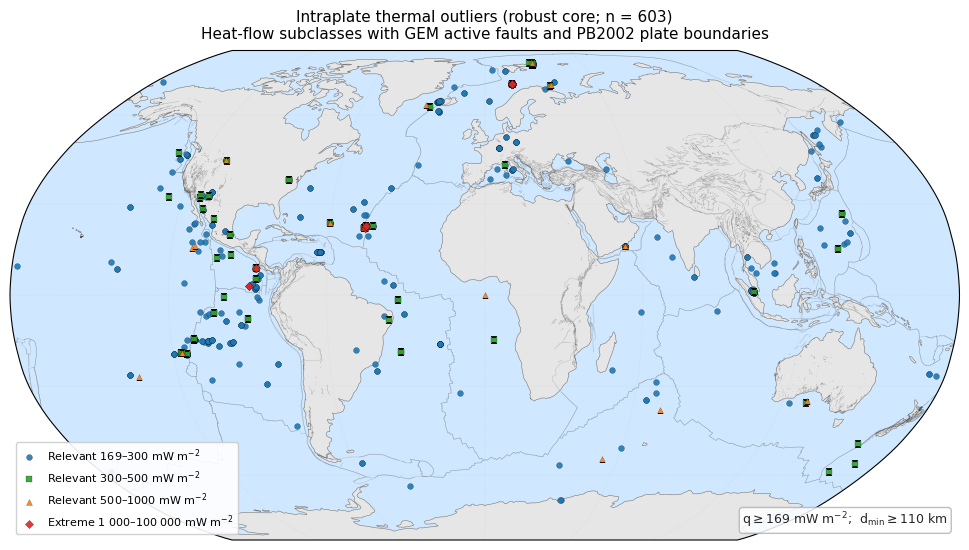

In [36]:
# ==============================================================
# Snippet 36 — Figure 5: Robinson map of final intraplate outliers (q subclasses + GEM/PB) (ROUTED)
#
# Purpose:
#   Render a Robinson-projection map of final intraplate outliers (keep_intraplate=True),
#   subclassed by q ranges, with overlays:
#     - GEM active faults
#     - PB2002 plate boundaries
#   Saves publication-ready PNG and PDF.
#
# Inputs:
#   - QA results CSV produced by Snippet 35 (qa_fragmentation_tests.csv)
#   - GEM_SHP and PB2002_SHP (from Snippet 2)
#
# Outputs (ROUTED via Snippet 2):
#   Preferred family: "figures_main" (if defined in router)
#   Fallback family : "plots" (guaranteed in router mapping)
#     - fig5_robinson_outliers_faults_qclasses.(png|pdf)
# ==============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# -----------------------------
# Routing helpers (from Snippet 2)
# -----------------------------
HAS_ROUTER = ("resolve_out_path" in globals())

def _safe_resolve_out_path(filename: str, family_preferred: str, family_fallback: str = "plots") -> Path:
    """
    Uses router if available; falls back to a known family if the preferred family is not registered.
    """
    if HAS_ROUTER:
        try:
            return resolve_out_path(filename, family=family_preferred)
        except KeyError:
            return resolve_out_path(filename, family=family_fallback)
    # last resort: local fallback
    p = Path("./_out_fallback") / family_fallback
    p.mkdir(parents=True, exist_ok=True)
    return p / filename

# -----------------------------
# Params (protocol)
# -----------------------------
assert "require_param" in globals(), "require_param() not found (Snippet 2 must be executed)."
Q_THRESH = float(require_param("Q_THR_RELEV"))
DIST_CUTOFF_KM = float(require_param("DIST_CUTOFF_KM"))

# -----------------------------
# Locate QA outputs from Snippet 35
# -----------------------------
if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
assert CSV_QA.exists(), f"Missing QA CSV: {CSV_QA} (run Snippet 35 first)"

df = pd.read_csv(CSV_QA)

# keep only robust core intraplate outliers
df_intra = df[df["keep_intraplate"] == True].copy()
assert {"lat", "lon", "q"}.issubset(df_intra.columns), "Missing lat/lon/q in df_intra"

df_intra["q"] = pd.to_numeric(df_intra["q"], errors="coerce")
df_intra["lat"] = pd.to_numeric(df_intra["lat"], errors="coerce")
df_intra["lon"] = pd.to_numeric(df_intra["lon"], errors="coerce")

# Enforce protocol distance if column exists
if "dist_min_km" in df_intra.columns:
    df_intra["dist_min_km"] = pd.to_numeric(df_intra["dist_min_km"], errors="coerce")
    df_intra = df_intra[df_intra["dist_min_km"] >= DIST_CUTOFF_KM].copy()

df_intra = df_intra[df_intra["q"] >= Q_THRESH].dropna(subset=["lat", "lon", "q"]).copy()

n_intra = int(df_intra.shape[0])
print(f"[S79] Final intraplate outliers plotted (point-level): {n_intra} points")
print(f"[S79] Thresholds: q >= {Q_THRESH:.0f} mW m^-2 | dist_min_km >= {DIST_CUTOFF_KM:.0f} km")

# -----------------------------
# Tectonic datasets (prefer Snippet 2)
# -----------------------------
def _as_path(x) -> Path:
    if x is None:
        raise TypeError("Cannot convert None to Path.")
    return x if isinstance(x, Path) else Path(x)

GEM_SHAPE = _as_path(globals().get("GEM_SHP", None) or os.environ.get("GEM_SHP", "").strip())
PB2002_SHAPE = _as_path(globals().get("PB2002_SHP", None) or os.environ.get("PB2002_SHP", "").strip())

assert GEM_SHAPE.exists(), f"Missing GEM dataset. Resolved path: {GEM_SHAPE}"
assert PB2002_SHAPE.exists(), f"Missing PB2002 dataset. Resolved path: {PB2002_SHAPE}"

print(f"[S79] GEM → {GEM_SHAPE}")
print(f"[S79] PB  → {PB2002_SHAPE}")

faults_gem = gpd.read_file(GEM_SHAPE)
faults_pb  = gpd.read_file(PB2002_SHAPE)

def _ensure_wgs84(gdf):
    if gdf.crs is None:
        return gdf.set_crs(epsg=4326, allow_override=True)
    return gdf.to_crs(epsg=4326)

faults_gem = _ensure_wgs84(faults_gem)
faults_pb  = _ensure_wgs84(faults_pb)

# -----------------------------
# Heat-flow subclasses (explicit colors are figure semantics)
# -----------------------------
labels = [
    r"Relevant 169–300 mW m$^{-2}$",
    r"Relevant 300–500 mW m$^{-2}$",
    r"Relevant 500–1000 mW m$^{-2}$",
    r"Extreme 1 000–100 000 mW m$^{-2}$",
    r"Ultra-rare ≥100 000 mW m$^{-2}$",
]

conditions = [
    (df_intra["q"] >= Q_THRESH) & (df_intra["q"] < 300.0),
    (df_intra["q"] >= 300.0) & (df_intra["q"] < 500.0),
    (df_intra["q"] >= 500.0) & (df_intra["q"] < 1000.0),
    (df_intra["q"] >= 1000.0) & (df_intra["q"] < 100_000.0),
    (df_intra["q"] >= 100_000.0),
]

colors  = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]
markers = ["o", "s", "^", "D", "P"]

df_intra["q_class"] = "Below cutoff"
for cond, lab in zip(conditions, labels):
    df_intra.loc[cond, "q_class"] = lab

# -----------------------------
# Robinson map
# -----------------------------
proj = ccrs.Robinson()
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 5.6))
ax = plt.axes(projection=proj)
ax.set_global()

ax.add_feature(cfeature.OCEAN.with_scale("110m"), facecolor="#cfe8ff", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("110m"),  facecolor="0.90", edgecolor="none", zorder=0)
ax.coastlines(lw=0.4, color="0.45", zorder=1)
ax.gridlines(draw_labels=False, linestyle="--", linewidth=0.3, alpha=0.25)

faults_pb.plot(ax=ax, transform=data_crs, color="0.55", linewidth=0.45, alpha=0.35, zorder=2)
faults_gem.plot(ax=ax, transform=data_crs, color="0.25", linewidth=0.35, alpha=0.30, zorder=3)

handles = []
for color, marker, lab in zip(colors, markers, labels):
    sub = df_intra[df_intra["q_class"] == lab]
    if sub.empty:
        continue
    h = ax.scatter(
        sub["lon"].values, sub["lat"].values,
        s=18, color=color, alpha=0.90,
        edgecolors="k", linewidths=0.15,
        marker=marker, transform=data_crs,
        zorder=4, label=lab, rasterized=True,
    )
    handles.append(h)

ax.set_title(
    "Intraplate thermal outliers (robust core; n = {:,})\n"
    "Heat-flow subclasses with GEM active faults and PB2002 plate boundaries".format(n_intra),
    fontsize=11, pad=8,
)

if handles:
    ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True, framealpha=0.90,
              borderpad=0.4, handlelength=1.6)

ax.text(
    0.988, 0.02,
    rf"$q \geq {Q_THRESH:.0f}$ mW m$^{{-2}}$;  $d_{{min}} \geq {DIST_CUTOFF_KM:.0f}$ km",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9, color="0.15",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.70", alpha=0.85),
    zorder=10
)

plt.tight_layout()

print("[DEBUG] FIG_DIR =", Path(FIG_DIR).resolve())

# -----------------------------
# Save (MAIN FIGURES POLICY)
#   - Main manuscript figures MUST go to FIG_DIR (public_release/figures_main)
#   - Pipeline plots stay in OUT_DIR/plots
# -----------------------------
assert "resolve_out_path" in globals(), "resolve_out_path missing (run Snippet 2 first)."
assert "FIG_DIR" in globals(), "FIG_DIR missing (run Snippet 2 first)."

fname_png = "fig5_robinson_outliers_faults_qclasses.png"
fname_pdf = "fig5_robinson_outliers_faults_qclasses.pdf"

# 1) Main manuscript location
out_png_main = Path(FIG_DIR) / fname_png
out_pdf_main = Path(FIG_DIR) / fname_pdf

# 2) Pipeline plots location (always)
out_png_plot = resolve_out_path(fname_png, family="plots")
out_pdf_plot = resolve_out_path(fname_pdf, family="plots")

# Ensure dirs exist
out_png_main.parent.mkdir(parents=True, exist_ok=True)
out_png_plot.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(out_png_main, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf_main, bbox_inches="tight")

fig.savefig(out_png_plot, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf_plot, bbox_inches="tight")

print(f"[S79][SAVE][MAIN] {out_png_main}")
print(f"[S79][SAVE][MAIN] {out_pdf_main}")
print(f"[S79][SAVE][PLOT] {out_png_plot}")
print(f"[S79][SAVE][PLOT] {out_pdf_plot}")

plt.show()
plt.close(fig)
# ==============================================================

# Snippet 37 — Summary stats for final intraplate outliers (counts + quantiles)

In [37]:
# ==============================================================
# Snippet 37 — Summary stats for final intraplate outliers (counts + quantiles) (ROUTED)
#
# Purpose:
#   Compute descriptive statistics for final intraplate outliers (keep_intraplate=True, q ≥ Q_THR_RELEV):
#     - heat-flow distribution (quantiles)
#     - subclass counts/fractions across q bins
#     - distance-to-fault distribution + fractions above thresholds
#
# Inputs:
#   - qa_fragmentation_tests.csv (from Snippet 35)
#   - require_param("Q_THR_RELEV"), require_param("DIST_CUTOFF_KM")
#
# Outputs (ROUTED):
#   - OUT_DIR/analysis/summary_final_outliers_stats.csv
#   - Console summary (for notebook logs)
#
# Editorial role:
#   DECISION — quantitative descriptors used in text and figure captions.
# ==============================================================

from pathlib import Path
import pandas as pd
import numpy as np

Q_THRESH = float(require_param("Q_THR_RELEV"))
DIST_CUTOFF_KM = float(require_param("DIST_CUTOFF_KM"))

# -----------------------------
# Locate QA outputs from Snippet 35
# -----------------------------
if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
assert CSV_QA.exists(), f"Missing QA CSV: {CSV_QA} (run Snippet 35 first)"

df = pd.read_csv(CSV_QA)

# enforce numeric
for c in ["q", "dist_min_km"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df_intra = df[(df["keep_intraplate"] == True) & (df["q"] >= Q_THRESH)].copy()
df_intra = df_intra.dropna(subset=["q"]).copy()
n = int(len(df_intra))

print(f"[S80] N intraplate outliers (keep_intraplate=True, q ≥ {Q_THRESH:.0f}): {n:,}")

# -----------------------------
# 1) Heat-flow stats
# -----------------------------
q_stats = df_intra["q"].describe(percentiles=[0.50, 0.90, 0.95, 0.99]).to_dict()

print("\n[S80] Heat-flow statistics (q; mW m^-2):")
for k in ["count", "mean", "std", "min", "50%", "90%", "95%", "99%", "max"]:
    if k in q_stats:
        print(f"  {k:>5s}: {q_stats[k]}")

# -----------------------------
# 2) Subclass counts
# -----------------------------
conditions = [
    (df_intra["q"] >= Q_THRESH) & (df_intra["q"] < 300.0),
    (df_intra["q"] >= 300.0) & (df_intra["q"] < 500.0),
    (df_intra["q"] >= 500.0) & (df_intra["q"] < 1000.0),
    (df_intra["q"] >= 1000.0) & (df_intra["q"] < 100_000.0),
    (df_intra["q"] >= 100_000.0),
]
labels = [
    r"Relevant 169–300 mW m$^{-2}$",
    r"Relevant 300–500 mW m$^{-2}$",
    r"Relevant 500–1000 mW m$^{-2}$",
    r"Extreme 1 000–100 000 mW m$^{-2}$",
    r"Ultra-rare ≥100 000 mW m$^{-2}$",
]

df_intra["q_class"] = "Below cutoff"
for cond, lab in zip(conditions, labels):
    df_intra.loc[cond, "q_class"] = lab

counts = df_intra["q_class"].value_counts()
fractions = (counts / max(1, n)).astype(float)

print("\n[S80] Counts per heat-flow subclass:")
print(counts.to_string())

print("\n[S80] Fractions per subclass:")
print(fractions.round(3).to_string())

# -----------------------------
# 3) Distance-to-fault stats
# -----------------------------
dist_stats = None
if "dist_min_km" in df_intra.columns:
    df_intra = df_intra.dropna(subset=["dist_min_km"]).copy()
    dist_stats = df_intra["dist_min_km"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_dict()

    print("\n[S80] Distance-to-fault statistics (dist_min_km; km):")
    for k in ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "max"]:
        if k in dist_stats:
            print(f"  {k:>5s}: {dist_stats[k]}")

    for thr in (DIST_CUTOFF_KM, 300, 500, 800, 1000):
        frac = float((df_intra["dist_min_km"] >= float(thr)).mean())
        print(f"  Fraction with dist_min_km ≥ {float(thr):.0f} km: {frac:.3f}")
else:
    print("\n[S80][WARN] dist_min_km missing; skipping distance stats.")

# -----------------------------
# 4) Export a compact table (ROUTED)
# -----------------------------
def _resolve_out(name: str, family: str):
    if "resolve_out_path" in globals():
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

out_csv = _resolve_out("summary_final_outliers_stats.csv", family="analysis")

rows = []
rows.append({"metric": "N_outliers_final", "value": n})
rows.append({"metric": "q_threshold_mW_m-2", "value": Q_THRESH})
for k, v in q_stats.items():
    rows.append({"metric": f"q_{k}", "value": v})

for lab in labels:
    rows.append({"metric": f"count_{lab}", "value": int(counts.get(lab, 0))})
    rows.append({"metric": f"frac_{lab}", "value": float(fractions.get(lab, 0.0))})

if dist_stats is not None:
    for k, v in dist_stats.items():
        rows.append({"metric": f"dist_min_km_{k}", "value": v})

pd.DataFrame(rows).to_csv(out_csv, index=False)
print(f"\n[S80] Saved → {out_csv}")

[S80] N intraplate outliers (keep_intraplate=True, q ≥ 169): 603

[S80] Heat-flow statistics (q; mW m^-2):
  count: 603.0
   mean: 370.5541094041459
    std: 400.68542705465086
    min: 169.0
    50%: 230.0
    90%: 760.0
    95%: 1047.6999999999998
    99%: 2224.8
    max: 3212.0

[S80] Counts per heat-flow subclass:
q_class
Relevant 169–300 mW m$^{-2}$         417
Relevant 300–500 mW m$^{-2}$          99
Relevant 500–1000 mW m$^{-2}$         53
Extreme 1 000–100 000 mW m$^{-2}$     34

[S80] Fractions per subclass:
q_class
Relevant 169–300 mW m$^{-2}$         0.692
Relevant 300–500 mW m$^{-2}$         0.164
Relevant 500–1000 mW m$^{-2}$        0.088
Extreme 1 000–100 000 mW m$^{-2}$    0.056

[S80] Distance-to-fault statistics (dist_min_km; km):
  count: 603.0
   mean: 579.0995478859764
    std: 701.8728692881956
    min: 110.48462266720156
    25%: 148.24898197513363
    50%: 289.4250079747453
    75%: 706.4337627905758
    90%: 1465.1125692721157
    max: 4072.9559828651936
  Fract

# Snippet 38 — Scatter: dist_min_km × q (final intraplate outliers)

[S81] N intraplate outliers: 603
[S81] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\scatter_final_outliers_dist_vs_q.png
[S81] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\scatter_final_outliers_dist_vs_q.pdf


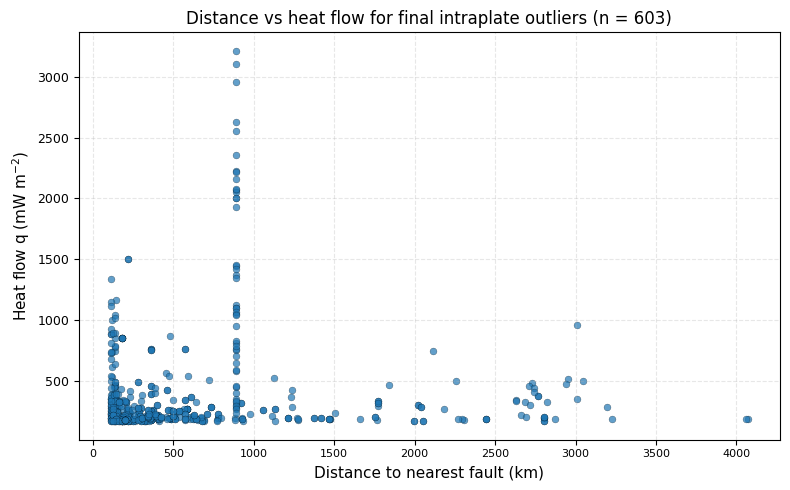

In [38]:
# ==============================================================
# Snippet 38 — Scatter: dist_min_km × q (final intraplate outliers) (ROUTED)
#
# Purpose:
#   Diagnostic scatter of distance to nearest fault (dist_min_km) vs heat flow (q)
#   for the final intraplate outlier set (keep_intraplate=True, q ≥ Q_THR_RELEV).
#
# Inputs:
#   - qa_fragmentation_tests.csv (from Snippet 35)
#
# Outputs (ROUTED):
#   - OUT_DIR/plots/scatter_final_outliers_dist_vs_q.png
#   - OUT_DIR/plots/scatter_final_outliers_dist_vs_q.pdf
#   - On-screen plot
#
# Editorial role:
#   DECISION — sanity-check visualization of the final subset.
# ==============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Q_THRESH = float(require_param("Q_THR_RELEV"))

# -----------------------------
# Locate QA outputs from Snippet 35
# -----------------------------
if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
assert CSV_QA.exists(), f"Missing QA CSV: {CSV_QA} (run Snippet 35 first)"

df = pd.read_csv(CSV_QA)

for c in ["q", "dist_min_km"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df_final = df[(df["keep_intraplate"] == True) & (df["q"] >= Q_THRESH)].copy()
df_final = df_final.dropna(subset=["q", "dist_min_km"]).copy()

n = int(len(df_final))
print(f"[S81] N intraplate outliers: {n:,}")

# -----------------------------
# Routing
# -----------------------------
def _resolve_out(name: str, family: str):
    if "resolve_out_path" in globals():
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

out_png = _resolve_out("scatter_final_outliers_dist_vs_q.png", family="plots")
out_pdf = _resolve_out("scatter_final_outliers_dist_vs_q.pdf", family="plots")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df_final["dist_min_km"].to_numpy(float),
    df_final["q"].to_numpy(float),
    s=25,
    alpha=0.7,
    edgecolor="k",
    linewidth=0.2
)

plt.xlabel("Distance to nearest fault (km)", fontsize=11)
plt.ylabel(r"Heat flow $q$ (mW m$^{-2}$)", fontsize=11)
plt.title(f"Distance vs heat flow for final intraplate outliers (n = {n:,})", fontsize=12)

plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print(f"[S81] Saved → {out_png}")
print(f"[S81] Saved → {out_pdf}")

plt.show()

# Snippet 39 — Trend line on scatter (polyfit in log-distance)

[S82] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\scatter_trend_polyfit_logdist.png
[S82] Saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\plots\scatter_trend_polyfit_logdist.pdf


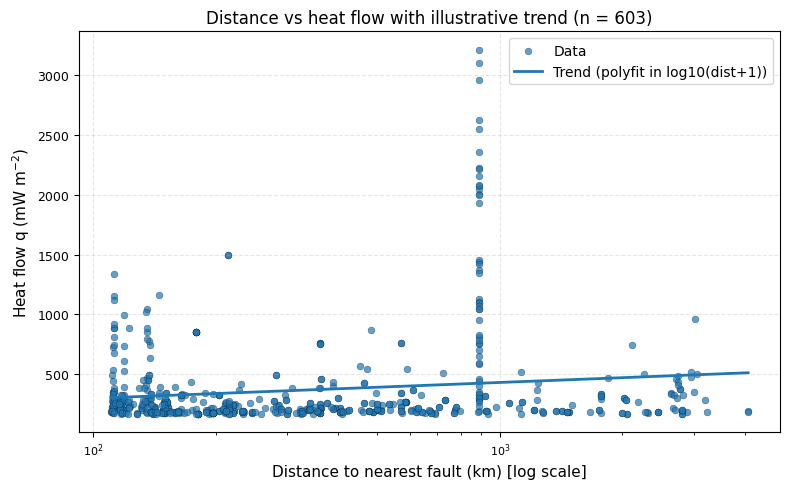

In [39]:
# ==============================================================
# Snippet 39 — Trend line on scatter (polyfit in log-distance) (ROUTED) - FIXED (+1 km)
#
# Key fix:
#   - Use log10(dist_min_km + 1.0) instead of clip(min=1e-6) to match pipeline convention.
#   - This keeps dist=0 valid and makes the transform consistent across figures/snippets.
#
# Purpose:
#   Illustrative trend line using polyfit on log10(distance) for final intraplate outliers.
#   NOTE: EXPLORE only (not a protocol regression output).
#
# Inputs:
#   - qa_fragmentation_tests.csv (from Snippet 35)
#
# Outputs (ROUTED):
#   - OUT_DIR/plots/scatter_trend_polyfit_logdist.png
#   - OUT_DIR/plots/scatter_trend_polyfit_logdist.pdf
#   - On-screen plot
#
# Editorial role:
#   EXPLORE
# ==============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "require_param" in globals(), "require_param must be defined (Snippet 2)."
Q_THRESH = float(require_param("Q_THR_RELEV"))

# -----------------------------
# Locate QA outputs (Snippet 35)
# -----------------------------
if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
assert CSV_QA.exists(), f"Missing QA CSV: {CSV_QA} (run Snippet 35 first)"

df = pd.read_csv(CSV_QA)

for c in ["q", "dist_min_km"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df_final = df[(df["keep_intraplate"] == True) & (df["q"] >= Q_THRESH)].copy()
df_final = df_final.dropna(subset=["q", "dist_min_km"]).copy()

# Allow dist=0 (log uses +1.0)
df_final = df_final[(df_final["q"] > 0) & (df_final["dist_min_km"] >= 0)].copy()

n = int(len(df_final))
assert n >= 3, "[S82] Too few points for polyfit."

# -----------------------------
# Polyfit in log10(dist + 1)
# -----------------------------
x = np.log10(df_final["dist_min_km"].to_numpy(float) + 1.0)
y = df_final["q"].to_numpy(float)

coef = np.polyfit(x, y, 1)  # linear in log-distance (offset form)
xp = np.linspace(x.min(), x.max(), 300)
yp = coef[0] * xp + coef[1]

# -----------------------------
# Routing
# -----------------------------
def _resolve_out(name: str, family: str):
    if "resolve_out_path" in globals():
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

out_png = _resolve_out("scatter_trend_polyfit_logdist.png", family="plots")
out_pdf = _resolve_out("scatter_trend_polyfit_logdist.pdf", family="plots")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(
    df_final["dist_min_km"].to_numpy(float),
    df_final["q"].to_numpy(float),
    s=25, alpha=0.7,
    edgecolor="k", linewidth=0.2,
    label="Data",
)

# Convert xp (log10(dist+1)) back to km for plotting on log x-axis:
#   dist = (10**xp) - 1
plt.plot(
    (10**xp) - 1.0, yp,
    linewidth=2.0,
    label="Trend (polyfit in log10(dist+1))"
)

plt.xscale("log")
plt.xlabel("Distance to nearest fault (km) [log scale]", fontsize=11)
plt.ylabel(r"Heat flow $q$ (mW m$^{-2}$)", fontsize=11)
plt.title(f"Distance vs heat flow with illustrative trend (n = {n:,})", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print(f"[S82] Saved → {out_png}")
print(f"[S82] Saved → {out_pdf}")

plt.show()

# Snippet 40 — Canonical vs site-level consistency assertions

In [40]:
# ============================================================
# Snippet 40 — Canonical vs site-level consistency assertions (ROUTED)
#
# Goal:
#   Prove that intraplate classification is defined at POINT level (canonical),
#   and that any ~1 km "site" collapse is auxiliary (robustness/visualization).
#
# Purpose:
#   A) Verify that the final kept intraplate outliers are members of the canonical
#      intraplate dataset, using rounded (lat, lon, q) keys (NO snapping).
#   B) Demonstrate that any "357-like" number comes from an auxiliary ~1 km site
#      collapse applied to kept points (EPSG:3857 grid).
#
# Inputs (preferred):
#   - df_k_canon in memory, else read from PIPELINE_ROOT/df_k_canon.csv
#   - df_outliers in memory (from Snippet 35), else read from:
#       DIAG_DIR/qa_fragmentation/qa_fragmentation_tests.csv and filter keep_intraplate==True
#
# Outputs (ROUTED):
#   - OUT_DIR/analysis/site_level_consistency_audit.csv
#   - Console verification report
#
# Editorial role:
#   DECISION
#   Definition-proof of point-level classification (manuscript claims + reviewer defense).
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

# ----------------------------
# 0) Resolve paths (Snippet 2 layout)
# ----------------------------
PIPELINE_ROOT = Path(OUT_DIR) if "OUT_DIR" in globals() else Path("./_out_fallback/pipeline_kmeans")
PIPELINE_ROOT.mkdir(parents=True, exist_ok=True)

if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
CSV_CANON = PIPELINE_ROOT / "df_k_canon.csv"

def _resolve_out(name: str, family: str):
    if "resolve_out_path" in globals():
        return resolve_out_path(name, family=family)
    p = Path("./_out_fallback") / family
    p.mkdir(parents=True, exist_ok=True)
    return p / name

OUT_AUDIT_CSV = _resolve_out("site_level_consistency_audit.csv", family="analysis")

# ----------------------------
# 1) Load df_k_canon (memory or disk)
# ----------------------------
if "df_k_canon" in globals() and isinstance(df_k_canon, pd.DataFrame):
    df_canon = df_k_canon.copy()
    canon_source = "memory:df_k_canon"
else:
    assert CSV_CANON.exists(), f"df_k_canon not found in memory and missing on disk: {CSV_CANON}"
    df_canon = pd.read_csv(CSV_CANON)
    canon_source = f"disk:{CSV_CANON}"

# ----------------------------
# 2) Load kept intraplate outliers (memory or disk)
# ----------------------------
if "df_outliers" in globals() and isinstance(df_outliers, pd.DataFrame) and ("keep_intraplate" in df_outliers.columns):
    df_out = df_outliers.copy()
    out_source = "memory:df_outliers"
else:
    assert CSV_QA.exists(), f"QA table missing: {CSV_QA} (run Snippet 35 first)"
    df_out = pd.read_csv(CSV_QA)
    out_source = f"disk:{CSV_QA}"
    assert "keep_intraplate" in df_out.columns, "qa_fragmentation_tests.csv must contain keep_intraplate."

g_keep = df_out.loc[df_out["keep_intraplate"] == True].copy()

assert len(df_out) > 0, "Outliers table is empty — check Snippet 35 thresholds/dist filters."
assert len(g_keep) <= len(df_out), "Keep set cannot exceed outliers."

# ----------------------------
# 3) Membership test (NO snapping)
#    Use rounded (lat, lon, q) keys to avoid float traps; does NOT collapse.
# ----------------------------
need_cols = ["lat", "lon", "q"]
for c in need_cols:
    assert c in g_keep.columns and c in df_canon.columns, f"Missing '{c}' in keep or canon."

def _keys(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "lat_r": np.round(pd.to_numeric(df["lat"], errors="coerce").astype(float), 6),
        "lon_r": np.round(pd.to_numeric(df["lon"], errors="coerce").astype(float), 6),
        "q_r":   np.round(pd.to_numeric(df["q"],   errors="coerce").astype(float), 3),
    })
    return out.dropna().drop_duplicates()

k_keep  = _keys(g_keep)
k_canon = _keys(df_canon)

m = k_keep.merge(k_canon, on=["lat_r", "lon_r", "q_r"], how="left", indicator=True)

n_keep_keys = int(len(k_keep))
n_missing = int((m["_merge"] != "both").sum())

assert n_missing == 0, (
    "Some kept intraplate points are NOT present in df_k_canon (after rounding keys). "
    "This suggests post-processing contamination (e.g., snapping) or dataset mismatch."
)

# ----------------------------
# 4) Auxiliary ~1 km site collapse (EPSG:3857 grid)
# ----------------------------
def _n_sites_1km_epsg3857_from_lonlat(df: pd.DataFrame, snap_m: float = 1000.0) -> int:
    lon = pd.to_numeric(df["lon"], errors="coerce").astype(float)
    lat = pd.to_numeric(df["lat"], errors="coerce").astype(float)
    ok = lon.notna() & lat.notna()
    assert ok.any(), "No valid lon/lat rows to compute 1 km snapping."

    g = gpd.GeoDataFrame(
        df.loc[ok, ["lon", "lat"]].copy(),
        geometry=gpd.points_from_xy(lon.loc[ok], lat.loc[ok]),
        crs="EPSG:4326",
    ).to_crs(3857)

    x = g.geometry.x.to_numpy(dtype=float)
    y = g.geometry.y.to_numpy(dtype=float)

    gx = np.floor((x + snap_m / 2.0) / snap_m).astype("int64")
    gy = np.floor((y + snap_m / 2.0) / snap_m).astype("int64")

    cells = np.stack([gx, gy], axis=1)
    return int(np.unique(cells, axis=0).shape[0])

n_sites_from_keep = _n_sites_1km_epsg3857_from_lonlat(g_keep, snap_m=1000.0)

assert n_sites_from_keep <= len(g_keep), (
    "1 km collapse did not reduce cardinality — check lon/lat validity or snap settings."
)

# ----------------------------
# 5) Optional: report if a global site table exists
# ----------------------------
sites_name = None
for n in ["g_site", "df_sites", "gdf_sites", "gdf_site"]:
    if n in globals():
        sites_name = n
        break

# ----------------------------
# 6) Export audit CSV (proof artifact)
# ----------------------------
audit = pd.DataFrame([{
    "canon_source": canon_source,
    "outliers_source": out_source,
    "N_canon_points": int(len(df_canon)),
    "N_outliers_points": int(len(df_out)),
    "N_kept_points_no_snapping": int(len(g_keep)),
    "N_kept_unique_keys_rounding": n_keep_keys,
    "N_missing_from_canon_by_keys": n_missing,
    "N_kept_sites_1km_aux": int(n_sites_from_keep),
    "site_table_found_in_memory": sites_name if sites_name else "None",
    "site_table_rows": int(len(globals()[sites_name])) if sites_name else np.nan,
}])

audit.to_csv(OUT_AUDIT_CSV, index=False)

print("VERIFIED (definition-proof, no magic numbers):")
print(f"• Canonical intraplate base (df_k_canon): {len(df_canon):,} points  [{canon_source}]")
print(f"• Outliers table:                          {len(df_out):,} points  [{out_source}]")
print(f"• Kept intraplate (point-level):           {len(g_keep):,} points (NO snapping)")
print(f"• Derived ~1 km sites from kept points:    {n_sites_from_keep:,} sites (aux collapse)")
if sites_name:
    print(f"• Found site-level table in memory:        {sites_name} (N={len(globals()[sites_name]):,})")
else:
    print("• No site-level table found in memory (OK).")
print(f"💾 Audit saved → {OUT_AUDIT_CSV}")

VERIFIED (definition-proof, no magic numbers):
• Canonical intraplate base (df_k_canon): 53,420 points  [memory:df_k_canon]
• Outliers table:                          1,963 points  [memory:df_outliers]
• Kept intraplate (point-level):           603 points (NO snapping)
• Derived ~1 km sites from kept points:    361 sites (aux collapse)
• Found site-level table in memory:        g_site (N=58,032)
💾 Audit saved → C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\pipeline_kmeans\analysis\site_level_consistency_audit.csv


# Snippet 41 — FINAL PIPELINE FREEZE & REPRODUCIBILITY MANIFEST

In [41]:
# ==============================================================
# Snippet 41 — FINAL PIPELINE FREEZE & REPRODUCIBILITY MANIFEST (ROUTED)
#
# Purpose:
#   Produce a final freeze manifest that:
#     1) records immutable scientific definitions (point-level membership)
#     2) records frozen counts (canonical N, outliers N, kept N, aux 1 km site N)
#     3) hashes canonical artifacts (sha256 + size) for auditability
#     4) stores minimal environment metadata
#
# Inputs (preferred):
#   - df_outliers in memory (from Snippet 35) OR load from qa_fragmentation_tests.csv
#   - df_k_canon on disk (PIPELINE_ROOT/df_k_canon.csv) or in memory
#   - topq_table + ultra_sensitivity (optional, hashed if present)
#
# Outputs (to public_release/freeze/):
#   - pipeline_freeze_manifest.json
#
# Editorial role:
#   METHOD
#   Reproducibility and “pipeline closed” certification.
# ==============================================================

import json
import hashlib
from pathlib import Path
import pandas as pd
import geopandas as gpd
import platform
import sys
from datetime import datetime, timezone
import numpy as np

# --------------------------------------------------------------
# 0) Canonical roots (Snippet 2 layout)
# --------------------------------------------------------------
PIPELINE_ROOT = Path(OUT_DIR) if "OUT_DIR" in globals() else Path("./_out_fallback/pipeline_kmeans")
PIPELINE_ROOT.mkdir(parents=True, exist_ok=True)

FREEZE_ROOT = Path(FREEZE_DIR) if "FREEZE_DIR" in globals() else Path("./_out_fallback/freeze")
FREEZE_ROOT.mkdir(parents=True, exist_ok=True)

if "DIAG_DIR" in globals():
    QA_FRAG_DIR = Path(DIAG_DIR) / "qa_fragmentation"
else:
    QA_FRAG_DIR = Path("./_out_fallback/qa_fragmentation")
QA_FRAG_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_OUT = FREEZE_ROOT / "pipeline_freeze_manifest.json"

# --------------------------------------------------------------
# 1) Helper: SHA-256
# --------------------------------------------------------------
def sha256_of_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def file_hash_record(path: Path):
    path = Path(path)
    if path.exists() and path.is_file():
        return {
            "path": str(path).replace("\\", "/"),
            "sha256": sha256_of_file(path),
            "size_bytes": int(path.stat().st_size),
        }
    return {"path": str(path).replace("\\", "/"), "status": "NOT_PRESENT_AT_FREEZE"}

# --------------------------------------------------------------
# 2) Resolve key artifacts (best-effort, layout-aware)
# --------------------------------------------------------------
# Canonical CSV
CSV_CANON = PIPELINE_ROOT / "df_k_canon.csv"
assert ("df_k_canon" in globals()) or CSV_CANON.exists(), (
    f"Need df_k_canon in memory OR on disk at: {CSV_CANON}"
)

# QA table from Snippet 35
CSV_QA = QA_FRAG_DIR / "qa_fragmentation_tests.csv"
assert ("df_outliers" in globals()) or CSV_QA.exists(), (
    f"Need df_outliers in memory OR QA CSV at: {CSV_QA}"
)

# Optional analysis artifacts (hash if present)
# NOTE: these names assume you routed them; if not present, manifest records NOT_PRESENT.
def _resolve_optional(name, family):
    if "resolve_out_path" in globals():
        try:
            return resolve_out_path(name, family=family)
        except Exception:
            return None
    return None

TOPQ = _resolve_optional("topq_table.csv", "analysis") or (PIPELINE_ROOT / "topq_table.csv")
ULTRA = (
    _resolve_optional("ultra_sensitivity.csv", "analysis") or
    (PIPELINE_ROOT / "ultra_sensitivity.csv") or
    (PIPELINE_ROOT / "ultra_extreme_sites.csv")
)

# --------------------------------------------------------------
# 3) Load df_k_canon (for N only)
# --------------------------------------------------------------
if "df_k_canon" in globals() and isinstance(df_k_canon, pd.DataFrame):
    df_k = df_k_canon.copy()
    canon_source = "memory:df_k_canon"
else:
    df_k = pd.read_csv(CSV_CANON)
    canon_source = f"disk:{CSV_CANON}"

# --------------------------------------------------------------
# 4) Load df_outliers / kept set (point-level, no snapping)
# --------------------------------------------------------------
if "df_outliers" in globals() and isinstance(df_outliers, pd.DataFrame):
    df_out = df_outliers.copy()
    out_source = "memory:df_outliers"
else:
    df_out = pd.read_csv(CSV_QA)
    out_source = f"disk:{CSV_QA}"

assert "keep_intraplate" in df_out.columns, "Outliers table must contain keep_intraplate."
g_keep = df_out.loc[df_out["keep_intraplate"] == True].copy()

N_outliers_candidate_points = int(len(df_out))
N_outliers_kept_points = int(len(g_keep))

# --------------------------------------------------------------
# 5) Derived ~1 km sites from kept points (auxiliary collapse)
# --------------------------------------------------------------
def n_sites_1km_epsg3857_from_lonlat(df: pd.DataFrame, snap_m: float = 1000.0) -> int:
    need = {"lon", "lat"}
    assert need.issubset(df.columns), f"Missing columns for site collapse: {need - set(df.columns)}"
    lon = pd.to_numeric(df["lon"], errors="coerce").astype(float)
    lat = pd.to_numeric(df["lat"], errors="coerce").astype(float)
    ok = lon.notna() & lat.notna()
    if not ok.any():
        return 0

    g = gpd.GeoDataFrame(
        df.loc[ok, ["lon","lat"]].copy(),
        geometry=gpd.points_from_xy(lon.loc[ok], lat.loc[ok]),
        crs="EPSG:4326",
    ).to_crs(3857)

    x = g.geometry.x.to_numpy(dtype=float)
    y = g.geometry.y.to_numpy(dtype=float)

    gx = np.floor((x + snap_m/2.0) / snap_m).astype("int64")
    gy = np.floor((y + snap_m/2.0) / snap_m).astype("int64")

    cells = np.stack([gx, gy], axis=1)
    return int(np.unique(cells, axis=0).shape[0])

N_outliers_kept_sites_1km_aux = n_sites_1km_epsg3857_from_lonlat(g_keep, snap_m=1000.0)

# --------------------------------------------------------------
# 6) Optional: record auxiliary global site universe size (if present)
# --------------------------------------------------------------
aux_site_universe = {}
for nm in ["g_site", "df_sites", "gdf_sites", "gdf_site"]:
    if nm in globals():
        try:
            aux_site_universe = {"name": nm, "N_rows": int(len(globals()[nm]))}
        except Exception:
            aux_site_universe = {"name": nm, "status": "present_but_unreadable"}
        break

# --------------------------------------------------------------
# 7) Frozen definitions (textual)
# --------------------------------------------------------------
FROZEN_DEFINITIONS = {
    "intraplate_domain": (
        "Canonical intraplate membership is defined at POINT LEVEL "
        "using dist_min_km = min(dist_gem_km, dist_pb_km) relative to GEM and PB2002 linework. "
        "Any ~1 km site collapse is auxiliary (robustness/visualization) and MUST NOT redefine membership."
    ),
    "site_definition_auxiliary": "Auxiliary ~1 km sites via EPSG:3857 grid rounding (1 km).",
    "outlier_definition": (
        "Outliers are computed at point level; 'kept intraplate' points are those with keep_intraplate=True "
        "after fragmentation QA (NO snapping)."
    ),
    "pipeline_status": "FROZEN — no further analytical changes permitted."
}

# --------------------------------------------------------------
# 8) Frozen numerical facts
# --------------------------------------------------------------
FROZEN_COUNTS = {
    "canon_source": canon_source,
    "outliers_source": out_source,
    "N_intraplate_points_df_k_canon": int(len(df_k)),
    "N_outliers_candidate_points_df_outliers": N_outliers_candidate_points,
    "N_outliers_kept_points_no_snapping": N_outliers_kept_points,
    "N_outliers_kept_sites_1km_aux": N_outliers_kept_sites_1km_aux,
}
if aux_site_universe:
    FROZEN_COUNTS["aux_site_universe"] = aux_site_universe

# --------------------------------------------------------------
# 9) Canonical file hashes
# --------------------------------------------------------------
CANONICAL_FILES = {
    "df_k_canon_csv": CSV_CANON,
    "qa_fragmentation_tests_csv": CSV_QA,
    "topq_table": TOPQ,
    "ultra_sensitivity_or_sites": ULTRA,
}

FILE_HASHES = {k: file_hash_record(Path(v)) for k, v in CANONICAL_FILES.items()}

# --------------------------------------------------------------
# 10) Environment snapshot (minimal)
# --------------------------------------------------------------
ENVIRONMENT = {
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
}

# --------------------------------------------------------------
# 11) Build manifest
# --------------------------------------------------------------
MANIFEST = {
    "freeze_timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "pipeline_snippets_total": 85,
    "definitions": FROZEN_DEFINITIONS,
    "counts": FROZEN_COUNTS,
    "canonical_file_hashes": FILE_HASHES,
    "environment": ENVIRONMENT,
    "editorial_note": (
        "This manifest certifies that the analytical pipeline is closed. "
        "All manuscript-reported numbers must match the counts recorded here."
    ),
}

# --------------------------------------------------------------
# 12) Write manifest
# --------------------------------------------------------------
with open(MANIFEST_OUT, "w", encoding="utf-8") as f:
    json.dump(MANIFEST, f, indent=2, sort_keys=True)

print("🔒 PIPELINE FROZEN")
print(f"Manifest written to: {MANIFEST_OUT.resolve()}")
print(json.dumps(FROZEN_COUNTS, indent=2))

🔒 PIPELINE FROZEN
Manifest written to: C:\Users\cgauj\OneDrive\Área de Trabalho\heatflow-intraplate-residuals\public_release\freeze\pipeline_freeze_manifest.json
{
  "canon_source": "memory:df_k_canon",
  "outliers_source": "memory:df_outliers",
  "N_intraplate_points_df_k_canon": 53420,
  "N_outliers_candidate_points_df_outliers": 1963,
  "N_outliers_kept_points_no_snapping": 603,
  "N_outliers_kept_sites_1km_aux": 361,
  "aux_site_universe": {
    "name": "g_site",
    "N_rows": 58032
  }
}
